# EDA A2 — Initial Predictor-Readiness EDA (Section 1)
## Endometriosis & Intrapartum Cesarean Section — Sheba Medical Center

---

## Academic analytical notebook — privacy and use note

This notebook is intended for approved academic/project review and is not a
clinical decision-support tool. Patient identifiers and tabular patient-level
records are not intentionally displayed, and rare-cell outputs are suppressed
where applicable, but the notebook may still contain observation-level
visualizations, exact ranges, and rare-value frequencies; sharing should
therefore follow the project's approved data-governance procedures.

**Cohort status:** the current analysis uses the working cohort of
N=431 (vaginal=370, intrapartum CS=61). 16 records with suspected
superficial-only endometriosis are excluded from this cohort (see EDA A
Part 1, Section A4, and Section A2.15 here for the full accounting). Any
variable marked `pending_timing_confirmation` in the current
`modeling_clearance` status is not cleared for modeling (Sections
A2.2/A2.12/A2.13).

---

> **Scope note.** This notebook performs predictor-readiness EDA only: it is the
> second initial-EDA notebook after A1 (cohort overview) and performs no data
> cleaning — it never modifies `df`, never imputes, and never removes rows. It is
> distinct from the separate data-cleaning notebook; this folder was renamed
> from `eda_b` to `a2_predictor_readiness` on 2026-08-24, and internal
> `EDA_B_*` symbol names / `eda-b-*` cell IDs are retained unchanged for
> execution stability only.

---

## Section A2.0 — Purpose, Scope, and Methodology

### Study population and target
The cohort comprises women who underwent a trial of vaginal labor (elective cesarean
and non-trial-of-labor deliveries are excluded upstream, in preprocessing). The
outcome, `target_intrapartum_cs`, is binary: 0 = vaginal delivery, 1 = intrapartum
cesarean section. The classes are imbalanced (approximately 6:1 vaginal-to-CS), which
is handled explicitly during modeling, not in this EDA.

### Research question
Can endometriosis characteristics, obstetric risk factors, and pregnancy data predict
the risk of intrapartum cesarean section after a trial of vaginal labor?

### Purpose of the primary model
The primary model is intended to estimate intrapartum-CS risk from information
available *before* labor begins, so that any resulting risk estimate could plausibly
inform pre-labor counselling or planning rather than merely describing labor's
outcome after the fact.

### Timing principle for predictor eligibility
A variable is eligible for the pre-labor (Stage 1) model only if it reflects
information available before admission to the labor unit; later stages (Stage 2:
pre-labor + near-delivery; Stage 3: pre-labor + near-delivery + intrapartum) add
progressively richer, later-available information without discarding earlier stages.
This notebook consumes that eligibility directly from the current preprocessing
classification: `predictor_allowed` is Stage 1; `secondary_near_delivery_predictor`
is near-delivery/labor-adjacent and enters at Stage 2; `intrapartum_predictor_
exclude_from_prelabor_model` enters only at Stage 3. All three groups are analysed
together throughout this notebook (`PRIMARY_COLS` is their cumulative union) — this
is descriptive/readiness coverage only, not a model-training decision;
horizon-specific model eligibility is decided downstream, at the modeling boundary.

Two variables worth naming explicitly, since their eligibility is not obvious from
the name alone: `oligohydramnios` is assessed by ultrasound during pregnancy and is
classified `predictor_allowed` (Stage 1 eligible); `placental_abruption` is
classified `secondary_near_delivery_predictor` (Stage 2 eligible; near-delivery
horizon and modeling clearance confirmed by Keren) and is analysed throughout this
notebook alongside every other Stage 1-3 variable.

### Analytical principles
1. This notebook never modifies `df`.
2. Outputs avoid printing patient-level rows.
3. `dropna()` is never used blindly — N analyzed is always reported alongside N missing.
4. Leakage, post-outcome, and manual-review-pending variables are excluded from
   predictor-readiness statistical analyses and modeling-candidate summaries.
5. FDR-corrected p-values are screening signals only — not feature selection rules.
6. Clinically important variables may remain candidates even with non-significant p-values.

## Section A2.1 — Setup: Imports, Flags, Config, Helper Functions

In [1]:
SAVE_AGGREGATED_OUTPUTS = False
# Share-safe output mode, default ON: suppresses small-cell (n<5)
# counts/percentages in the sections reviewed below so this notebook's
# rendered output is safer to export and share as HTML. See
# eda_shared/share_safe.py.
#
# COVERAGE (do not read this flag as "the whole notebook is fully
# share-safe" without reading this list). Actively suppressed via
# share_safe/safe_pct_disclosure when this flag is True:
#   A2.4  -- binary rate table (cs_events/vaginal_events + their %, and
#          abs_diff_% when either is suppressed), categorical level table
#          (per-level total/vaginal/CS counts, including the per-level
#          vaginal/CS split, not just the total)
#   A2.5  -- endometriosis-domain binary table (vaginal_%/CS%)
#   A2.6  -- obstetric/mode-of-conception/complications domain binary tables
#   A2.7  -- missingness table (see structural_missingness_registry.py for the
#          separate three-state model; not a share-safe-mode item)
#   A2.8  -- sparsity table (cs_events label, min_vaginal_cell, min_any_cell);
#          the boolean flags (separation_risk/too_sparse/rare_flag) are
#          always shown regardless of this setting, since flagging small
#          cells for clinical review is this section's purpose
#   A2.9  -- association table (cs_summ/vaginal_summ percentages)
#   A2.10 -- numcat screening (group_Ns_str per-category counts), catcat
#          screening (already had no raw-count gap), A2.10d worked example
#          (mode_of_conception contingency table cells)
#   A2.11 -- outlier table (n_outliers/outlier_%) and the outcome-sensitivity
#          table (outcome_rate_outliers -- suppressed whenever it would
#          disclose a small outlier subgroup's raw target-event count, the
#          most severe reconstruction risk found in this audit)
#   A2.12 -- comprehensive diagnostic table (cs_events/min_any_cell, reused
#          from A2.8)
#   A2.15 -- handoff summary's "too sparse" per-variable listing
# Not part of this audit's scope: A2.3 (unstratified numeric summaries, no
# raw small-cell counts by construction), A2.13/A2.14 (already display booleans/
# effect sizes only, no raw counts printed), A2.10a (numeric-numeric scatter
# plots -- a different kind of disclosure risk, individual point visibility,
# not addressed by share_safe's count/percentage suppression design; treated
# as out of scope for this pass, consistent with every other scatter/
# heatmap plot in both notebooks). Set to False only for local, non-shared
# review.
SHARE_SAFE_MODE = True
print(f"SAVE_AGGREGATED_OUTPUTS = {SAVE_AGGREGATED_OUTPUTS}")
print(f"SHARE_SAFE_MODE = {SHARE_SAFE_MODE}")
print("  NOTE: SHARE_SAFE_MODE=True suppresses small-cell (n<5) counts/percentages in")
print("  the specific sections documented in this cell's source comment (A2.4-A2.12, A2.15).")
print("  It does NOT make this notebook fully share-safe -- A2.10a's numeric-numeric")
print("  scatterplots, other point-level plots, and numeric ranges are still present.")
print("  This notebook is INTERNAL ANALYTICAL REVIEW ONLY -- see Section A2.0.")

SAVE_AGGREGATED_OUTPUTS = False
SHARE_SAFE_MODE = True
  NOTE: SHARE_SAFE_MODE=True suppresses small-cell (n<5) counts/percentages in
  the specific sections documented in this cell's source comment (A2.4-A2.12, A2.15).
  It does NOT make this notebook fully share-safe -- A2.10a's numeric-numeric
  scatterplots, other point-level plots, and numeric ranges are still present.
  This notebook is INTERNAL ANALYTICAL REVIEW ONLY -- see Section A2.0.


In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import sys, os, re, zipfile, warnings, importlib.util

# Use the inline backend so plt.show() embeds a PNG in the notebook output
# instead of silently discarding the figure under a non-interactive backend.
# get_ipython() only exists inside a real Jupyter/IPython kernel -- this is a
# no-op (NameError, caught) when the cell source is exec'd directly by a
# plain-Python test harness, which several tests in this repo do.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
matplotlib.rcParams["figure.dpi"] = 90
_MUTED = sns.color_palette("muted")
C0, C1 = _MUTED[0], _MUTED[3]
PALETTE = [C0, C1]

IN_COLAB = "google.colab" in sys.modules
print(f"Environment: {'Google Colab' if IN_COLAB else 'Local'}")
print(f"pandas {pd.__version__} | seaborn {sns.__version__}")

# This notebook is local-repository-only. The check runs here, immediately
# after determining IN_COLAB and before the next cell's classification-CSV/
# variable-type-schema upload prompts even begin, because later setup steps
# load structural_missingness_registry.py / share_safe.py directly from the
# repository filesystem and neither has a Colab upload flow -- checking now
# avoids asking a Colab user to complete uploads that could never be used.
if IN_COLAB:
    raise RuntimeError(
        "This notebook is local-repository-only and cannot currently run in "
        "Google Colab: later setup steps load structural_missingness_registry.py, "
        "share_safe.py, canonical_data_manifest.py, and canonical_data_resolver.py "
        "directly from the repository filesystem (analysis/eda/notebook_build/"
        "eda_shared/), which Colab does not have access to. Run this notebook "
        "locally from a clone of the repository instead."
    )

Environment: Local
pandas 2.3.3 | seaborn 0.13.2


In [3]:
# Load approved variable classification CSV directly. No config.py or embedded classification fallback is used.
PROJECT_ROOT_OVERRIDE = None
CLASSIFICATION_REL = "outputs/preprocessing/audit/variable_classification_minimal.csv"
VARIABLE_TYPE_SCHEMA_REL = "outputs/preprocessing/audit/variable_type_schema_minimal.csv"
PROCESSED_GLOB = "outputs/preprocessing/processed/work_df_batch*.xlsx"
# Cohort/target counts reflecting the current working cohort (16 suspected
# superficial-only endometriosis records excluded).
# This is a pre-resolution placeholder only, needed because _root is not
# resolved until a later cell. The SA1_PATHS-equivalent cell below overwrites
# these three names from preprocessing_config.py's CURRENT_APPROVED_COHORT_
# ROWS/TARGET_N0/TARGET_N1 before they are ever read -- update
# preprocessing_config.py alone after a future approved cohort revision;
# this literal is not the authoritative value.
EXPECTED_ROWS, EXPECTED_N0, EXPECTED_N1 = 431, 370, 61

APPROVED_LABELS = [
    "id",
    "target",
    "predictor_allowed",
    "secondary_near_delivery_predictor",
    "intrapartum_candidate_pending_timing_confirmation",
    "intrapartum_predictor_exclude_from_prelabor_model",
    "source_or_text_audit_exclude",
    "cohort_control_exclude",
    "clinically_nonspecific_exclude",
    "clinically_redundant_exclude",
    "leakage_exclude",
    "intrapartum_or_post_delivery_exclude",
    "manual_review_pending",
    "awaiting_clinical_clarification",
]
# Expected per-category counts for the current classification
# (outputs/preprocessing/audit/variable_classification_minimal.csv).
# This is a validation checksum only -- actual group membership is always
# derived directly from the loaded CSV (see _cols_for() below), never from a
# fixed per-variable list. If preprocessing classification changes, this
# dict must be updated to match; a mismatch is reported/described (see
# _CLASSIFICATION_COUNT_DIFFS below) rather than raised -- it is EXPECTED and
# healthy immediately after an approved reclassification, so the loader does
# NOT fail loudly on a mismatch; it never blocks execution.
EXPECTED_CLASSIFICATION_COUNTS = {
    "id": 2,
    "target": 1,
    # peritoneal_endometriosis is the modeled representation of the
    # superficial/peritoneal endometriosis phenotype; superficial_
    # endometriosis itself is clinically_redundant_exclude (see below).
    "predictor_allowed": 60,
    # placental_abruption's category membership reflects its confirmed
    # measurement timing (available during labor and before the cesarean
    # decision). BMI_after is also a member of this category -- it is
    # formula-derived from weight_in_pregnancy/height, not an
    # independently-sourced postpartum value. Predictor-timing/scope only;
    # its missingness treatment remains a separate open question.
    "secondary_near_delivery_predictor": 6,
    "intrapartum_candidate_pending_timing_confirmation": 0,
    "intrapartum_predictor_exclude_from_prelabor_model": 5,
    "source_or_text_audit_exclude": 31,
    # decision67_sensitivity_19group_excluded / decision67_sensitivity_
    # 26group_excluded are cohort-control sensitivity flag columns
    # (156 columns total); trial_of_labor_corrected is the third member.
    "cohort_control_exclude": 3,
    "clinically_nonspecific_exclude": 2,
    "clinically_redundant_exclude": 1,
    "leakage_exclude": 8,
    "intrapartum_or_post_delivery_exclude": 37,
    "manual_review_pending": 0,
    "awaiting_clinical_clarification": 0,
}
ALLOWED_VARIABLE_TYPES = [
    "id", "binary", "categorical", "ordinal", "continuous", "count", "text", "date_time",
]
SCHEMA_TO_EDA_TYPE = {
    "binary": "binary",
    "categorical": "categorical",
    "ordinal": "categorical",
    "continuous": "numeric",
    "count": "numeric",
    "id": "id",
    "text": "text",
    "date_time": "date_time",
}


def _collect_roots():
    seen = set()
    roots = []

    def _add(p):
        try:
            rp = Path(str(p)).resolve()
        except Exception:
            return
        if rp not in seen:
            seen.add(rp)
            roots.append(rp)

    if PROJECT_ROOT_OVERRIDE is not None:
        _add(PROJECT_ROOT_OVERRIDE)
    if "__file__" in dir():
        p = Path(__file__).resolve().parent
        for _ in range(10):
            _add(p)
            if p.parent == p:
                break
            p = p.parent
    p = Path.cwd().resolve()
    for _ in range(10):
        _add(p)
        if p.parent == p:
            break
        p = p.parent
    return roots


def _find_project_root():
    for root in _collect_roots():
        if (root / CLASSIFICATION_REL).is_file() and (root / Path(PROCESSED_GLOB).parent).is_dir():
            return root
    return None


def _load_classification_csv(path):
    if not Path(path).is_file():
        raise FileNotFoundError(
            "Approved classification CSV not found. Expected file: "
            f"{path}. Run preprocessing Batch 19 or provide the generated CSV."
        )
    cls = pd.read_csv(path)
    required = ["column_name", "classification", "reason"]
    missing = [c for c in required if c not in cls.columns]
    if missing:
        raise ValueError(f"Classification CSV missing required columns: {missing}")
    cls = cls[required].copy()
    for c in required:
        cls[c] = cls[c].astype("string").str.strip()
    errors = []
    # Row count is intentionally NOT compared to a hardcoded literal here --
    # this pipeline must not fail merely because a supervisor legitimately
    # adds/removes/reclassifies a variable. The genuine structural
    # invariant -- every dataset column has exactly one classification row,
    # and every classification row corresponds to a real dataset column --
    # is enforced separately, after `df` is loaded, via a two-way
    # set-difference check (not possible here since `df` does not exist yet
    # at classification-load time).
    dupes = cls.loc[cls["column_name"].duplicated(), "column_name"].dropna().tolist()
    if dupes:
        errors.append(f"duplicate column_name values: {dupes}")
    if cls["column_name"].isna().any() or (cls["column_name"] == "").any():
        errors.append("empty column_name values")
    if cls["classification"].isna().any() or (cls["classification"] == "").any():
        errors.append("empty classification values")
    if cls["reason"].isna().any() or (cls["reason"] == "").any():
        errors.append("empty reason values")
    labels = set(cls["classification"].dropna())
    unexpected = sorted(labels - set(APPROVED_LABELS))
    if unexpected:
        errors.append(f"unexpected classification labels: {unexpected}")
    counts = cls["classification"].value_counts().reindex(APPROVED_LABELS, fill_value=0).to_dict()
    # Per-category counts are compared to the last-recorded baseline
    # (EXPECTED_CLASSIFICATION_COUNTS) for descriptive/audit visibility only
    # -- a mismatch is EXPECTED and healthy immediately after an approved
    # reclassification, so it is reported, never raised. The counts dict
    # itself (not this comparison) is what downstream code and printed
    # summaries actually rely on.
    _count_diffs = {
        k: (EXPECTED_CLASSIFICATION_COUNTS.get(k), v)
        for k, v in counts.items()
        if EXPECTED_CLASSIFICATION_COUNTS.get(k) != v
    }
    if counts.get("target") != 1:
        errors.append(f"expected exactly one target, got {counts.get('target')}")
    if errors:
        raise ValueError("Invalid classification CSV: " + "; ".join(errors))
    return cls, counts, _count_diffs


def _load_variable_type_schema(path):
    if not Path(path).is_file():
        return pd.DataFrame(columns=["variable_name", "variable_type", "n_categories"]), {}, []
    schema = pd.read_csv(path)
    required = ["variable_name", "variable_type", "n_categories"]
    missing = [c for c in required if c not in schema.columns]
    if missing:
        raise ValueError(f"Variable type schema missing required columns: {missing}")
    schema = schema[required].copy()
    schema["variable_name"] = schema["variable_name"].astype("string").str.strip()
    schema["variable_type"] = schema["variable_type"].astype("string").str.strip()
    errors = []
    dupes = schema.loc[schema["variable_name"].duplicated(), "variable_name"].dropna().tolist()
    if dupes:
        errors.append(f"duplicate variable_name values: {dupes}")
    if schema["variable_name"].isna().any() or (schema["variable_name"] == "").any():
        errors.append("empty variable_name values")
    unexpected = sorted(set(schema["variable_type"].dropna()) - set(ALLOWED_VARIABLE_TYPES))
    if unexpected:
        errors.append(f"unexpected variable_type values: {unexpected}")
    if errors:
        raise ValueError("Invalid variable type schema: " + "; ".join(errors))
    type_map = dict(zip(schema["variable_name"].astype(str), schema["variable_type"].astype(str)))
    return schema, type_map, errors


if IN_COLAB:
    _cls_fname = "variable_classification_minimal.csv"
    if Path(_cls_fname).is_file():
        print(f"Found {_cls_fname} in working directory — using it directly.")
    else:
        from google.colab import files as _gf
        print("Step 1 of 2 — Upload variable_classification_minimal.csv")
        print("  (from outputs/preprocessing/audit/)")
        _uploaded_cls = _gf.upload()
        _cls_names = list(_uploaded_cls.keys())
        _cls_fname = _cls_names[0] if len(_cls_names) == 1 else None
        if _cls_fname != "variable_classification_minimal.csv":
            if _cls_fname and _cls_fname.endswith(".xlsx"):
                raise ValueError(
                    f"Wrong file uploaded. This step expects variable_classification_minimal.csv "
                    f"(a CSV file), not an Excel workbook ({_cls_fname}). "
                    "Upload variable_classification_minimal.csv from outputs/preprocessing/audit/."
                )
            raise ValueError(
                f"Wrong file uploaded. Expected variable_classification_minimal.csv; received: {_cls_names}. "
                "Upload variable_classification_minimal.csv from outputs/preprocessing/audit/."
            )
    _root = None
    CLASSIFICATION_PATH = Path(_cls_fname)
else:
    _root = _find_project_root()
    if _root is None:
        raise FileNotFoundError(
            "Project root not found. Set PROJECT_ROOT_OVERRIDE to the repository root."
        )
    CLASSIFICATION_PATH = _root / CLASSIFICATION_REL

classification_df, CLASSIFICATION_COUNTS, _CLASSIFICATION_COUNT_DIFFS = _load_classification_csv(CLASSIFICATION_PATH)
if _CLASSIFICATION_COUNT_DIFFS:
    print(
        "Classification category counts differ from the last-recorded baseline "
        "(expected, healthy after an approved reclassification -- descriptive "
        f"only, not blocking): {_CLASSIFICATION_COUNT_DIFFS}"
    )

# The canonical variable-type schema is REQUIRED, not optional -- every
# statistical/type decision in this notebook (infer_var_type()) treats
# VARIABLE_TYPE_MAP as the sole source of truth and must never silently fall
# back to a dtype/unique-count heuristic that could disagree with the
# approved schema. Colab therefore explicitly prompts for this file (like the
# classification CSV above) rather than silently proceeding with an empty map
# if it happens to be absent from the working directory.
if IN_COLAB:
    _schema_local = Path("variable_type_schema_minimal.csv")
    if not _schema_local.is_file():
        print("Step 2 of 2 — Upload variable_type_schema_minimal.csv")
        print("  (from outputs/preprocessing/audit/)")
        from google.colab import files as _gf
        _uploaded_schema = _gf.upload()
        _schema_names = list(_uploaded_schema.keys())
        _schema_fname = _schema_names[0] if len(_schema_names) == 1 else None
        if _schema_fname != "variable_type_schema_minimal.csv":
            raise ValueError(
                f"Wrong file uploaded. Expected variable_type_schema_minimal.csv; "
                f"received: {_schema_names}. Upload variable_type_schema_minimal.csv "
                "from outputs/preprocessing/audit/."
            )
    VARIABLE_TYPE_SCHEMA_PATH = _schema_local
else:
    VARIABLE_TYPE_SCHEMA_PATH = _root / VARIABLE_TYPE_SCHEMA_REL if _root is not None else None

variable_type_schema_df, VARIABLE_TYPE_MAP, _schema_errors = _load_variable_type_schema(VARIABLE_TYPE_SCHEMA_PATH)
if not VARIABLE_TYPE_MAP:
    raise FileNotFoundError(
        f"Canonical variable-type schema not found or empty ({VARIABLE_TYPE_SCHEMA_PATH}). "
        "This notebook requires it to assign canonical statistical types and must not "
        "silently fall back to a dtype/unique-count heuristic that could disagree with the "
        "approved schema. Colab: upload variable_type_schema_minimal.csv when prompted. "
        f"Local/repository: ensure it exists at {VARIABLE_TYPE_SCHEMA_REL}."
    )

# Coverage verification: every classified dataset column must have a
# canonical type entry -- a gap here would otherwise be invisible until (and
# unless) infer_var_type() happened to be called on that specific column.
_schema_covered = set(VARIABLE_TYPE_MAP.keys())
_classified_cols = set(classification_df["column_name"])
_TYPE_SCHEMA_MISSING_COLS = sorted(_classified_cols - _schema_covered)
_TYPE_SCHEMA_UNEXPECTED_COLS = sorted(_schema_covered - _classified_cols)
if _TYPE_SCHEMA_MISSING_COLS:
    raise ValueError(
        f"{len(_TYPE_SCHEMA_MISSING_COLS)} classified dataset column(s) have no canonical "
        f"variable-type entry: {_TYPE_SCHEMA_MISSING_COLS}. Every column in "
        f"{CLASSIFICATION_REL} must also appear in {VARIABLE_TYPE_SCHEMA_REL}."
    )


def _cols_for(label):
    return classification_df.loc[
        classification_df["classification"] == label, "column_name"
    ].tolist()


ID_COLS = _cols_for("id")
TARGET_COLS = _cols_for("target")
TARGET_COL = TARGET_COLS[0]
PREDICTOR_ALLOWED_COLS = _cols_for("predictor_allowed")
SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS = _cols_for("secondary_near_delivery_predictor")
PENDING_TIMING_CONFIRMATION_COLS = _cols_for("intrapartum_candidate_pending_timing_confirmation")
INTRAPARTUM_PREDICTOR_EXCLUDE_COLS = _cols_for("intrapartum_predictor_exclude_from_prelabor_model")
SOURCE_OR_TEXT_AUDIT_EXCLUDE_COLS = _cols_for("source_or_text_audit_exclude")
LEAKAGE_EXCLUDE_COLS = _cols_for("leakage_exclude")
INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS = _cols_for("intrapartum_or_post_delivery_exclude")
MANUAL_REVIEW_PENDING_COLS = _cols_for("manual_review_pending")
AWAITING_CLINICAL_CLARIFICATION_COLS = _cols_for("awaiting_clinical_clarification")

# Temporary aliases for older EDA cells; the CSV labels above are the source of truth.
POST_OUTCOME_EXCLUDE_COLS = INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS
CANDIDATE_FOR_EDA_DECISION_COLS = AWAITING_CLINICAL_CLARIFICATION_COLS
ADMISSION_LABOR_COLS = SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS

# Structural-missingness metadata is centralized in
# eda_shared/structural_missingness_registry.py (see that module for the
# confirmed-gate methodology). eda_a and a2_predictor_readiness both load
# this single shared registry instead of each hand-maintaining an independent copy.
import importlib.util as _importlib_util
# the IN_COLAB fail-fast check now happens once, immediately, at
# the end of Section A2.1's imports cell (before any upload prompt) -- see that
# check there. This point is unreachable in Colab, so _root is guaranteed
# non-None here.
_shared_dir = _root / "analysis" / "eda" / "notebook_build" / "eda_shared"
_structmiss_spec = _importlib_util.spec_from_file_location(
    "structural_missingness_registry", _shared_dir / "structural_missingness_registry.py"
)
structural_missingness_registry = _importlib_util.module_from_spec(_structmiss_spec)
_structmiss_spec.loader.exec_module(structural_missingness_registry)

STRUCTURAL_NAN_COLS = structural_missingness_registry.structural_nan_cols()
STRUCTURAL_SUBGROUP_GATES = structural_missingness_registry.structural_subgroup_gates()
# Separate third tier: empirically subgroup-patterned
# missingness with NO code-enforced gate. Must never be merged into
# STRUCTURAL_NAN_COLS -- see structural_missingness_registry.py docstring.
# These columns get their own "applicability_linked_no_preprocessing_mask"
# category in A2.7, NOT "structural_by_design", and no missingness-penalty
# exemption in A2.13.
APPLICABILITY_LINKED_COLS = structural_missingness_registry.applicability_linked_cols()
APPLICABILITY_LINKED_NO_PREPROCESSING_MASK_LABEL = (
    structural_missingness_registry.APPLICABILITY_LINKED_NO_PREPROCESSING_MASK_LABEL
)

_sharesafe_spec = _importlib_util.spec_from_file_location(
    "share_safe", _shared_dir / "share_safe.py"
)
share_safe = _importlib_util.module_from_spec(_sharesafe_spec)
_sharesafe_spec.loader.exec_module(share_safe)
# TIMING_MAP describes ONLY when a value is typically recorded relative to
# labor/delivery (its measurement horizon), labeled "intrapartum" for
# INTRAPARTUM_PREDICTOR_EXCLUDE_COLS variables (a measurement-timing fact,
# not a clearance claim) -- separately, TIMING_REVIEW_STATUS/
# TIMING_REVIEW_REASON below mark some of those same variables OPEN (timing
# not yet clinically confirmed). Whether a variable is actually cleared for
# modeling is the separate, orthogonal MODELING_CLEARANCE_MAP defined after
# TIMING_REVIEW_REASON below, derived from the single canonical
# TIMING_REVIEW_STATUS registry -- never inferred from the horizon label
# itself.
TIMING_MAP = {c: "baseline" for c in PREDICTOR_ALLOWED_COLS}
TIMING_MAP.update({c: "near_delivery" for c in SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS})
TIMING_MAP.update({c: "pending_timing_confirmation" for c in PENDING_TIMING_CONFIRMATION_COLS})
TIMING_MAP.update({c: "intrapartum" for c in INTRAPARTUM_PREDICTOR_EXCLUDE_COLS})
TIMING_MAP.update({c: "unclear" for c in AWAITING_CLINICAL_CLARIFICATION_COLS})
# previously initialized for PREDICTOR_ALLOWED_COLS
# (Stage 1) only, so every Stage 2/3 addition silently fell back to A2.13's
# `CLINICAL_TIER.get(col, 0)` default of 0 -- an unintended structural bonus
# for every Stage-1 variable over every later-stage variable, regardless of
# actual clinical importance. Default tier now covers the FULL Stage-3
# candidate universe (Stage 1 + Stage 2 additions + Stage 3 additions) so no
# variable is penalized purely for its stage of entry; the bump-to-2 list
# below is unaffected and still marks a higher-priority subset within that
# same baseline.
CLINICAL_TIER = {
    c: 1 for c in (
        PREDICTOR_ALLOWED_COLS
        + SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS
        + INTRAPARTUM_PREDICTOR_EXCLUDE_COLS
    )
}
for _c in [
    "AGE", "nulliparity", "S_P_CS", "VBAC", "BMI_before", "endometrioma",
    "deep_endometriosis", "adenomyosis", "endometriosis_surgery",
    "gestational_diabetes", "pregnancy_related_hypertensive_disorder", "IUGR",
    "mode_of_conception_ivf_vs_all", "aspirin_during_pregnancy",
]:
    if _c in CLINICAL_TIER:
        CLINICAL_TIER[_c] = 2

# Single canonical clinical-review registry, keyed by actual PRIMARY_COLS
# column name: `review_type` explicitly distinguishes timing/sparsity/
# redundancy questions, and `blocks_modeling` is an explicit boolean set
# only for genuinely modeling-blocking OPEN timing questions -- never
# inferred from the wording, punctuation, or capitalization of a
# human-readable reason string. TIMING_REVIEW_STATUS/TIMING_REVIEW_REASON
# below are DERIVED compatibility views (not independently maintained) for
# downstream cells/tests that still read those two names directly.
#
# Status/blocks_modeling here must always match the corresponding
# CLINICAL_DECISIONS entry's current_status in a2_part5_readiness.py --
# update both together.
CLINICAL_REVIEW_REGISTRY = {
    "S_P_CS": {
        "status": "RESOLVED", "review_type": "sparsity", "blocks_modeling": False,
        "reason": "Retained as a predictive candidate. Prior-CS patients rarely have an intrapartum CS in a trial of labor, so the intrapartum-CS event count is small and near complete separation; sparse-event / near-separation handling (penalized or bias-reduced estimation, CV-based stability assessment) is a modeling-stage concern, not a reason for pre-model exclusion. Final retention is determined during modeling.",
    },
    "cs_scar_endometriosis": {
        "status": "RESOLVED", "review_type": "sparsity", "blocks_modeling": False,
        "reason": "Retained as a predictive candidate. Clinically specific to endometriosis and available before the outcome; the small intrapartum-CS event count is a modeling-stage concern (sparse-event-aware handling, CV-based stability assessment), not a pre-model exclusion reason. Final retention is determined during modeling.",
    },
    "placental_abruption": {
        "status": "RESOLVED", "review_type": "timing", "blocks_modeling": False,
        "reason": "Near-delivery horizon (secondary_near_delivery_predictor) is correct; eligible from Stage 2 (pre-labor + near-delivery) onward.",
    },
    "intrapartum_fever_or_chorioamnionitis_bin": {
        "status": "RESOLVED", "review_type": "timing", "blocks_modeling": False,
        "reason": "Available during labor and before the cesarean decision -- intrapartum timing. Eligible for Stage 3 only (an intrapartum risk-update model, not an early/prelabor model), excluded from Stage 1 and Stage 2.",
    },
    "meconium_stained_amniotic_fluid": {
        "status": "RESOLVED", "review_type": "timing", "blocks_modeling": False,
        "reason": "Available during labor and before the cesarean decision -- intrapartum timing. Eligible for Stage 3 only (an intrapartum risk-update model, not an early/prelabor model), excluded from Stage 1 and Stage 2.",
    },
    "oligohydramnios": {
        "status": "RESOLVED", "review_type": "timing", "blocks_modeling": False,
        "reason": "consistently documented from antepartum ultrasound (pre-labor), consistently with polyhydramnios; not an intrapartum finding here. Classified predictor_allowed.",
    },
    "Hb_before_delivery": {
        "status": "RESOLVED", "review_type": "timing", "blocks_modeling": False,
        "reason": "not taken during labor; timing is heterogeneous across the pregnancy/admission window but always available before intrapartum events. Classified secondary_near_delivery_predictor and analyzed separately from the primary pool for that reason.",
    },
    "pregnancy_related_hypertensive_disorder": {
        "status": "RESOLVED", "review_type": "redundancy", "blocks_modeling": False,
        "reason": "derived_hypertension_pih_pet_spectrum is the 3-level grouped/composite representation; the individual subtype variables are retained ungrouped as well (DERIVED_REDUNDANCY_GROUPS entry 'hypertension_pih_pet_spectrum_representation', representative=None) because they carry independent clinical value the 3-level grouping intentionally coarsens. Final retention is determined during modeling.",
    },
    "any_PET": {
        "status": "RESOLVED", "review_type": "redundancy", "blocks_modeling": False,
        "reason": "See pregnancy_related_hypertensive_disorder. The small intrapartum-CS event count (below the n<5 disclosure threshold) is a modeling-stage sparsity concern, not a pre-model exclusion reason.",
    },
    "PIH": {
        "status": "RESOLVED", "review_type": "redundancy", "blocks_modeling": False,
        "reason": "See pregnancy_related_hypertensive_disorder.",
    },
    "mild_PET": {
        "status": "RESOLVED", "review_type": "redundancy", "blocks_modeling": False,
        "reason": "See pregnancy_related_hypertensive_disorder.",
    },
    "severe_PET": {
        "status": "RESOLVED", "review_type": "redundancy", "blocks_modeling": False,
        "reason": "See pregnancy_related_hypertensive_disorder.",
    },
    "SIPET": {
        "status": "RESOLVED", "review_type": "redundancy", "blocks_modeling": False,
        "reason": "See pregnancy_related_hypertensive_disorder.",
    },
}

# Approved review_type vocabulary -- fail loudly if a future entry uses an
# unrecognized category instead of silently accepting a typo.
_APPROVED_REVIEW_TYPES = {"timing", "sparsity", "redundancy"}
_bad_review_types = {
    v: info["review_type"] for v, info in CLINICAL_REVIEW_REGISTRY.items()
    if info["review_type"] not in _APPROVED_REVIEW_TYPES
}
assert not _bad_review_types, (
    f"SAFETY: CLINICAL_REVIEW_REGISTRY contains unapproved review_type value(s): "
    f"{_bad_review_types}. Approved vocabulary: {_APPROVED_REVIEW_TYPES}."
)
assert all(info["status"] in ("OPEN", "RESOLVED") for info in CLINICAL_REVIEW_REGISTRY.values()), (
    "SAFETY: CLINICAL_REVIEW_REGISTRY 'status' must be exactly 'OPEN' or 'RESOLVED'."
)
# blocks_modeling may only be True for a genuinely unresolved timing question
# -- never for sparsity/redundancy questions (which are display/warning-only
# context, not a modeling-eligibility gate) and never for a RESOLVED entry.
_bad_blocks_modeling = {
    v for v, info in CLINICAL_REVIEW_REGISTRY.items()
    if info["blocks_modeling"] and (info["review_type"] != "timing" or info["status"] != "OPEN")
}
assert not _bad_blocks_modeling, (
    f"SAFETY: blocks_modeling=True is only valid for an OPEN, review_type='timing' entry: "
    f"{_bad_blocks_modeling}"
)

# Derived compatibility views, not independently maintained -- recomputed
# from CLINICAL_REVIEW_REGISTRY every run, so they stay consistent with it.
TIMING_REVIEW_STATUS = {v: info["status"] for v, info in CLINICAL_REVIEW_REGISTRY.items()}
TIMING_REVIEW_REASON = {v: info["reason"] for v, info in CLINICAL_REVIEW_REGISTRY.items()}

# ── modeling_clearance ──────────────────────────────────────────────────────
# Orthogonal to TIMING_MAP's measurement_horizon: a variable's horizon
# (baseline/near_delivery/intrapartum/etc.) says WHEN it is typically
# recorded; clearance says whether it may actually enter a model yet.
# Derived only from CLINICAL_REVIEW_REGISTRY's structured `blocks_modeling`
# boolean -- never from reason text or wording.
TIMING_OPEN_VARS = {
    v for v, info in CLINICAL_REVIEW_REGISTRY.items() if info["blocks_modeling"]
}
# Every variable in the full Stage-3 candidate universe (TIMING_MAP's own
# keys) gets an explicit clearance: "cleared" unless it is one of the
# timing-open variables above, in which case it is
# "pending_timing_confirmation" and must remain blocked from every model
# until per-delivery pre-CS-decision availability is clinically confirmed
# (see A2.14/A2.15), regardless of what any descriptive EDA panel shows.
MODELING_CLEARANCE_MAP = {
    c: ("pending_timing_confirmation" if c in TIMING_OPEN_VARS else "cleared")
    for c in TIMING_MAP
}

# ── Fail-loud coverage assertions ───────────────────────────────────────────
# Every Stage 1-3 candidate (TIMING_MAP's own key set) must have EXACTLY one
# clearance value, and MODELING_CLEARANCE_MAP must define no unexpected extra
# keys -- an omitted or extra key here would mean a consumer using safe .get()
# fallback logic could silently treat an unmapped variable as cleared, which
# is exactly the fail-open risk this coverage check exists to catch upstream
# of every consumer (all consumers now use direct MODELING_CLEARANCE_MAP[col]
# indexing instead of .get(col, "cleared") -- see A2.12/A2.13).
_clearance_universe = set(TIMING_MAP)
_clearance_keys = set(MODELING_CLEARANCE_MAP)
assert _clearance_keys == _clearance_universe, (
    "SAFETY: MODELING_CLEARANCE_MAP key set does not exactly match the Stage 1-3 "
    f"candidate universe (TIMING_MAP keys). Missing: {sorted(_clearance_universe - _clearance_keys)}; "
    f"unexpected: {sorted(_clearance_keys - _clearance_universe)}."
)
_APPROVED_CLEARANCE_VALUES = {"cleared", "pending_timing_confirmation"}
_bad_clearance_values = {
    c: v for c, v in MODELING_CLEARANCE_MAP.items() if v not in _APPROVED_CLEARANCE_VALUES
}
assert not _bad_clearance_values, (
    f"SAFETY: MODELING_CLEARANCE_MAP contains value(s) outside the approved vocabulary "
    f"{_APPROVED_CLEARANCE_VALUES}: {_bad_clearance_values}"
)

# Fail-loud validation checksum ONLY (not a second operational source of
# truth) -- the actual modeling-blocked set is always derived from
# CLINICAL_REVIEW_REGISTRY above. This just catches an unintended silent
# change (e.g. a future registry edit that widens or narrows the blocked set
# without an explicit clinical decision) as early and loudly as possible.
# placental_abruption, meconium_stained_amniotic_
# fluid, and intrapartum_fever_or_chorioamnionitis_bin all RESOLVED -- Keren
# confirmed clinically confirmed intrapartum timing for all three. The
# modeling-blocked set is now empty; kept as an explicit empty set (not
# removed) so a future accidental block is still caught by this checksum.
_MODELING_BLOCKED_EXPECTED_CHECKSUM = set()
_modeling_blocked_actual = {
    c for c, v in MODELING_CLEARANCE_MAP.items() if v == "pending_timing_confirmation"
}
assert _modeling_blocked_actual == _MODELING_BLOCKED_EXPECTED_CHECKSUM, (
    "SAFETY: the modeling-blocked variable set changed unexpectedly. Expected "
    f"{_MODELING_BLOCKED_EXPECTED_CHECKSUM}, got {_modeling_blocked_actual}. If this is an "
    "intentional clinical change, update CLINICAL_REVIEW_REGISTRY deliberately and this "
    "checksum together -- this assertion is a validation checksum, not an operational gate."
)

DOMAIN_MAP = {}
REDUNDANCY_GROUPS = {
    "parity_history": {"members": ["G", "P", "LIVE_BIRTH", "AB", "EUP", "nulliparity"], "representative": "nulliparity"},
    "prior_cs_count": {"members": ["S_P_CS", "CS"], "representative": "S_P_CS"},
    "anthropometry": {"members": ["BMI_before", "BMI_after", "weight_before_pregnancy", "weight_in_pregnancy", "height"], "representative": "BMI_before"},
    "hypertension": {"members": ["pregnancy_related_hypertensive_disorder", "PIH", "mild_PET", "severe_PET", "any_PET", "SIPET"], "representative": "pregnancy_related_hypertensive_disorder"},
    "endometrioma_location": {"members": ["endometrioma_place_clean", "endometrioma_laterality"], "representative": "endometrioma_laterality"},
    # conception_method: mode_of_conception is the richer multi-level source
    # variable; mode_of_conception_ivf_vs_all is a deterministic binary
    # collapse of the same information (see the dedicated A2.10d
    # redundancy-review block for the contingency-table evidence).
    # Representative reflects a clinical preference for the IVF-vs-all
    # binary framing, not a statistical rule.
    "conception_method": {"members": ["mode_of_conception", "mode_of_conception_ivf_vs_all"], "representative": "mode_of_conception_ivf_vs_all"},
    # surgical_detail_overlap: added during the same review -- flagged by the
    # systematic categorical-categorical screening (strong association,
    # Cramer's V ~0.68 in the current cohort; see A2.10d). Both variables
    # describe adhesiolysis during endometriosis surgery, one as a standalone
    # summary flag and one as a member of the endo_resection_* multi-hot
    # procedure-detail family, at different levels of detail/representation.
    # Strong association alone does not prove identical meaning (unlike
    # conception_method above, there is no independently documented
    # derivation showing one variable is computed from the other), so no
    # representative is asserted here -- representative=None means the
    # generic redundancy-group loops (A2.10d, A2.13) treat both members as
    # flagged for review without auto-demoting either one. Deferred to
    # Feature Selection / clinical review.
    "surgical_detail_overlap": {"members": ["endo_surgery_adhesiolysis", "endo_resection_adhesiolysis"], "representative": None},
    # diabetes_status: eda_a_part1_setup_cohort.py's own structural-
    # missingness audit documented a near-perfect
    # cross-tabulation between these two (Cramer's V 0.982; diabetes_type
    # level 0 occurs only when gestational_diabetes==0, levels 1-5 only when
    # gestational_diabetes==1). That documented pattern is suggestive of a
    # source/derived relationship but has not been independently confirmed
    # as an actual derivation (unlike conception_method above, where the
    # contingency table shows a verified deterministic partition worked
    # through explicitly in A2.10d) -- so, following this project's existing
    # policy for association-only evidence (same as surgical_detail_overlap
    # above), no representative is asserted; both members are flagged for
    # review rather than one being auto-demoted.
    # derived_diabetes_type_grouped is grouped here for consistency with
    # eda_c_part4_screening.py's DERIVED_REDUNDANCY_GROUPS
    # ["diabetes_representation"], created alongside that derived feature.
    "diabetes_status": {"members": ["gestational_diabetes", "diabetes_type",
                                     "derived_diabetes_type_grouped"], "representative": None},
}
# Readiness-score weights (Section A2.13). Target-independent components only
# -- see A2.13's own header for the methodological rationale. Whole-cohort
# target-derived statistics (association effect size, FDR significance,
# target-by-level sparsity/separation) are never part of this score; they may
# still be *displayed* alongside it as descriptive/warning information, but
# they do not contribute to ranking or eligibility here.
# No timing_pre_admission_bonus / timing_unclear_penalty term is included:
# such a term would give every Stage-1 (predictor_allowed) variable a
# systematic bonus over Stage-2/3 variables purely from its classification
# label -- a variable must never be penalized merely for belonging to a
# later permitted cumulative stage. Readiness is reported per
# earliest-entry-stage instead of blended into one cross-stage score.
SCORING_WEIGHTS = {
    "clinical_tier": 3.0,
    "missingness_penalty_per_10pct": -0.4,
    "redundancy_demotion": -2.5,
}

print(f"Classification CSV: {CLASSIFICATION_REL}")
print(f"Variable type schema: {VARIABLE_TYPE_SCHEMA_REL} ({len(VARIABLE_TYPE_MAP)} variables)")
print(f"Type-schema coverage: {len(_schema_covered & _classified_cols)} of {len(_classified_cols)} "
      f"classified dataset columns covered")
print(f"Duplicate metadata rows: classification={int(classification_df['column_name'].duplicated().sum())}, "
      f"type schema={int(variable_type_schema_df['variable_name'].duplicated().sum())}")
print(f"Unexpected type-schema variables (not in classification CSV): {len(_TYPE_SCHEMA_UNEXPECTED_COLS)}")
print("Classification counts (canonical, loaded not re-derived):")
for _label in APPROVED_LABELS:
    print(f"  {_label:<40} {CLASSIFICATION_COUNTS[_label]:>3}")
print("Canonical variable-type counts (loaded not re-derived):")
for _vtype, _vcount in variable_type_schema_df["variable_type"].value_counts().sort_index().items():
    print(f"  {_vtype:<40} {_vcount:>3}")
print(f"Target column: {TARGET_COL}")
print(f"Main baseline predictors: {len(PREDICTOR_ALLOWED_COLS)}")
print(f"Secondary near-delivery predictors: {len(SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS)}")
print(f"Pending timing-confirmation predictors: {len(PENDING_TIMING_CONFIRMATION_COLS)}")
print(f"Intrapartum predictors (confirmed, excluded from prelabor model): {len(INTRAPARTUM_PREDICTOR_EXCLUDE_COLS)}")

Classification CSV: outputs/preprocessing/audit/variable_classification_minimal.csv
Variable type schema: outputs/preprocessing/audit/variable_type_schema_minimal.csv (156 variables)
Type-schema coverage: 156 of 156 classified dataset columns covered
Duplicate metadata rows: classification=0, type schema=0
Unexpected type-schema variables (not in classification CSV): 0
Classification counts (canonical, loaded not re-derived):
  id                                         2
  target                                     1
  predictor_allowed                         60
  secondary_near_delivery_predictor          6
  intrapartum_candidate_pending_timing_confirmation   0
  intrapartum_predictor_exclude_from_prelabor_model   5
  source_or_text_audit_exclude              31
  cohort_control_exclude                     3
  clinically_nonspecific_exclude             2
  clinically_redundant_exclude               1
  leakage_exclude                            8
  intrapartum_or_post_delivery_excl

In [4]:
# ── Helper functions (same logic as S01_HELPERS in Part A; inline for Colab) ──
#
# Precision rule: every helper below returns raw,
# full-precision values (p-values, effect sizes, test statistics). Rounding
# is a display-layer concern only -- see fmt_pval()/fmt_effect() -- and must
# never be applied before a value is reused programmatically (BH-FDR input,
# ranking, threshold comparison, redundancy/sparsity flags). A displayed
# "0.0000" must never be read as a stored, computed zero.


# infer_var_type: canonical variable type only -- consults VARIABLE_TYPE_MAP
# (loaded from variable_type_schema_minimal.csv), never dtype/cardinality.
# Raises if a column has no canonical schema entry rather than silently
# guessing; the schema is required to cover every classified column (checked
# at load time above), so this should never actually fire during canonical
# execution -- it exists as a hard stop, not a soft warning, in case a
# caller ever passes an unclassified/ad-hoc series.
def infer_var_type(s):
    col = getattr(s, "name", None)
    if col not in VARIABLE_TYPE_MAP:
        raise KeyError(
            f"{col!r} has no canonical variable-type schema entry in {VARIABLE_TYPE_SCHEMA_REL}. "
            "Canonical execution must not infer type from dtype/cardinality."
        )
    return SCHEMA_TO_EDA_TYPE[VARIABLE_TYPE_MAP[col]]


# Returns (p_value, effect_size) at full precision -- no rounding.
def mannwhitney_with_effect(g0, g1):
    g0, g1 = g0.dropna(), g1.dropna()
    if len(g0) == 0 or len(g1) == 0:
        return np.nan, np.nan
    stat, pval = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    r = 1 - (2 * stat) / (len(g0) * len(g1))
    return float(pval), float(abs(r))


_SPARSE_TABLE_TEST_SEED = 20260810  # fixed seed for the Monte-Carlo contingency-table
                                     # fallback (only reached if the exact test itself
                                     # errors) -- documented here for reproducibility.
_SPARSE_TABLE_MONTE_CARLO_RESAMPLES = 100_000


# General r x c contingency-table association test with statistically valid
# sparse-cell handling.
#
# 2x2 tables: Chi-square when expected-cell assumptions are satisfied
# (Cochran's rule -- no expected cell < 5); Fisher exact otherwise. scipy's
# default (no `method=`) 2x2 path is the classical, fully-enumerated exact
# hypergeometric algorithm -- confirmed deterministic (repeated calls on an
# identical table return bit-identical results) -- so this branch is
# unchanged from the prior implementation.
#
# r x c tables (r>2 or c>2): the SAME sparsity rule is applied (Cochran's
# rule of thumb: >20% of expected cells < 5 triggers the sparse path) --
# Chi-square is never reported as the formal inferential result for a sparse
# r x c table. scipy's default
# (method=None) fisher_exact() path for a NON-2x2 table is NOT the classical
# fully-enumerated exact algorithm in the installed scipy version -- it is an
# internally stochastic computation (repeated calls on an identical table
# return different p-values by default). Reproducibility for a r x c table
# therefore requires explicitly constructing a fresh, identically-seeded
# `MonteCarloMethod` on every call and passing it directly to
# `stats.fisher_exact(ct_values, method=...)` -- a fresh (not
# module-level/mutated) RNG seeded from the same fixed constant every time
# guarantees repeated calls -- including independent calls from separate
# notebook sections on the same table -- return the identical p-value. This
# is an explicitly-labeled Monte Carlo (resampling) p-value, never described
# as a fully enumerated exact one. No silent fallback to an
# unrelated inferential method (e.g. chi2_contingency's asymptotic p-value)
# on failure here -- if this explicitly configured, deterministic procedure
# itself fails, that must surface loudly rather than being masked, since
# masking it is exactly the failure mode this whole function exists to avoid
# for a sparse table.
#
# Returns (test_name, statistic, p_value, min_expected_cell,
# sparse_cell_fraction, sparse_flag) at full, unrounded precision.
def contingency_association_test(ct):
    chi2, p_chi2, dof, expected = stats.chi2_contingency(ct, correction=False)
    n_cells = expected.size
    min_expected = float(expected.min()) if n_cells else np.nan
    sparse_frac = float((expected < 5).sum()) / n_cells if n_cells else np.nan
    sparse_flag = bool((expected < 5).any()) if ct.shape == (2, 2) else bool(sparse_frac > 0.2)
    if not sparse_flag:
        return "chi-square", float(chi2), float(p_chi2), min_expected, sparse_frac, sparse_flag
    ct_values = ct.values if hasattr(ct, "values") else np.asarray(ct)

    if ct.shape == (2, 2):
        # Sparse 2x2 -- unchanged: deterministic classical exact algorithm.
        try:
            stat, pval = stats.fisher_exact(ct_values)
            # scipy can return stat/pval as a 0-d/1-element numpy array
            # rather than a plain float; float() on that directly is
            # deprecated in current numpy. np.asarray(...).item() extracts
            # the exact same numeric value as a native Python scalar
            # regardless of whether stat/pval is already a plain float, a
            # numpy scalar, or a 0-d/1-element array -- no change to the
            # statistical result, just a safe, explicit scalar extraction.
            stat = np.asarray(stat).item()
            pval = np.asarray(pval).item()
            return "Fisher exact", stat, pval, min_expected, sparse_frac, sparse_flag
        except Exception:
            _rng = np.random.default_rng(_SPARSE_TABLE_TEST_SEED)
            _method = stats.MonteCarloMethod(rng=_rng, n_resamples=_SPARSE_TABLE_MONTE_CARLO_RESAMPLES)
            _res = stats.chi2_contingency(ct, correction=False, method=_method)
            test_name = (
                f"chi-square (Monte Carlo p-value, seed={_SPARSE_TABLE_TEST_SEED}, "
                f"n={_SPARSE_TABLE_MONTE_CARLO_RESAMPLES})"
            )
            return test_name, float(chi2), float(_res.pvalue), min_expected, sparse_frac, sparse_flag

    # Sparse r x c -- explicit, fresh, fixed-seed Monte Carlo method passed
    # directly to fisher_exact() (see correctness note above). No try/except:
    # a failure here must fail loudly, not silently fall back to an unrelated
    # inferential method.
    _rng = np.random.default_rng(_SPARSE_TABLE_TEST_SEED)
    _method = stats.MonteCarloMethod(rng=_rng, n_resamples=_SPARSE_TABLE_MONTE_CARLO_RESAMPLES)
    stat, pval = stats.fisher_exact(ct_values, method=_method)
    stat = np.asarray(stat).item()
    pval = np.asarray(pval).item()
    test_name = (
        f"Fisher-Freeman-Halton (Monte Carlo p-value, seed={_SPARSE_TABLE_TEST_SEED}, "
        f"n={_SPARSE_TABLE_MONTE_CARLO_RESAMPLES})"
    )
    return test_name, stat, pval, min_expected, sparse_frac, sparse_flag


# Predictor-vs-target association test (target is always binary, so this is
# always an r x 2 table). Thin wrapper around contingency_association_test()
# -- same sparse-cell rule for r x 2 as for any other r x c table. Returns a
# dict (not a positional tuple, so new diagnostic fields can be added without
# breaking callers by position): p_value, test, N, table_shape, n_levels,
# min_expected_cell, sparse_cell_fraction, sparse_flag -- all at full
# precision.
def chi2_or_fisher(col, df_in, target):
    sub = df_in[[col, target]].dropna()
    ct = pd.crosstab(sub[col], sub[target])
    test_name, _stat, pval, min_exp, sparse_frac, sparse_flag = contingency_association_test(ct)
    return {
        "p_value": pval,
        "test": test_name,
        "N": len(sub),
        "table_shape": f"{ct.shape[0]}x{ct.shape[1]}",
        "n_levels": int(ct.shape[0]),
        "min_expected_cell": min_exp,
        "sparse_cell_fraction": sparse_frac,
        "sparse_flag": sparse_flag,
    }


# Full precision -- no rounding.
def cramers_v(ct):
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    if n == 0 or k == 0:
        return np.nan
    return float(np.sqrt(chi2 / (n * k)))


# Display-only formatting -- never use the return value programmatically.
def fmt_pval(p, decimals=4):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return "—"
    threshold = 10 ** (-decimals)
    if 0 < p < threshold:
        return f"<{threshold:.{decimals}f}"
    return f"{p:.{decimals}f}"


# Display-only formatting -- never use the return value programmatically.
def fmt_effect(e, decimals=3):
    if e is None or (isinstance(e, float) and np.isnan(e)):
        return "—"
    return f"{e:.{decimals}f}"


def benjamini_hochberg(p_values):
    p = pd.to_numeric(pd.Series(p_values), errors="coerce")
    adj = pd.Series(np.nan, index=p.index, dtype=float)
    valid = p.dropna()
    if valid.empty:
        return adj
    ordered = valid.sort_values()
    m = len(ordered)
    raw = ordered * m / np.arange(1, m + 1)
    mono = raw.iloc[::-1].cummin().iloc[::-1].clip(upper=1.0)
    adj.loc[mono.index] = mono
    return adj


def safe_pct(num, den):
    return f"{100*num/den:.1f}%" if den and den > 0 else "—"


# Like safe_pct(), but suppresses the percentage (not just formats it) when
# num or (den - num) is below `threshold` -- unlike safe_pct(), which only
# guards against a zero denominator and has no small-cell disclosure
# protection despite the similar name. This guards against reconstructing a
# small suppressed target-group count from a printed percentage alone.
def safe_pct_disclosure(num, den, threshold=5, enabled=None):
    # enabled=None (not enabled=SHARE_SAFE_MODE) deliberately: a default
    # parameter value is evaluated once, at function-DEFINITION time -- using
    # SHARE_SAFE_MODE directly there would require it to already exist as a
    # global at the moment this def statement runs, which some test harnesses
    # (isolated single-cell exec) do not guarantee even though the real
    # notebook always defines it earlier in Section A2.1. Resolved lazily here
    # at CALL time instead, falling back to True (this notebook's default) if
    # genuinely absent.
    if enabled is None:
        enabled = globals().get("SHARE_SAFE_MODE", True)
    disp, _ = share_safe.safe_pct_with_denominator(num, den, threshold=threshold, enabled=enabled)
    if isinstance(disp, (int, float)):
        return f"{disp:.1f}%"
    return disp if disp is not None else "—"


def fmt_median_iqr(s):
    s = s.dropna()
    if len(s) == 0: return "—"
    return f"{s.median():.1f} [{s.quantile(0.25):.1f}–{s.quantile(0.75):.1f}]"


def _is_discrete_count(s, max_range=15):
    # Integer-aware detection: every non-missing value is a whole number and
    # the observed range is small enough for per-integer bins to be readable
    # (e.g. G/P/LIVE_BIRTH/AB/CS, observed range <=9), as opposed to a
    # continuous or wide-range integer-valued measurement (e.g. AGE range
    # ~28, diagnosis_year range ~20) where one x-tick per integer value
    # produces unreadable, overlapping tick labels and 20 evenly-spaced
    # bins remain appropriate instead. max_range=15 keeps a safe margin
    # above the true count variables while excluding AGE/diagnosis_year.
    s2 = s.dropna()
    if s2.empty:
        return False
    if not np.all(np.mod(s2, 1) == 0):
        return False
    return (s2.max() - s2.min()) <= max_range


def iqr_bounds(s):
    # Explicit IQR outlier-screening summary (IQR 1.5x rule) -- used for both
    # the univariate numeric summary table and the outlier registry.
    s2 = s.dropna()
    n = len(s2)
    if n < 4:
        return {"N": n, "Q1": np.nan, "Q3": np.nan, "IQR": np.nan,
                "lower_bound": np.nan, "upper_bound": np.nan,
                "n_flagged": 0, "pct_flagged": np.nan, "iqr_zero": False}
    q1, q3 = s2.quantile(0.25), s2.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        # matches EDA A Part 1 Section A8's existing,
        # already-approved behavior for zero-IQR variables (e.g. CS, a
        # right-skewed low-count clinical variable where Q1==Q3==0). With
        # IQR==0 the 1.5x-IQR rule degenerates to bounds=[0,0], which would
        # mislabel every nonzero observation as an "outlier" purely because
        # the bounds collapsed to a single point -- not a meaningful
        # statistical-extremeness screen. Q1/Q3/IQR remain real, reported
        # values (Q1==Q3==0 is a genuine fact about the distribution); only
        # the bounds/flag count are withheld as not informative, exactly as
        # EDA A Part 1 already does for the same variable/situation.
        return {
            "N": n, "Q1": round(float(q1), 3), "Q3": round(float(q3), 3),
            "IQR": round(float(iqr), 3),
            "lower_bound": np.nan, "upper_bound": np.nan,
            "n_flagged": 0, "pct_flagged": np.nan, "iqr_zero": True,
        }
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s2 < lo) | (s2 > hi)).sum())
    return {
        "N": n, "Q1": round(float(q1), 3), "Q3": round(float(q3), 3),
        "IQR": round(float(iqr), 3),
        "lower_bound": round(float(lo), 3), "upper_bound": round(float(hi), 3),
        "n_flagged": n_out, "pct_flagged": round(100 * n_out / n, 1) if n else np.nan,
        "iqr_zero": False,
    }


def near_zero_variance_flag(s, dominant_thresh=0.99, minority_min=5):
    # Descriptive-only screening flag (Batch-approved definition, verified
    # against live data): for exactly 2 observed categories, flag if the
    # dominant category share >= dominant_thresh OR the smaller category has
    # < minority_min observations (this is where "minority category" is
    # well-defined). For >2 categories, "minority category" is not a single
    # well-defined concept (nearly every multi-level categorical has *some*
    # rare level), so only the dominant-share criterion applies. Never used
    # to exclude or reclassify a variable.
    s2 = s.dropna()
    n = len(s2)
    if n == 0:
        return False, np.nan, {}
    vc = s2.value_counts()
    nun = len(vc)
    if nun <= 1:
        return False, np.nan, vc.to_dict()  # true zero-variance, reported separately
    max_frac = vc.iloc[0] / n
    if nun == 2:
        flagged = (max_frac >= dominant_thresh) or (int(vc.iloc[-1]) < minority_min)
    else:
        flagged = max_frac >= dominant_thresh
    return bool(flagged), round(float(max_frac), 4), vc.to_dict()


def is_true_zero_variance_for_exclusion(s):
    # Zero-variance policy: constant status may be audited across all variables,
    # but automatic zero-variance exclusion applies only within the relevant
    # analytical predictor scope. A true zero-variance exclusion has no missing
    # values and exactly one observed unique value; all-missing and partially
    # missing single-value variables are handled by missingness logic. Cohort
    # controls and other already-excluded variables retain their role reason.
    return int(s.isna().sum()) == 0 and int(s.dropna().nunique()) == 1


def plot_numeric_dist(df_in, col, target, ax_hist, ax_box):
    sub = df_in[[col, target]].dropna()
    _discrete = _is_discrete_count(df_in[col])
    if _discrete and len(sub) > 0:
        _lo, _hi = int(sub[col].min()), int(sub[col].max())
        _bins = np.arange(_lo - 0.5, _hi + 1.5, 1)  # one bin per integer value
    else:
        _bins = 20
    for tval, color, label in [(0, C0, "Vaginal"), (1, C1, "Intra-CS")]:
        vals = sub.loc[sub[target] == tval, col]
        ax_hist.hist(vals, bins=_bins, alpha=0.55, color=color,
                     label=f"{label} (n={len(vals)})", density=True)
        if (not _discrete) and len(vals) >= 5 and vals.nunique() >= 2:
            try:
                kde = stats.gaussian_kde(vals)
                xr  = np.linspace(vals.min(), vals.max(), 200)
                ax_hist.plot(xr, kde(xr), color=color, lw=1.5)
            except Exception:
                pass
    ax_hist.set_title(col, fontsize=12, pad=8)
    ax_hist.set_ylabel("Density" if not _discrete else "Proportion", fontsize=11)
    ax_hist.legend(fontsize=9.5)
    ax_hist.tick_params(labelsize=10)
    if _discrete:
        ax_hist.set_xticks(range(int(sub[col].min()), int(sub[col].max()) + 1))
    sub_p = sub.copy()
    sub_p[target] = sub_p[target].astype(str)
    sns.boxplot(data=sub_p, x=target, y=col, hue=target, ax=ax_box,
                palette={"0": C0, "1": C1}, width=0.5, linewidth=1.2, legend=False)
    ax_box.set_xlabel("0=Vaginal  1=CS", fontsize=11)
    ax_box.set_title(f"{col} by target", fontsize=12, pad=8)
    ax_box.set_ylabel("")
    ax_box.tick_params(labelsize=10)
    miss_n = df_in[col].isna().sum()
    ax_hist.set_xlabel(f"N={len(sub)}, miss={miss_n}, skew={round(sub[col].skew(),2)}", fontsize=10)


def check_separation_risk(col, df_in, target):
    # Flag binary variables with an empty target-by-level cell.
    sub  = df_in[[col, target]].dropna(subset=[col])
    g0   = sub[sub[target] == 0]
    g1   = sub[sub[target] == 1]
    vtype = infer_var_type(df_in[col])
    if vtype != "binary":
        return False, None
    n_pos1 = int((g1[col] == 1).sum())
    n_neg1 = len(g1) - n_pos1
    n_pos0 = int((g0[col] == 1).sum())
    n_neg0 = len(g0) - n_pos0
    cells = {"CS positive": n_pos1, "CS negative": n_neg1,
             "vaginal positive": n_pos0, "vaginal negative": n_neg0}
    empty = [name for name, count in cells.items() if count == 0]
    if empty:
        return True, f"empty target-by-level cell(s): {empty}"
    return False, None


print("Helper functions defined.")

Helper functions defined.


## Section A2.2 — Primary Predictor Analysis Frame

This section constructs the cumulative Stage 1–3 modeling-pathway analysis frame
(`PRIMARY_COLS`) used for predictor-readiness EDA. Stage membership remains
explicit throughout, and inclusion in this descriptive analysis does not imply
eligibility for the primary pre-labor model. Variables with unclear measurement
timing are flagged separately (Section A2.14).

In [5]:
# Filename/hash resolution: the local (non-Colab) branch resolves against
# the same shared manifest EDA A Part 1 uses --
# analysis/eda/notebook_build/eda_shared/canonical_data_manifest.py -- via
# the same importlib pattern this repo already uses for
# classification_lineage.py, rather than independently auto-selecting the
# highest-numbered work_df_batch*.xlsx. Both notebooks
# independently print/assert the resolved filename and content hash, so
# they are provably analysing the identical file.
if IN_COLAB:
    # No repo filesystem access in Colab -- interactive, single-session
    # upload flow, not the local/reproducibility-critical path the shared
    # manifest exists to unify. Literal kept in sync manually with
    # canonical_data_manifest.py's CANONICAL_PROCESSED_FILENAME.
    _COLAB_EXPECTED_FILENAME = "work_df_batch18.xlsx"
    _existing_data = Path(".") / _COLAB_EXPECTED_FILENAME
    if _existing_data.is_file():
        DATA_PATH = _existing_data
        print(f"Found {DATA_PATH.name} in working directory — using it directly.")
    else:
        from google.colab import files as _gf
        print(f"Step 2 of 2 — Upload {_COLAB_EXPECTED_FILENAME}")
        print("  (from outputs/preprocessing/processed/)")
        _up = _gf.upload()
        _nm = list(_up.keys())
        _data_fname = _nm[0] if len(_nm) == 1 else None
        if _data_fname == "variable_classification_minimal.xlsx":
            raise ValueError(
                "Wrong file uploaded. This step expects the processed dataset "
                f"{_COLAB_EXPECTED_FILENAME}, not variable_classification_minimal.xlsx. "
                f"Upload {_COLAB_EXPECTED_FILENAME} from outputs/preprocessing/processed/."
            )
        if _data_fname != _COLAB_EXPECTED_FILENAME:
            raise ValueError(
                f"Expected the canonical processed workbook {_COLAB_EXPECTED_FILENAME!r}; "
                f"received: {_nm}. Upload {_COLAB_EXPECTED_FILENAME} from "
                "outputs/preprocessing/processed/."
            )
        DATA_PATH = Path(_data_fname)
    DATA_FINGERPRINT = None
else:
    if not _root:
        raise FileNotFoundError("Project root not found. Set DATA_PATH manually.")
    import importlib.util as _importlib_util
    _shared_dir = _root / "analysis" / "eda" / "notebook_build" / "eda_shared"
    _manifest_spec = _importlib_util.spec_from_file_location(
        "canonical_data_manifest", _shared_dir / "canonical_data_manifest.py"
    )
    canonical_data_manifest = _importlib_util.module_from_spec(_manifest_spec)
    _manifest_spec.loader.exec_module(canonical_data_manifest)
    _resolver_spec = _importlib_util.spec_from_file_location(
        "canonical_data_resolver", _shared_dir / "canonical_data_resolver.py"
    )
    canonical_data_resolver = _importlib_util.module_from_spec(_resolver_spec)
    _resolver_spec.loader.exec_module(canonical_data_resolver)

    _proc = _root / Path(PROCESSED_GLOB).parent
    DATA_PATH, DATA_FINGERPRINT = canonical_data_resolver.resolve_canonical_processed_path(
        _proc, canonical_data_manifest
    )
    print(f"Canonical file resolved via shared manifest: {DATA_PATH.name}")
    print(f"  Content fingerprint: {DATA_FINGERPRINT}")
    assert DATA_PATH.name == canonical_data_manifest.CANONICAL_PROCESSED_FILENAME, (
        "SAFETY: resolved filename does not match the shared manifest -- this should be "
        "unreachable given canonical_data_resolver's own checks."
    )

    # EXPECTED_ROWS/N0/N1 declared above is a pre-resolution placeholder;
    # overwritten here (the earliest point in this notebook's cell order
    # where _root is available) from analysis/preprocessing/src/
    # preprocessing_config.py's CURRENT_APPROVED_COHORT_ROWS/TARGET_N0/
    # TARGET_N1, the single authoritative source. This is a frozen-cohort
    # regression gate, not a permanent architectural invariant; a future
    # approved cohort revision requires updating preprocessing_config.py
    # alone. No read of EXPECTED_ROWS/N0/N1 happens between their original
    # declaration and this point, so this overwrite is safe.
    _ppcfg_spec = _importlib_util.spec_from_file_location(
        "preprocessing_config", _root / "analysis" / "preprocessing" / "src" / "preprocessing_config.py"
    )
    _preprocessing_config = _importlib_util.module_from_spec(_ppcfg_spec)
    _ppcfg_spec.loader.exec_module(_preprocessing_config)
    EXPECTED_ROWS = _preprocessing_config.CURRENT_APPROVED_COHORT_ROWS
    EXPECTED_N0 = _preprocessing_config.CURRENT_APPROVED_TARGET_N0
    EXPECTED_N1 = _preprocessing_config.CURRENT_APPROVED_TARGET_N1

# Cohort-dependent QC-expectation guard: every expected_applicable_denominator in
# structural_missingness_registry.py's CONFIRMED_STRUCTURAL dict (61, 222,
# 193, 1) is a cohort-version-specific observed count for the current 431-row
# cohort, not a clinical constant -- it will go stale the moment the
# cohort changes again. DATA_FINGERPRINT is only None in the Colab
# upload branch above (no local fingerprint-pinned manifest available
# there); here it must match the exact fingerprint the registry's
# denominators were last verified against, or this notebook fails loudly
# rather than silently reporting a stale structural-missingness breakdown
# (A2.7/A2.13 miss_% for STRUCTURAL_NAN_COLS entries). The fingerprint is a
# deterministic hash of the loaded DataFrame's content (values/column
# order/row order/dtypes/missingness), not a raw .xlsx byte hash -- it is
# invariant to the file's embedded generation timestamp.
if DATA_FINGERPRINT is not None:
    assert DATA_FINGERPRINT == structural_missingness_registry.EXPECTED_DENOMINATORS_COMPUTED_FOR_FINGERPRINT, (
        "SAFETY: the resolved canonical dataset content fingerprint does not match the "
        "fingerprint structural_missingness_registry.py's expected_applicable_denominator "
        "values (61, 222, 193, 1) were last verified against. The canonical cohort has "
        "changed -- these denominators are cohort-version-specific QC expectations, not "
        "clinical constants, and must be re-audited and updated together with "
        "EXPECTED_DENOMINATORS_COMPUTED_FOR_FINGERPRINT in structural_missingness_registry.py "
        "before this notebook's structural-missingness output can be trusted."
    )

df = pd.read_excel(DATA_PATH)
if TARGET_COL not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COL}' not found in the uploaded file. "
        "The uploaded file may not be the correct processed dataset. "
        f"Received: {DATA_PATH.name} ({df.shape[0]} rows x {df.shape[1]} cols). "
        "Upload work_df_batch18.xlsx from outputs/preprocessing/processed/."
    )
n0 = int((df[TARGET_COL] == 0).sum())
n1 = int((df[TARGET_COL] == 1).sum())
print(f"Loaded: {DATA_PATH.name}")
print(f"  Shape : {df.shape[0]} rows x {df.shape[1]} cols")
print(f"  Target: 0={n0} (vaginal), 1={n1} (intrapartum CS)")

_data_cols = set(df.columns)
_class_cols = set(classification_df["column_name"])
_classification_errors = []
if df.shape[0] != EXPECTED_ROWS:
    _classification_errors.append(f"Row count: expected {EXPECTED_ROWS}, got {df.shape[0]}")
# Column count is reported descriptively only -- it is not the schema gate.
# A bare total-column-count check is fragile: two unrelated schema changes
# (e.g. one column added, one removed) can cancel out to the same total and
# pass silently, while a single genuine rename can change the total for a
# reason that has nothing to do with actual drift. Exact named-column
# reconciliation against the live classification CSV (below) is strictly
# stronger -- it catches every case a total-count check catches, plus cases
# it would miss -- so it is the sole blocking schema authority here,
# consistent with eda_a_part1_setup_cohort.py's SA2_LOAD (which uses the
# same named-column reconciliation approach for the same reason).
print(f"  Column count (descriptive only): {df.shape[1]}")
if n0 != EXPECTED_N0 or n1 != EXPECTED_N1:
    _classification_errors.append(f"Target dist: expected 0={EXPECTED_N0}/1={EXPECTED_N1}, got 0={n0}/1={n1}")
if sorted(_data_cols - _class_cols):
    _classification_errors.append(f"Dataset columns missing from classification CSV: {sorted(_data_cols - _class_cols)}")
if sorted(_class_cols - _data_cols):
    _classification_errors.append(f"Classification rows absent from dataset: {sorted(_class_cols - _data_cols)}")
if _classification_errors:
    raise ValueError("Dataset/classification validation failed: " + "; ".join(_classification_errors))
print("  Dataset/classification validation PASSED")

# ── Cohort key-integrity gate ─────────────────────────────────────────────────
# Same composite-key contract as eda_a_part1_setup_cohort.py's SA2_LOAD:
# (subject_number, delivery_id) is the canonical uniqueness key, not
# subject_number alone. subject_number missingness is a documented, accepted
# condition (raw NUM column; see preprocessing_deviations.md) and is reported
# descriptively only -- never blocking. delivery_id must always be complete
# and unique by construction, so it (and the composite key) is blocking here.
_key_cols = ["subject_number", "delivery_id"]
_missing_key_cols = [c for c in _key_cols if c not in df.columns]
if _missing_key_cols:
    _classification_errors.append(f"Key column(s) missing from dataset: {_missing_key_cols}")
else:
    _subj_missing_n = int(df["subject_number"].isna().sum())
    _deliv_missing_n = int(df["delivery_id"].isna().sum())
    _subj_dup_n = int(df["subject_number"].dropna().duplicated().sum())
    _deliv_dup_n = int(df["delivery_id"].duplicated().sum())
    _composite_dup_n = int(df[_key_cols].dropna().duplicated().sum())
    # Key-column labels held in a variable (not written inline in the print
    # call below), matching eda_a_part1_setup_cohort.py's SA2_LOAD convention
    # -- this aggregate-count-only diagnostic is not flagged by the
    # identifier-print safety scanner in build_a2_notebook.py, which
    # matches on the literal column-name token appearing directly inside a
    # print(...) call.
    _k1, _k2 = _key_cols
    print(f"  Key completeness: {_k1} missing={_subj_missing_n} "
          f"(documented, accepted) | {_k2} missing={_deliv_missing_n} | "
          f"{_k1} duplicates (non-missing, descriptive only)={_subj_dup_n}")
    if _deliv_missing_n > 0:
        _classification_errors.append(
            f"{_deliv_missing_n} row(s) have a missing delivery_id (expected complete)"
        )
    if _deliv_dup_n > 0:
        _classification_errors.append(f"{_deliv_dup_n} duplicate delivery_id value(s) found")
    if _composite_dup_n > 0:
        _classification_errors.append(
            f"{_composite_dup_n} duplicate composite key (subject_number, delivery_id) row(s)"
        )
    if _deliv_missing_n == 0 and _deliv_dup_n == 0 and _composite_dup_n == 0:
        print(f"  Cohort key-integrity gate PASSED ({_k2} complete and unique; "
              "composite key unique)")
if _classification_errors:
    raise ValueError("Dataset/classification validation failed: " + "; ".join(_classification_errors))

# Stale column check
_stale = {"endo_adhesiolysis": "endo_surgery_adhesiolysis",
          "conception_method_detail": "mode_of_conception_details"}
for _old, _new in _stale.items():
    if _old in df.columns:
        print(f"  WARNING: stale column name '{_old}' found. Expected '{_new}'. "
              "Preprocessing may need a rerun.")

Canonical file resolved via shared manifest: work_df_batch18.xlsx
  Content fingerprint: aa86bffebb8550400dedb9d58d7c252f52635d3f309e1aa6e75b84385e309b44


Loaded: work_df_batch18.xlsx
  Shape : 431 rows x 156 cols
  Target: 0=370 (vaginal), 1=61 (intrapartum CS)
  Column count (descriptive only): 156
  Dataset/classification validation PASSED
  Key completeness: subject_number missing=8 (documented, accepted) | delivery_id missing=0 | subject_number duplicates (non-missing, descriptive only)=1
  Cohort key-integrity gate PASSED (delivery_id complete and unique; composite key unique)


In [6]:
# Hard leakage gate. EDA A2's descriptive/readiness predictor universe (per
# approved clinical review) is the cumulative union of three
# approved classifications: predictor_allowed (Stage 1), plus
# secondary_near_delivery_predictor (Stage 2), plus
# intrapartum_predictor_exclude_from_prelabor_model (Stage 3). This is NOT a
# modeling-horizon split -- pre-labor/near-delivery/intrapartum eligibility is
# decided only downstream, at the modeling boundary (outside EDA A2 and EDA C).
# intrapartum_candidate_pending_timing_confirmation remains excluded here
# (0 members currently, but its timing is by definition still unresolved).
_forbidden = (
    set(PENDING_TIMING_CONFIRMATION_COLS)
    | set(SOURCE_OR_TEXT_AUDIT_EXCLUDE_COLS)
    | set(LEAKAGE_EXCLUDE_COLS)
    | set(INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS)
    | set(MANUAL_REVIEW_PENDING_COLS)
    | set(AWAITING_CLINICAL_CLARIFICATION_COLS)
    | set(ID_COLS)
    | set(TARGET_COLS)
)

# ── Explicit, ordered cumulative prediction-stage sets ─────────────────────
# Built as order-preserving lists (canonical classification-CSV column
# order), never as raw Python sets -- every downstream table/list built from
# these therefore has deterministic, reproducible row order. set(...) is used
# below only for membership tests and subset/disjointness assertions, never
# as the canonical list itself.
_col_order = list(classification_df["column_name"])
STAGE_1_COLS = [c for c in _col_order if c in set(PREDICTOR_ALLOWED_COLS)]
STAGE_2_COLS = STAGE_1_COLS + [
    c for c in _col_order if c in set(SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS)
]
STAGE_3_COLS = STAGE_2_COLS + [
    c for c in _col_order if c in set(INTRAPARTUM_PREDICTOR_EXCLUDE_COLS)
]
EDA_ALL_CANDIDATE_COLS = STAGE_3_COLS

# ── Stage-architecture safety assertions ───────
assert set(STAGE_1_COLS) <= set(STAGE_2_COLS) <= set(STAGE_3_COLS), (
    "SAFETY: cumulative stage sets must be strictly nested "
    "(Stage 1 subset of Stage 2 subset of Stage 3)."
)
assert set(STAGE_2_COLS) - set(STAGE_1_COLS) == set(SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS), (
    "SAFETY: Stage 2 minus Stage 1 must equal exactly the metadata-defined "
    "secondary_near_delivery_predictor columns."
)
assert set(STAGE_3_COLS) - set(STAGE_2_COLS) == set(INTRAPARTUM_PREDICTOR_EXCLUDE_COLS), (
    "SAFETY: Stage 3 minus Stage 2 must equal exactly the metadata-defined "
    "intrapartum_predictor_exclude_from_prelabor_model columns."
)
_violation = sorted(set(EDA_ALL_CANDIDATE_COLS) & _forbidden)
if _violation:
    raise AssertionError(f"SAFETY: forbidden columns in the cumulative stage universe: {_violation}")
assert "superficial_endometriosis" not in set(EDA_ALL_CANDIDATE_COLS), (
    "SAFETY: superficial_endometriosis is clinically_redundant_exclude and "
    "must never appear in any prediction stage."
)
assert "peritoneal_endometriosis" in set(STAGE_1_COLS), (
    "SAFETY: peritoneal_endometriosis is the canonical modeled endometriosis "
    "phenotype and must be present in Stage 1."
)

_preds_present  = [c for c in EDA_ALL_CANDIDATE_COLS if c in df.columns]
_primary_cols   = list(_preds_present)
_pending_timing_cols = [c for c in PENDING_TIMING_CONFIRMATION_COLS if c in df.columns]
_unclear_cols   = [c for c in AWAITING_CLINICAL_CLARIFICATION_COLS if c in df.columns]
_absent         = sorted(c for c in EDA_ALL_CANDIDATE_COLS if c not in df.columns)

# Drop all-missing and complete zero-variance predictors from the cumulative
# stage universe (same as pipeline Phase 2). The zero-variance rule is
# value-independent and requires complete data; partial missingness is
# handled separately.
_all_missing  = [c for c in _primary_cols if df[c].isna().all()]
_zero_var     = [c for c in _primary_cols
                 if c not in _all_missing and is_true_zero_variance_for_exclusion(df[c])]
_drop_set     = set(_all_missing) | set(_zero_var)
PRIMARY_COLS  = [c for c in _primary_cols if c not in _drop_set]

# Preserve each variable's original (authoritative) classification label AND
# its earliest cumulative-stage entry point as metadata, so downstream tables
# can attach both without re-deriving anything. "Earliest entry stage", not
# "prediction stage": a Stage-1 variable remains eligible in Stages 2 and 3
# too -- it is never exclusive to the stage it first enters.
PRIMARY_COLS_CLASSIFICATION = {
    c: classification_df.loc[classification_df["column_name"] == c, "classification"].iloc[0]
    for c in PRIMARY_COLS
}
_stage1_set, _stage2_set = set(STAGE_1_COLS), set(STAGE_2_COLS)
PRIMARY_COLS_EARLIEST_STAGE = {
    c: (1 if c in _stage1_set else (2 if c in _stage2_set else 3))
    for c in PRIMARY_COLS
}

# Build df_primary
df_primary = df[[TARGET_COL] + PRIMARY_COLS].copy()

print("Predictor scope for A2 predictor-readiness analysis (cumulative 3-stage predictor universe):")
print(f"  Stage 1 (pre-labor)                                : {len(STAGE_1_COLS)}")
print(f"  Stage 2 (pre-labor + near-delivery)                : {len(STAGE_2_COLS)}")
print(f"  Stage 3 (pre-labor + near-delivery + intrapartum)  : {len(STAGE_3_COLS)}")
print(f"  EDA_ALL_CANDIDATE_COLS (== Stage 3, before file/zero-variance filtering): {len(EDA_ALL_CANDIDATE_COLS)}")
print(f"  Absent from file                  : {len(_absent)}")
if _absent: print(f"    {_absent}")
print(f"  Present in file                    : {len(_primary_cols)}")
print(f"  Dropped (all-missing)             : {_all_missing}")
print(f"  Dropped (zero-variance)           : {_zero_var}")
print(f"  PRIMARY ANALYSIS COLS             : {len(PRIMARY_COLS)}")
_primary_by_stage = (
    pd.Series(PRIMARY_COLS_EARLIEST_STAGE).value_counts().sort_index().to_dict()
    if PRIMARY_COLS_EARLIEST_STAGE else {}
)
print(f"  PRIMARY_COLS by earliest entry stage: {_primary_by_stage}")
print(f"  Awaiting clinical clarification   : {_unclear_cols}")
print(f"  Pending timing confirmation (still excluded): {_pending_timing_cols}")
print()

# Primary candidate set (Core + Conditional) for deep plots.
# These variables receive additional deep domain-specific narrative interpretation.
# All other eligible predictors still receive standard full plot/table coverage in
# A2.3/A2.4 (histogram+boxplot / bar-chart, every PRIMARY_COLS variable, not a subset)
# plus appear in the comprehensive summary table (A2.12) -- they are not limited to
# the summary table alone; they simply receive no additional priority narrative.
PRIORITY_CORE = [
    "AGE", "nulliparity", "BMI_before", "endometriosis_surgery",
    "endometrioma", "adenomyosis", "deep_endometriosis",
    "gestational_diabetes", "mode_of_conception_ivf_vs_all",
    # any_medical_problem intentionally omitted: classified
    # clinically_nonspecific_exclude, not predictor_allowed, so it is not a
    # primary-model candidate; listing it here would be a stale entry
    # silently dropped by the PRIMARY_COLS intersection below.
    "aspirin_during_pregnancy",
]
PRIORITY_CONDITIONAL = [
    "S_P_CS", "cs_scar_endometriosis",
    # superficial_endometriosis intentionally omitted here: classified
    # clinically_redundant_exclude, no longer
    # predictor_allowed, so it is not a stage-1/2/3 candidate; listing it
    # would be a stale entry silently dropped by the PRIMARY_COLS
    # intersection below -- same pattern as any_medical_problem above.
]
PRIORITY_VARS = [c for c in PRIORITY_CORE + PRIORITY_CONDITIONAL
                 if c in PRIMARY_COLS]
OTHER_PRIMARY = [c for c in PRIMARY_COLS if c not in PRIORITY_VARS]

print(f"Priority variables (Core + Conditional, for deep plots): {len(PRIORITY_VARS)}")
print(f"Other eligible primary predictors (standard plot/table coverage; no additional "
      f"priority narrative emphasis) : {len(OTHER_PRIMARY)}")

Predictor scope for A2 predictor-readiness analysis (cumulative 3-stage predictor universe):
  Stage 1 (pre-labor)                                : 60
  Stage 2 (pre-labor + near-delivery)                : 66
  Stage 3 (pre-labor + near-delivery + intrapartum)  : 71
  EDA_ALL_CANDIDATE_COLS (== Stage 3, before file/zero-variance filtering): 71
  Absent from file                  : 0
  Present in file                    : 71
  Dropped (all-missing)             : []
  Dropped (zero-variance)           : ['alcohol', 'HELLP', 'eclampsia', 'IUFD']
  PRIMARY ANALYSIS COLS             : 67
  PRIMARY_COLS by earliest entry stage: {1: 56, 2: 6, 3: 5}
  Awaiting clinical clarification   : []
  Pending timing confirmation (still excluded): []

Priority variables (Core + Conditional, for deep plots): 12
Other eligible primary predictors (standard plot/table coverage; no additional priority narrative emphasis) : 55


**Pre-CS-decision availability.** The variables listed below (derived from the
current `modeling_clearance` status, not a fixed list) require explicit caution
before use in any stage's model.

A variable's Stage 1/2/3 classification (`predictor_allowed` /
`secondary_near_delivery_predictor` / `intrapartum_predictor_exclude_from_prelabor_
model`) represents its **typical or provisional measurement horizon only** -- when
the value is typically recorded relative to labor/delivery. Stage membership is
descriptive eligibility by horizon; it is **not modeling clearance**. A variable
currently marked `pending_timing_confirmation` must not enter any model until its
availability before the cesarean decision is clinically confirmed, regardless of
which stage's candidate pool it already appears in.

In [7]:
# Derived directly from the canonical structured registry (Part 1) -- never an
# independently maintained name list, so this cannot silently drift after a
# future clinical decision changes which variables are timing-open.
_PRE_CS_TIMING_WARNING_VARS = sorted(TIMING_OPEN_VARS)
print("Pre-CS-decision availability warning -- variables requiring explicit timing caution:")
if not _PRE_CS_TIMING_WARNING_VARS:
    print("  None currently blocking -- TIMING_OPEN_VARS is empty.")
for _v in _PRE_CS_TIMING_WARNING_VARS:
    _stage = PRIMARY_COLS_EARLIEST_STAGE.get(_v)
    _in_pool = _v in PRIMARY_COLS
    print(f"  {_v}: earliest_entry_stage={_stage if _in_pool else 'not in PRIMARY_COLS'} "
          f"-- must not be used in a stage's model unless its timing for each observation "
          f"is confirmed to precede the cesarean decision, not merely 'generally documented "
          f"around that time'.")

Pre-CS-decision availability warning -- variables requiring explicit timing caution:
  None currently blocking -- TIMING_OPEN_VARS is empty.


## Section A2.3 — Numeric Distributions: Full Coverage

**Purpose:** Visualise the distribution of every numeric `PRIMARY_COLS` modeling-pathway
variable currently in the primary predictor pool, split by target group, and report the
complete univariate summary table (N, missing, unique count, mean, SD, median,
Q1/Q3/IQR, min/max, skew, IQR outlier bounds and flag count) for each. The exact
count is derived live from `PRIMARY_COLS` and printed in the cell below.

**What this checks:**
- Histogram (integer-aligned bins for discrete count variables: `G`, `P`, `LIVE_BIRTH`,
  `AB`, `CS`; KDE + 20-bin histogram for continuous measurements) + boxplot split by
  target group, for **every** numeric predictor — not a priority subset
- Full descriptive-statistics table, including explicit IQR and IQR 1.5x outlier
  bounds/flag counts, for every numeric predictor
- Skewness (|skewness| > 1.5 flagged)

**What this does NOT do:**
- No transformations are applied
- No values are removed or altered
- Deep outlier analysis (target-blind screening) remains in A2.11 — this section
  reports bounds/counts only, not a data-quality classification

**Priority vs. full coverage:** every numeric predictor receives identical
descriptive-statistics and plot coverage here. `PRIORITY_VARS` membership (marked
with a `*` in plot titles) indicates which variables additionally receive deeper
domain-specific interpretation later (A2.5/A2.6), not which variables are plotted —
plotting coverage is complete for every numeric predictor regardless of priority status.

**Output:** Paginated plot grid (histogram + boxplot per variable, full coverage) +
full descriptive-statistics table

Numeric PRIMARY_COLS modeling-pathway variables in the primary pool: 15
  ['AGE', 'G', 'P', 'LIVE_BIRTH', 'AB', 'CS', 'weight_before_pregnancy', 'height', 'BMI_before', 'endometrioma_size_clean', 'weight_in_pregnancy', 'BMI_after', 'Hb_before_delivery', 'gestational_age_at_PPROM_days', 'gestational_age_at_delivery_days']
  (of which PRIORITY_VARS, marked with a star below): ['AGE', 'BMI_before']


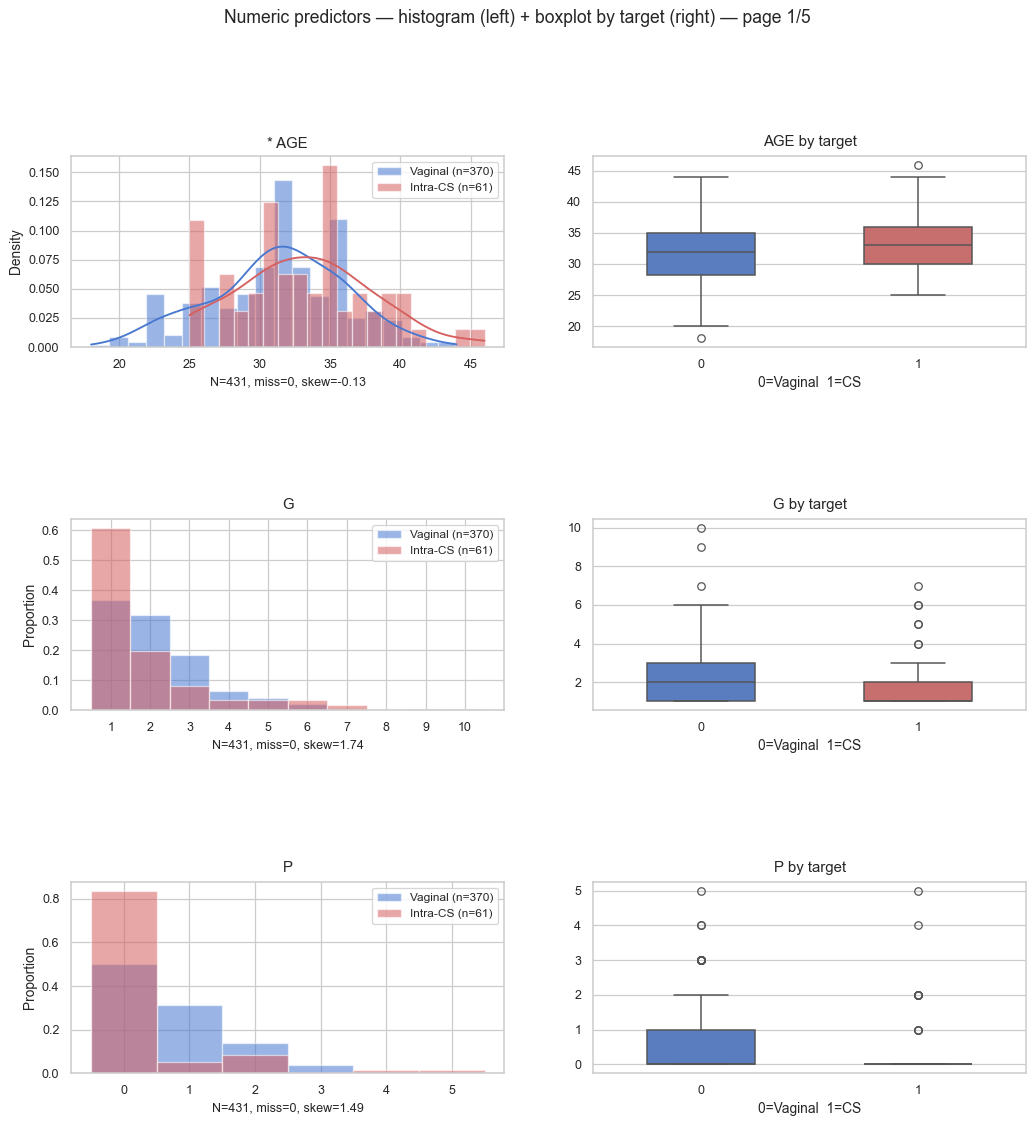

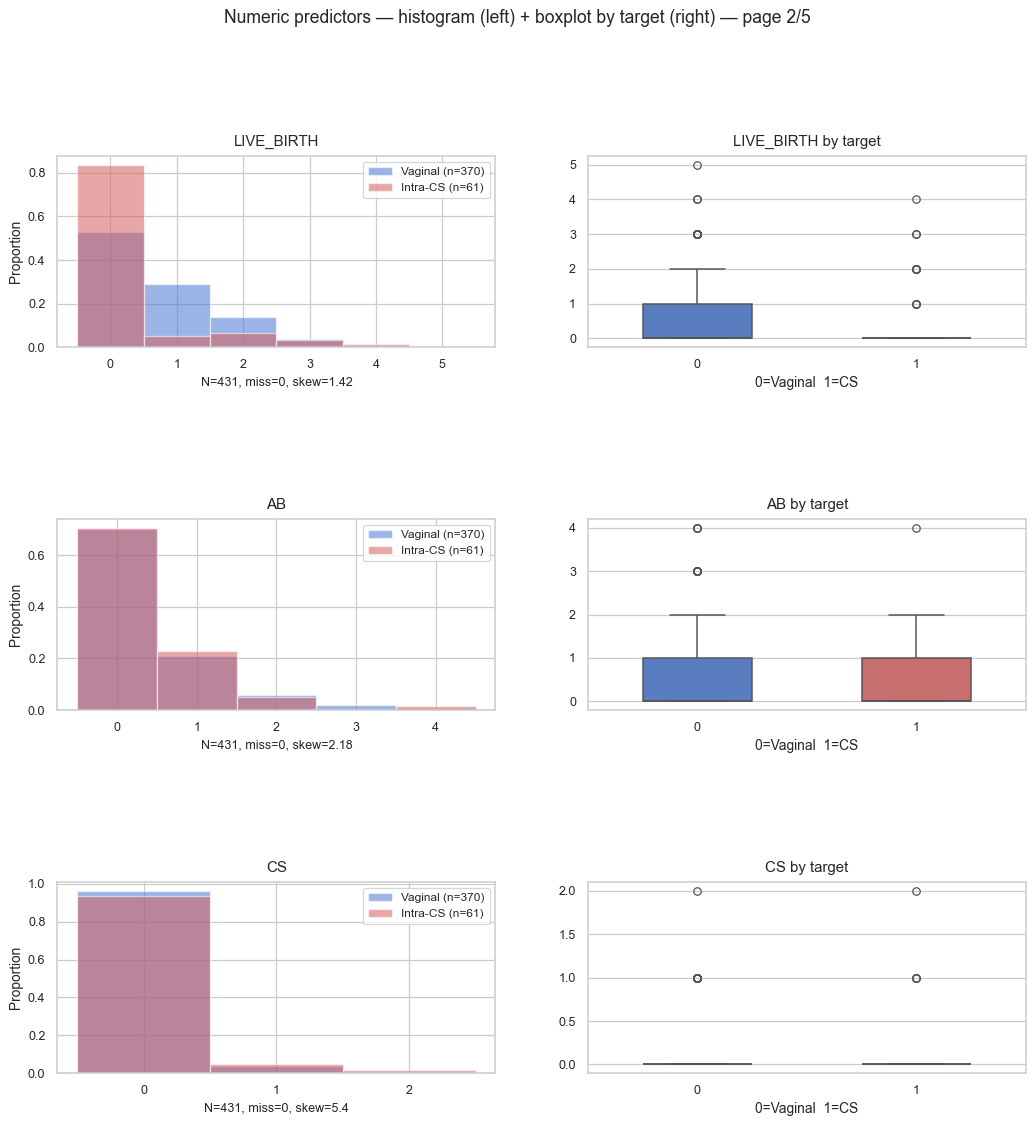

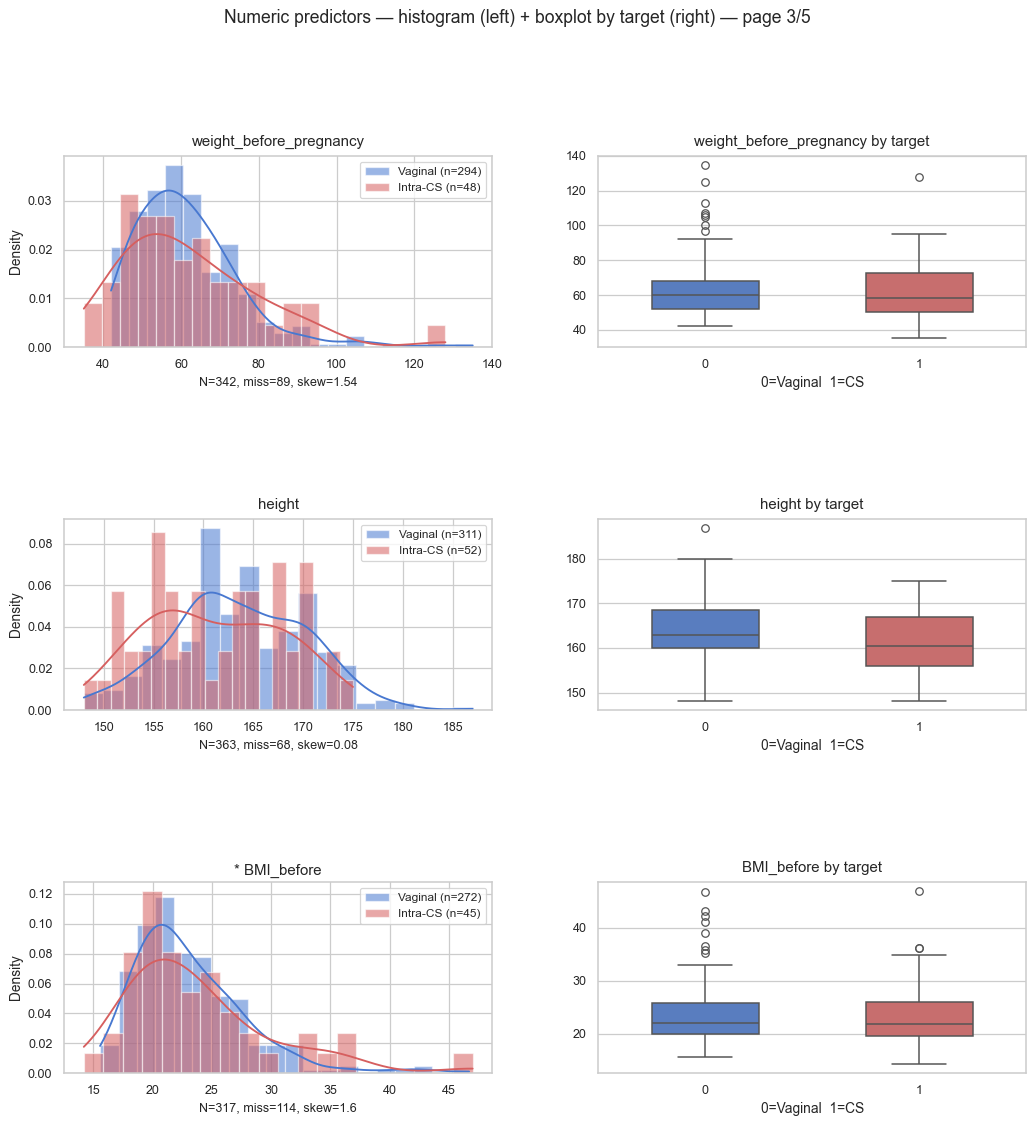

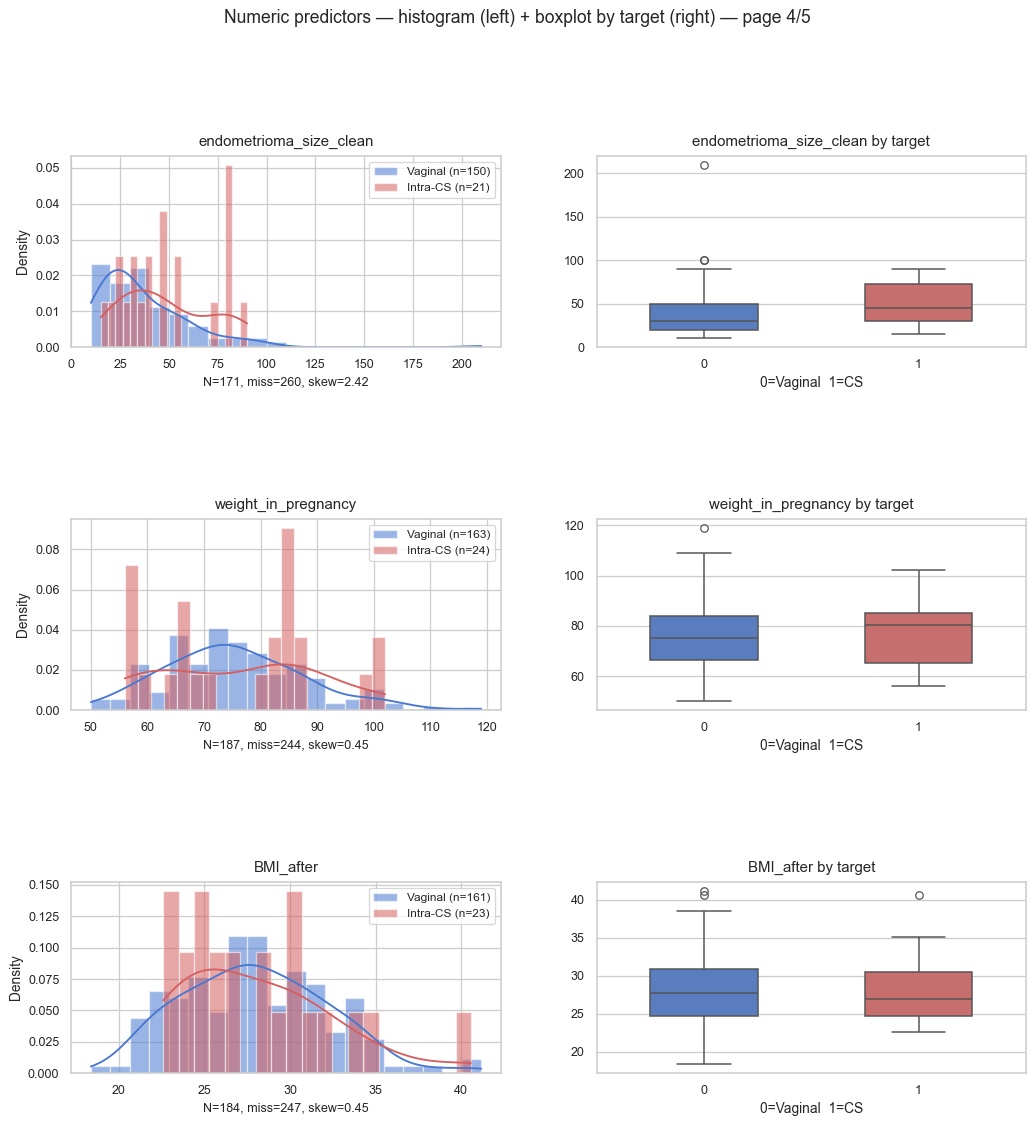

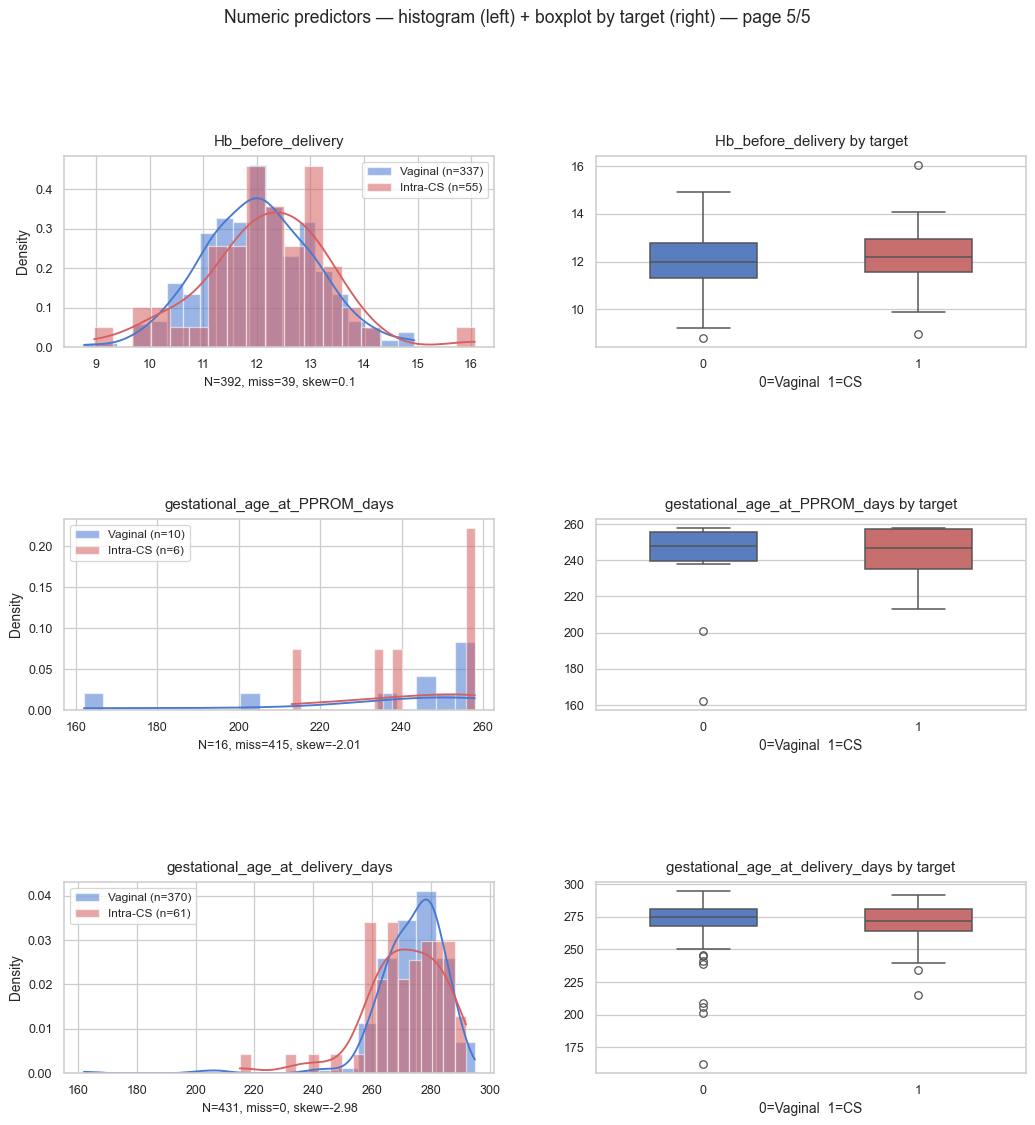


* = PRIORITY_VARS (receives additional domain-specific interpretation in A2.5/A2.6).
Discrete count variables (G, P, LIVE_BIRTH, AB, CS) use integer-aligned bins,
not a continuous-density histogram, to avoid implying false granularity.


In [8]:
_all_num_vars = [c for c in PRIMARY_COLS if infer_var_type(df_primary[c]) == "numeric"]
print(f"Numeric PRIMARY_COLS modeling-pathway variables in the primary pool: {len(_all_num_vars)}")
print(f"  {_all_num_vars}")
print(f"  (of which PRIORITY_VARS, marked with a star below): "
      f"{[c for c in _all_num_vars if c in PRIORITY_VARS]}")

# Paginated so no single figure becomes unreadably tall/cramped. At 6
# variables/page (the prior density), each row's title and its neighbor's
# bottom xlabel annotation (N=/miss=/skew=) sat close enough together that
# plt.tight_layout()'s automatic spacing was not generous enough to keep
# adjacent rows visually separated -- confirmed by direct visual inspection
# of the rendered figure. Fixed by (1) capping density at 3 variables/page
# (14 numeric PRIMARY_COLS vars -> 5 pages instead of 3) and (2) switching
# from tight_layout() to Matplotlib's constrained-layout engine with
# explicit, generous inter-row/inter-column padding -- a single coherent
# layout system rather than stacking tight_layout on top of a manual
# suptitle y-offset (the prior fig.suptitle(..., y=1.002) had no rect/pad
# reserved for it under tight_layout, risking collision with row 1).
_PAGE_SIZE = 3
_ROW_HEIGHT_IN = 4.5  # generous fixed height per variable row
_pages = [_all_num_vars[i:i + _PAGE_SIZE] for i in range(0, len(_all_num_vars), _PAGE_SIZE)]
for _pg_i, _page_vars in enumerate(_pages, start=1):
    _n_v = len(_page_vars)
    fig, axes = plt.subplots(
        _n_v, 2, figsize=(12, _ROW_HEIGHT_IN * _n_v), layout="constrained",
        squeeze=False,
    )
    # constrained_layout reflows automatically as content is added, but the
    # default padding is tuned for compact figures -- explicitly widen it so
    # row titles/xlabels never sit flush against the neighboring row.
    fig.get_layout_engine().set(w_pad=0.35, h_pad=0.6, hspace=0.08, wspace=0.06)
    for i, col in enumerate(_page_vars):
        plot_numeric_dist(df_primary, col, TARGET_COL, axes[i][0], axes[i][1])
        if col in PRIORITY_VARS:
            axes[i][0].set_title(f"* {axes[i][0].get_title()}", fontsize=12)
    fig.suptitle(f"Numeric predictors — histogram (left) + boxplot by target (right) "
                 f"— page {_pg_i}/{len(_pages)}", fontsize=14)
    plt.show()
print()
print("* = PRIORITY_VARS (receives additional domain-specific interpretation in A2.5/A2.6).")
print("Discrete count variables (G, P, LIVE_BIRTH, AB, CS) use integer-aligned bins,")
print("not a continuous-density histogram, to avoid implying false granularity.")

In [9]:
_all_num = [c for c in PRIMARY_COLS if infer_var_type(df_primary[c]) == "numeric"]
_skew_rows = []
for col in _all_num:
    s = df_primary[col].dropna()
    _iqr = iqr_bounds(df_primary[col])
    _skew_rows.append({
        "variable":      col,
        "earliest_entry_stage": PRIMARY_COLS_EARLIEST_STAGE.get(col),
        "N":             len(s),
        "N_missing":     df_primary[col].isna().sum(),
        "n_unique":      int(s.nunique()),
        "mean":          round(s.mean(), 2) if len(s) else None,
        "SD":            round(s.std(), 2) if len(s) else None,
        "median":        round(s.median(), 2) if len(s) else None,
        "Q1":            _iqr["Q1"],
        "Q3":            _iqr["Q3"],
        "IQR":           _iqr["IQR"],
        "min":           round(s.min(), 2) if len(s) else None,
        "max":           round(s.max(), 2) if len(s) else None,
        "skewness":      round(s.skew(), 3) if len(s) else None,
        "high_skew_flag": abs(s.skew()) > 1.5 if len(s) else False,
        "iqr_lower_bound": _iqr["lower_bound"],
        "iqr_upper_bound": _iqr["upper_bound"],
        "n_iqr_flagged": _iqr["n_flagged"],
        "pct_iqr_flagged": _iqr["pct_flagged"],
        "iqr_zero":      _iqr["iqr_zero"],
        "priority":      col in PRIORITY_VARS,
    })
skew_df = pd.DataFrame(_skew_rows).sort_values("skewness", key=abs, ascending=False)
print("Numeric predictor full descriptive-statistics table (sorted by |skewness|):")
print(skew_df.to_string(index=False))
_high = skew_df[skew_df["high_skew_flag"]]
print(f"\n  High-skew variables (|skewness|>1.5): {len(_high)}")
print("  Descriptive audit information only -- skewness alone never triggers or "
      "selects a transform (Data Cleaning B Section B3 / EDA C Section C14).")
for _, r in _high.iterrows():
    print(f"    {r['variable']}: skew={r['skewness']}")

# zero-IQR variables (e.g. CS) get real Q1/Q3/IQR
# values above but iqr_lower_bound/iqr_upper_bound/n_iqr_flagged are
# withheld (NaN/0) by iqr_bounds() -- explicitly reported here rather than
# silently reading as "0 outliers found", matching EDA A Part 1 Section A8's
# existing behavior for the same situation.
_skew_iqr_zero = skew_df[skew_df["iqr_zero"]]
if len(_skew_iqr_zero):
    print(f"\n  Variables with IQR == 0 ({len(_skew_iqr_zero)}) -- standard 1.5x-IQR "
          f"flagging is not informative for these and none was performed, but Q1/Q3/IQR "
          f"remain reported above: {_skew_iqr_zero['variable'].tolist()}")

print()
print("Interpretation: this table is descriptive only. IQR flagging is target-blind:")
print("the observed outcome plays no part in whether a value is flagged. A2.11 performs")
print("a deeper target-blind data-quality review of the same flagged values; its")
print("separate outcome-sensitivity block is purely descriptive and does not determine")
print("whether a flagged value is an outlier or an error. A high skew or outlier count")
print("does not, by itself, exclude a variable from the candidate pool.")

Numeric predictor full descriptive-statistics table (sorted by |skewness|):
                        variable  earliest_entry_stage   N  N_missing  n_unique    mean     SD  median      Q1      Q3    IQR     min     max  skewness  high_skew_flag  iqr_lower_bound  iqr_upper_bound  n_iqr_flagged  pct_iqr_flagged  iqr_zero  priority
                              CS                     1 431          0         3   0.050  0.230   0.000   0.000   0.000  0.000   0.000   2.000     5.404            True              NaN              NaN              0              NaN      True     False
gestational_age_at_delivery_days                     3 431          0        53 273.130 12.770 275.000 267.000 281.000 14.000 162.000 295.000    -2.977            True          246.000          302.000             10            2.300     False     False
         endometrioma_size_clean                     1 171        260        44  38.420 25.160  30.000  20.000  50.000 30.000  10.000 210.000     2.423           

**Key observations — numeric distributions:**

In [10]:
print(f"- {len(skew_df)} numeric predictors summarized; "
      f"{int(skew_df['high_skew_flag'].sum())} flagged high-skew (|skew|>1.5): "
      f"{skew_df.loc[skew_df['high_skew_flag'], 'variable'].tolist()}.")
_ko6_out = skew_df[skew_df["n_iqr_flagged"] > 0].sort_values("pct_iqr_flagged", ascending=False)
if len(_ko6_out):
    print(f"- {len(_ko6_out)} numeric predictor(s) have IQR-flagged values, highest rate "
          f"'{_ko6_out.iloc[0]['variable']}' ({_ko6_out.iloc[0]['pct_iqr_flagged']}%) -- "
          f"clinically plausible extremes until reviewed in A2.11; none removed here.")
print("- Skew and outlier counts are descriptive; they inform the EDA C transformation")
print("  plan but do not by themselves justify removing or transforming a variable now.")

- 15 numeric predictors summarized; 8 flagged high-skew (|skew|>1.5): ['CS', 'gestational_age_at_delivery_days', 'endometrioma_size_clean', 'AB', 'gestational_age_at_PPROM_days', 'G', 'BMI_before', 'weight_before_pregnancy'].
- 14 numeric predictor(s) have IQR-flagged values, highest rate 'gestational_age_at_PPROM_days' (12.5%) -- clinically plausible extremes until reviewed in A2.11; none removed here.
- Skew and outlier counts are descriptive; they inform the EDA C transformation
  plan but do not by themselves justify removing or transforming a variable now.


## Section A2.4 — Binary and Categorical Distributions: Full Coverage

**Purpose:** Document the event rate (positivity rate), contingency-table test, and
near-zero-variance status for every binary predictor, and full level-count +
target-stratified bar-plot coverage for every categorical predictor.

**What this checks:**
- Positivity rate in vaginal group vs CS group for every binary PRIMARY_COLS
  variable (exact count derived from PRIMARY_COLS and printed in the output below)
- Absolute difference in positivity rate (sorted descending)
- Chi-square or Fisher exact test (auto-selected on expected-cell adequacy,
  matching A2.9's test-selection rule), Cramér's V, minimum expected cell count
- Separation flag: any group with 0 positive events
- Near-zero-variance flag (descriptive only — see the Part 1 helper docstring for
  the exact rule): a dominant category ≥99% or, for exactly 2 categories, a
  minority count <5. This is a distinct, purely descriptive concept from **true**
  zero variance — true zero-variance columns are excluded entirely, upstream, in
  Section A2.2's scope construction (`is_true_zero_variance_for_exclusion()`, a
  target-independent, value-only rule), so they never reach `PRIMARY_COLS` or this
  table at all. The near-zero-variance flag computed here never excludes or
  reclassifies a variable
- Level counts, percentages, and target-stratified bar plot for every categorical
  predictor (exact count derived live from PRIMARY_COLS, printed below)

**What this does NOT do:**
- Does not replace A2.9's full formal association ranking (this section's tests are
  reported per-variable here for completeness; A2.9 remains the primary ranked table)
- No transformation or imputation
- Near-zero-variance flags do not change eligibility

**Output:** Full rate + test table (every binary variable) + paginated grouped
bar-chart grids (every binary + every categorical predictor) + categorical level-count table

**Finding a specific Stage 2/3 variable:** every table and plot below covers all
stages together (`earliest_entry_stage` is shown per variable in each table); the
paginated grids page through every stage mixed together, so a single Stage 2 or
Stage 3 variable is not visually isolated here. For a compact, dedicated view of
just the Stage 2-only and Stage 3-only variables (5 and 5 variables respectively as
of the current working-frame classification — see Section A2.2's scope-construction
output above for the live, authoritative count), see Section A2.13's Stage 2-only/
Stage 3-only summary chart.

Binary predictors — full rate + test table (all 45, sorted by abs difference):
                                      variable  earliest_entry_stage  N_analyzed  N_missing  vaginal_N  cs_N              vaginal_pos_%                   cs_pos_%                 abs_diff_%             vaginal_events                  cs_events  separation_risk  min_expected_cell         test  p_value  cramers_v  near_zero_variance  priority
                             induction_any_bin                     3         431          0        370    61                     39.700                     77.000                     37.300                        147                         47            False             27.460   chi-square    0.000      0.261               False     False
                                   nulliparity                     1         431          0        370    61                     50.300                     83.600                     33.300                        186                   

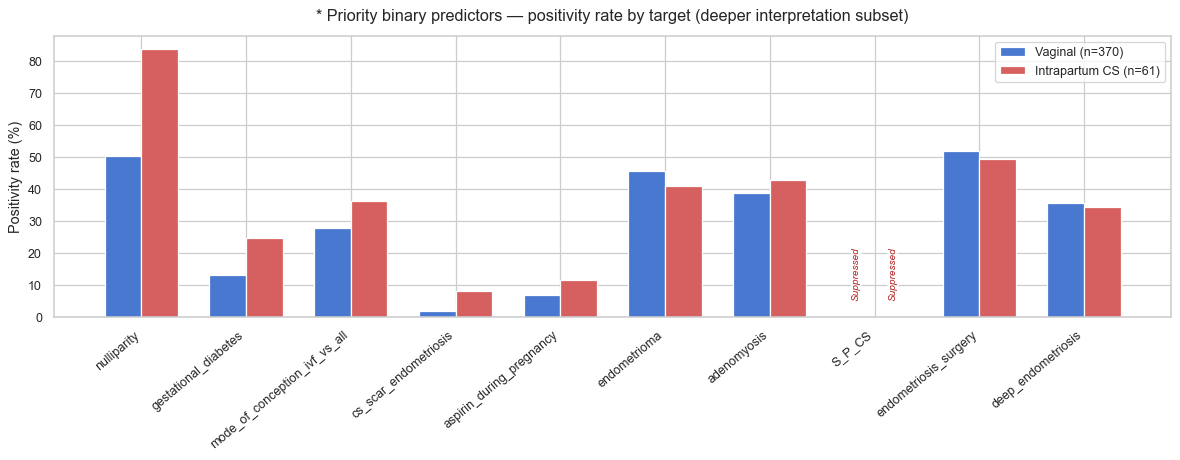

In [11]:
_g0 = df_primary[df_primary[TARGET_COL] == 0]
_g1 = df_primary[df_primary[TARGET_COL] == 1]
_rate_rows = []
_all_bin = [c for c in PRIMARY_COLS if infer_var_type(df_primary[c]) == "binary"]

for col in _all_bin:
    sub = df_primary[[col, TARGET_COL]].dropna(subset=[col])
    g0s = sub[sub[TARGET_COL] == 0]
    g1s = sub[sub[TARGET_COL] == 1]
    n_pos0 = int((g0s[col] == 1).sum())
    n_pos1 = int((g1s[col] == 1).sum())
    r0 = round(n_pos0 / len(g0s) * 100, 1) if len(g0s) else None
    r1 = round(n_pos1 / len(g1s) * 100, 1) if len(g1s) else None
    diff = round(abs(r1 - r0), 1) if (r0 is not None and r1 is not None) else None
    sep  = (n_pos1 == 0 or (len(g1s) - n_pos1) == 0)
    # Canonical dict API: chi2_or_fisher() returns a
    # dict, not a positional tuple -- unpacking it positionally (e.g.
    # `pv, test, _ = chi2_or_fisher(...)`) raises ValueError (too many values
    # to unpack), which a broad `except Exception` previously swallowed into a
    # silent test="error"/p=None row. No try/except here: a genuinely
    # unexpected failure on a validated, non-empty PRIMARY_COLS column should
    # fail loudly rather than render as a misleading "error" result.
    _res = chi2_or_fisher(col, df_primary, TARGET_COL)
    _pv, _test = _res["p_value"], _res["test"]
    _ct = pd.crosstab(sub[col], sub[TARGET_COL])
    _exp = stats.chi2_contingency(_ct, correction=False)[3] if _ct.shape == (2, 2) else None
    _min_exp = round(float(_exp.min()), 2) if _exp is not None else None
    _v = cramers_v(_ct)
    _nzv_flag, _nzv_frac, _ = near_zero_variance_flag(df_primary[col])
    _rate_rows.append({
        "variable":         col,
        "earliest_entry_stage": PRIMARY_COLS_EARLIEST_STAGE.get(col),
        "N_analyzed":       len(sub),
        "N_missing":        df_primary[col].isna().sum(),
        "vaginal_N":        len(g0s),
        "cs_N":             len(g1s),
        "vaginal_pos_%":    r0,
        "cs_pos_%":         r1,
        "abs_diff_%":       diff,
        "vaginal_events":   n_pos0,
        "cs_events":        n_pos1,
        "separation_risk":  sep,
        "min_expected_cell": _min_exp,
        "test":             _test,
        "p_value":          _pv,
        "cramers_v":        _v,
        "near_zero_variance": _nzv_flag,
        "priority":         col in PRIORITY_VARS,
    })

rate_df = pd.DataFrame(_rate_rows).sort_values("abs_diff_%", ascending=False, na_position="last")
# Share-safe display copy: cs_events is a
# raw event count that can be small for a rare binary predictor -- suppressed
# in the printed table when SHARE_SAFE_MODE is on. The underlying rate_df
# keeps real values for downstream computation (e.g. near-zero-variance
# flagging above, which is already computed before this point).
#
# cs_pos_%/vaginal_pos_% are suppressed on the same n<5 (numerator or
# complement) rule as cs_events: since the per-column group denominator
# (cs_N/vaginal_N) is also shown, printing cs_pos_% alone would reconstruct a
# suppressed cs_events count, so both percentage columns and vaginal_events
# must be protected together with it.
_rate_display = rate_df.copy()
# Centralized binary target-stratified display protection: every rendered
# surface in this notebook (and A1's own A6 table) that shows a binary
# predictor's vaginal/CS positive count uses ONE shared decision --
# share_safe.suppress_binary_target_display() -- rather than an independent
# per-surface check, because a "safe-looking" count shown on one side could
# otherwise combine with A1's separately-reported unstratified total
# (n_positive = vaginal_events + cs_events, by construction) to recover a
# protected complement. See that function's own docstring for the full
# rationale (both the same-group-negative-cell axis and the cross-group
# total-positive axis).
_vag_cs_disp = [
    share_safe.suppress_binary_target_display(
        int(_vn), int(_cn), int(_vd), int(_cd), enabled=SHARE_SAFE_MODE
    )
    for _vn, _cn, _vd, _cd in zip(
        rate_df["vaginal_events"], rate_df["cs_events"], rate_df["vaginal_N"], rate_df["cs_N"]
    )
]
_rate_display["vaginal_events"] = [v for v, c in _vag_cs_disp]
_rate_display["cs_events"] = [c for v, c in _vag_cs_disp]
# Percentage suppression is driven by whether the corresponding event count
# above was suppressed (either reason), so the two columns can never
# disagree about whether a given cell is protected.
_rate_display["cs_pos_%"] = [
    p if not isinstance(disp, str) else "suppressed (n<5 in a cell)"
    for disp, p in zip(_rate_display["cs_events"], rate_df["cs_pos_%"])
]
_rate_display["vaginal_pos_%"] = [
    p if not isinstance(disp, str) else "suppressed (n<5 in a cell)"
    for disp, p in zip(_rate_display["vaginal_events"], rate_df["vaginal_pos_%"])
]
# abs_diff_% (a difference of two percentages) can indirectly re-derive a
# suppressed individual percentage if the other one is shown -- suppress it
# too whenever either underlying group percentage was suppressed. rate_df
# itself (used for sorting/plotting above) is unaffected -- only this
# printed display copy.
_rate_display["abs_diff_%"] = [
    "suppressed (n<5 in a cell)"
    if (isinstance(cs, str) or isinstance(vg, str)) else diff
    for cs, vg, diff in zip(_rate_display["cs_pos_%"], _rate_display["vaginal_pos_%"], rate_df["abs_diff_%"])
]
print(f"Binary predictors — full rate + test table (all {len(_all_bin)}, sorted by abs difference):")
print(_rate_display.to_string(index=False))
_nzv_bin = rate_df[rate_df["near_zero_variance"]]
print(f"\nNear-zero-variance binary predictors (descriptive flag only, not excluded): "
      f"{len(_nzv_bin)}")
for _, r in _nzv_bin.iterrows():
    _safe_events = share_safe.safe_count(r["cs_events"], enabled=SHARE_SAFE_MODE)
    # Row-specific analyzed CS-group N (cs_N), not the global cohort-wide n1
    # -- a column with any missingness has cs_N < n1 (e.g. severe_PET,
    # cs_N=60 vs n1=61), so using the global n1 here understated the true
    # analyzed denominator for such columns. The main rate_df table above
    # already reports cs_N correctly per row; this footnote now matches it.
    print(f"    {r['variable']}: cs_events={_safe_events}/{int(r['cs_N'])}, test={r['test']}, "
          f"p={r['p_value']} -- sparse-event effect estimate; interpret with caution")

# Bar chart — priority binary variables (deeper-interpretation subset)
#
# Share-safe: bar heights must come from the already-suppressed
# _rate_display, not the RAW rate_df -- a suppressed percentage's exact bar
# height is just as disclosive as printing the number, whether or not the
# TABLE shows it. Bar heights are taken from _rate_display (aligned by
# the shared row index), converting any suppression marker to NaN (no bar
# rendered) with an explicit 'Suppressed' text annotation, mirroring the
# convention already used elsewhere in this notebook (Section A2.13's
# stage-only-outcome graphs) -- a suppressed rate is UNKNOWN to the reader,
# never rendered as a 0-height bar.
def _bin_plot_value(display_value):
    return float(display_value) if isinstance(display_value, (int, float)) else np.nan


def _bin_annotate_suppressed(ax, x, y=5, fontsize=8):
    ax.text(x, y, "Suppressed", ha="center", va="bottom", fontsize=fontsize,
            fontstyle="italic", color="firebrick", rotation=90,
            bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.8))


_prio_bin = rate_df[rate_df["priority"]].dropna(subset=["abs_diff_%"]).head(16)
if len(_prio_bin):
    _prio_display = _rate_display.loc[_prio_bin.index]
    _prio_vag_plot = [_bin_plot_value(v) for v in _prio_display["vaginal_pos_%"]]
    _prio_cs_plot = [_bin_plot_value(v) for v in _prio_display["cs_pos_%"]]
    x   = range(len(_prio_bin))
    w   = 0.35
    fig, ax = plt.subplots(figsize=(13, 5), layout="constrained")
    ax.bar([i - w/2 for i in x], _prio_vag_plot, w,
           label=f"Vaginal (n={n0})", color=C0)
    ax.bar([i + w/2 for i in x], _prio_cs_plot, w,
           label=f"Intrapartum CS (n={n1})", color=C1)
    for _i, (_v, _c) in enumerate(zip(_prio_vag_plot, _prio_cs_plot)):
        if np.isnan(_v):
            _bin_annotate_suppressed(ax, _i - w/2)
        if np.isnan(_c):
            _bin_annotate_suppressed(ax, _i + w/2)
    ax.set_xticks(list(x))
    ax.set_xticklabels(_prio_bin["variable"].tolist(), rotation=40, ha="right", fontsize=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.set_ylabel("Positivity rate (%)", fontsize=11.5)
    ax.set_title("* Priority binary predictors — positivity rate by target "
                 "(deeper interpretation subset)", fontsize=13, pad=12)
    ax.legend(fontsize=10)
    plt.show()

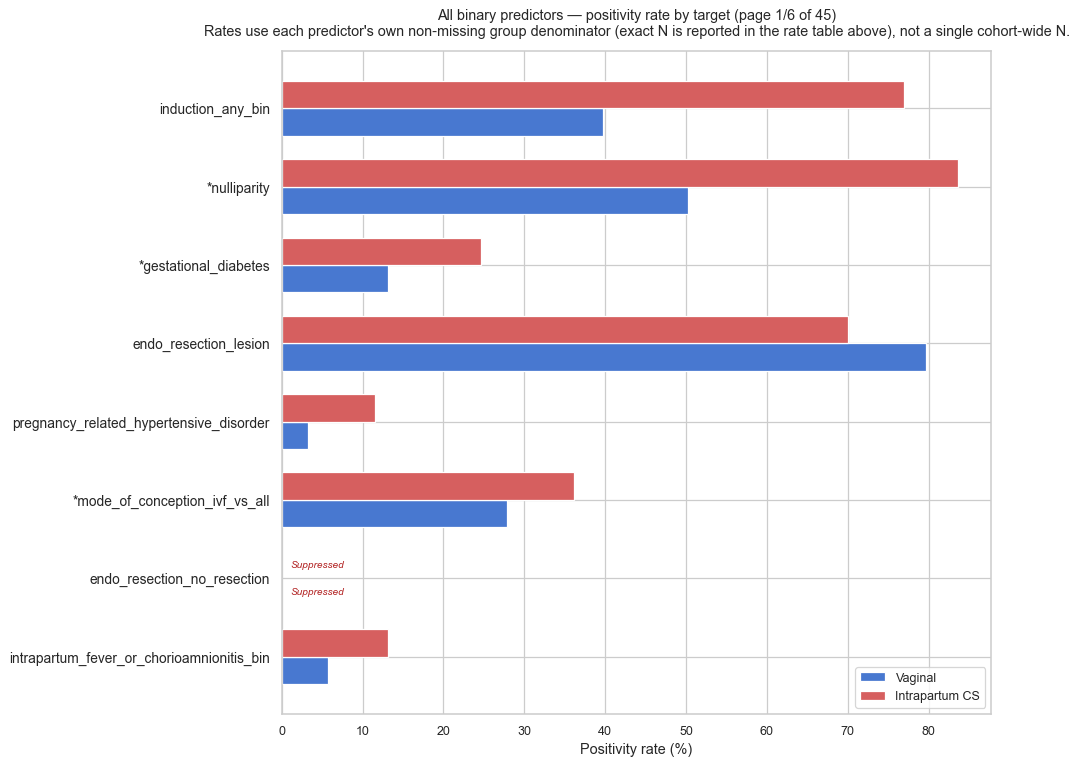

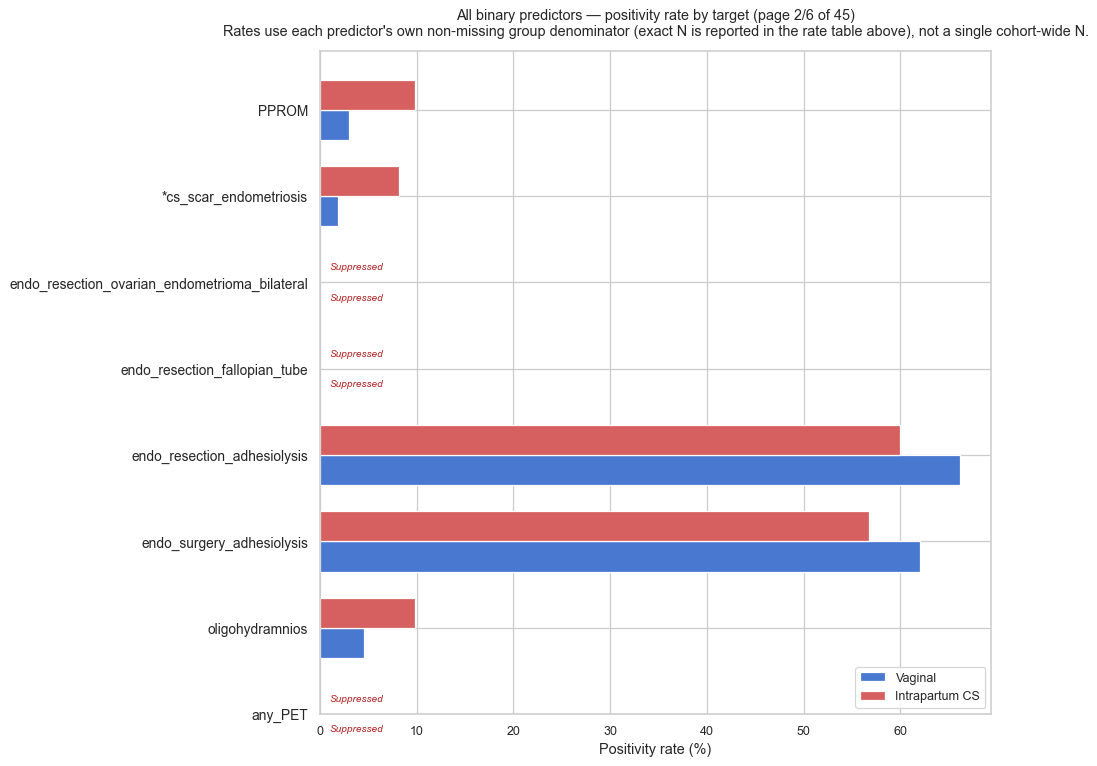

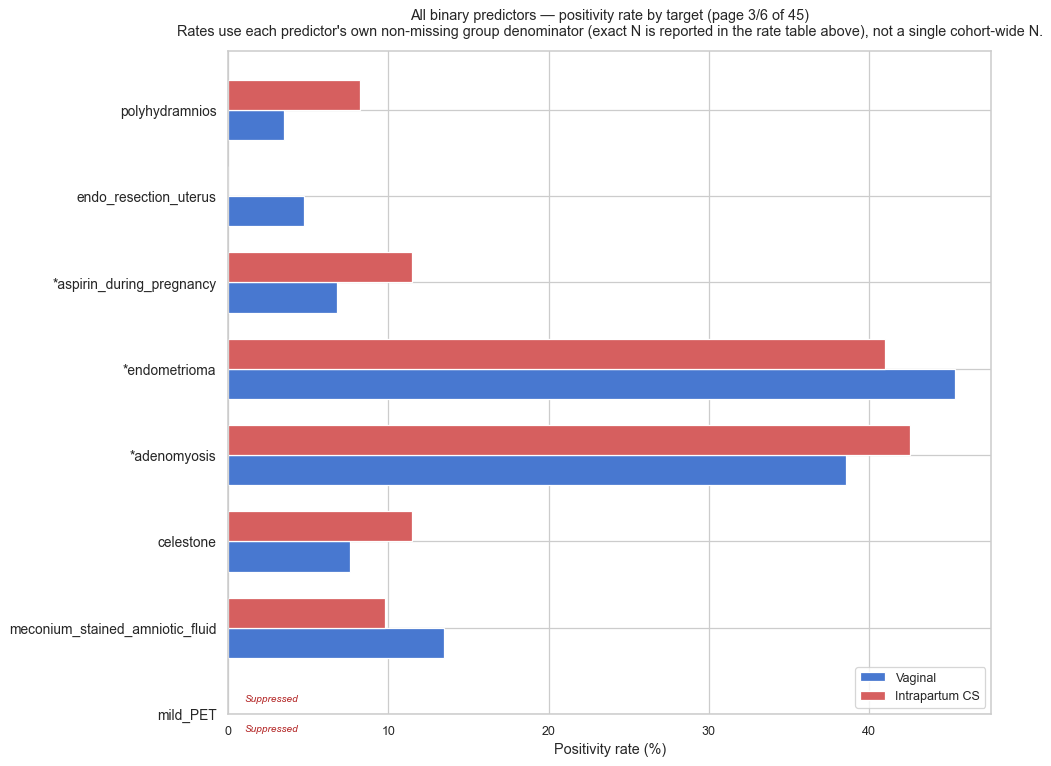

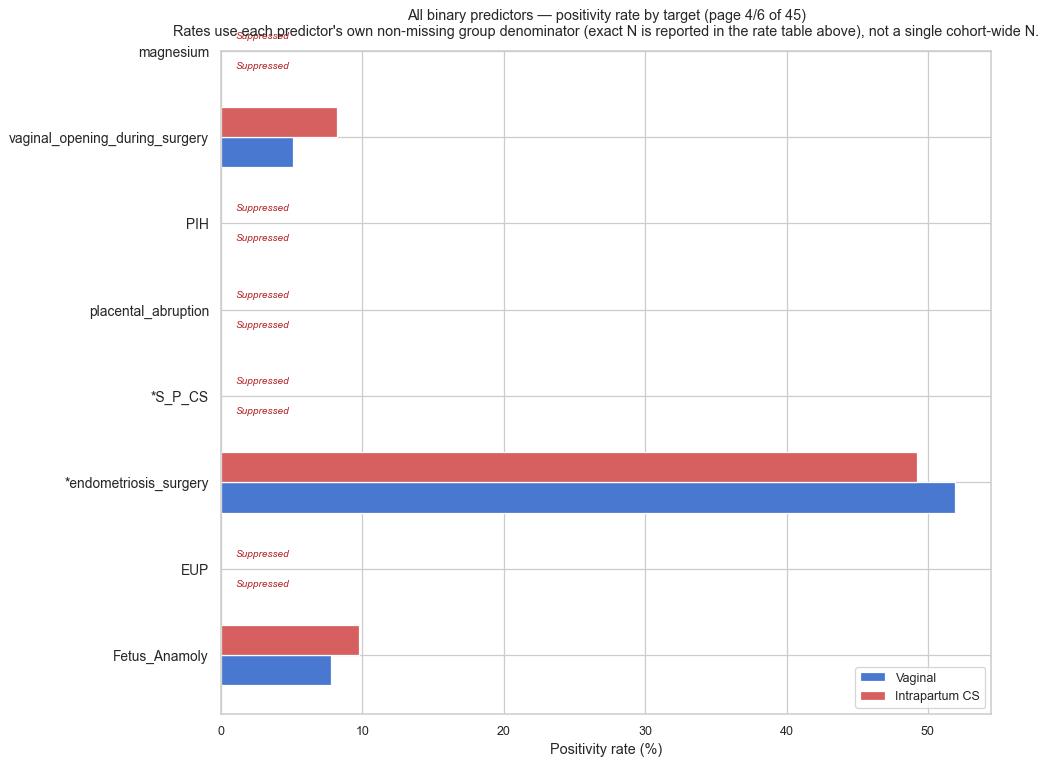

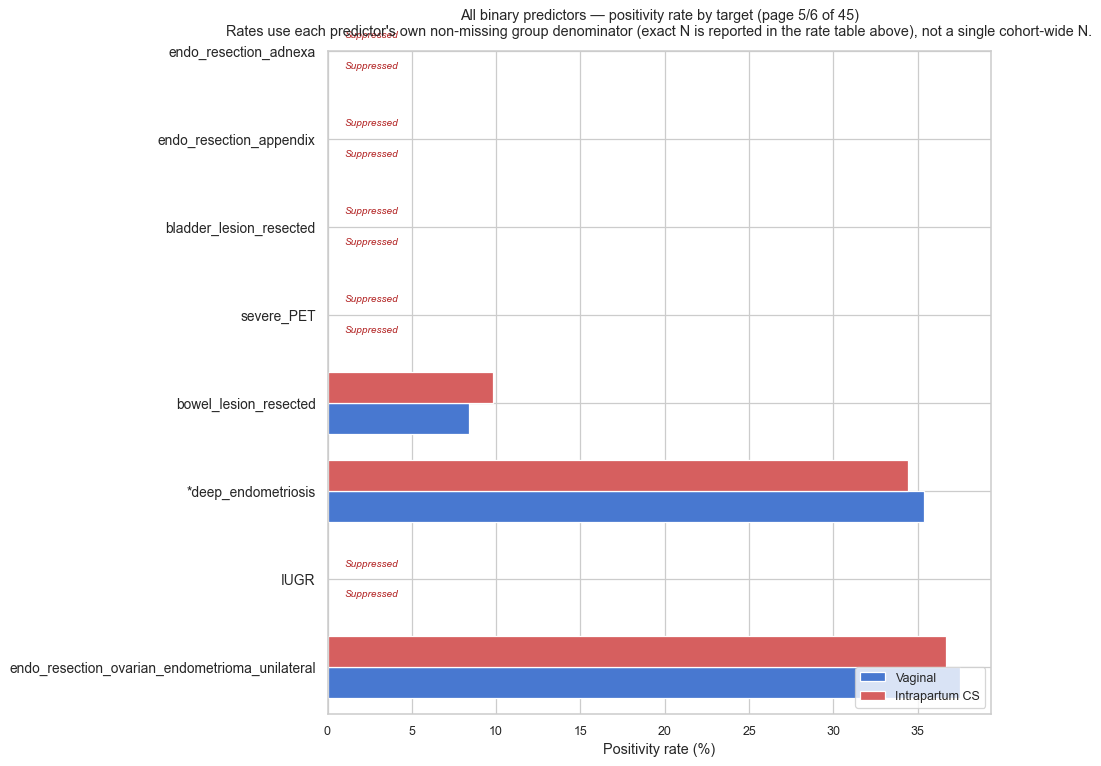

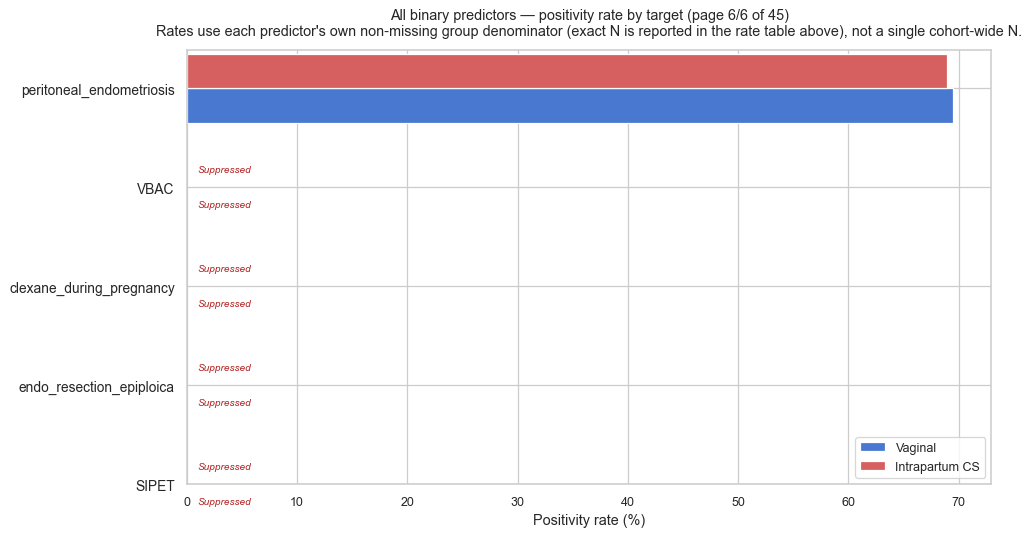

Full binary bar-chart coverage: 45 of 45 binary predictors plotted across the pages above.


In [12]:
# Full coverage: paginated grouped bar charts for ALL binary predictors in
# rate_df (not only the priority subset above), so no binary predictor is
# plot-omitted. The count is derived live below (len(_bin_order)) and printed
# in both the chart titles and the summary line -- never hardcoded here.
# Horizontal orientation (predictor names on the y-axis, 8/page) so long
# predictor names stay readable without steep label rotation -- a 12/page
# vertical-bar layout with 45-degree rotated labels was still too crowded for
# publication/report reuse.
# Share-safe: plotted from _rate_display (the already share-safe-suppressed
# copy built in the previous cell), not raw rate_df -- same rationale as the
# priority chart above. Suppression markers are
# converted to NaN (no bar rendered) with an explicit 'Suppressed'
# annotation via _bin_plot_value()/_bin_annotate_suppressed() (defined in
# the previous cell, reused here unchanged).
_PAGE_SIZE_BIN = 8
_bin_order = rate_df["variable"].tolist()
_bin_pages = [_bin_order[i:i + _PAGE_SIZE_BIN] for i in range(0, len(_bin_order), _PAGE_SIZE_BIN)]
for _pg_i, _page_vars in enumerate(_bin_pages, start=1):
    _pg_df = _rate_display[_rate_display["variable"].isin(_page_vars)].set_index("variable").loc[_page_vars]
    _pg_vag_plot = [_bin_plot_value(v) for v in _pg_df["vaginal_pos_%"]]
    _pg_cs_plot = [_bin_plot_value(v) for v in _pg_df["cs_pos_%"]]
    y = range(len(_pg_df))
    h = 0.35
    fig, ax = plt.subplots(figsize=(11, max(4.5, 0.85 * len(_pg_df) + 1.6)), layout="constrained")
    # No global N in the legend: each bar's rate uses that PREDICTOR's own
    # non-missing group denominator (vaginal_N/cs_N in rate_df above), which
    # differs by variable whenever there is any missingness (e.g. the
    # endo_resection_* family: vaginal_N=192/cs_N=30, vs. the full-cohort
    # n0=370/n1=61) -- a single global n0/n1 in the legend previously misstated
    # the analyzed denominator for such columns.
    ax.barh([j + h/2 for j in y], _pg_vag_plot, h,
            label="Vaginal", color=C0)
    ax.barh([j - h/2 for j in y], _pg_cs_plot, h,
            label="Intrapartum CS", color=C1)
    for _j, (_v, _c) in enumerate(zip(_pg_vag_plot, _pg_cs_plot)):
        if np.isnan(_v):
            ax.text(1, _j + h/2, "Suppressed", ha="left", va="center", fontsize=8,
                    fontstyle="italic", color="firebrick",
                    bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.8))
        if np.isnan(_c):
            ax.text(1, _j - h/2, "Suppressed", ha="left", va="center", fontsize=8,
                    fontstyle="italic", color="firebrick",
                    bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.8))
    ax.set_yticks(list(y))
    ax.set_yticklabels(
        [f"*{v}" if v in PRIORITY_VARS else v for v in _pg_df.index],
        fontsize=11
    )
    ax.invert_yaxis()
    ax.tick_params(axis="x", labelsize=10)
    ax.set_xlabel("Positivity rate (%)", fontsize=11.5)
    ax.set_title(f"All binary predictors — positivity rate by target "
                 f"(page {_pg_i}/{len(_bin_pages)} of {len(_bin_order)})\n"
                 f"Rates use each predictor's own non-missing group denominator "
                 f"(exact N is reported in the rate table above), not a single cohort-wide N.",
                 fontsize=11.5, pad=12)
    ax.legend(fontsize=10, loc="lower right")
    plt.show()
print(f"Full binary bar-chart coverage: {len(_bin_order)} of {len(_bin_order)} "
      "binary predictors plotted across the pages above.")

In [13]:
_cat_vars = [c for c in PRIMARY_COLS if infer_var_type(df_primary[c]) == "categorical"]
print(f"Categorical PRIMARY_COLS modeling-pathway variables: {len(_cat_vars)}  {_cat_vars}")
if not _cat_vars:
    print("No multi-level categorical primary predictors.")
else:
    # Small-cell disclosure guard: reuses this
    # project's existing sparse-cell convention (n < 5 -- the same threshold
    # already used for A2.8's too_sparse/min_expected_cell, and for the
    # small-subgroup disclosure guard in eda_a_part2_summaries.py) rather than
    # inventing a new one. Printing every level's exact total/vaginal/CS count
    # unconditionally previously exposed near-patient-level cells for real --
    # several categorical predictors in this cohort have one or more levels
    # with a handful of patients each. Any level with total N < 5 is now
    # combined into one suppressed bucket instead of printed individually;
    # raw per-patient counts stay available internally (cramers_v/
    # chi2_or_fisher below still use the full, unsuppressed contingency table).
    _CAT_MIN_DISCLOSURE_N = 5
    _cat_test_rows = []
    for col in _cat_vars:
        sub = df_primary[[col, TARGET_COL]].dropna(subset=[col])
        g0s = sub[sub[TARGET_COL] == 0]
        g1s = sub[sub[TARGET_COL] == 1]
        _n_levels = sub[col].nunique()
        _vc = sub[col].value_counts()
        _rare_levels = _vc[_vc < 10].index.tolist()  # rare-category rule: count < 10,
        # consistent with this project's existing A2.8 sparsity "rare_flag" convention.
        print(f"  {col} (N={len(sub)}, miss={df_primary[col].isna().sum()}, "
              f"{_n_levels} levels, rare levels (<10 obs, count only -- see suppression "
              f"below): {len(_rare_levels)}):")
        # Reconstruction-aware combination: a naive "combine every level with
        # count<5 into one bucket" guard is not enough on its own -- if only
        # ONE level ever needed combining, the bucket's own total IS that
        # level's exact count, and withholding that total would not help
        # either, since N is
        # printed on the header line above and every OTHER level is shown
        # individually -- a reader can recompute the same exact value as
        # N minus the sum of the shown levels regardless.
        # safe_combine_rare_levels() instead folds levels into the combined
        # bucket smallest-first until the bucket's own total is empty or
        # safely >= threshold (folding in an otherwise-safe level if
        # necessary), so neither the printed aggregate nor the N-minus-shown-
        # levels arithmetic can isolate any single rare level's exact count.
        _level_totals = {lv: int((sub[col] == lv).sum()) for lv in _vc.index[:10]}
        _visible_levels, _below_n, _below_k = share_safe.safe_combine_rare_levels(
            _level_totals, threshold=_CAT_MIN_DISCLOSURE_N
        )
        for lv in _vc.index[:10]:
            if lv not in _visible_levels:
                continue
            n_tot  = _visible_levels[lv]
            n_cs   = int((g1s[col] == lv).sum())
            n_vag  = int((g0s[col] == lv).sum())
            # Share-safe: n_tot>=5 (checked above) does not
            # guarantee its target-group split does -- e.g. n_tot=5 could be
            # 3 vaginal / 2 CS, disclosing a small CS-group cell even though
            # the level as a whole passed the suppression threshold. Suppress
            # n_vag/n_cs and their percentages independently.
            # Complement-aware WITHIN THIS LEVEL (n_vag + n_cs == n_tot
            # exactly, since sub already dropped rows missing `col` and
            # TARGET_COL is never missing): checking each against len(g0s)/
            # len(g1s) (the whole column's vaginal/CS group sizes) alone is
            # NOT sufficient -- it misses that `total={n_tot}` is printed on
            # this same line, so a "safe-looking" large n_vag next to a safe
            # n_tot still discloses a small n_cs by subtraction even when
            # n_cs itself is separately flagged. Checking each against n_tot
            # (its complement is the OTHER class within this level) makes
            # both n_vag_disp and n_cs_disp suppress together whenever either
            # one is a protected small cell, so neither the printed count nor
            # total-minus-shown-count arithmetic can recover it.
            _vag_disp = share_safe.safe_count_with_complement(n_vag, n_tot, enabled=SHARE_SAFE_MODE)
            _cs_disp = share_safe.safe_count_with_complement(n_cs, n_tot, enabled=SHARE_SAFE_MODE)
            # safe_count_with_complement() and safe_pct_disclosure() detect
            # the identical suppression condition (same numerator/complement,
            # same threshold) independently -- composing both unconditionally
            # previously printed a redundant, duplicated suppression phrase
            # side by side. When the
            # count itself is already suppressed (a non-numeric marker
            # string), the percentage is necessarily suppressed too under the
            # same condition, so its own "(suppressed...)" phrase is
            # redundant and omitted; the percentage is shown in parentheses
            # only when the count was not suppressed. Suppression itself is
            # unchanged -- no small-cell value is disclosed either way.
            _vag_pct_str = f" ({safe_pct_disclosure(n_vag, len(g0s))})" if isinstance(_vag_disp, (int, float)) else ""
            _cs_pct_str = f" ({safe_pct_disclosure(n_cs, len(g1s))})" if isinstance(_cs_disp, (int, float)) else ""
            print(f"    {lv}: total={n_tot} ({safe_pct(n_tot, len(sub))}) | "
                  f"vaginal={_vag_disp}{_vag_pct_str} "
                  f"| CS={_cs_disp}{_cs_pct_str}")
        if _below_k:
            if _below_n is not None and _below_n >= _CAT_MIN_DISCLOSURE_N:
                print(f"    [{share_safe.format_combined_levels_note(_below_k, _below_n)}]")
            else:
                # Pathological case: this variable's entire non-missing
                # population is too small (even combined) to display any
                # breakdown safely -- not expected for any current
                # PRIMARY_COLS categorical variable in this cohort.
                print(f"    [{_below_k} smaller categor{'y' if _below_k == 1 else 'ies'} "
                      f"combined: too few total observations to display safely, suppressed]")
        if _n_levels > 10:
            print(f"    ... ({_n_levels-10} more levels)")
        # Canonical dict API -- see the A2.4 binary-loop comment above for why
        # there is no positional unpacking / broad except here.
        _ct = pd.crosstab(sub[col], sub[TARGET_COL])
        _res = chi2_or_fisher(col, df_primary, TARGET_COL)
        _pv, _test = _res["p_value"], _res["test"]
        _v = cramers_v(_ct)
        _min_exp = round(float(stats.chi2_contingency(_ct, correction=False)[3].min()), 2)
        _cat_test_rows.append({
            "variable": col, "earliest_entry_stage": PRIMARY_COLS_EARLIEST_STAGE.get(col),
            "N": len(sub), "n_levels": _n_levels,
            "n_rare_levels": len(_rare_levels), "test": _test,
            "min_expected_cell": _min_exp, "p_value": _pv, "cramers_v": _v,
        })
        print(f"    -> {_test}: p={_pv}, Cramer's V={_v}, min_expected_cell={_min_exp}")
        print()
    cat_test_df = pd.DataFrame(_cat_test_rows)
    print("Categorical predictor association summary:")
    print(cat_test_df.to_string(index=False))

Categorical PRIMARY_COLS modeling-pathway variables: 7  ['smoking', 'mode_of_conception', 'diabetes_type', 'adenomyosis_sonographic_features_clean', 'endometrioma_place_clean', 'endometrioma_laterality', 'indication_for_induction_clean']
  smoking (N=431, miss=0, 3 levels, rare levels (<10 obs, count only -- see suppression below): 1):
    0: total=392 (91.0%) | vaginal=339 (91.6%) | CS=53 (86.9%)
    [2 categories combined for disclosure protection (individual counts not shown): N=39]
    -> Fisher-Freeman-Halton (Monte Carlo p-value, seed=20260810, n=100000): p=0.3333966660333397, Cramer's V=0.06431589269399986, min_expected_cell=0.14

  mode_of_conception (N=431, miss=0, 4 levels, rare levels (<10 obs, count only -- see suppression below): 2):
    0: total=293 (68.0%) | vaginal=259 (70.0%) | CS=34 (55.7%)
    1: total=125 (29.0%) | vaginal=103 (27.8%) | CS=22 (36.1%)
    [2 categories combined for disclosure protection (individual counts not shown): N=13]
    -> Fisher-Freeman-Halto

    -> Fisher-Freeman-Halton (Monte Carlo p-value, seed=20260810, n=100000): p=0.02149978500214998, Cramer's V=0.19346313524861358, min_expected_cell=0.28

  adenomyosis_sonographic_features_clean (N=130, miss=301, 20 levels, rare levels (<10 obs, count only -- see suppression below): 15):
    1: total=36 (27.7%) | vaginal=29 (26.4%) | CS=7 (35.0%)
    3: total=17 (13.1%) | vaginal=suppressed (complementary) | CS=<5 (suppressed)
    5: total=13 (10.0%) | vaginal=13 (11.8%) | CS=0 (suppressed (n<5 in a cell))
    4: total=13 (10.0%) | vaginal=suppressed (complementary) | CS=<5 (suppressed)
    1,3: total=10 (7.7%) | vaginal=suppressed (complementary) | CS=<5 (suppressed)
    1,4: total=9 (6.9%) | vaginal=9 (8.2%) | CS=0 (suppressed (n<5 in a cell))
    1,3,4: total=6 (4.6%) | vaginal=6 (5.5%) | CS=0 (suppressed (n<5 in a cell))
    1,3,4,5,10: total=5 (3.8%) | vaginal=5 (4.5%) | CS=0 (suppressed (n<5 in a cell))
    [2 categories combined for disclosure protection (individual counts not

    -> Fisher-Freeman-Halton (Monte Carlo p-value, seed=20260810, n=100000): p=0.14244857551424486, Cramer's V=0.4615198740867664, min_expected_cell=0.15

  endometrioma_place_clean (N=188, miss=243, 3 levels, rare levels (<10 obs, count only -- see suppression below): 0):
    3.0: total=63 (33.5%) | vaginal=52 (31.9%) | CS=11 (44.0%)
    2.0: total=63 (33.5%) | vaginal=53 (32.5%) | CS=10 (40.0%)
    1.0: total=62 (33.0%) | vaginal=suppressed (complementary) | CS=<5 (suppressed)
    -> chi-square: p=0.14737274697793298, Cramer's V=0.14272388936308295, min_expected_cell=8.24

  endometrioma_laterality (N=188, miss=243, 2 levels, rare levels (<10 obs, count only -- see suppression below): 0):
    1.0: total=125 (66.5%) | vaginal=111 (68.1%) | CS=14 (56.0%)
    2.0: total=63 (33.5%) | vaginal=52 (31.9%) | CS=11 (44.0%)
    -> chi-square: p=0.23276576255888523, Cramer's V=0.08702776523223253, min_expected_cell=8.38

  indication_for_induction_clean (N=190, miss=241, 20 levels, rare levels 

    -> Fisher-Freeman-Halton (Monte Carlo p-value, seed=20260810, n=100000): p=0.6618233817661824, Cramer's V=0.28939582612915943, min_expected_cell=0.24

Categorical predictor association summary:
                              variable  earliest_entry_stage   N  n_levels  n_rare_levels                                                                 test  min_expected_cell  p_value  cramers_v
                               smoking                     1 431         3              1 Fisher-Freeman-Halton (Monte Carlo p-value, seed=20260810, n=100000)              0.140    0.333      0.064
                    mode_of_conception                     1 431         4              2 Fisher-Freeman-Halton (Monte Carlo p-value, seed=20260810, n=100000)              0.570    0.020      0.152
                         diabetes_type                     1 431         6              3 Fisher-Freeman-Halton (Monte Carlo p-value, seed=20260810, n=100000)              0.280    0.021      0.193
adenomyosi

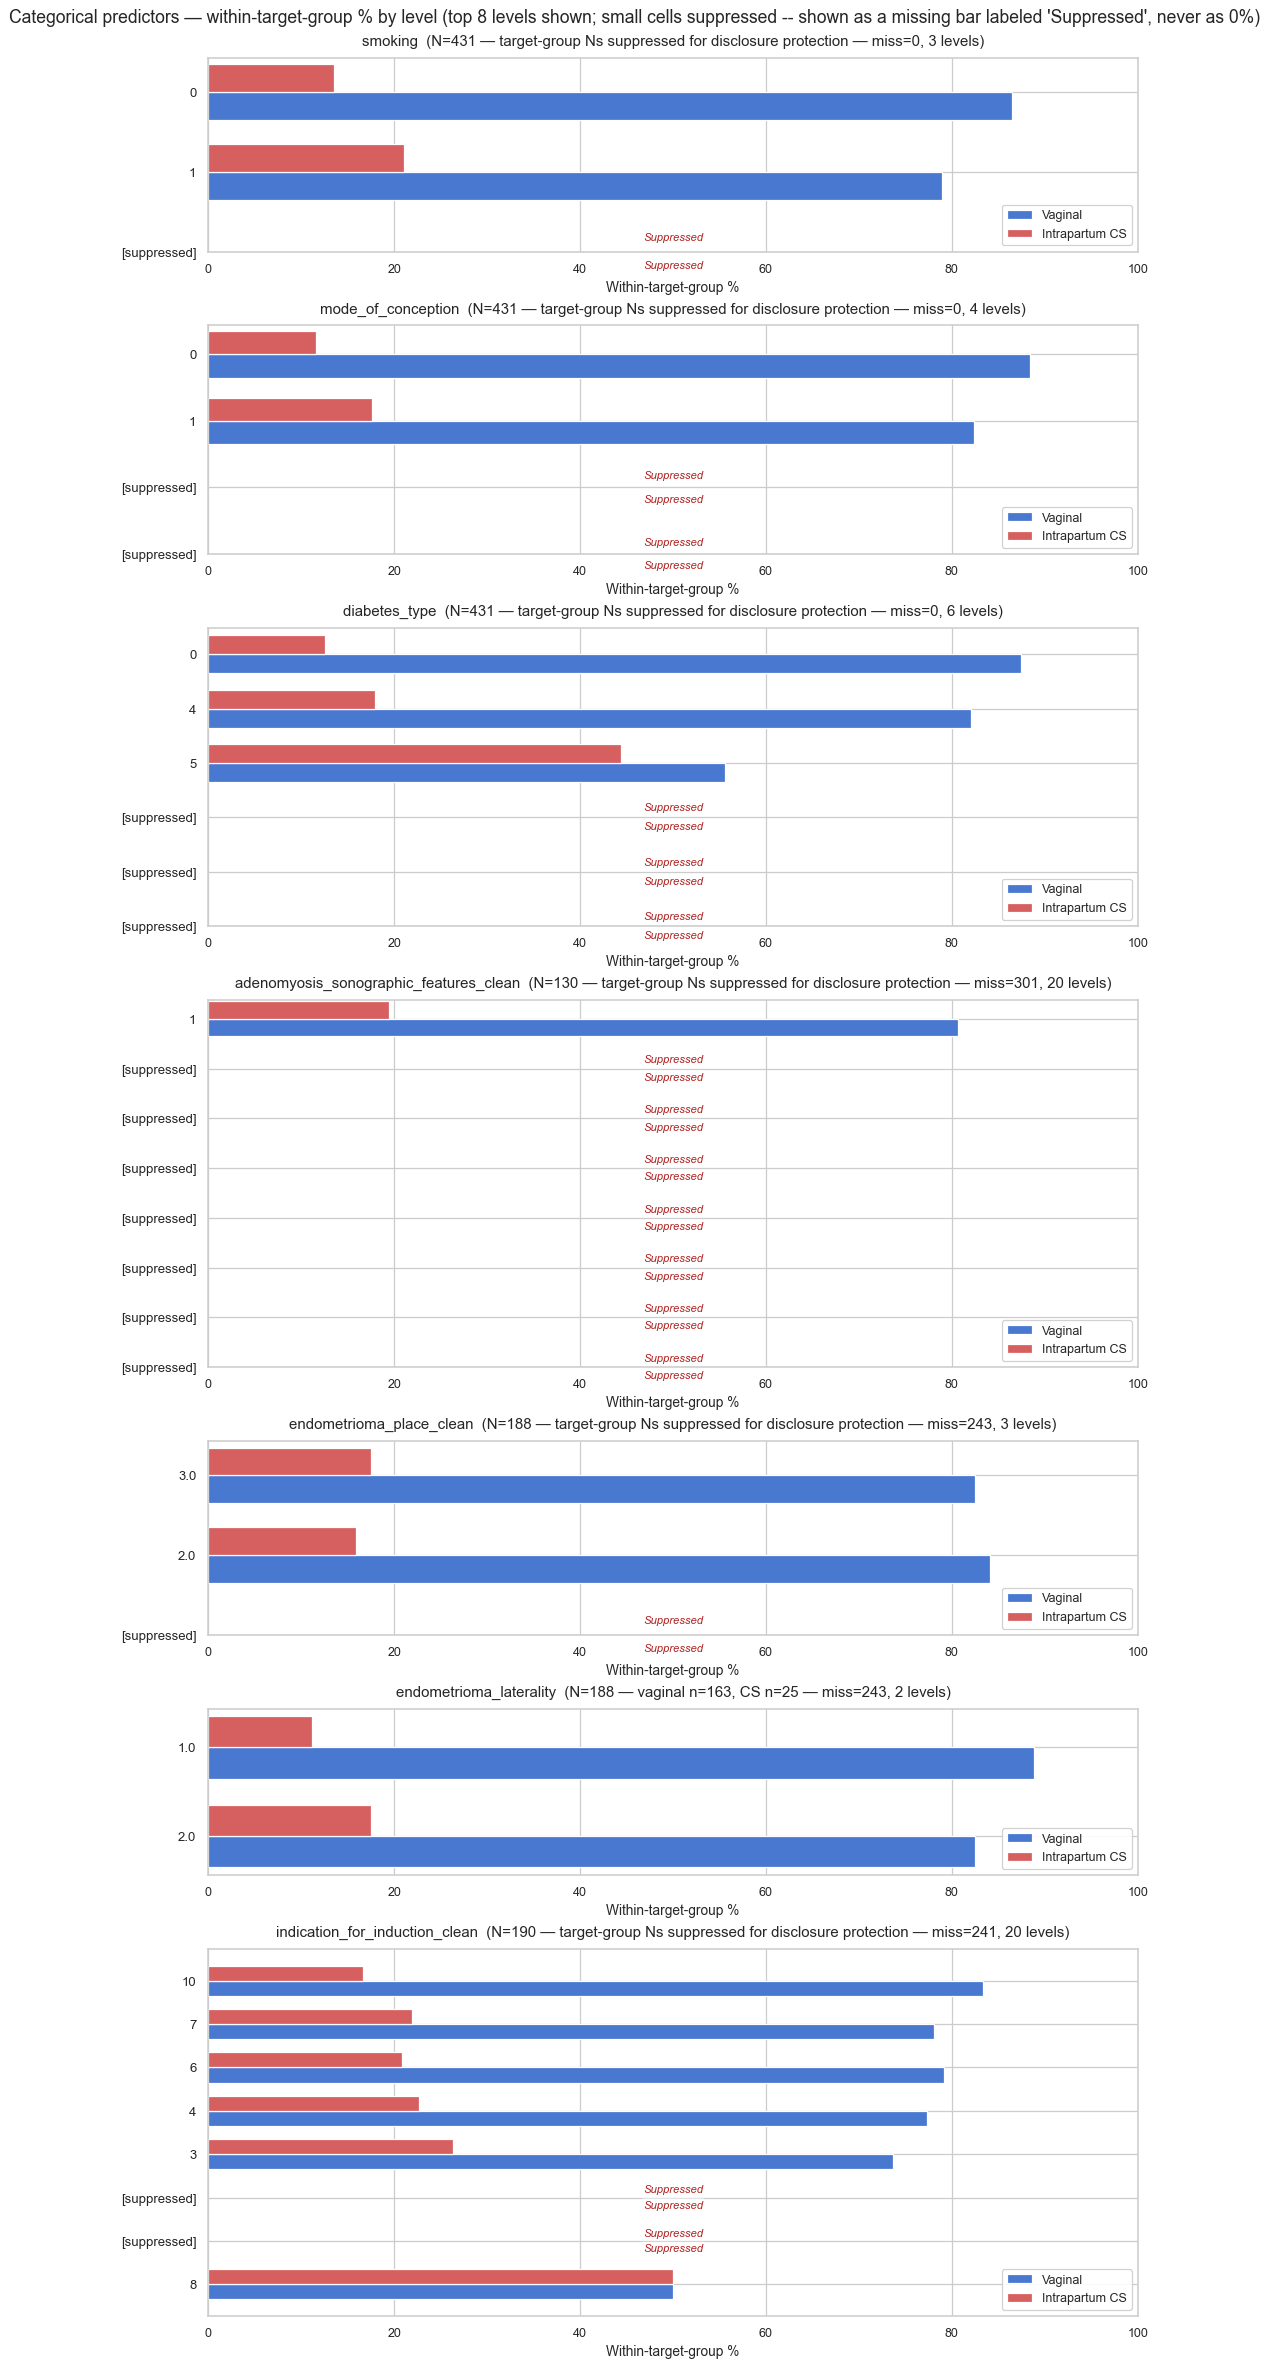

In [14]:
# Target-stratified bar plots for every categorical predictor (full coverage,
# not a text-only summary). One variable per row (horizontal bars) so long
# category labels and up to 8 levels per variable (matching the level cap
# already used in the printed table above) stay legible at normal document
# width -- a 2-per-row vertical-bar grid was too dense for publication use.
if _cat_vars:
    _n_c = len(_cat_vars)
    _level_counts = []
    for col in _cat_vars:
        _sub_n = df_primary[[col, TARGET_COL]].dropna(subset=[col])
        _level_counts.append(min(8, _sub_n[col].nunique()))
    # Row height scales with the number of levels actually shown, so a
    # variable with 8 levels gets as much vertical room as it needs while a
    # binary-like categorical (2-3 levels) does not waste page space.
    _row_heights = [max(2.4, 0.5 * lv + 1.3) for lv in _level_counts]
    fig, axes = plt.subplots(
        _n_c, 1, figsize=(11.5, sum(_row_heights)),
        gridspec_kw={"height_ratios": _row_heights}, layout="constrained",
    )
    axes = np.atleast_1d(axes)
    # within-target-group percentages, not raw counts -- a
    # raw-count bar chart makes level sizes visually incomparable across
    # target groups of very different size (vaginal vs. CS is roughly a
    # 6:1 split in the current cohort), and previously showed exact small
    # counts directly. N is shown in the title so the denominator is never
    # hidden. A suppressed (small-cell) rate is UNKNOWN to the reader, not
    # 0% -- it is plotted as np.nan (no bar rendered by matplotlib for a NaN
    # height) with an explicit 'Suppressed' text annotation, mirroring the
    # same convention already established in Section A2.13's Stage-only
    # outcome graphs (a2_part5_readiness.py, SB13_STAGE_ONLY_OUTCOME_GRAPH)
    # rather than the previous 0-height-bar encoding, which made a suppressed
    # cell visually indistinguishable from a genuine, unsuppressed 0%. A
    # genuine 0% still renders as a real zero-height bar; the raw small count
    # itself is never shown either way.
    def _cat_plot_value(display_value):
        return float(display_value) if isinstance(display_value, (int, float)) else np.nan

    def _cat_annotate_suppressed(ax, y, x=50, fontsize=9):
        ax.text(x, y, "Suppressed", ha="center", va="center", fontsize=fontsize,
                fontstyle="italic", color="firebrick",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))

    for i, col in enumerate(_cat_vars):
        ax = axes[i]
        sub = df_primary[[col, TARGET_COL]].dropna(subset=[col])
        g0s_n, g1s_n = int((sub[TARGET_COL] == 0).sum()), int((sub[TARGET_COL] == 1).sum())
        # Whether ANY level's target-by-level cell is a protected small count
        # (1-4) is determined from the FULL crosstab (every level, not just
        # the top-8 plotted below) -- this decides both the per-level
        # percentage suppression rule and whether the title may show exact
        # target-specific margins (see below).
        _ct_full = pd.crosstab(sub[col], sub[TARGET_COL])
        _has_small_cell_plot = bool(((_ct_full >= 1) & (_ct_full <= 4)).any().any())
        _top_levels = sub[col].value_counts().index[:8]
        _plot_df = sub[sub[col].isin(_top_levels)].copy()
        _ct = pd.crosstab(_plot_df[col], _plot_df[TARGET_COL], normalize=False).reindex(_top_levels)
        _vag_counts = _ct.get(0, pd.Series(0, index=_ct.index))
        _cs_counts = _ct.get(1, pd.Series(0, index=_ct.index))
        # Checked against each level's own total (not g0s_n/g1s_n, the
        # global group sizes), consistent with A2.4's text table and the
        # Stage-2/3 graph: a percentage safe relative to the global group can
        # still disclose a protected complement within its own level.
        _n_tot_plot = _vag_counts + _cs_counts
        _vag_pct = [
            share_safe.safe_pct_with_denominator(int(n), int(t), enabled=SHARE_SAFE_MODE)[0]
            for n, t in zip(_vag_counts, _n_tot_plot)
        ]
        _cs_pct = [
            share_safe.safe_pct_with_denominator(int(n), int(t), enabled=SHARE_SAFE_MODE)[0]
            for n, t in zip(_cs_counts, _n_tot_plot)
        ]
        # Suppressed (string) values plot as np.nan (no bar rendered), with an
        # explicit 'Suppressed' annotation added below -- never a 0-height bar,
        # and never the raw small count itself.
        _vag_plot = [_cat_plot_value(v) for v in _vag_pct]
        _cs_plot = [_cat_plot_value(v) for v in _cs_pct]
        _y = range(len(_ct))
        _h = 0.35
        ax.barh([j + _h/2 for j in _y], _vag_plot, _h, label="Vaginal", color=C0)
        ax.barh([j - _h/2 for j in _y], _cs_plot, _h, label="Intrapartum CS", color=C1)
        for _j_bar, (_vv, _cv) in enumerate(zip(_vag_plot, _cs_plot)):
            if np.isnan(_vv):
                _cat_annotate_suppressed(ax, _j_bar + _h/2)
            if np.isnan(_cv):
                _cat_annotate_suppressed(ax, _j_bar - _h/2)
        ax.set_xlim(0, 100)
        ax.set_yticks(list(_y))
        # a level whose bar is suppressed on BOTH
        # sides (both vag_pct and cs_pct are strings, i.e. a small cell on
        # every target group it appears in) previously still showed its real
        # category name on the axis -- disclosing "this rare category
        # exists in this cohort" even with no numerical bar rendered next to
        # it (just a 'Suppressed' annotation), in a small cohort where that
        # alone can be identifying. Its label is
        # replaced with a generic placeholder instead; only a level with at
        # least one non-suppressed side keeps its real name.
        _ytick_labels = [
            str(_lv)[:32] if (isinstance(_vp, (int, float)) or isinstance(_cp, (int, float)))
            else "[suppressed]"
            for _lv, _vp, _cp in zip(_ct.index, _vag_pct, _cs_pct)
        ]
        ax.set_yticklabels(_ytick_labels, fontsize=10.5)
        ax.invert_yaxis()
        ax.tick_params(axis="x", labelsize=10)
        # Share-safe title: exact target-specific complete-case margins
        # (vaginal n=.../CS n=...) must not be shown for a variable with a
        # protected per-level cell -- combined with the per-level breakdown
        # above (or with A2.9's own N_vaginal/N_cs), that would let a reader
        # recover the hidden level's exact split by subtraction. When this
        # variable has any protected cell, the title states only the safe
        # aggregate N and omits the target-specific margins entirely.
        if _has_small_cell_plot:
            _title_margins = "target-group Ns suppressed for disclosure protection"
        else:
            _title_margins = f"vaginal n={g0s_n}, CS n={g1s_n}"
        ax.set_title(f"{col}  (N={len(sub)} — {_title_margins} — "
                     f"miss={df_primary[col].isna().sum()}, {sub[col].nunique()} levels)",
                     fontsize=12, pad=10)
        ax.set_xlabel("Within-target-group %", fontsize=11)
        ax.legend(fontsize=10, loc="lower right", framealpha=0.9)
    fig.suptitle("Categorical predictors — within-target-group % by level (top 8 levels shown; "
                 "small cells suppressed -- shown as a missing bar labeled 'Suppressed', never as 0%)",
                 fontsize=14)
    plt.show()

**Key observations — binary and categorical distributions:**

In [15]:
print(f"- {len(rate_df)} binary predictors summarized; "
      f"{int(rate_df['separation_risk'].sum())} show complete separation, "
      f"{len(_nzv_bin)} are near-zero-variance (descriptive flag only).")
_ko7_top = rate_df.dropna(subset=['abs_diff_%']).head(3)
if len(_ko7_top):
    print(f"- Largest vaginal-vs-CS rate gaps: "
          f"{list(zip(_ko7_top['variable'], _ko7_top['abs_diff_%']))} -- descriptive "
          f"only; formal ranked association is in A2.9.")
if _cat_vars:
    _ko7_rare_cat = cat_test_df[cat_test_df["n_rare_levels"] > 0]
    if len(_ko7_rare_cat):
        print(f"- {len(_ko7_rare_cat)} categorical predictor(s) have at least one rare "
              f"level (<10 obs): {_ko7_rare_cat['variable'].tolist()} -- flag for later "
              f"review of level-grouping options during Feature Selection.")
print("- No variable is modified, grouped, or excluded based on these distributions.")

- 45 binary predictors summarized; 4 show complete separation, 6 are near-zero-variance (descriptive flag only).
- Largest vaginal-vs-CS rate gaps: [('induction_any_bin', 37.3), ('nulliparity', 33.3), ('gestational_diabetes', 11.4)] -- descriptive only; formal ranked association is in A2.9.
- 5 categorical predictor(s) have at least one rare level (<10 obs): ['smoking', 'mode_of_conception', 'diabetes_type', 'adenomyosis_sonographic_features_clean', 'indication_for_induction_clean'] -- flag for later review of level-grouping options during Feature Selection.
- No variable is modified, grouped, or excluded based on these distributions.


## Section A2.5 — Endometriosis Phenotype Domain EDA

**Purpose:** Give deeper, narrative interpretation to a curated subset of
endometriosis-specific primary predictors, respecting the subgroup structure of
endometrioma-related variables. This section is a domain-focused *complement* to
the full-coverage statistical tables in A2.3/A2.4/A2.12, not a replacement for them.

**What this checks:**
- A curated set of endometriosis binary predictors: positivity rates +
  chi-square/Fisher test by target (deeper narrative than A2.4's table)
- Endometrioma subgroup: `endometrioma_size_clean` and `endometrioma_laterality` analysed
  within the endometrioma=1 subgroup only (structural NaN for non-endometrioma patients)

**What this does NOT do:**
- No reclassification of endometriosis subtypes
- Structural NaN subgroup analysis is restricted to the clinically correct subgroup

**Curated subset given deeper narrative interpretation here:**
`deep_endometriosis`, `adenomyosis`, `endometrioma`,
`endometriosis_surgery`, `cs_scar_endometriosis`, `peritoneal_endometriosis`,
`endometrioma_size_clean` (subgroup), `endometrioma_laterality` (subgroup)

`superficial_endometriosis` is intentionally excluded from this diagnostic entirely
(not merely filtered downstream): it is `clinically_redundant_exclude` --
`peritoneal_endometriosis` is the modeled representation of this overlapping
information. No target association or effect size for `superficial_endometriosis` is
shown anywhere in this notebook.

**Other endometriosis-domain primary predictors:**
`endometrioma_place_clean` (subgroup), `endo_surgery_adhesiolysis`, and the 10
`endo_resection_*` multi-hot columns are `predictor_allowed` -- **not**
`manual_review_pending` (the current classification has zero `manual_review_pending`
variables). They receive full statistical coverage in A2.4
(every binary/categorical predictor) and appear in A2.12's comprehensive table; they
are simply not individually narrated in this domain section's curated subset above.

**Output:** Binary predictor table + grouped bar chart + endometrioma subgroup analysis

=== Endometriosis binary predictors ===
Variable                                    N  Miss%   Vag%   CS%        p     V
--------------------------------------------------------------------------------
  deep_endometriosis                      431   0.0%  35.4% 34.4% 0.8821059931039594 0.0071433610026806985
  adenomyosis                             431   0.0%  38.6% 42.6% 0.5558103182755955 0.02837479062140603
  endometrioma                            431   0.0%  45.4% 41.0% 0.5199115245806603 0.03099542736032463
  endometriosis_surgery                   431   0.0%  51.9% 49.2% 0.6945986771955273 0.01891193699376402
  cs_scar_endometriosis                   431   0.0%   1.9%  8.2% 0.017350993132920822 0.1335800144284628
  peritoneal_endometriosis                431   0.0%  69.5% 68.9% 0.9240803835461774 0.004590206544748628


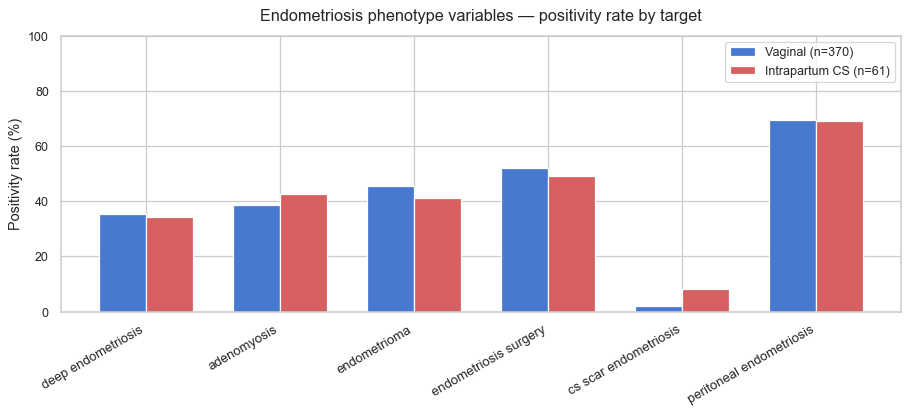

In [16]:
# superficial_endometriosis is deliberately NOT in this list: it is
# clinically_redundant_exclude, not a modeling candidate at any
# stage, and this diagnostic must show no target association or effect size
# for it. peritoneal_endometriosis is the canonical modeled phenotype for the
# overlapping information.
_ENDO_BINARY = [
    "deep_endometriosis", "adenomyosis",
    "endometrioma", "endometriosis_surgery", "cs_scar_endometriosis",
    "peritoneal_endometriosis",
]
_endo_avail = [c for c in _ENDO_BINARY if c in PRIMARY_COLS]
print("=== Endometriosis binary predictors ===")
print(f"{'Variable':<40} {'N':>4} {'Miss%':>6} {'Vag%':>6} {'CS%':>5} {'p':>8} {'V':>5}")
print("-" * 80)
for col in _endo_avail:
    sub = df_primary[[col, TARGET_COL]].dropna(subset=[col])
    g0s = sub[sub[TARGET_COL] == 0]
    g1s = sub[sub[TARGET_COL] == 1]
    # Share-safe: safe_pct() only formats percentages -- it does
    # NOT suppress small cells despite the name. This printed table
    # previously showed an unsuppressed CS-group % that can reconstruct a
    # small event count (e.g. "3.2%" of a small n1 implies ~2 patients).
    # Reuses safe_pct's "—" convention for a zero denominator.
    _r0_val, _ = share_safe.safe_pct_with_denominator(
        int((g0s[col] == 1).sum()), len(g0s), enabled=SHARE_SAFE_MODE
    )
    _r1_val, _ = share_safe.safe_pct_with_denominator(
        int((g1s[col] == 1).sum()), len(g1s), enabled=SHARE_SAFE_MODE
    )
    r0 = f"{_r0_val:.1f}%" if isinstance(_r0_val, (int, float)) else (_r0_val or "—")
    r1 = f"{_r1_val:.1f}%" if isinstance(_r1_val, (int, float)) else (_r1_val or "—")
    n_miss = df_primary[col].isna().sum()
    # Canonical dict API -- see the A2.4 binary-loop comment above.
    _res = chi2_or_fisher(col, df_primary, TARGET_COL)
    pv = _res["p_value"]
    ct = pd.crosstab(sub[col], sub[TARGET_COL])
    v  = cramers_v(ct)
    print(f"  {col:<38} {len(sub):>4} {n_miss/len(df_primary)*100:>5.1f}% "
          f"{r0:>6} {r1:>5} {str(pv):>8} {str(v):>5}")

# Bar chart
# this chart previously computed .mean()*100 directly on the
# full target-group slice, where a missing value in a NaN-containing endo
# column evaluates to False (not dropped), diluting the rate toward 0% --
# inconsistent with the printed table above, which correctly drops missing
# per column first. Reuses the exact same per-column dropna pattern as that
# table so the chart and table always agree.
_er = []
for c in _endo_avail:
    if c not in df_primary.columns:
        continue
    _sub = df_primary[[c, TARGET_COL]].dropna(subset=[c])
    _g0s = _sub[_sub[TARGET_COL] == 0]
    _g1s = _sub[_sub[TARGET_COL] == 1]
    _vag_pct, _ = share_safe.safe_pct_with_denominator(
        int((_g0s[c] == 1).sum()), len(_g0s), enabled=SHARE_SAFE_MODE
    )
    _cs_pct, _ = share_safe.safe_pct_with_denominator(
        int((_g1s[c] == 1).sum()), len(_g1s), enabled=SHARE_SAFE_MODE
    )
    _er.append({"var": c, "vaginal_%": _vag_pct, "cs_%": _cs_pct})
if _er:
    _er_df = pd.DataFrame(_er)
    # Suppressed (string) values plot as np.nan (no bar rendered), with an
    # explicit 'Suppressed' text annotation at that bar's position -- the
    # same convention already established in eda-b-s07-categorical-plots and
    # A2.13's stage-only outcome graphs (SB13_STAGE_ONLY_OUTCOME_GRAPH). A
    # suppressed rate is UNKNOWN to the reader, not 0% -- it must never be
    # encoded as a numeric zero / 0-height bar, which would be visually
    # indistinguishable from a genuine, unsuppressed 0%. A genuine 0% still
    # renders as a real zero-height bar; the raw small count itself is never
    # shown either way. The printed table above remains the authoritative,
    # explicitly-labeled-suppressed record.
    def _endo_plot_value(display_value):
        return float(display_value) if isinstance(display_value, (int, float)) else np.nan

    def _endo_annotate_suppressed(ax, x, y=50, fontsize=9):
        ax.text(x, y, "Suppressed", ha="center", va="center", fontsize=fontsize,
                fontstyle="italic", color="firebrick",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))

    _er_df["vaginal_%_plot"] = [_endo_plot_value(v) for v in _er_df["vaginal_%"]]
    _er_df["cs_%_plot"] = [_endo_plot_value(v) for v in _er_df["cs_%"]]
    x = range(len(_er_df))
    w = 0.35
    fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
    ax.bar([i-w/2 for i in x], _er_df["vaginal_%_plot"], w, label=f"Vaginal (n={n0})", color=C0)
    ax.bar([i+w/2 for i in x], _er_df["cs_%_plot"],      w, label=f"Intrapartum CS (n={n1})", color=C1)
    for _i_bar, (_vv, _cv) in enumerate(zip(_er_df["vaginal_%_plot"], _er_df["cs_%_plot"])):
        if np.isnan(_vv):
            _endo_annotate_suppressed(ax, _i_bar - w/2)
        if np.isnan(_cv):
            _endo_annotate_suppressed(ax, _i_bar + w/2)
    ax.set_ylim(0, 100)
    ax.set_xticks(list(x))
    ax.set_xticklabels([r["var"].replace("_"," ") for r in _er], rotation=30, ha="right", fontsize=10.5)
    ax.tick_params(axis="y", labelsize=10)
    ax.set_ylabel("Positivity rate (%)", fontsize=11.5)
    ax.set_title("Endometriosis phenotype variables — positivity rate by target", fontsize=13, pad=12)
    ax.legend(fontsize=10)
    plt.show()
    if SHARE_SAFE_MODE and (
        _er_df["vaginal_%"].astype(str).str.contains("suppressed").any()
        or _er_df["cs_%"].astype(str).str.contains("suppressed").any()
    ):
        print("  NOTE: one or more bars above are shown as a missing bar labeled 'Suppressed' "
              "because the underlying rate is based on a small (n<5) cell -- see the printed "
              "table above for the explicit suppression label. A suppressed rate is UNKNOWN to "
              "the reader, not 0%, and must never be read as a true 0%.")

=== Endometrioma subgroup variables ===
  IMPORTANT: These variables are structural NaN for patients without endometrioma.
  Analysis is limited to the endometrioma=1 subgroup.

  Endometrioma=1 subgroup: N=193 (of 431 total)
  Target in subgroup: 0=168, 1=25

  endometrioma_size_clean:
    N available (endo=1 with value): 171  |  N missing in subgroup: 22
    Range: [10.0, 210.0]  |  Median: 30.0  |  IQR: [20.0, 50.0]
    Vaginal: 30.0 [20.0–49.2]  |  CS: 45.0 [30.0–73.0]
    Mann-Whitney: p=0.013225225980191576, |r|=0.3339682539682539  (N_analyzed=171)

  endometrioma_laterality:
    N available (endo=1 with value): 188  |  N missing in subgroup: 5
    Value counts: counts (categories with n>=5)={'2.0': 63, '1.0': 125}



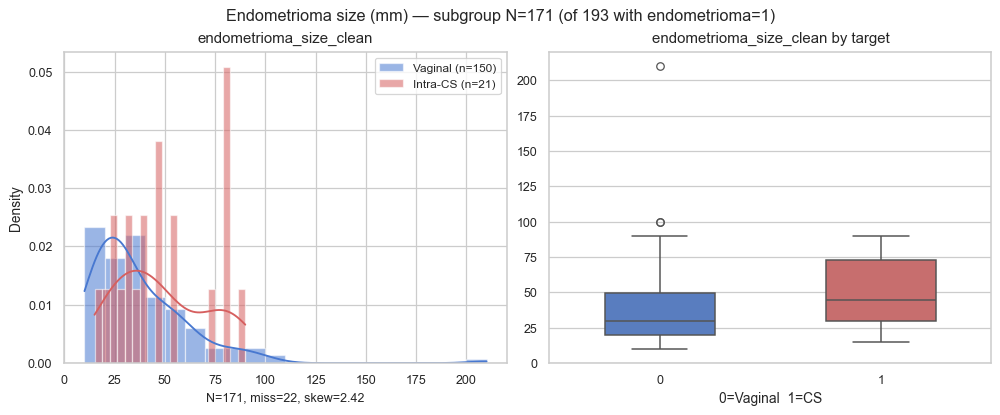

No endometriosis surgical-detail variable is currently classified manual_review_pending.


In [17]:
# ── Endometrioma subgroup analysis ────────────────────────────────────────
# endometrioma_size_clean and endometrioma_laterality are structural NaN:
# only meaningful for patients with endometrioma=1.
# Always print the subgroup N explicitly.

print("=== Endometrioma subgroup variables ===")
print("  IMPORTANT: These variables are structural NaN for patients without endometrioma.")
print("  Analysis is limited to the endometrioma=1 subgroup.")
print()

if "endometrioma" in df_primary.columns:
    _endo1 = df_primary[df_primary["endometrioma"] == 1].copy()
    print(f"  Endometrioma=1 subgroup: N={len(_endo1)} (of {len(df_primary)} total)")
    print(f"  Target in subgroup: 0={int((_endo1[TARGET_COL]==0).sum())}, "
          f"1={int((_endo1[TARGET_COL]==1).sum())}")
    print()

    for col in ["endometrioma_size_clean", "endometrioma_laterality"]:
        if col not in _endo1.columns:
            continue
        _sub  = _endo1[[col, TARGET_COL]].dropna(subset=[col])
        _n_avail = len(_sub)
        _n_miss  = len(_endo1) - _n_avail
        _vtype   = infer_var_type(_endo1[col])
        print(f"  {col}:")
        print(f"    N available (endo=1 with value): {_n_avail}  |  N missing in subgroup: {_n_miss}")
        if _vtype == "numeric":
            s = _sub[col]
            print(f"    Range: [{s.min():.1f}, {s.max():.1f}]  |  Median: {s.median():.1f}  |  "
                  f"IQR: [{s.quantile(0.25):.1f}, {s.quantile(0.75):.1f}]")
            g0s = _sub[_sub[TARGET_COL]==0][col]
            g1s = _sub[_sub[TARGET_COL]==1][col]
            if len(g0s) >= 3 and len(g1s) >= 3:
                pv, eff = mannwhitney_with_effect(g0s, g1s)
                print(f"    Vaginal: {fmt_median_iqr(g0s)}  |  CS: {fmt_median_iqr(g1s)}")
                print(f"    Mann-Whitney: p={pv}, |r|={eff}  (N_analyzed={len(_sub)})")
        else:
            # Small-cell disclosure guard (item J): same n<5 convention as A2.4's
            # categorical breakdown -- a raw value_counts() dict on a subgroup
            # could otherwise expose a near-patient-level cell if a category
            # is rare within this (endometrioma=1) subgroup.
            # Reconstruction-aware (see the main categorical loop's comment
            # above for the full rationale): a combined bucket with only one
            # member, or a combined total still <5, would disclose that one
            # rare category's exact count directly -- and even withholding it
            # would not help, since N_available is printed on the line above
            # and every other category is shown individually. Fold
            # smallest-first until the combined bucket is empty or safely
            # >=5, exactly like the main categorical loop.
            _vc_sub = _sub[col].value_counts()
            _visible_vc, _below_vc_n, _below_vc_k = share_safe.safe_combine_rare_levels(
                {str(k): int(v) for k, v in _vc_sub.items()}, threshold=5
            )
            _vc_parts = [f"counts (categories with n>=5)={_visible_vc}"]
            if _below_vc_k:
                if _below_vc_n is not None and _below_vc_n >= 5:
                    _vc_parts.append(share_safe.format_combined_levels_note(_below_vc_k, _below_vc_n))
                else:
                    _vc_parts.append(
                        f"{_below_vc_k} smaller categor{'y' if _below_vc_k == 1 else 'ies'} "
                        "combined (too few total observations to display safely, suppressed)"
                    )
            print(f"    Value counts: {'; '.join(_vc_parts)}")
        print()

    # Endometrioma size distribution plot
    if "endometrioma_size_clean" in _endo1.columns:
        _sz_sub = _endo1[["endometrioma_size_clean", TARGET_COL]].dropna()
        if len(_sz_sub) >= 10:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
            plot_numeric_dist(_endo1, "endometrioma_size_clean", TARGET_COL, ax1, ax2)
            fig.suptitle(f"Endometrioma size (mm) — subgroup N={len(_sz_sub)} "
                         f"(of {len(_endo1)} with endometrioma=1)", fontsize=13)
            plt.show()
else:
    print("  'endometrioma' column not found in df_primary.")

# Any genuinely manual_review_pending endometriosis surgical-detail variables
# (source ambiguity, not yet statistically tested); membership is read from
# the current variable classification, not a fixed list.
if MANUAL_REVIEW_PENDING_COLS:
    print("=== Endometriosis surgical detail variables (manual_review_pending) ===")
    print("  These are NOT included in statistical tests — source (prior surgery vs current CS)")
    print("  is unconfirmed. Summary for awareness only.")
    for col in MANUAL_REVIEW_PENDING_COLS:
        if col not in df.columns:
            continue
        n_avail  = int(df[col].notna().sum())
        miss_pct = round(df[col].isna().mean() * 100, 1)
        # Small-cell disclosure guard: only report a top value if its
        # count is >=5 (project convention), else omit rather than expose it.
        top_vals = {str(k): int(v) for k, v in df[col].value_counts(dropna=True).head(3).items() if v >= 5}
        print(f"  {col}: N_available={n_avail} ({miss_pct}% missing) | top values (n>=5 only): {top_vals}")
else:
    print("No endometriosis surgical-detail variable is currently classified "
          "manual_review_pending.")

## Section A2.6 — Obstetric and Pregnancy Domain EDA

**Purpose:** Analyse non-endometriosis primary predictors grouped by clinical domain.
Covers all obstetric history, pregnancy complications, and demographic variables.

**What this checks:**
- Demographics / Anthropometry: AGE, BMI, weight, height (Mann-Whitney + boxplot)
- Obstetric history: G, P, CS, nulliparity, S_P_CS, VBAC
- Mode of conception: IVF vs other
- Pregnancy complications: hypertensive disorders, gestational diabetes,
  placental/fetal complications, medications
- Variables with `timing='unclear'`: documented for A2.14 registry (not tested)

**What this does NOT do:**
- Does not resolve timing ambiguity for `timing='unclear'` variables

**Output:** Per-domain association tables + boxplots for anthropometrics. The unified
predictor universe (`PRIMARY_COLS`) already includes
`secondary_near_delivery_predictor` and `intrapartum_predictor_exclude_from_prelabor_model`
variables alongside `predictor_allowed` ones -- there is no separate "future add-on"
reference table; any such variable belonging to a domain group above is analysed here
once, in place, like every other primary predictor. Horizon-specific modeling
eligibility (pre-labor / near-delivery / intrapartum) is decided only at the modeling
boundary, downstream of EDA C -- not in this descriptive section.

Groups: Demographics → Obstetric History → Mode of Conception →
Pregnancy Complications → Medications

=== Group: Demographics and Anthropometry ===
  AGE                       N=431 (miss=0) | overall: 32.0 [29.0–35.0] | vaginal: 32.0 → CS: 33.0 | MW p=0.013567233664420303, |r|=0.19676561807709347
  BMI_before                N=317 (miss=114) | overall: 22.0 [19.7–25.8] | vaginal: 22.0 → CS: 21.9 | MW p=0.8910643773184242, |r|=0.01282679738562087
  BMI_after                 N=184 (miss=247) | overall: 27.7 [24.8–30.8] | vaginal: 27.7 → CS: 26.9 | MW p=0.9516077838087429, |r|=0.008101539292465487
  weight_before_pregnancy   N=342 (miss=89) | overall: 60.0 [52.0–69.0] | vaginal: 60.0 → CS: 58.5 | MW p=0.7622848490694754, |r|=0.027281746031746046
  weight_in_pregnancy       N=187 (miss=244) | overall: 75.0 [66.0–84.0] | vaginal: 75.0 → CS: 80.5 | MW p=0.8288389973825173, |r|=0.027607361963190136
  height                    N=363 (miss=68) | overall: 163.0 [159.0–168.0] | vaginal: 163.0 → CS: 160.5 | MW p=0.01981036023388843, |r|=0.20145931239178827


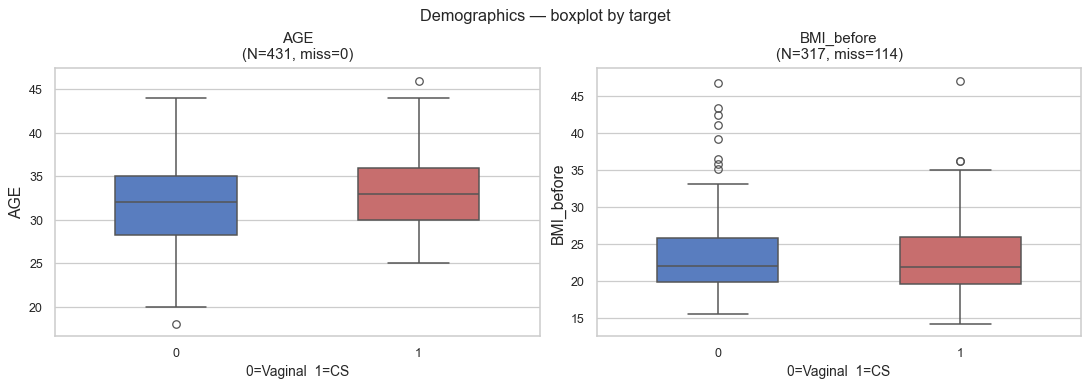

In [18]:
print("=== Group: Demographics and Anthropometry ===")
_DEMO = ["AGE", "BMI_before", "BMI_after", "weight_before_pregnancy",
         "weight_in_pregnancy", "height"]
_demo_avail = [c for c in _DEMO if c in PRIMARY_COLS]
_g0 = df_primary[df_primary[TARGET_COL] == 0]
_g1 = df_primary[df_primary[TARGET_COL] == 1]

for col in _demo_avail:
    sub = df_primary[[col, TARGET_COL]].dropna(subset=[col])
    g0s = sub[sub[TARGET_COL] == 0]
    g1s = sub[sub[TARGET_COL] == 1]
    pv, eff = mannwhitney_with_effect(g0s[col], g1s[col])
    print(f"  {col:<25} N={len(sub):>3} (miss={df_primary[col].isna().sum()}) "
          f"| overall: {fmt_median_iqr(sub[col])}"
          f" | vaginal: {g0s[col].median():.1f} → CS: {g1s[col].median():.1f}"
          f" | MW p={pv}, |r|={eff}")

# Compact boxplot for key anthropometric vars
_key_demo = [c for c in ["AGE", "BMI_before"] if c in PRIMARY_COLS]
if _key_demo:
    fig, axes = plt.subplots(1, len(_key_demo), figsize=(6*len(_key_demo), 4.2), layout="constrained")
    if len(_key_demo) == 1: axes = [axes]
    for ax, col in zip(axes, _key_demo):
        sub_p = df_primary[[col, TARGET_COL]].dropna().copy()
        sub_p[TARGET_COL] = sub_p[TARGET_COL].astype(str)
        sns.boxplot(data=sub_p, x=TARGET_COL, y=col, hue=TARGET_COL, ax=ax,
                    palette={"0": C0, "1": C1}, width=0.5, linewidth=1.2, legend=False)
        ax.set_title(f"{col}\n(N={sub_p.shape[0]}, miss={df_primary[col].isna().sum()})", fontsize=12, pad=8)
        ax.set_xlabel("0=Vaginal  1=CS", fontsize=11)
        ax.tick_params(labelsize=10)
    fig.suptitle("Demographics — boxplot by target", fontsize=13)
    plt.show()
print()

In [19]:
# Centralized binary target-stratified display helper: checking each side's
# own within-group complement independently is not sufficient, because it
# misses the cross-group total-positive complement (the same quantity A1's
# Section A6 separately reports as this variable's unstratified n_positive)
# and the other side's own suppression state. Every binary vaginal/CS
# percentage pair in this notebook goes through
# share_safe.suppress_binary_target_display() (shared with A2.4/A2.8/A2.9) via
# this one local formatting wrapper, reused by every cell below that prints
# a binary predictor's target-stratified rate.
def _binary_pct_pair(n_pos0, n_pos1, g0s, g1s):
    _vd, _cd = share_safe.suppress_binary_target_display(
        n_pos0, n_pos1, len(g0s), len(g1s), enabled=SHARE_SAFE_MODE
    )
    _vs = f"{100*n_pos0/len(g0s):.1f}%" if not isinstance(_vd, str) and len(g0s) else (_vd if isinstance(_vd, str) else "—")
    _cs = f"{100*n_pos1/len(g1s):.1f}%" if not isinstance(_cd, str) and len(g1s) else (_cd if isinstance(_cd, str) else "—")
    return _vs, _cs


print("=== Group: Obstetric History ===")
_OB_NUM = ["G", "P", "CS"]
_OB_BIN = ["nulliparity", "S_P_CS", "VBAC"]
_g0 = df_primary[df_primary[TARGET_COL] == 0]
_g1 = df_primary[df_primary[TARGET_COL] == 1]

for col in [c for c in _OB_NUM if c in PRIMARY_COLS]:
    sub = df_primary[[col, TARGET_COL]].dropna(subset=[col])
    g0s = sub[sub[TARGET_COL] == 0]; g1s = sub[sub[TARGET_COL] == 1]
    pv, eff = mannwhitney_with_effect(g0s[col], g1s[col])
    print(f"  {col:<12} N={len(sub):>3} | median: overall={sub[col].median():.1f} "
          f"vaginal={g0s[col].median():.1f} CS={g1s[col].median():.1f} | MW p={pv}, |r|={eff}")

for col in [c for c in _OB_BIN if c in PRIMARY_COLS]:
    sub = df_primary[[col, TARGET_COL]].dropna(subset=[col])
    g0s = sub[sub[TARGET_COL] == 0]; g1s = sub[sub[TARGET_COL] == 1]
    n_pos0 = int((g0s[col] == 1).sum()); n_pos1 = int((g1s[col] == 1).sum())
    sep = (n_pos1 == 0 or len(g1s) - n_pos1 == 0)
    # Canonical dict API -- see the A2.4 binary-loop comment above.
    _res = chi2_or_fisher(col, df_primary, TARGET_COL)
    pv, test = _res["p_value"], _res["test"]
    sep_note = "  ⚠ SEPARATION" if sep else ""
    _vag_disp, _cs_disp = _binary_pct_pair(n_pos0, n_pos1, g0s, g1s)
    print(f"  {col:<20} N={len(sub):>3} | vaginal={_vag_disp} "
          f"CS={_cs_disp} | {test} p={pv}{sep_note}")
print()

print("=== Group: Mode of Conception ===")
col = "mode_of_conception_ivf_vs_all"
if col in PRIMARY_COLS:
    sub = df_primary[[col, TARGET_COL]].dropna(subset=[col])
    g0s = sub[sub[TARGET_COL] == 0]; g1s = sub[sub[TARGET_COL] == 1]
    n_pos0 = int((g0s[col] == 1).sum()); n_pos1 = int((g1s[col] == 1).sum())
    # Canonical dict API -- see the A2.4 binary-loop comment above.
    _res = chi2_or_fisher(col, df_primary, TARGET_COL)
    pv, test = _res["p_value"], _res["test"]
    _vag_disp, _cs_disp = _binary_pct_pair(n_pos0, n_pos1, g0s, g1s)
    print(f"  IVF: vaginal={_vag_disp} CS={_cs_disp} "
          f"| {test} p={pv} (N={len(sub)}, miss={df_primary[col].isna().sum()})")
print()

=== Group: Obstetric History ===
  G            N=431 | median: overall=2.0 vaginal=2.0 CS=1.0 | MW p=0.0030530277656786176, |r|=0.22494461674789545
  P            N=431 | median: overall=0.0 vaginal=0.0 CS=0.0 | MW p=2.341500020966281e-05, |r|=0.3041648205582632
  CS           N=431 | median: overall=0.0 vaginal=0.0 CS=0.0 | MW p=0.30940863852736433, |r|=0.02817899867080198
  nulliparity          N=431 | vaginal=50.3% CS=83.6% | chi-square p=1.241243920393477e-06
  S_P_CS               N=431 | vaginal=suppressed (complementary) CS=<5 (suppressed) | Fisher exact p=0.3018452647702763
  VBAC                 N=431 | vaginal=<5 (suppressed) CS=suppressed (complementary) | Fisher exact p=1.0  ⚠ SEPARATION

=== Group: Mode of Conception ===
  IVF: vaginal=27.8% CS=36.1% | chi-square p=0.18948425145484646 (N=431, miss=0)



In [20]:
_COMPLICATION_GROUPS = {
    "Hypertensive Disorders": [
        "pregnancy_related_hypertensive_disorder", "PIH", "mild_PET",
        "severe_PET", "any_PET", "SIPET",
    ],
    "Gestational Diabetes": ["gestational_diabetes", "diabetes_type"],
    "Placental / Fetal":    ["PPROM", "placenta_previa", "IUGR",
                              "Fetus_Anamoly", "polyhydramnios"],
    "Medications":          ["aspirin_during_pregnancy", "clexane_during_pregnancy"],
    "General Comorbidity":  ["any_medical_problem", "regular_medications",
                              "smoking", "alcohol"],
}

for _grp_name, _grp_vars in _COMPLICATION_GROUPS.items():
    _avail = [c for c in _grp_vars if c in PRIMARY_COLS]
    if not _avail:
        continue
    print(f"=== Group: {_grp_name} ===")
    for col in _avail:
        sub = df_primary[[col, TARGET_COL]].dropna(subset=[col])
        g0s = sub[sub[TARGET_COL] == 0]; g1s = sub[sub[TARGET_COL] == 1]
        vtype = infer_var_type(df_primary[col])
        n_miss = df_primary[col].isna().sum()
        sep = False
        if vtype == "numeric":
            pv, eff = mannwhitney_with_effect(g0s[col], g1s[col])
            print(f"  {col:<35} N={len(sub):>3} miss={n_miss:>3} "
                  f"| vaginal={g0s[col].median():.1f} CS={g1s[col].median():.1f} "
                  f"| MW p={pv}, |r|={eff}")
        else:
            n_pos0 = int((g0s[col] == 1).sum()) if vtype=="binary" else None
            n_pos1 = int((g1s[col] == 1).sum()) if vtype=="binary" else None
            if vtype == "binary":
                sep = (n_pos1 == 0 or len(g1s) - n_pos1 == 0)
            # Canonical dict API -- see the A2.4 binary-loop comment above.
            _res = chi2_or_fisher(col, df_primary, TARGET_COL)
            pv, test = _res["p_value"], _res["test"]
            # _binary_pct_pair (defined in eda-b-s09-obstetric, the prior
            # cell) applies the shared disclosure protection -- see that
            # cell's comment for the full rationale.
            if n_pos0 is not None and n_pos1 is not None:
                _r0, _r1 = _binary_pct_pair(n_pos0, n_pos1, g0s, g1s)
            else:
                _r0, _r1 = "—", "—"
            sep_note = "  ⚠ SEPARATION" if sep else ""
            print(f"  {col:<35} N={len(sub):>3} miss={n_miss:>3} "
                  f"| vaginal={_r0} CS={_r1} | {test} p={pv}{sep_note}")
    print()

# Timing-unclear variables — note only
_TIMING_UNCLEAR = [c for c in PRIMARY_COLS
                   if TIMING_MAP.get(c, "unknown") == "unclear"]
if _TIMING_UNCLEAR:
    print("=== Variables with UNCLEAR TIMING (→ A2.14 clinical decision registry) ===")
    for col in _TIMING_UNCLEAR:
        print(f"  {col}: timing='unclear' — excluded from main analysis. See A2.14.")
    print()

=== Group: Hypertensive Disorders ===
  pregnancy_related_hypertensive_disorder N=431 miss=  0 | vaginal=3.2% CS=11.5% | Fisher exact p=0.010213488148855601
  PIH                                 N=431 miss=  0 | vaginal=suppressed (complementary) CS=<5 (suppressed) | Fisher exact p=0.1561762426721339
  mild_PET                            N=431 miss=  0 | vaginal=suppressed (complementary) CS=<5 (suppressed) | Fisher exact p=0.08960215984742237
  severe_PET                          N=416 miss= 15 | vaginal=<5 (suppressed) CS=<5 (suppressed) | Fisher exact p=0.2679564411492123
  any_PET                             N=416 miss= 15 | vaginal=suppressed (complementary) CS=<5 (suppressed) | Fisher exact p=0.04198857981245338
  SIPET                               N=431 miss=  0 | vaginal=<5 (suppressed) CS=suppressed (complementary) | Fisher exact p=1.0  ⚠ SEPARATION

=== Group: Gestational Diabetes ===
  gestational_diabetes                N=431 miss=  0 | vaginal=13.2% CS=24.6% | chi-square 

  smoking                             N=431 miss=  0 | vaginal=— CS=— | Fisher-Freeman-Halton (Monte Carlo p-value, seed=20260810, n=100000) p=0.3333966660333397



## Section A2.7 — Missingness Deep-Dive

**Purpose:** Detailed missingness analysis for all primary predictors in the
cumulative Stage 1-3 A2 predictor-readiness working frame (`df_primary`) --
this includes Stage 2 (near-delivery) and Stage 3 (intrapartum) variables
alongside Stage 1 (pre-labor) ones, not pre-labor/pre-delivery variables only;
`earliest_entry_stage` distinguishes each variable's Stage 1/2/3 availability
throughout this section's tables. Includes by-target differential missingness
check and visual heatmap.

**What this checks:**
- Per-variable missingness count and %, with threshold bins
- Row-level missingness: how many delivery records have ≥1 / ≥5 / ≥10 missing among PRIMARY_COLS
- Differential missingness by target group (flagged if >5% difference between groups)
- Structural NaN variables (subgroup-specific by clinical design)

**What this does NOT do:**
- No imputation, no rows or columns are removed
- Does not determine missingness mechanism (MAR/MCAR/MNAR) — further analysis required

**Output:** Per-variable table with missingness severity bands + category summary +
row-level summary + differential missingness table + heatmap

**Missingness severity bands (descriptive, not prescriptive):**
The bands below are descriptive severity labels only, not a universal treatment
protocol. Actual handling of missing data is variable-type-specific and
model-specific, decided at the modeling stage, not assigned automatically from a
missingness percentage here:
- **≥70%** — severe: a variable at this level typically warrants close scrutiny before
  use as a predictor, but the appropriate response (exclusion, a missing-indicator,
  or another approach) depends on the variable's type and role, not on this band alone
- **40–70%** — moderate. Continuous variables are **not** automatically converted to an
  "unknown"/categorical bucket at this band — that is one possible approach among
  several and requires a case-by-case, variable-type-specific decision
- **<40%** — mild. Differential/patterned missingness may be *reported* descriptively,
  but the missingness mechanism (MAR/MCAR/MNAR) **cannot be identified or proven from
  observed data alone** — this table does not claim to test or determine mechanism
- **0%** — complete

**Important:** target-differential missingness (see the by-target cell below) may be
reported descriptively but must not drive pre-split feature selection or imputation
policy. Any imputation, missing-indicator construction, scaling, or encoding used for
a predictive model must be fitted within training folds only, unless the
transformation is deterministic and outcome-independent (e.g. the structural-fill
rule documented for the `endo_resection_*` family in preprocessing). No imputation is
performed in this notebook.

Structural-NaN variables are flagged separately: they carry a deterministic
non-applicability component outside their defined subgroup; that structural
component is expected by clinical design and is not itself a data-quality gap.
Some structural variables may also retain genuine missingness *within* the
applicable subgroup, which is reported separately below -- the flag alone does not
mean a structural variable's missingness is fully explained by non-applicability.
**Never impute structural non-applicability blindly.**
Where a confirmed subgroup-applicability gate exists (`STRUCTURAL_SUBGROUP_GATES`,
Part 1), the table below also reports the genuine missingness rate *within* the
applicable subgroup, separately from the full-cohort rate that structural
non-applicability otherwise inflates.

In [21]:
# ── Per-variable missingness table ────────────────────────────────────────
# Structural NaN handling: for a
# STRUCTURAL_NAN_COLS member (e.g. endo_resection_* / endo_surgery_adhesiolysis,
# NaN outside endometriosis_surgery==1; endometrioma_size_clean/place_clean/
# laterality, NaN outside endometrioma==1), missing_% computed across the FULL
# cohort is dominated by clinically-expected non-applicability, not genuine
# missingness -- e.g. endo_resection_no_resection is "missing" for roughly
# half the full cohort (every row outside endometriosis_surgery==1) even
# though it is 0% missing within its applicable subgroup. The exact
# full-cohort percentage is cohort-size-dependent and is not hardcoded here
# -- see the live miss_df table below for the current figure.
# These columns get their own descriptive category (not scored by the ordinary
# severity bands); missing_n/% are still reported (informational), just not
# read as an ordinary-missingness severity signal.
#
# For the subset of structural columns with a
# CONFIRMED subgroup-applicability gate (STRUCTURAL_SUBGROUP_GATES, Part 1),
# this table also reports genuine within-applicable-subgroup missingness --
# not every NaN in a structural variable is equivalent: some structural
# variables can still have real missing values within the subgroup where they
# actually apply, and that genuine rate should not be silently hidden behind
# the inflated full-cohort percentage.
_miss_rows = []
for _col in PRIMARY_COLS:
    _miss_n   = int(df_primary[_col].isna().sum())
    _miss_pct = round(df_primary[_col].isna().mean() * 100, 1)
    _structural = _col in STRUCTURAL_NAN_COLS
    _pending_structural = _col in APPLICABILITY_LINKED_COLS
    if _structural:
        _cat = "structural_by_design"
    elif _pending_structural:
        # Empirically subgroup-patterned but NO code-enforced gate -- a
        # distinct third state, never counted as structural_by_design and
        # never granted a missingness-penalty exemption (see
        # structural_missingness_registry.py).
        _cat = APPLICABILITY_LINKED_NO_PREPROCESSING_MASK_LABEL
    elif _miss_pct >= 70:
        _cat = "severe_ge70pct"
    elif _miss_pct >= 40:
        _cat = "moderate_40_70pct"
    elif _miss_pct > 0:
        _cat = "mild_lt40pct"
    else:
        _cat = "complete"

    # Within-applicable-subgroup breakdown (only where a confirmed gate exists).
    _applic_n, _nonapplic_n, _genuine_miss_n, _genuine_miss_pct = None, None, None, None
    if _col in STRUCTURAL_SUBGROUP_GATES:
        _gate_col, _gate_val = STRUCTURAL_SUBGROUP_GATES[_col]
        if _gate_col in df.columns:
            _applic_mask   = df[_gate_col] == _gate_val
            _applic_n      = int(_applic_mask.sum())
            _nonapplic_n   = int(len(df) - _applic_n)
            _genuine_miss_n   = int(df.loc[_applic_mask, _col].isna().sum())
            _genuine_miss_pct = (
                round(100 * _genuine_miss_n / _applic_n, 1) if _applic_n else None
            )

    _miss_rows.append({
        "variable":       _col,
        "earliest_entry_stage": PRIMARY_COLS_EARLIEST_STAGE.get(_col),
        "missing_n":      _miss_n,
        "missing_%":      _miss_pct,
        "category":       _cat,
        "structural_nan": _structural,
        "potentially_structural_pending": _pending_structural,
        "applicable_subgroup_n":         _applic_n,
        "structurally_non_applicable_n": _nonapplic_n,
        "genuine_missing_n_in_subgroup":   _genuine_miss_n,
        "genuine_missing_pct_in_subgroup": _genuine_miss_pct,
        "note": (
            "structural — subgroup variable; missing_% above is full-cohort. "
            + (
                "Genuine within-subgroup missingness is reported in the "
                "genuine_missing_pct_in_subgroup column (confirmed gate)."
                if _col in STRUCTURAL_SUBGROUP_GATES else
                "No confirmed subgroup-applicability gate for this column in "
                "current preprocessing metadata; within-subgroup breakdown not "
                "computed (not guessed)."
            ) if _structural
            else "potentially structural — empirically subgroup-patterned in the "
                 "current cohort, but NO code-enforced preprocessing gate exists "
                 "(unlike structural_by_design). Not exempt from the missingness "
                 "severity bands' clinical interpretation; missing_% above is the "
                 "genuine full-cohort figure, not inflated by a confirmed gate."
            if _pending_structural
            else ""
        ),
    })

miss_df = pd.DataFrame(_miss_rows).sort_values("missing_%", ascending=False)

_miss_show = ["variable", "earliest_entry_stage", "missing_n", "missing_%", "category", "structural_nan",
              "potentially_structural_pending",
              "applicable_subgroup_n", "genuine_missing_pct_in_subgroup"]
print(f"Missingness summary — all primary predictors (N={len(df)}, {len(miss_df)} variables screened):")
print()
_high_miss = miss_df[(miss_df["missing_%"] > 30) & (~miss_df["structural_nan"])]
print(f"Variables with >30% missing, non-structural (N={len(_high_miss)}):")
if len(_high_miss):
    print(_high_miss[_miss_show].to_string(index=False))
else:
    print("  (none)")
print()
_gated = miss_df[miss_df["structural_nan"] | miss_df["potentially_structural_pending"]]
print(f"Structural / applicability-gated missingness (N={len(_gated)}):")
if len(_gated):
    print(_gated[["variable", "missing_n", "missing_%", "category",
                   "applicable_subgroup_n", "genuine_missing_pct_in_subgroup"]].to_string(index=False))
print()
print("genuine_missing_pct_in_subgroup is populated only for structural columns with a")
print("confirmed subgroup-applicability gate (see STRUCTURAL_SUBGROUP_GATES, Part 1);")
print("for the rest, missing_% above remains the only available (full-cohort) figure.")
print("The full miss_df table (all primary predictors) remains available in memory.")
print()

# Row-level missingness among PRIMARY_COLS
_row_miss_prim = df_primary[PRIMARY_COLS].isna().sum(axis=1)
_r1p = int((_row_miss_prim >= 1).sum())
_r5p = int((_row_miss_prim >= 5).sum())
_r10p = int((_row_miss_prim >= 10).sum())
print(f"Row-level missingness (among {len(PRIMARY_COLS)} PRIMARY_COLS, N={len(df_primary)}):")
print(f"  Rows with >= 1  missing : {_r1p:>3}  ({100*_r1p/len(df_primary):.1f}%)")
print(f"  Rows with >= 5  missing : {_r5p:>3}  ({100*_r5p/len(df_primary):.1f}%)")
print(f"  Rows with >= 10 missing : {_r10p:>3}  ({100*_r10p/len(df_primary):.1f}%)")
_n_structural_in_scope = sum(1 for c in PRIMARY_COLS if c in STRUCTURAL_NAN_COLS)
if _n_structural_in_scope:
    print(f"  Note: counted across all {len(PRIMARY_COLS)} PRIMARY_COLS, including "
          f"{_n_structural_in_scope} structural-NaN column(s) whose NaN is largely "
          "clinically-expected non-applicability, not genuine missingness -- these counts "
          "should not be read as 'this many rows have genuine missing predictor values'.")
print()

# Category summary
for _cat_name in ["structural_by_design", APPLICABILITY_LINKED_NO_PREPROCESSING_MASK_LABEL,
                   "severe_ge70pct", "moderate_40_70pct",
                   "mild_lt40pct", "complete"]:
    _sub = miss_df[miss_df["category"] == _cat_name]
    _struct_note = f"  ({_sub['structural_nan'].sum()} structural NaN)" if _sub['structural_nan'].sum() > 0 else ""
    print(f"  [{_cat_name}]: {len(_sub)} variables{_struct_note}")

Missingness summary — all primary predictors (N=431, 67 variables screened):

Variables with >30% missing, non-structural (N=5):
                              variable  earliest_entry_stage  missing_n  missing_%                                   category  structural_nan  potentially_structural_pending  applicable_subgroup_n  genuine_missing_pct_in_subgroup
         gestational_age_at_PPROM_days                     2        415     96.300 applicability_linked_no_preprocessing_mask           False                            True                    NaN                              NaN
adenomyosis_sonographic_features_clean                     1        301     69.800 applicability_linked_no_preprocessing_mask           False                            True                    NaN                              NaN
                             BMI_after                     2        247     57.300                          moderate_40_70pct           False                           False        

In [22]:
# ── Missingness by target group ───────────────────────────────────────────
# An association between missingness and an observed variable/group (here,
# the target) is evidence against a simple MCAR interpretation for that
# variable -- it is compatible with MAR (missingness depending on an
# observed variable). It does NOT establish MNAR (missingness depending on
# the variable's own unobserved value): that cannot be demonstrated from the
# observed dataset alone.
# NOTE: This is a screening flag only; it does not prove a mechanism.
_mt_rows = []
_g0 = df_primary[df_primary[TARGET_COL] == 0]
_g1 = df_primary[df_primary[TARGET_COL] == 1]
for _col in PRIMARY_COLS:
    _m0 = round(_g0[_col].isna().mean() * 100, 1)
    _m1 = round(_g1[_col].isna().mean() * 100, 1)
    _diff = round(abs(_m1 - _m0), 1)
    _mt_rows.append({
        "variable":        _col,
        "miss_%_vaginal":  _m0,
        "miss_%_cs":       _m1,
        "abs_diff_%":      _diff,
        "flag_diff_>5pct": _diff > 5,
    })
mt = pd.DataFrame(_mt_rows).sort_values("abs_diff_%", ascending=False)

_flagged = mt[mt["flag_diff_>5pct"]]
print(f"Missingness by target group — differential flag (>5% difference):")
print(f"  {len(_flagged)} variable(s) with >5% missingness difference between vaginal and CS groups:")
if len(_flagged):
    print(_flagged.to_string(index=False))
else:
    print("  None — no differential missingness detected.")
print()
print("  Note: Differential missingness is a screening signal, not proof of mechanism.")
print("  Structural NaN variables will show differential missingness by design.")

Missingness by target group — differential flag (>5% difference):
  4 variable(s) with >5% missingness difference between vaginal and CS groups:
                      variable  miss_%_vaginal  miss_%_cs  abs_diff_%  flag_diff_>5pct
indication_for_induction_clean          60.800     26.200      34.600             True
 gestational_age_at_PPROM_days          97.300     90.200       7.100             True
       endometrioma_size_clean          59.500     65.600       6.100             True
                     BMI_after          56.500     62.300       5.800             True

  Note: Differential missingness is a screening signal, not proof of mechanism.
  Structural NaN variables will show differential missingness by design.


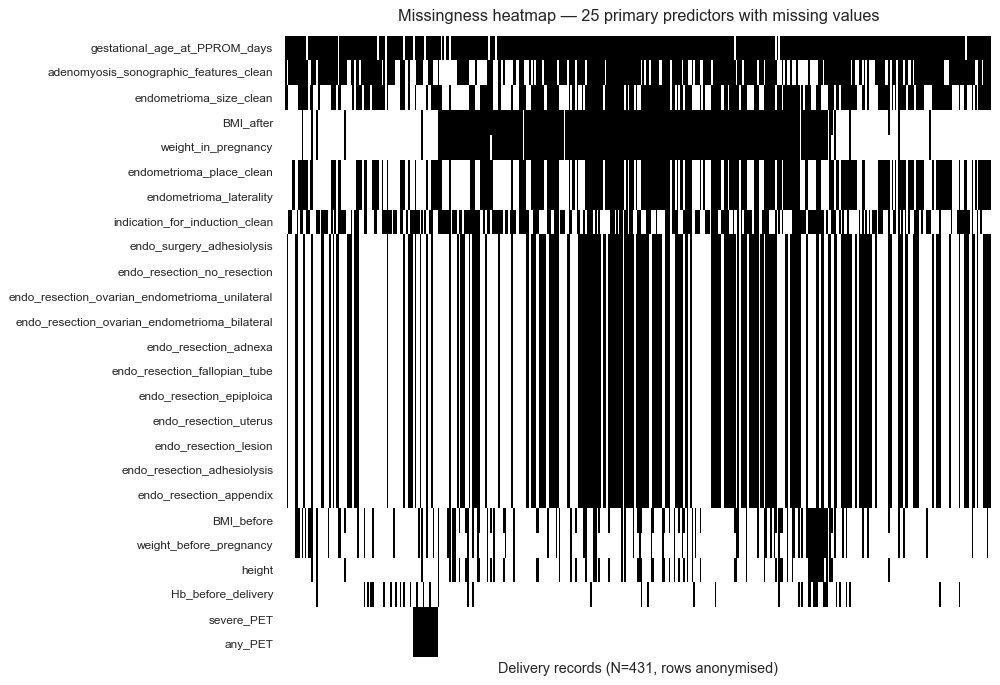

Black = missing | White = present | Sorted by missingness%
Structural NaN variables (subgroup design) will appear as solid black bands.


In [23]:
# ── Missingness heatmap ───────────────────────────────────────────────────
_cols_with_miss = sorted(
    [c for c in PRIMARY_COLS if df_primary[c].isna().any()],
    key=lambda c: df_primary[c].isna().mean(),
    reverse=True,
)
if not _cols_with_miss:
    print("No missing values in primary predictors — heatmap skipped.")
else:
    _n_show = min(40, len(_cols_with_miss))
    _hm = df_primary[_cols_with_miss[:_n_show]].isna().astype(int)
    _fig_w = max(11, _n_show * 0.4)
    _fig_h = max(5, _n_show * 0.3)
    fig, ax = plt.subplots(figsize=(_fig_w, _fig_h), layout="constrained")
    sns.heatmap(_hm.T, cmap="Greys", cbar=False, ax=ax,
                xticklabels=False, yticklabels=_hm.columns.tolist())
    ax.set_xlabel(f"Delivery records (N={len(df_primary)}, rows anonymised)", fontsize=11.5)
    ax.set_title(
        f"Missingness heatmap — {len(_cols_with_miss)} primary predictors with missing values"
        + (f" (first {_n_show} shown)" if len(_cols_with_miss) > _n_show else ""),
        fontsize=13, pad=12,
    )
    ax.tick_params(axis="y", labelsize=9.5, rotation=0)
    plt.show()
    print("Black = missing | White = present | Sorted by missingness%")
    print("Structural NaN variables (subgroup design) will appear as solid black bands.")

In [24]:
# ── Co-missingness: which predictor pairs tend to be missing together ─────
# Descriptive only. Does NOT change missingness handling, imputation, or
# eligibility -- adds a diagnostic view on top of the existing per-variable
# missingness table above. Distinguishes structural (subgroup-by-design,
# e.g. endometrioma_size_clean is NaN whenever endometrioma==0) from
# ordinary missingness so a high co-missingness pair is not misread as an
# unexplained joint gap when it is simply the same structural subgroup rule
# acting on two variables at once.
_miss_cols_co = [c for c in PRIMARY_COLS if df_primary[c].isna().any()]
if len(_miss_cols_co) < 2:
    print("Fewer than 2 primary predictors have any missingness — co-missingness skipped.")
else:
    _miss_ind = df_primary[_miss_cols_co].isna().astype(int)
    _co_rows = []
    for i in range(len(_miss_cols_co)):
        for j in range(i + 1, len(_miss_cols_co)):
            c1, c2 = _miss_cols_co[i], _miss_cols_co[j]
            _both = int(((_miss_ind[c1] == 1) & (_miss_ind[c2] == 1)).sum())
            if _both == 0:
                continue
            _n1, _n2 = int(_miss_ind[c1].sum()), int(_miss_ind[c2].sum())
            _jaccard = _both / (_n1 + _n2 - _both) if (_n1 + _n2 - _both) > 0 else np.nan
            _struct = (c1 in STRUCTURAL_NAN_COLS) or (c2 in STRUCTURAL_NAN_COLS)
            # either_structural_nan=True only says at least ONE member is a
            # structural column -- it does NOT imply the pair shares a common
            # cause (e.g. one member could be endometrioma-gated and the other
            # could have no confirmed gate at all, or a different gate
            # entirely). shared_structural_gate is the stricter, separate
            # diagnostic: True only when BOTH members have a CONFIRMED gate
            # (STRUCTURAL_SUBGROUP_GATES, Part 1) AND that gate is identical
            # for both -- the only case where "they share the same documented
            # subgroup rule" is actually a justified claim.
            _gate1 = STRUCTURAL_SUBGROUP_GATES.get(c1)
            _gate2 = STRUCTURAL_SUBGROUP_GATES.get(c2)
            _shared_gate = (_gate1 is not None) and (_gate1 == _gate2)
            # Aggregate/structural metadata only (a gate column name + value,
            # e.g. "endometrioma==1") -- never a patient-level count -- shown
            # only when a shared gate is actually confirmed.
            _shared_gate_label = f"{_gate1[0]}=={_gate1[1]}" if _shared_gate else ""
            _co_rows.append({
                "var1": c1, "var2": c2,
                "n_both_missing": _both,
                "n1_missing": _n1, "n2_missing": _n2,
                "jaccard_overlap": round(_jaccard, 3),
                "either_structural_nan": _struct,
                "shared_structural_gate": _shared_gate,
                "shared_gate_label": _shared_gate_label,
            })
    if not _co_rows:
        print("No predictor pairs share any jointly-missing rows.")
    else:
        comiss_df = pd.DataFrame(_co_rows).sort_values("jaccard_overlap", ascending=False)
        _high_overlap = comiss_df[comiss_df["jaccard_overlap"] >= 0.5]
        print(f"Co-missingness pairs with jointly-missing rows: {len(comiss_df)}")
        print(f"High-overlap pairs (Jaccard >= 0.5, i.e. mostly missing together): "
              f"{len(_high_overlap)}")
        print(_high_overlap.to_string(index=False) if len(_high_overlap) else "  (none)")
        print()
        print("Full co-missingness table (top 20 by Jaccard overlap):")
        print(comiss_df.head(20).to_string(index=False))
        print()
        _n_shared_gate = int(comiss_df["shared_structural_gate"].sum())
        print(f"Pairs sharing a CONFIRMED structural gate (shared_structural_gate=True): "
              f"{_n_shared_gate}")
        print("Interpretation: shared_structural_gate=True means BOTH members have a")
        print("confirmed subgroup-applicability gate (STRUCTURAL_SUBGROUP_GATES) AND it is")
        print("the identical gate (see shared_gate_label, e.g. 'endometrioma==1') -- only for")
        print("these pairs is co-missingness actually explained by sharing the same")
        print("documented subgroup rule, not an unexplained joint data-collection gap.")
        print("either_structural_nan=True alone (without shared_structural_gate=True) means")
        print("only that AT LEAST ONE member is a structural column -- it does NOT establish")
        print("a common cause for the pair: the other member may have no confirmed gate at")
        print("all, or a different gate entirely, so their co-missingness remains unexplained")
        print("by this table. For non-structural and either-only pairs, a high Jaccard")
        print("overlap identifies a shared missingness pattern/process worth investigating --")
        print("it does not, by itself, establish MCAR, MAR, or MNAR for that pair. Correlated")
        print("missingness indicators can also arise from a shared data-collection process")
        print("(e.g. one form/panel not completed) that remains independent of the")
        print("underlying data values, which would still be consistent with MCAR for each")
        print("variable individually. The missingness mechanism cannot be established from")
        print("this table alone.")

Co-missingness pairs with jointly-missing rows: 300
High-overlap pairs (Jaccard >= 0.5, i.e. mostly missing together): 70
                                          var1                                           var2  n_both_missing  n1_missing  n2_missing  jaccard_overlap  either_structural_nan  shared_structural_gate        shared_gate_label
                         endo_resection_lesion                        endo_resection_appendix             209         209         209            1.000                   True                    True endometriosis_surgery==1
                         endo_resection_uterus                    endo_resection_adhesiolysis             209         209         209            1.000                   True                    True endometriosis_surgery==1
                         endo_resection_uterus                        endo_resection_appendix             209         209         209            1.000                   True                    True endometrios

**Key observations — missingness:**

In [25]:
_ko3_high = miss_df[(miss_df["missing_%"] >= 30) & (~miss_df["structural_nan"])]
_ko3_struct = miss_df[miss_df["structural_nan"]]
print(f"- {int((miss_df['missing_%'] == 0).sum())} of {len(miss_df)} primary predictors "
      f"are fully complete.")
print(f"- {len(_ko3_struct)} predictor(s) carry a structural_nan flag, indicating a "
      f"deterministic non-applicability component outside their defined subgroup; some "
      f"may also have genuine within-subgroup missingness (reported separately above).")
if len(_ko3_high):
    print(f"- {len(_ko3_high)} non-structural predictor(s) have >=30% missing "
          f"({_ko3_high.sort_values('missing_%', ascending=False)['variable'].tolist()[:6]}"
          f"{'...' if len(_ko3_high) > 6 else ''}) -- flag for missingness-mechanism "
          f"consideration before any imputation approach is chosen.")
if "comiss_df" in dir() and len(comiss_df):
    print(f"- {len(comiss_df)} predictor pair(s) share jointly-missing rows; "
          f"{int((comiss_df['jaccard_overlap'] >= 0.5).sum())} have Jaccard overlap "
          f">=0.5. As above, high co-missingness alone does not establish MCAR, MAR, or "
          f"MNAR for those pairs (a shared, value-independent data-collection process "
          f"can also produce correlated missingness) -- the practical handling decision "
          f"for these pairs is deferred to the later cleaning/modeling workflow under "
          f"acknowledged mechanism uncertainty, not resolved by this table.")

- 42 of 67 primary predictors are fully complete.
- 14 predictor(s) carry a structural_nan flag, indicating a deterministic non-applicability component outside their defined subgroup; some may also have genuine within-subgroup missingness (reported separately above).
- 5 non-structural predictor(s) have >=30% missing (['gestational_age_at_PPROM_days', 'adenomyosis_sonographic_features_clean', 'BMI_after', 'weight_in_pregnancy', 'indication_for_induction_clean']) -- flag for missingness-mechanism consideration before any imputation approach is chosen.
- 300 predictor pair(s) share jointly-missing rows; 70 have Jaccard overlap >=0.5. As above, high co-missingness alone does not establish MCAR, MAR, or MNAR for those pairs (a shared, value-independent data-collection process can also produce correlated missingness) -- the practical handling decision for these pairs is deferred to the later cleaning/modeling workflow under acknowledged mechanism uncertainty, not resolved by this table.


## Section A2.8 — Sparsity, Event Counts, and Separation Risk

**Purpose:** Quantify the availability of CS-group events for each binary and categorical
predictor. Low event counts are a fitting/instability concern for certain modeling
approaches, not a universal exclusion rule (see the methodology note below).

**What this checks:**
- Target-by-level cell counts for all binary and categorical PRIMARY_COLS
- `rare_flag`: any target-by-level cell < 10 observations
- `too_sparse`: minimum non-zero target-by-level cell is 1-4 (quasi-separation/instability
  risk); zero-cell cases are classified separately as `separation_risk`, so the two flags
  are mutually exclusive
- `separation_risk`: any target-by-level cell = 0 (complete/quasi-complete separation)

**What this does NOT do:**
- No variables are removed from PRIMARY_COLS here
- No statistical tests (event counts only)

**Methodological approach:** complete or quasi-complete separation is a
serious fitting/instability problem specifically for ordinary **unpenalized**
maximum-likelihood logistic regression (the coefficient can diverge or fail to
converge). It is **not** a universal statement that a flagged variable "cannot enter
logistic regression" under any approach — penalized regression (L1/L2/elastic-net),
Firth's bias-reduced logistic regression, and Bayesian approaches handle separation
differently and remain viable. Whole-cohort target-by-level sparsity/separation must
not be used as an automatic pre-model feature-exclusion rule applied before model
selection or resampling; this section reports diagnostics and warnings only.
Model-specific handling belongs to the modeling pipeline and, where it depends on the
target, must occur inside the appropriate training/resampling context (e.g. checked
per fold, not once on the whole cohort).

**Output:** Per-variable sparsity table + separation risk summary

**Note:** VBAC is expected to show complete separation in this cohort (a structural
consequence of the trial-of-labor cohort definition, not a data-quality issue).

In [26]:
_sparse_rows = []
_g0 = df_primary[df_primary[TARGET_COL] == 0]
_g1 = df_primary[df_primary[TARGET_COL] == 1]

for _col in PRIMARY_COLS:
    _vtype = infer_var_type(df_primary[_col])
    _sub   = df_primary[[_col, TARGET_COL]].dropna(subset=[_col])
    _g1s   = _sub[_sub[TARGET_COL] == 1]
    _g0s   = _sub[_sub[TARGET_COL] == 0]

    _sep_risk  = False
    _too_sparse = False
    _rare_flag  = False
    _cs_events  = None
    _vaginal_events = None
    _min_cell = None
    _cs_events_label = None

    if _vtype == "binary":
        _n_pos1 = int((_g1s[_col] == 1).sum())
        _n_neg1 = len(_g1s) - _n_pos1
        _n_pos0 = int((_g0s[_col] == 1).sum())
        _n_neg0 = len(_g0s) - _n_pos0
        _cells  = [_n_pos1, _n_neg1, _n_pos0, _n_neg0]
        _cs_events = _n_pos1
        _vaginal_events = _n_pos0
        _min_cell = min(_cells)
        _cs_events_label = f"{_n_pos1}/{len(_g1s)}"
        _sep_risk   = any(c == 0 for c in _cells)
        _too_sparse = (not _sep_risk) and (_min_cell < 5)
        _rare_flag  = any(c < 10 for c in _cells)

    elif _vtype == "categorical":
        _levels = _sub[_col].dropna().unique()
        _level_cs = [int((_g1s[_col] == lv).sum()) for lv in _levels]
        _level_vag = [int((_g0s[_col] == lv).sum()) for lv in _levels]
        _level_tot= [int((_sub[_col]  == lv).sum()) for lv in _levels]
        _cs_events = min(_level_cs) if _level_cs else 0
        _vaginal_events = min(_level_vag) if _level_vag else 0
        _all_side_cells = _level_cs + _level_vag
        _min_cell = min(_all_side_cells) if _all_side_cells else 0
        _cs_events_label = f"min={_cs_events}/{len(_g1s)}"
        _sep_risk   = any(c == 0 for c in _all_side_cells)
        _too_sparse = (not _sep_risk) and (_min_cell < 5)
        _rare_flag  = any(c < 10 for c in _all_side_cells) or any(t < 10 for t in _level_tot)

    _sparse_rows.append({
        "variable":          _col,
        "earliest_entry_stage": PRIMARY_COLS_EARLIEST_STAGE.get(_col),
        "type":              _vtype,
        "N_analyzed":        len(_sub),
        "cs_events":         _cs_events_label if _cs_events_label else "—",
        "min_vaginal_cell":  _vaginal_events,
        "min_any_cell":      _min_cell,
        "separation_risk":   _sep_risk,
        "too_sparse":        _too_sparse,
        "rare_flag":         _rare_flag,
    })

sparse_df = pd.DataFrame(_sparse_rows)

# Share-safe display copy: this section's whole purpose is to
# surface small target-by-level cells, so the boolean flags
# (separation_risk/too_sparse/rare_flag) are always shown unconditionally --
# suppressing those would defeat the section's diagnostic purpose. But the
# EXACT raw counts (cs_events, min_vaginal_cell, min_any_cell) are
# exactly the kind of small, potentially patient-identifying count this
# notebook's share-safe convention exists to protect in a shared HTML export.
# sparse_df itself (with true raw values) is unchanged and remains the
# source A2.12/A2.13 read from downstream -- both only consume the boolean flags,
# never these raw count columns, so suppressing only the display copy here
# has no effect on any downstream computation.
def _suppress_cs_events_label(s):
    # Checking only the numerator is not sufficient -- a large unsuppressed
    # numerator still discloses a small complement by simple subtraction
    # the moment the denominator is visible (as it always is here, embedded
    # in the same "N/D" string). Both numerator and complement are checked.
    if not SHARE_SAFE_MODE or not isinstance(s, str) or s == "—":
        return s
    _tail = s.split("=")[-1]  # handles both "N/D" and "min=N/D"
    _numerator_str, _denom_str = _tail.split("/")
    _numerator, _denom = int(_numerator_str), int(_denom_str)
    _complement = _denom - _numerator
    if (0 < _numerator < 5) or (0 < _complement < 5):
        return "suppressed (n<5 in a cell)"
    return s

_sparse_display = sparse_df.copy()
# Centralized binary display protection: for a binary predictor,
# min_vaginal_cell (the vaginal-side positive event count) and cs_events (the
# CS-side event count) must be suppressed together, not independently -- a
# large, "safe-looking" min_vaginal_cell can otherwise be combined with A1's
# unstratified total-positive count to recover an independently-suppressed
# cs_events value. share_safe.suppress_binary_target_display() (the same
# function A2.4/A2.9 use) closes this by checking both sides together
# against BOTH the same-group and cross-group totals.
_min_vag_disp, _cs_events_disp = [], []
for _idx, _row in sparse_df.iterrows():
    if _row["type"] == "binary" and isinstance(_row["cs_events"], str) and "/" in _row["cs_events"]:
        _cs_n, _cs_d = (int(x) for x in _row["cs_events"].split("=")[-1].split("/"))
        _vag_n = int(_row["min_vaginal_cell"])
        # vaginal_group_n is not stored on sparse_df directly -- recomputed
        # from N_analyzed (complete-case N for this variable) minus the CS
        # group size, both already available on this row.
        _vag_d = int(_row["N_analyzed"]) - _cs_d
        _vd, _cd = share_safe.suppress_binary_target_display(
            _vag_n, _cs_n, _vag_d, _cs_d, enabled=SHARE_SAFE_MODE
        )
        _min_vag_disp.append(_vd)
        _cs_events_disp.append(_cd if isinstance(_cd, str) else f"{_cd}/{_cs_d}")
    else:
        _min_vag_disp.append(share_safe.safe_count(_row["min_vaginal_cell"], enabled=SHARE_SAFE_MODE))
        _cs_events_disp.append(_suppress_cs_events_label(_row["cs_events"]))
_sparse_display["min_vaginal_cell"] = _min_vag_disp
_sparse_display["cs_events"] = _cs_events_disp
_sparse_display["min_any_cell"] = _sparse_display["min_any_cell"].apply(
    lambda n: share_safe.safe_count(n, enabled=SHARE_SAFE_MODE)
)

print("Sparsity and event-count table — primary predictors:")
print("(cs_events / min_vaginal_cell / min_any_cell are suppressed below when they")
print(" reveal a cell with n<5 and SHARE_SAFE_MODE is on; the boolean flags")
print(" separation_risk/too_sparse/rare_flag are always shown, since flagging small")
print(" cells for clinical review is this section's purpose.)")
print(_sparse_display.to_string(index=False))
print()

# Separation risk — diagnostic warning, not an automatic exclusion (see the
# methodology note in this section's header: a fitting problem for ordinary
# unpenalized MLE logistic regression specifically, not every modeling approach).
_sep = sparse_df[sparse_df["separation_risk"]]
if len(_sep):
    print(f"SEPARATION RISK — {len(_sep)} variable(s) with an empty target-by-level cell:")
    for _, _r in _sep.iterrows():
        _r_disp = _sparse_display.loc[_sparse_display["variable"] == _r["variable"]].iloc[0]
        print(f"  {_r['variable']}: cs_events={_r_disp['cs_events']} — "
              f"min_vaginal_cell={_r_disp['min_vaginal_cell']} — "
              "unstable/non-convergent for ordinary unpenalized logistic regression; "
              "review before use, and consider a penalized/Firth/Bayesian approach if included.")
print()

# Too sparse -- variable names only (not raw counts), so this list is safe
# to print unconditionally regardless of SHARE_SAFE_MODE.
_sp = sparse_df[sparse_df["too_sparse"]]
print(f"Too sparse (minimum non-zero target-by-level cell is 1-4, excluding "
      f"separation-risk cases): {sorted(_sp['variable'].tolist())}")
print("  These require clinical judgment before inclusion.")

Sparsity and event-count table — primary predictors:
(cs_events / min_vaginal_cell / min_any_cell are suppressed below when they
 reveal a cell with n<5 and SHARE_SAFE_MODE is on; the boolean flags
 separation_risk/too_sparse/rare_flag are always shown, since flagging small
 cells for clinical review is this section's purpose.)
                                      variable  earliest_entry_stage        type  N_analyzed                  cs_events           min_vaginal_cell    min_any_cell  separation_risk  too_sparse  rare_flag
                                           AGE                     1     numeric         431                          —                        NaN             NaN            False       False      False
                                             G                     1     numeric         431                          —                        NaN             NaN            False       False      False
                                   nulliparity               

## Section A2.9 — Predictor–Target Associations (BH-FDR Corrected)

**Purpose:** Rank all primary predictors by their univariate association with
`target_intrapartum_cs`. This is the complete, formal association test; its result
(`assoc_df`) is reused directly by Section A2.12's comprehensive summary table rather
than being recomputed there.

**What this checks:**
- Mann-Whitney U + rank-biserial |r| for numeric predictors
- Chi-square or Fisher exact + Cramér's V for binary/categorical predictors
- Test type auto-selected based on variable type
- Benjamini-Hochberg FDR correction across all primary predictors

**What this does NOT do:**
- This is univariate screening only — NOT feature selection
- A non-significant p-value does NOT mean the variable should be excluded
- Clinical priority is considered alongside statistical evidence: statistical
  non-significance alone does not justify exclusion, and clinical priority alone does
  not justify inclusion either — `clinical_priority_flag` is a descriptive label, not
  a decision rule
- Multivariate interactions are not tested here

**Output:** Full ranked association table (`assoc_df`) with per-group N, per-group
missing N, direction of association, effect sizes (with a descriptive small/
moderate/large label), p-values, BH-FDR q-values, and a clinical-priority flag

`clinical_priority_flag`: marks variables with a pre-specified clinical priority
(CLINICAL_TIER ≥ 2, assigned in Part 1 independently of this section's statistical
results). This is a descriptive label on the table, not a decision A2.9 makes -- it
does not itself retain, include, or exclude any variable from a model.

In [27]:
# Clinically important variables -- pre-specified priority, independent of p-value.
# This flag is descriptive (it marks pre-specified clinical priority on the
# table); it is not A2.9 making a retention decision.
_CLINICAL_PRIORITY_SET = set(c for c, t in CLINICAL_TIER.items() if t >= 2)


def _effect_magnitude(vtype, eff):
    # Simplified descriptive small/moderate/large heuristic used for this A2
    # display only -- a convenient reading aid, not a validated universal
    # convention, and never used to filter or exclude a variable.
    if eff is None or (isinstance(eff, float) and np.isnan(eff)):
        return "—"
    if vtype == "numeric":  # rank-biserial |r|
        return "small" if eff < 0.3 else ("moderate" if eff < 0.5 else "large")
    # Cramer's V, binary target: three-label small/moderate/large bands at
    # <0.30 / 0.30-<0.50 / >=0.50 -- matches the numeric rank-biserial |r|
    # bands above (same three-level convention, not a separate cutoff set).
    # e.g. adenomyosis_sonographic_features_clean at V~0.457 -> "moderate",
    # not "large" (that requires V>=0.50).
    # Cramer's V from a sparse/high-cardinality table should still be read
    # alongside N, table_shape, sparse_cell_flag, and the p/q columns above --
    # this banding does not by itself validate or invalidate the statistic.
    return "small" if eff < 0.3 else ("moderate" if eff < 0.5 else "large")


_assoc_rows = []
for col in PRIMARY_COLS:
    vtype  = infer_var_type(df_primary[col])
    sub    = df_primary[[col, TARGET_COL]].dropna(subset=[col])
    n      = len(sub)
    n_miss = df_primary[col].isna().sum()
    g0s    = sub[sub[TARGET_COL] == 0]
    g1s    = sub[sub[TARGET_COL] == 1]
    n_miss_0 = int(df_primary.loc[df_primary[TARGET_COL] == 0, col].isna().sum())
    n_miss_1 = int(df_primary.loc[df_primary[TARGET_COL] == 1, col].isna().sum())
    _min_exp, _table_shape, _n_levels, _sparse_flag = None, "—", None, None
    _has_small_cell = False

    if vtype == "numeric":
        pval, eff = mannwhitney_with_effect(g0s[col], g1s[col])
        test = "Mann-Whitney U"
        summ_0 = fmt_median_iqr(g0s[col])
        summ_1 = fmt_median_iqr(g1s[col])
        if pd.notna(g0s[col].median()) and pd.notna(g1s[col].median()):
            direction = ("higher in intrapartum CS" if g1s[col].median() > g0s[col].median()
                         else ("higher in vaginal" if g1s[col].median() < g0s[col].median() else "equal medians"))
        else:
            direction = "—"
    else:
        # Canonical dict API. No broad except here: chi2_or_fisher() and its
        # underlying contingency_association_test() already handle every
        # expected statistical edge case internally (sparse 2x2 -> deterministic
        # exact Fisher; sparse r x c -> deterministic fixed-seed Monte Carlo
        # Fisher-Freeman-Halton). An unexpected failure on a validated,
        # non-empty PRIMARY_COLS column should fail loudly rather than
        # silently render as p=None/test="error" -- a silent fallback there
        # would mask a real API-mismatch bug.
        _res = chi2_or_fisher(col, df_primary, TARGET_COL)
        pval, test = _res["p_value"], _res["test"]
        _min_exp, _table_shape = _res["min_expected_cell"], _res["table_shape"]
        _n_levels, _sparse_flag = _res["n_levels"], _res["sparse_flag"]
        ct  = pd.crosstab(sub[col], sub[TARGET_COL])
        eff = cramers_v(ct)
        # For a multi-level categorical
        # variable, this row's N_vaginal/N_cs marginals are the row/column
        # totals of the SAME crosstab (ct) whose individual cells Section
        # A2.4 displays (folding rare levels together via
        # safe_combine_rare_levels()). If ANY cell of ct is a protected
        # small count (1-4), showing N_vaginal/N_cs here -- unconditionally,
        # regardless of what A2.4 folds -- lets a reader recover the hidden
        # level's exact vaginal/CS split by subtracting every OTHER level
        # A2.4 shows individually from these marginals (e.g. endometrioma_
        # place_clean: N_cs=25, two visible levels 11+10 -> hidden level's
        # CS=4). Complementary-suppress N_vaginal/N_cs/N_missing_vaginal/
        # N_missing_cs for this row whenever this is possible.
        _has_small_cell = bool(vtype != "binary" and ((ct >= 1) & (ct <= 4)).any().any())
        # Centralized binary display protection: share_safe.suppress_binary_
        # target_display() (shared with A2.4/A2.6/A2.8) checks each side's
        # own within-group complement together with the cross-group
        # total-positive complement A1's Section A6 separately reports
        # (n_positive = this row's own two event counts, summed), and with
        # the other side's own suppression state.
        if vtype == "binary":
            _n_pos0, _n_pos1 = int((g0s[col] == 1).sum()), int((g1s[col] == 1).sum())
            _vd, _cd = share_safe.suppress_binary_target_display(
                _n_pos0, _n_pos1, len(g0s), len(g1s), enabled=SHARE_SAFE_MODE
            )
            summ_0 = f"{100*_n_pos0/len(g0s):.1f}%" if not isinstance(_vd, str) and len(g0s) else (_vd if isinstance(_vd, str) else "—")
            summ_1 = f"{100*_n_pos1/len(g1s):.1f}%" if not isinstance(_cd, str) and len(g1s) else (_cd if isinstance(_cd, str) else "—")
        else:
            summ_0, summ_1 = "—", "—"
        if vtype == "binary" and len(g0s) and len(g1s):
            _r0 = (g0s[col]==1).mean(); _r1 = (g1s[col]==1).mean()
            direction = ("higher in intrapartum CS" if _r1 > _r0
                         else ("higher in vaginal" if _r1 < _r0 else "equal rates"))
        else:
            direction = "see level-wise rates (A2.4)"

    _assoc_rows.append({
        "variable":    col,
        "earliest_entry_stage": PRIMARY_COLS_EARLIEST_STAGE.get(col),
        "type":        vtype,
        "N":           n,
        "N_missing":   n_miss,
        # Raw/unsuppressed -- this dataframe (assoc_df) is the underlying
        # analytical result and must not be altered; a separate display
        # copy (_assoc_display, built below after assoc_df/BH-FDR) applies
        # cross-section suppression for the printed table only.
        "N_vaginal":   len(g0s), "N_cs": len(g1s),
        "N_missing_vaginal": n_miss_0, "N_missing_cs": n_miss_1,
        # Internal-only flag (dropped from the printed table, like
        # N_complete_case for numcat_df) -- True whenever this categorical
        # variable's A2.4 crosstab contains a protected small cell (1-4),
        # meaning N_vaginal/N_cs/N_missing_vaginal/N_missing_cs must be
        # complementary-suppressed in the display copy (see the cross-
        # section rationale above).
        "_has_small_cell": _has_small_cell,
        "vaginal_summ": summ_0,
        "cs_summ":     summ_1,
        "direction":   direction,
        "test":        test,
        "table_shape": _table_shape,
        "n_levels":    _n_levels,
        "min_expected_cell": _min_exp,
        "sparse_cell_flag": _sparse_flag,
        # Full-precision computational value -- never rounded. p_value_display
        # is formatting only (see fmt_pval()) and must never be reused
        # programmatically (BH input, ranking, threshold comparison).
        "p_value":     pval,
        "p_value_display": fmt_pval(pval),
        "effect_size": eff if not isinstance(eff, str) else None,
        "effect_size_display": fmt_effect(eff if not isinstance(eff, str) else None),
        "effect_magnitude": _effect_magnitude(vtype, eff if not isinstance(eff, str) else None),
        "clinical_priority_flag": col in _CLINICAL_PRIORITY_SET,
    })

assoc_df = (pd.DataFrame(_assoc_rows)
            .sort_values("effect_size", ascending=False, na_position="last"))
# BH-FDR always receives the full-precision, unrounded p_value column above
# -- never p_value_display.
assoc_df["q_value_bh"] = benjamini_hochberg(assoc_df["p_value"]).values
assoc_df["fdr_sig"]    = assoc_df["q_value_bh"] < 0.05
assoc_df["q_value_bh_display"] = assoc_df["q_value_bh"].apply(fmt_pval)

print(f"Association ranking — {len(assoc_df)} primary predictors tested")
print(f"(Vaginal n={n0}, Intrapartum CS n={n1})")
print(f"  Raw p<0.05:    {int((assoc_df['p_value'] < 0.05).sum())} variable(s)")
print(f"  BH-FDR q<0.05: {int(assoc_df['fdr_sig'].sum())} variable(s)")
print()
# Cross-section display copy: N_vaginal/N_cs/N_missing_vaginal/N_missing_cs
# are complementary-suppressed for any row flagged _has_small_cell above --
# assoc_df itself (sorted, BH-FDR-annotated) is unaffected.
_assoc_display = assoc_df.copy()
for _col_name in ("N_vaginal", "N_cs", "N_missing_vaginal", "N_missing_cs"):
    _assoc_display[_col_name] = [
        share_safe.COMPLEMENTARY_SUPPRESSION_LABEL if (_flag and SHARE_SAFE_MODE) else _val
        for _flag, _val in zip(assoc_df["_has_small_cell"], assoc_df[_col_name])
    ]
_show = ["variable","earliest_entry_stage","type","N","N_vaginal","N_cs","N_missing_vaginal","N_missing_cs",
         "vaginal_summ","cs_summ","direction","test","table_shape","min_expected_cell",
         "sparse_cell_flag","p_value_display","q_value_bh_display","fdr_sig",
         "effect_size_display","effect_magnitude","clinical_priority_flag"]
print(f"BH-FDR-significant findings (q<0.05, N={int(assoc_df['fdr_sig'].sum())}):")
_assoc_sig_display = _assoc_display[assoc_df["fdr_sig"]]
if len(_assoc_sig_display):
    print(_assoc_sig_display[_show].to_string(index=False))
else:
    print("  (none)")
print()
print("Interpretation: FDR threshold is screening — not feature selection. This is")
print("univariate association only; it does not establish multivariable predictive")
print("value, and a large effect size does not by itself prove clinical relevance")
print("or vice versa. No variable is removed from PRIMARY_COLS based on this table.")
print("p_value/effect_size are stored at full precision internally; the display columns")
print("above show display-formatted values only (see fmt_pval/fmt_effect). The full")
print("assoc_df table (all primary predictors, unrounded) remains available in memory.")
print()
print("Pre-specified clinical priority (CLINICAL_TIER>=2, independent of p-value):")
for _, r in assoc_df[assoc_df["clinical_priority_flag"]].iterrows():
    print(f"  {r['variable']}: effect={r['effect_size_display']} ({r['effect_magnitude']}), p={r['p_value_display']}")

Association ranking — 67 primary predictors tested
(Vaginal n=370, Intrapartum CS n=61)
  Raw p<0.05:    16 variable(s)
  BH-FDR q<0.05: 5 variable(s)

BH-FDR-significant findings (q<0.05, N=5):
         variable  earliest_entry_stage    type   N N_vaginal N_cs N_missing_vaginal N_missing_cs  vaginal_summ       cs_summ                direction           test table_shape  min_expected_cell sparse_cell_flag p_value_display q_value_bh_display  fdr_sig effect_size_display effect_magnitude  clinical_priority_flag
                P                     1 numeric 431       370   61                 0            0 0.0 [0.0–1.0] 0.0 [0.0–0.0]            equal medians Mann-Whitney U           —                NaN             None         <0.0001             0.0005     True               0.304         moderate                   False
       LIVE_BIRTH                     1 numeric 431       370   61                 0            0 0.0 [0.0–1.0] 0.0 [0.0–0.0]            equal medians Mann-Whitney U  

**Key observations — predictor-vs-target association:**

In [28]:
print(f"- {len(assoc_df)} primary predictors screened; "
      f"{int((assoc_df['p_value'] < 0.05).sum())} reach raw p<0.05, "
      f"{int(assoc_df['fdr_sig'].sum())} reach BH-FDR q<0.05.")
_ko10_large = assoc_df[assoc_df["effect_magnitude"] == "large"]
if len(_ko10_large):
    print(f"- Large observed univariate effect-size category: {_ko10_large['variable'].tolist()} "
          f"({_ko10_large['effect_size_display'].tolist()}) -- this is a descriptive "
          f"effect-size label only. It does not imply statistical significance, does not "
          f"establish predictive robustness, and should be interpreted cautiously for "
          f"sparse/high-cardinality tables (see table_shape/sparse_cell_flag above).")
else:
    print("- No primary predictor falls into the 'large' descriptive effect-size category "
          "under the corrected thresholds in this cohort.")
_ko10_priority_nonsig = assoc_df[assoc_df["clinical_priority_flag"] & (assoc_df["p_value"] >= 0.05)]
if len(_ko10_priority_nonsig):
    print(f"- {len(_ko10_priority_nonsig)} clinically pre-prioritized variable(s) are not "
          f"statistically significant here (non-significance does not itself justify "
          f"exclusion) -- requires consideration during Feature Selection alongside "
          f"clinical judgment.")
print("- No variable is added to or removed from PRIMARY_COLS based on this table.")

- 67 primary predictors screened; 16 reach raw p<0.05, 5 reach BH-FDR q<0.05.
- No primary predictor falls into the 'large' descriptive effect-size category under the corrected thresholds in this cohort.
- 10 clinically pre-prioritized variable(s) are not statistically significant here (non-significance does not itself justify exclusion) -- requires consideration during Feature Selection alongside clinical judgment.
- No variable is added to or removed from PRIMARY_COLS based on this table.


## Section A2.10 — Predictor–Predictor Relationships and Redundancy

**Purpose:** Identify pairs of primary predictors that are statistically or clinically
redundant, using `REDUNDANCY_GROUPS` (A2.10d). Redundancy groups are of two kinds, not
one: some are prespecified/clinical, defined ahead of time from derivation or clinical
overlap; others are association-informed, defined from the A2.10a–A2.10c signals themselves
and reviewed for redundancy, not decided in advance. A candidate representative is
proposed only where a group's provenance actually supports designating one -- several
groups intentionally have no representative (`representative=None`) and are surfaced for
review rather than auto-resolved. Organized into four sub-sections:
- **A2.10a** — numeric × numeric (Spearman correlation)
- **A2.10b** — numeric × categorical (Mann-Whitney U / Kruskal-Wallis)
- **A2.10c** — categorical × categorical (Cramér's V)
- **A2.10d** — redundancy review (`REDUNDANCY_GROUPS` + a worked example)

**What this does NOT do (applies across A2.10a–A2.10d):**
- Redundancy group membership, or a high-correlation/high-association flag, does not
  automatically exclude a variable
- A proposed candidate representative, where one exists, is a prespecified/provisional
  redundancy-review proposal, not a final feature-selection or exclusion decision -- and
  no representative is proposed at all for groups without one
- Final redundancy decisions require clinical review

**Important note on `gestational_age_at_PPROM_days`:**
This variable is numeric (a member of `_num_cols`) and, under its current
classification, does not enter the categorical x categorical Cramér's V screening
in A2.10c at all -- an earlier claim of a "V=1.0" pair involving it is stale and
must not be read as a current result. The current relevant finding is a **Spearman**
pair in A2.10a below: `gestational_age_at_PPROM_days` x `gestational_age_at_delivery_days`,
N=16, rho~=0.993. This pairwise N is very small (16 of 431 rows), so the estimate is
unstable and weakly generalizable -- a strong observed correlation at this N does
**not** by itself establish redundancy. It should not be described as definitively a
"statistical artefact"; the defensible statement is that it requires low-N caution,
not a dismissal.

### A2.10a — Numeric × Numeric

**What this checks:**
- Spearman correlation for all numeric-numeric pairs (|ρ| ≥ 0.7 flagged)
- Spearman matrix is computed on complete-case pairs (sample size noted per pair)
- Spearman asymptotic/approximate p-value (scipy `spearmanr`, same complete-case pair
  as rho) — this is an asymptotic (t-distribution-based) approximation, not an exact
  or permutation p-value; scipy's own documentation notes it is only accurate for
  large samples (>500 observations). Pairs with a small complete-case N (e.g. the
  `gestational_age_at_PPROM_days` pairs, N=16) should be interpreted with caution
  regardless of how small the displayed p-value is. BH-FDR-adjusted p-value is also
  computed across the full pairwise table, alongside a same-redundancy-family flag.
- Scatterplots for every numeric-numeric pair reaching raw/nominal p<0.05
  (uncorrected — see the BH-FDR q-value column for the multiplicity-adjusted result),
  paginated for readability — not an unreadable all-pairs wall of plots, and not
  restricted to only the high-correlation/same-family subset. |rho|>=0.7 pairs remain
  separately flagged as potential redundancy in each subplot title and in the printed
  list — see the cell immediately below the heatmap/table.

**Output:** Spearman heatmap + pairwise table + scatterplots for pairs at raw p<0.05

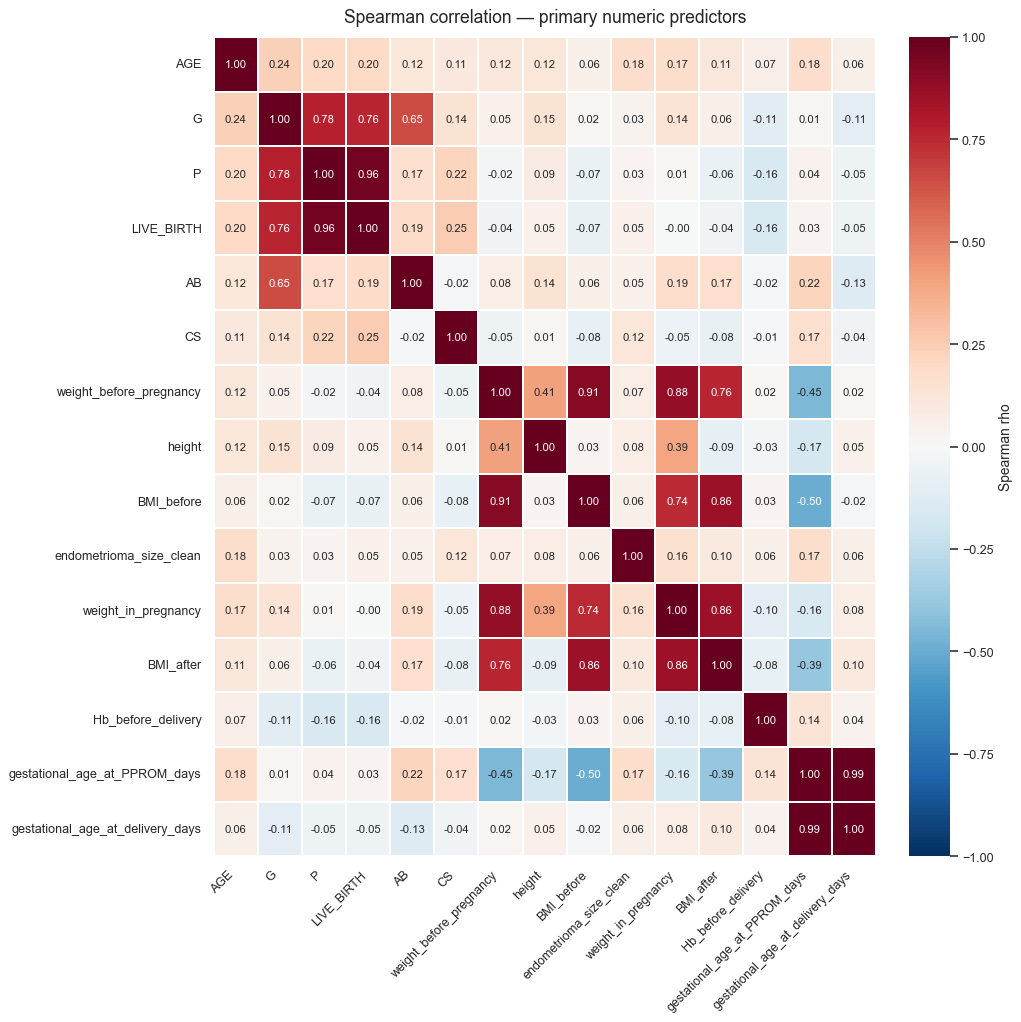

Pairwise Spearman correlation — 105 numeric pairs evaluated with complete-case denominators (BH-FDR applied across all pairs):
  Pairs with |rho|>=0.7: 10

Caution: p-values above are scipy's asymptotic Spearman approximation, not exact/
permutation p-values -- accuracy is not guaranteed for pairs with a small complete-case
N (e.g. the gestational_age_at_PPROM_days pairs, N=16). A very small asymptotic p-value
at low N should not be read as equivalent in reliability to the same p-value at N=431.

High-correlation / redundancy-review pairs (|rho|>=0.7):
                         var1                             var2  N_original  N_complete_pair  N_missing_or_dropped spearman_rho_display p_value_display q_value_bh_display  high_corr_flag  same_redundancy_family redundancy_family
                            G                                P         431              431                     0                0.778         <0.0001            <0.0001            True                    True    

In [29]:
_num_cols = [c for c in PRIMARY_COLS if infer_var_type(df_primary[c]) == "numeric"]
_CORR_THRESH = 0.7

_num_family = {}
for _gname, _gdef in REDUNDANCY_GROUPS.items():
    for _m in _gdef["members"]:
        _num_family[_m] = _gname

if len(_num_cols) >= 2:
    _corr = df_primary[_num_cols].corr(method="spearman")
    fig, ax = plt.subplots(figsize=(max(9, len(_num_cols)*0.75),
                                     max(7, len(_num_cols)*0.75)),
                            layout="constrained")
    sns.heatmap(_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, ax=ax, annot_kws={"size": 9}, linewidths=0.3,
                cbar_kws={"label": "Spearman rho"})
    ax.set_title("Spearman correlation — primary numeric predictors", fontsize=14, pad=12)
    ax.tick_params(axis="x", labelsize=10, rotation=45)
    ax.tick_params(axis="y", labelsize=10, rotation=0)
    plt.setp(ax.get_xticklabels(), ha="right")
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label("Spearman rho", fontsize=11)
    plt.show()

    _high_corr_pairs = []
    _corr_pair_rows = []
    _cols = _corr.columns.tolist()
    for i in range(len(_cols)):
        for j in range(i+1, len(_cols)):
            _pair = df_primary[[_cols[i], _cols[j]]].dropna()
            _n_original = len(df_primary)
            _n_complete = len(_pair)
            _n_dropped = _n_original - _n_complete
            rho = _corr.iloc[i, j]
            # Asymptotic/approximate pairwise p-value (NOT exact/permutation --
            # scipy.stats.spearmanr uses a t-distribution approximation, accurate
            # per scipy's own docs only for large samples >500) via scipy on the
            # same complete-case pair; not derivable from the correlation matrix
            # alone. Small-N pairs (e.g. N=16) should be read with caution
            # regardless of how small the displayed p-value is -- see A2.10a header.
            if _n_complete >= 3:
                _rho_exact, _pv = stats.spearmanr(_pair[_cols[i]], _pair[_cols[j]])
            else:
                _pv = np.nan
            _same_family = (
                _cols[i] in _num_family and _cols[j] in _num_family
                and _num_family[_cols[i]] == _num_family[_cols[j]]
            )
            # Full-precision computational values -- never rounded; *_display
            # columns are formatting only (see fmt_pval()/fmt_effect()).
            _pair_result = {
                "var1": _cols[i],
                "var2": _cols[j],
                "N_original": _n_original,
                "N_complete_pair": _n_complete,
                "N_missing_or_dropped": _n_dropped,
                "spearman_rho": float(rho) if pd.notna(rho) else np.nan,
                "spearman_rho_display": fmt_effect(rho if pd.notna(rho) else None),
                "p_value": float(_pv) if pd.notna(_pv) else np.nan,
                "p_value_display": fmt_pval(_pv if pd.notna(_pv) else None),
                "high_corr_flag": bool(pd.notna(rho) and abs(rho) >= _CORR_THRESH),
                "same_redundancy_family": _same_family,
                "redundancy_family": _num_family.get(_cols[i]) if _same_family else "—",
            }
            _corr_pair_rows.append(_pair_result)
            if pd.notna(rho) and abs(rho) >= _CORR_THRESH:
                _high_corr_pairs.append(_pair_result)

    _corr_pair_df = pd.DataFrame(_corr_pair_rows)
    # BH-FDR always receives the full-precision, unrounded p_value column.
    _corr_pair_df["q_value_bh"] = benjamini_hochberg(_corr_pair_df["p_value"]).values
    _corr_pair_df["q_value_bh_display"] = _corr_pair_df["q_value_bh"].apply(fmt_pval)
    _corr_show = ["var1", "var2", "N_original", "N_complete_pair", "N_missing_or_dropped",
                  "spearman_rho_display", "p_value_display", "q_value_bh_display",
                  "high_corr_flag", "same_redundancy_family", "redundancy_family"]
    print(f"Pairwise Spearman correlation — {len(_corr_pair_df)} numeric pairs evaluated "
          f"with complete-case denominators (BH-FDR applied across all pairs):")
    print(f"  Pairs with |rho|>={_CORR_THRESH}: {len(_high_corr_pairs)}")
    print()
    print("Caution: p-values above are scipy's asymptotic Spearman approximation, not exact/")
    print("permutation p-values -- accuracy is not guaranteed for pairs with a small complete-case")
    print("N (e.g. the gestational_age_at_PPROM_days pairs, N=16). A very small asymptotic p-value")
    print("at low N should not be read as equivalent in reliability to the same p-value at N=431.")
    print()
    if _high_corr_pairs:
        print(f"High-correlation / redundancy-review pairs (|rho|>={_CORR_THRESH}):")
        print(_corr_pair_df[_corr_pair_df["high_corr_flag"]][_corr_show].to_string(index=False))
    else:
        print(f"No numeric pairs with |rho|>={_CORR_THRESH}.")
    print()
    print("Note: |rho| >= 0.7 is a screening flag only. No variable is deleted here")
    print("solely for high correlation -- see A2.10d redundancy groups below and A2.13")
    print("for how redundancy is actually resolved (demotion, not deletion).")
    print("The full pairwise correlation table (_corr_pair_df, all pairs) remains available")
    print("in memory.")
else:
    print(f"Fewer than 2 numeric primary predictors — correlation skipped.")
    _high_corr_pairs = []
    _corr_pair_df = pd.DataFrame()

All eligible numeric-numeric pairs screened: 105. Pairs visualized here (raw p<0.05): 36, across 6 page(s).


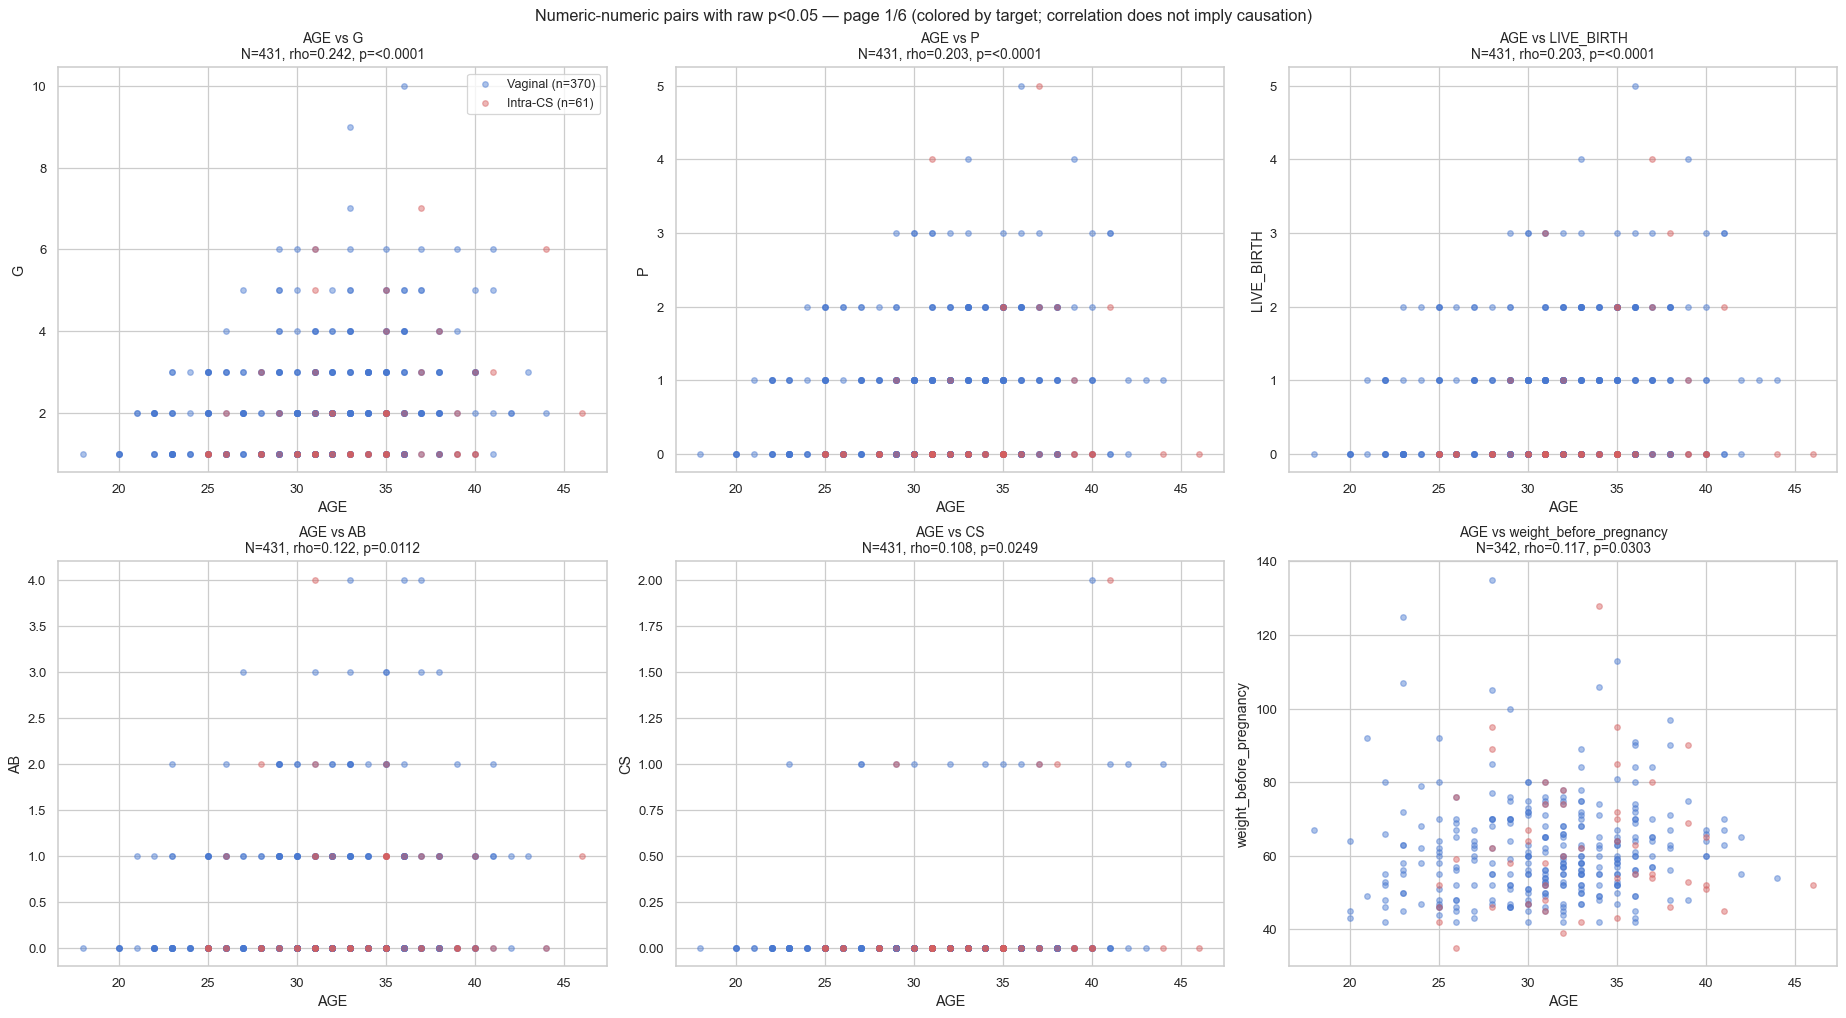

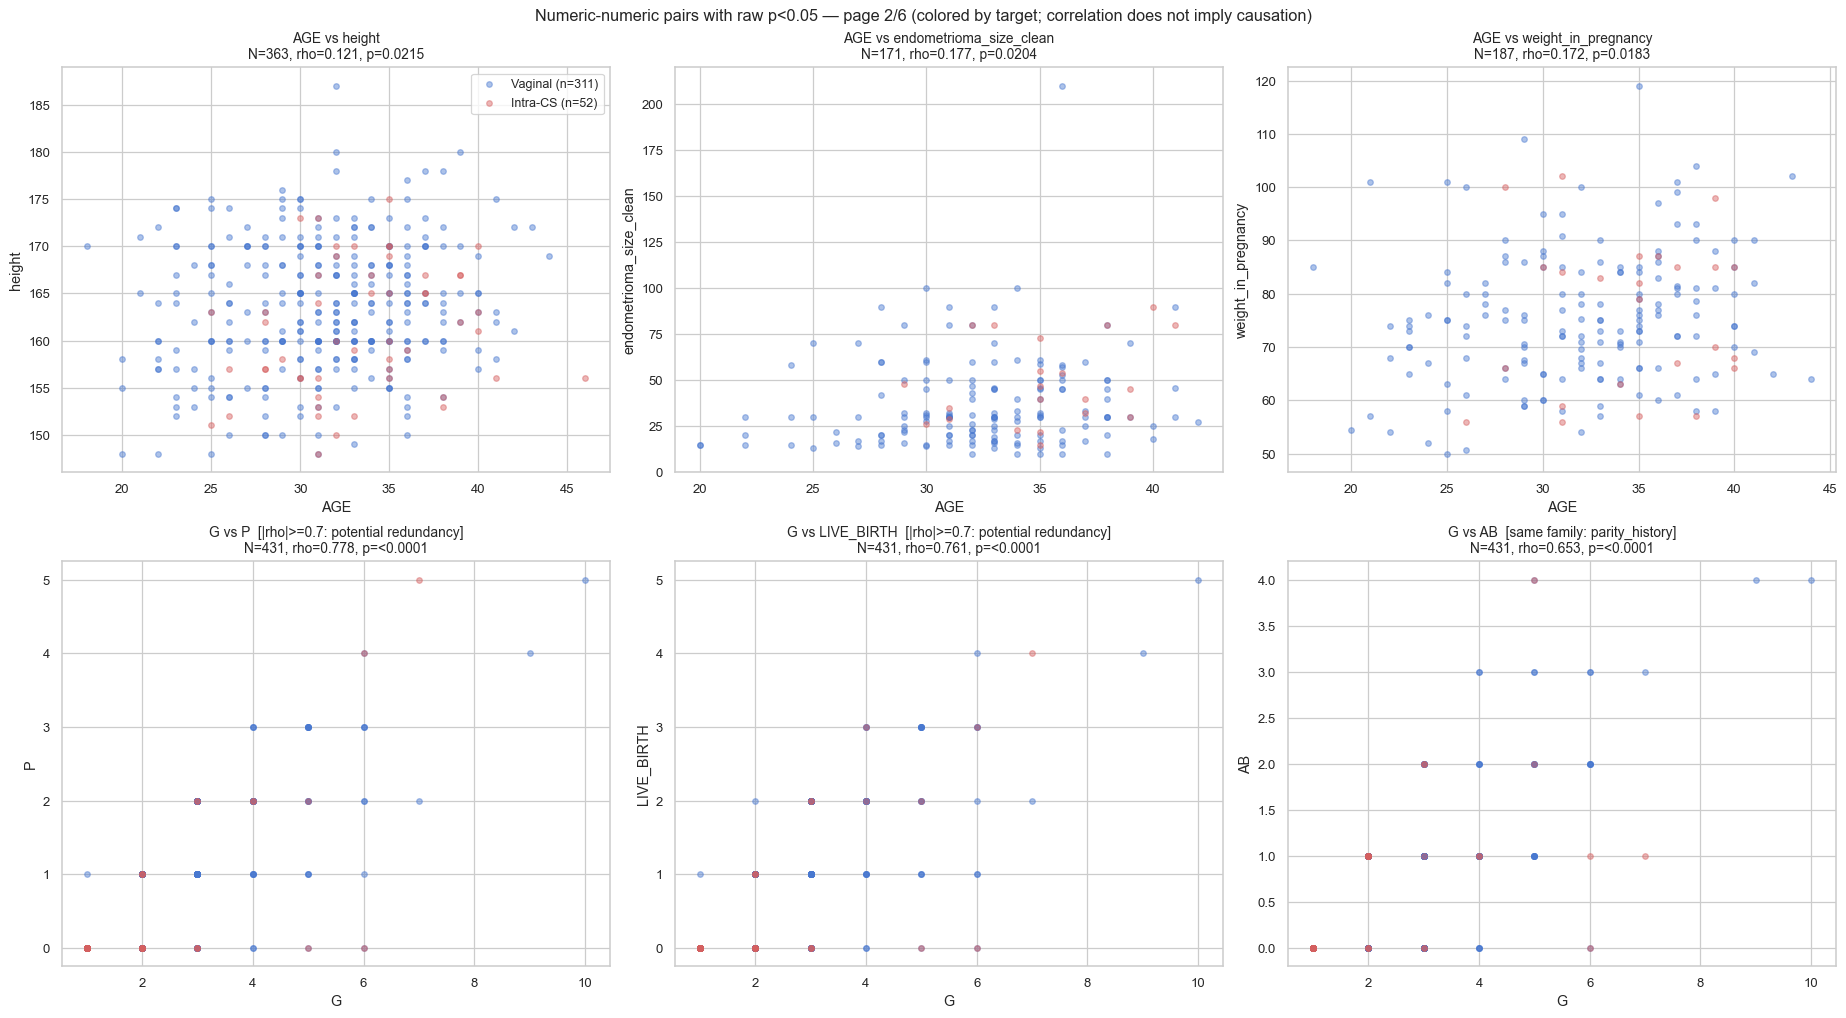

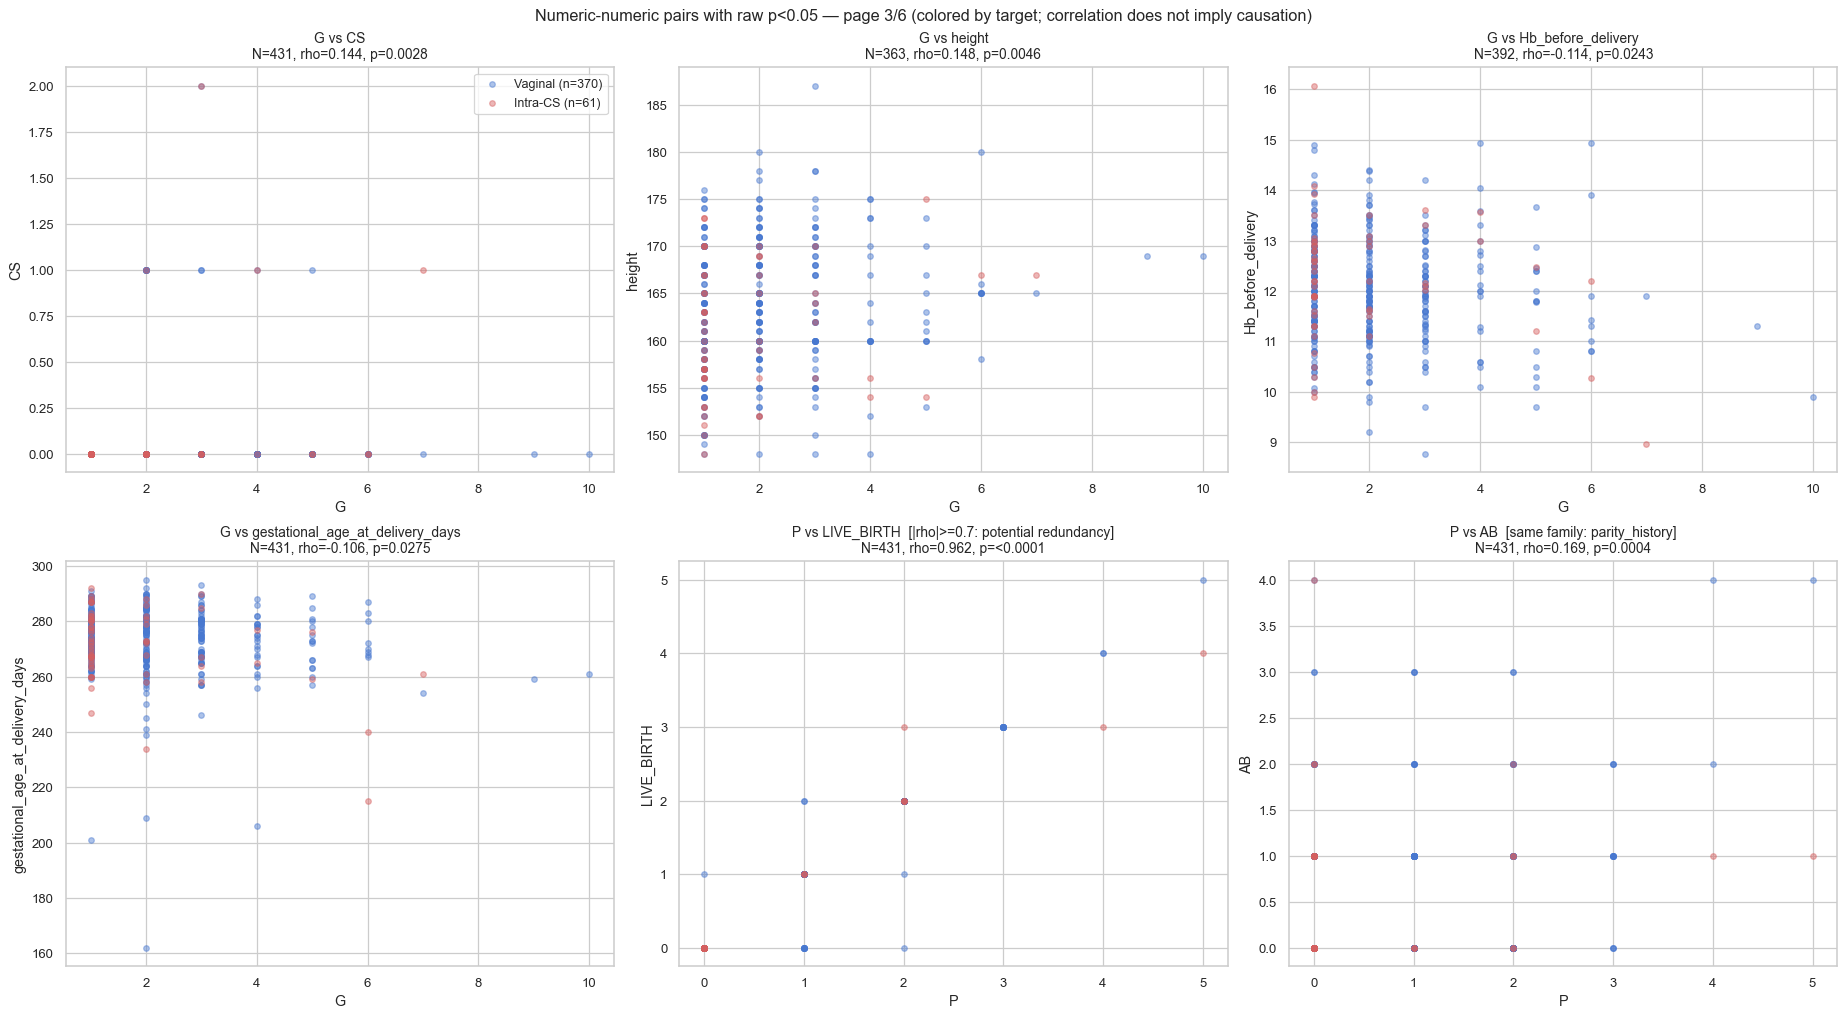

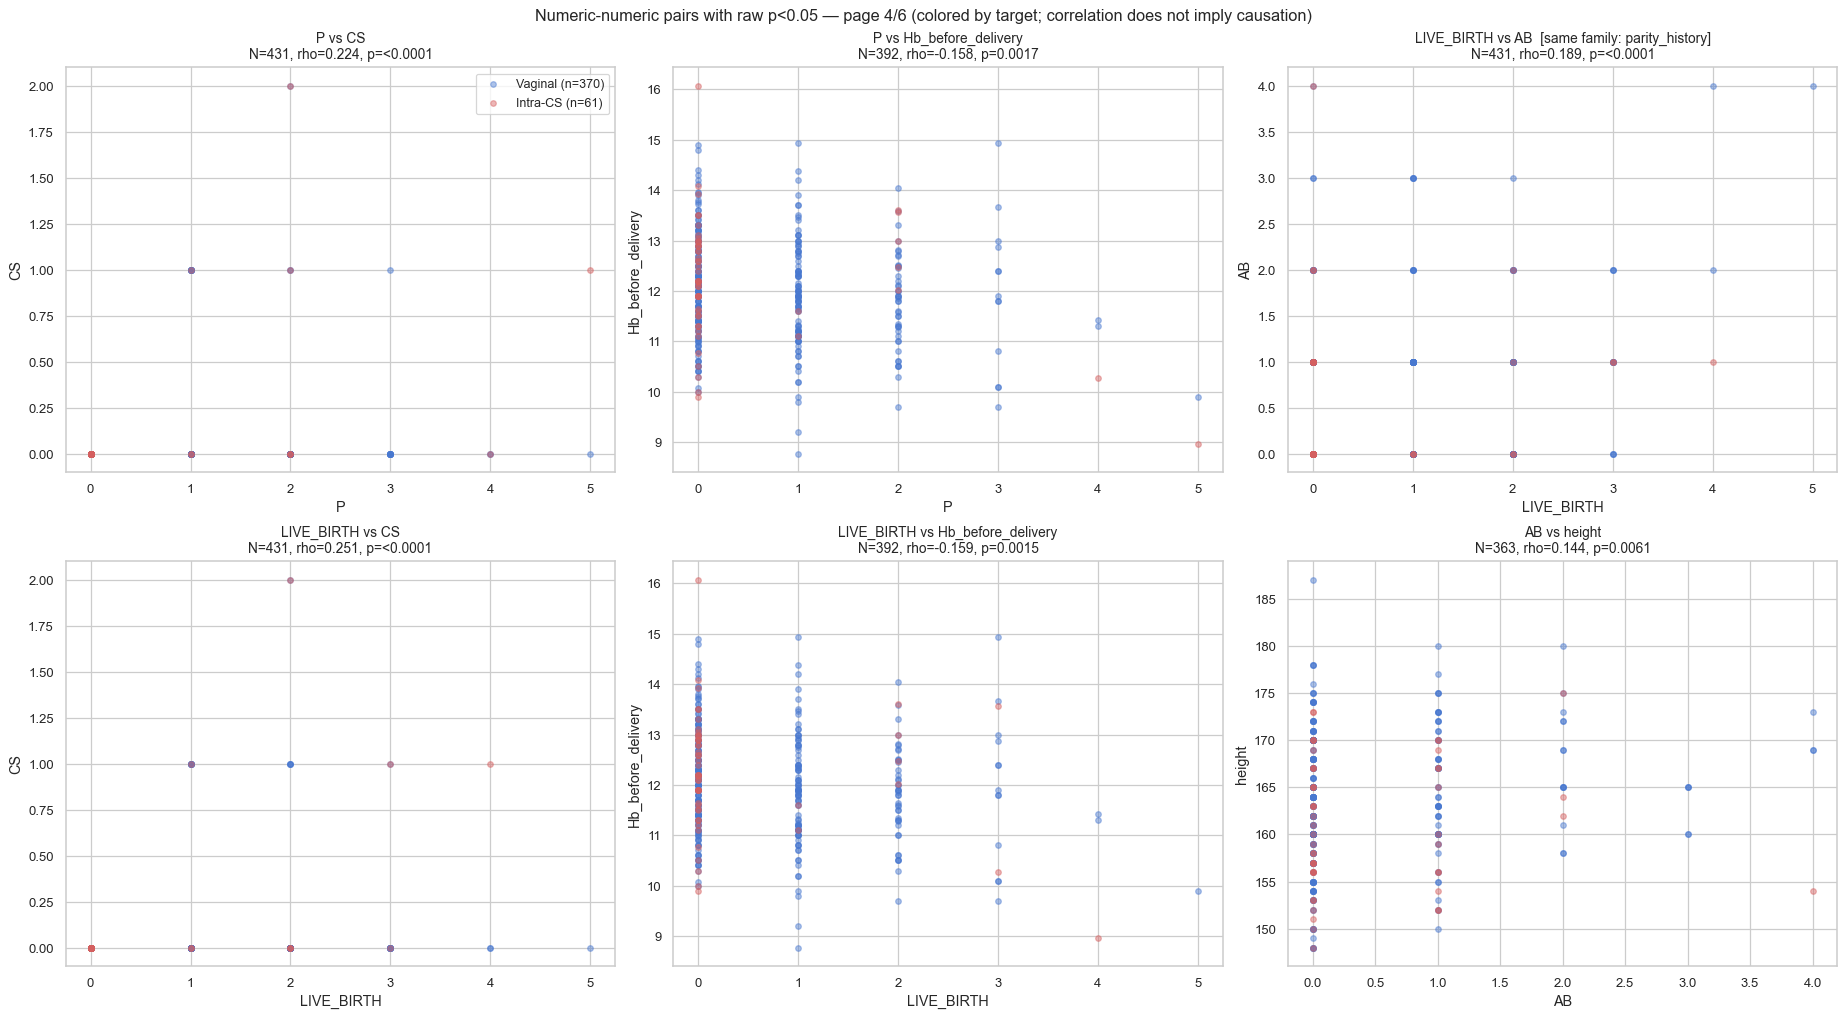

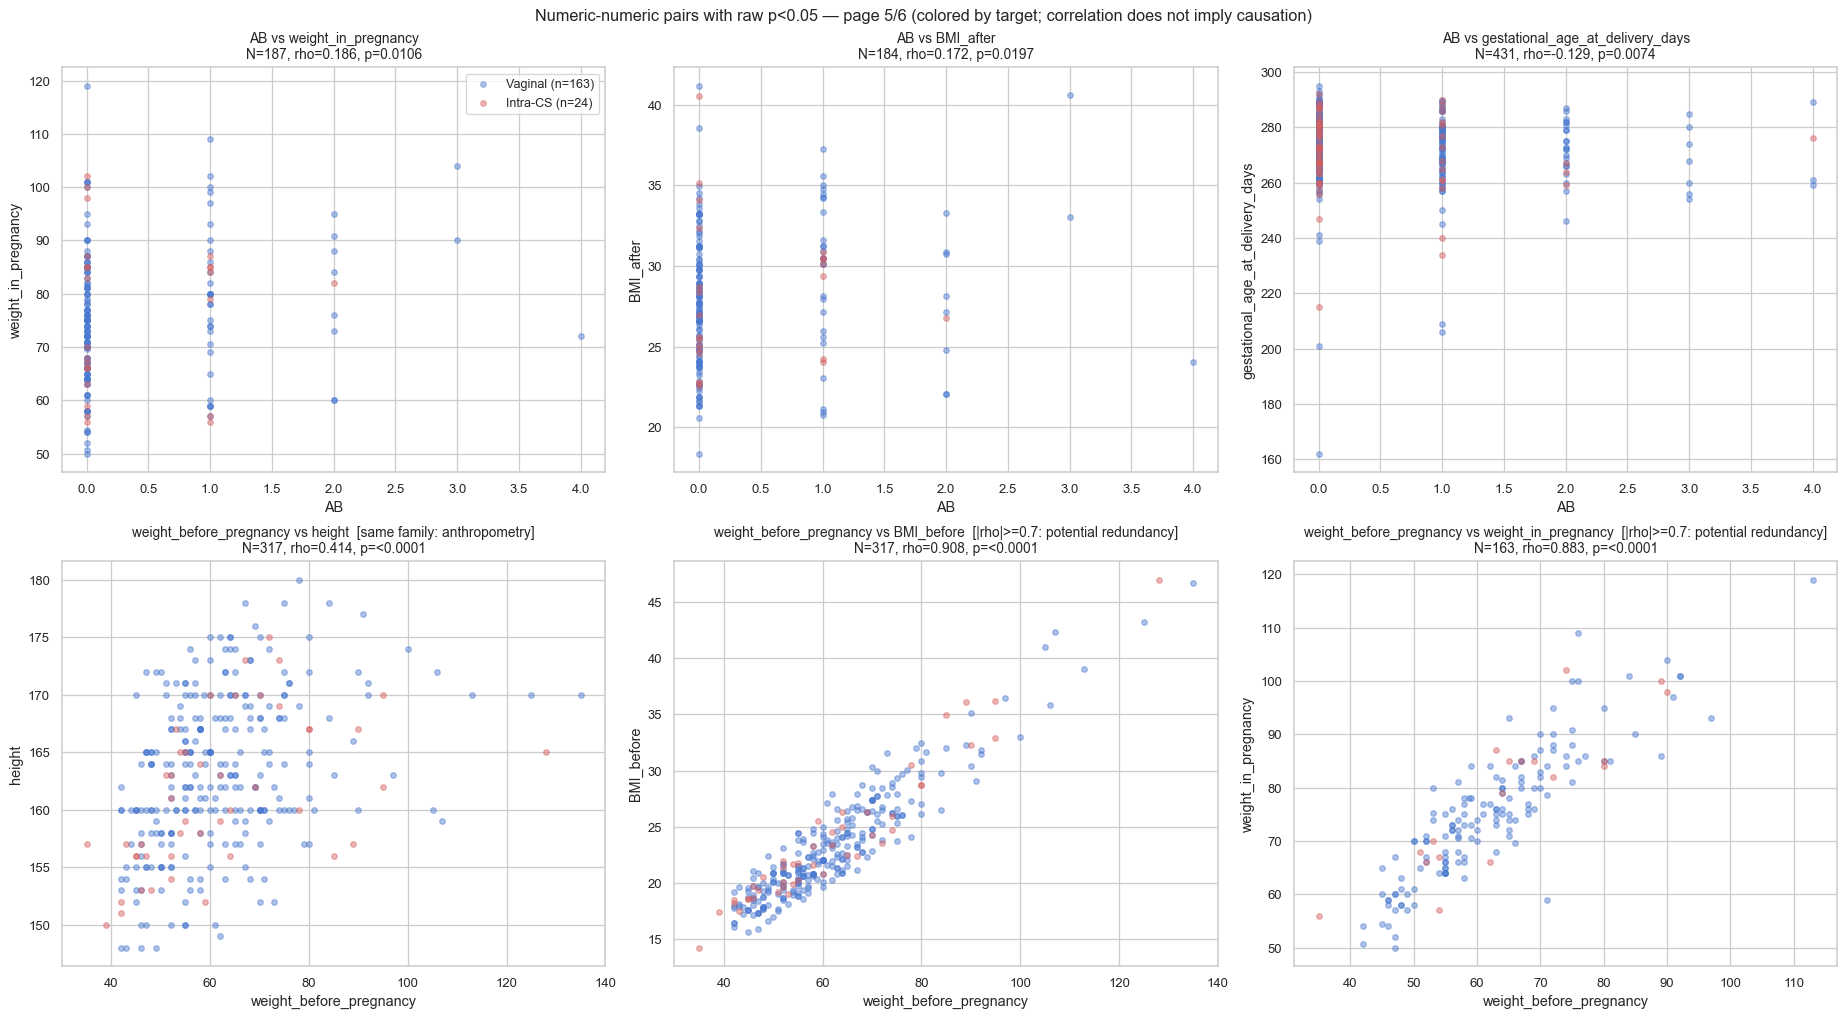

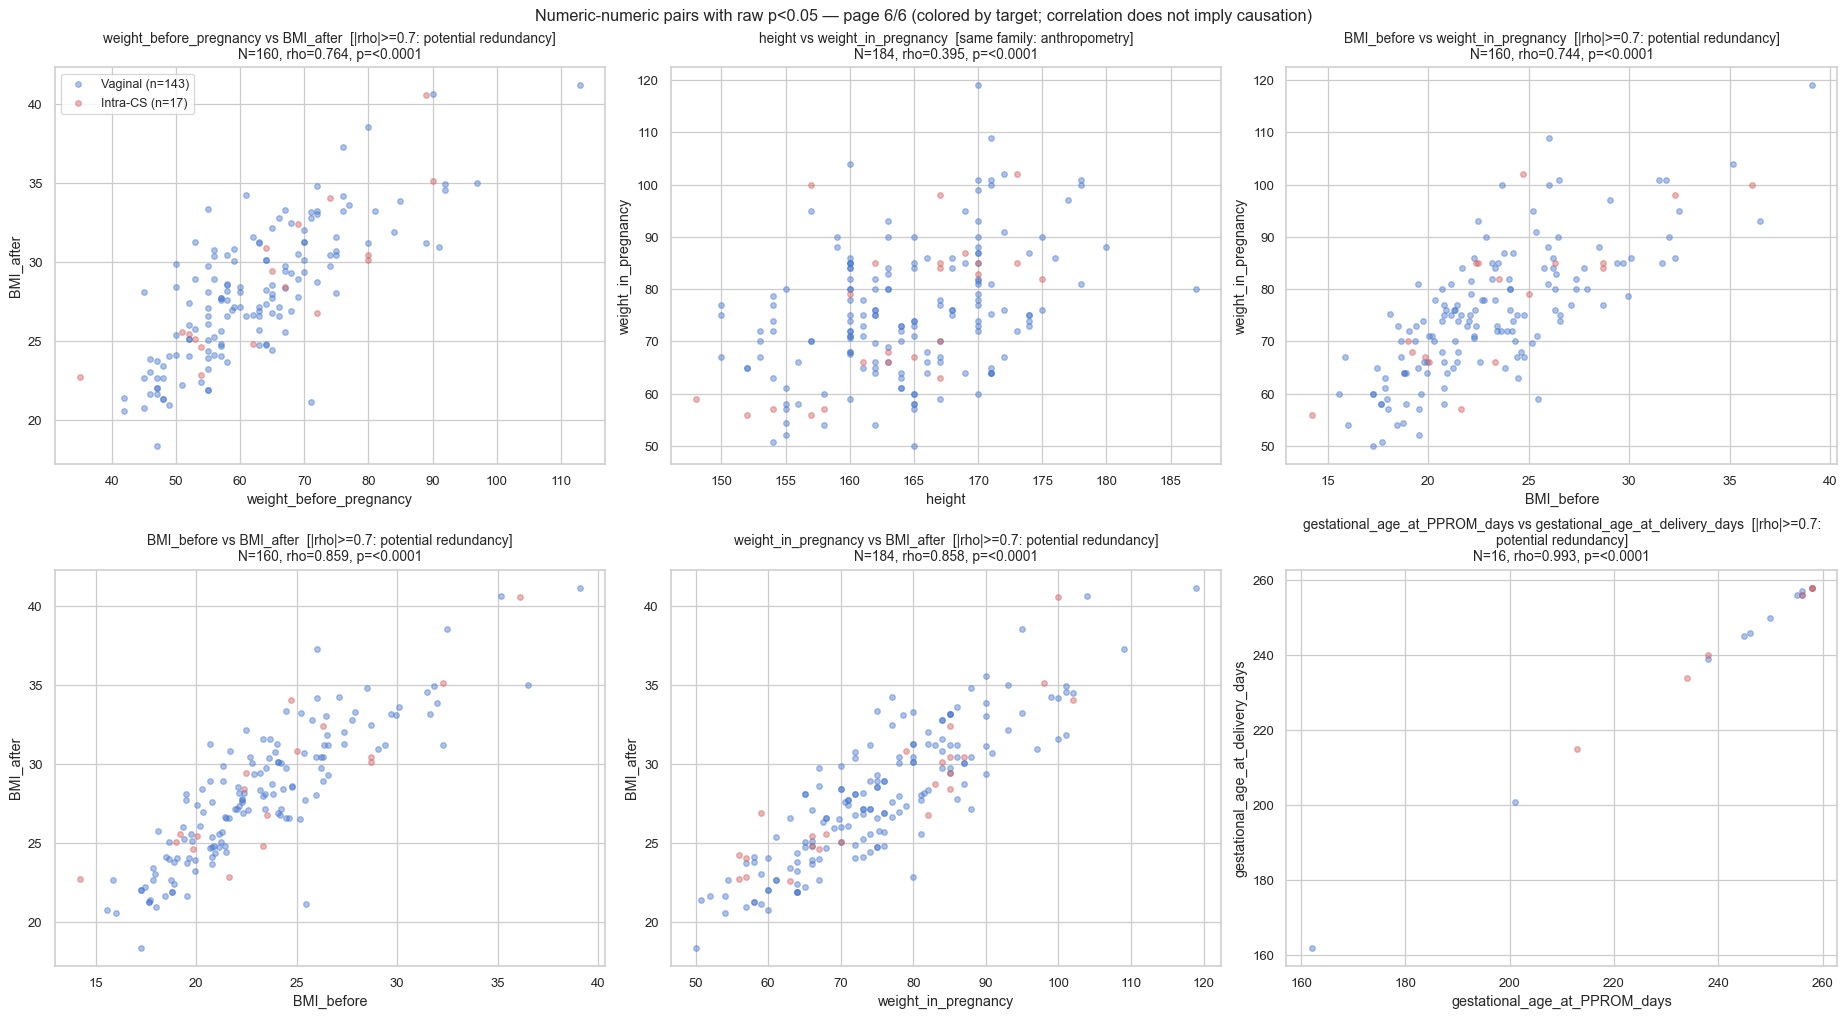

Shown: 36 pair(s) with raw p<0.05, across 6 page(s). Units are the original clinical scale (counts, mm, years as applicable). No fitted trend line is shown; Spearman rho/p already summarize monotonic association.


In [30]:
# Scatterplots for EVERY numeric-numeric pair reaching raw/nominal p<0.05
# (uncorrected -- see the BH-FDR q-value column in the table above for the
# multiplicity-adjusted result) on its Spearman correlation -- all eligible
# pairs are screened in the table above; this cell visualizes all of the
# raw-p-significant ones, paginated to avoid an unreadable wall of plots.
# |rho|>=0.7 pairs and same-redundancy-family pairs are additionally flagged
# in their subplot title as potential redundancy -- flagging is a screening
# signal only, never an automatic deletion; the final call belongs to
# Feature Selection (clinical meaning, timing, missingness, source/derived
# status, modeling relevance).
_scatter_pairs = []
if len(_corr_pair_df):
    for _, r in _corr_pair_df.iterrows():
        if pd.notna(r["p_value"]) and r["p_value"] < 0.05:
            _scatter_pairs.append((r["var1"], r["var2"], r))

# De-duplicate while preserving order
_seen_pairs = set()
_scatter_pairs_dedup = []
for v1, v2, r in _scatter_pairs:
    key = tuple(sorted([v1, v2]))
    if key not in _seen_pairs:
        _seen_pairs.add(key)
        _scatter_pairs_dedup.append((v1, v2, r))

if not _scatter_pairs_dedup:
    print("No numeric-numeric pairs reached raw p<0.05 — no scatterplots generated.")
else:
    _n_sc = len(_scatter_pairs_dedup)
    _NCOLS_SC = 3
    _PER_PAGE = 6  # 2 x 3 grid per page -- a 3x4/12-panel page was too dense for report reuse
    _n_pages = int(np.ceil(_n_sc / _PER_PAGE))
    print(f"All eligible numeric-numeric pairs screened: {len(_corr_pair_df)}. "
          f"Pairs visualized here (raw p<0.05): {_n_sc}, across {_n_pages} page(s).")
    for _page in range(_n_pages):
        _page_pairs = _scatter_pairs_dedup[_page * _PER_PAGE:(_page + 1) * _PER_PAGE]
        _nrows_sc = int(np.ceil(len(_page_pairs) / _NCOLS_SC))
        fig, axes = plt.subplots(_nrows_sc, _NCOLS_SC,
                                  figsize=(6.8 * _NCOLS_SC, 5.6 * _nrows_sc),
                                  layout="constrained")
        axes = np.array(axes).reshape(-1)
        for i, (v1, v2, r) in enumerate(_page_pairs):
            ax = axes[i]
            _sub = df_primary[[v1, v2, TARGET_COL]].dropna()
            for _tval, _color, _label in [(0, C0, "Vaginal"), (1, C1, "Intra-CS")]:
                _pts = _sub[_sub[TARGET_COL] == _tval]
                ax.scatter(_pts[v1], _pts[v2], alpha=0.45, s=20, color=_color,
                           label=f"{_label} (n={len(_pts)})")
            _flag = ""
            if r["high_corr_flag"]:
                _flag = "  [|rho|>=0.7: potential redundancy]"
            elif r["same_redundancy_family"]:
                _flag = f"  [same family: {r['redundancy_family']}]"
            ax.set_xlabel(v1, fontsize=11.5)
            ax.set_ylabel(v2, fontsize=11.5)
            ax.tick_params(labelsize=10.5)
            # Display-formatted values (fmt_effect()/fmt_pval(), already
            # computed in _corr_pair_df above) -- not the raw full-precision
            # floats, which can render as very long strings (e.g. a p-value
            # like 7.393711705479312e-121) and visually overflow into the
            # neighboring subplot's title area. Formatting only; the
            # underlying _corr_pair_df/statistics are unchanged.
            ax.set_title(f"{v1} vs {v2}{_flag}\nN={len(_sub)}, rho={r['spearman_rho_display']}, "
                         f"p={r['p_value_display']}", fontsize=11, wrap=True, pad=9)
            if i == 0:
                ax.legend(fontsize=10, loc="best")
        for j in range(len(_page_pairs), len(axes)):
            axes[j].set_visible(False)
        fig.suptitle(f"Numeric-numeric pairs with raw p<0.05 — page {_page + 1}/{_n_pages} "
                     f"(colored by target; correlation does not imply causation)",
                     fontsize=13)
        plt.show()
    print(f"Shown: {_n_sc} pair(s) with raw p<0.05, across {_n_pages} page(s). Units are the "
          f"original clinical scale (counts, mm, years as applicable). No fitted trend "
          f"line is shown; Spearman rho/p already summarize monotonic association.")

**Key observations — numeric-numeric relationships:**

In [31]:
if len(_corr_pair_df):
    print(f"- {len(_corr_pair_df)} eligible numeric-numeric pairs screened; "
          f"{int((_corr_pair_df['p_value'] < 0.05).sum())} reached raw p<0.05 and are "
          f"visualized above; {len(_high_corr_pairs)} exceed |rho|>=0.7.")
    if _high_corr_pairs:
        # Group by pre-specified redundancy family rather than a single blanket
        # "count/anthropometry" label -- a pair with no registered family (e.g. the
        # gestational-timing PPROM/delivery pair) is not the same kind of finding as
        # a parity-count or weight/BMI pair and must not be summarized as if it were.
        _hc_by_family = {}
        for p in _high_corr_pairs:
            _hc_by_family.setdefault(p["redundancy_family"], []).append(p)
        for _fam, _pairs in _hc_by_family.items():
            _fam_label = _fam if _fam != "—" else "no pre-specified redundancy family"
            print(f"- Potential redundancy (|rho|>=0.7), {_fam_label}: "
                  f"{[(p['var1'], p['var2']) for p in _pairs]}")
            for p in _pairs:
                if p["N_complete_pair"] < 30:
                    print(f"    CAUTION: {p['var1']} <--> {p['var2']} has only "
                          f"N={p['N_complete_pair']} complete-case pairs -- a small, "
                          f"weakly generalizable sample; the strong observed correlation "
                          f"does NOT by itself establish redundancy at this N.")
        print("- Requires consideration during Feature Selection, not resolved here.")
    print("- No numeric predictor is removed or transformed based on this screening.")
else:
    print("- Fewer than 2 numeric primary predictors; correlation screening skipped.")

- 105 eligible numeric-numeric pairs screened; 36 reached raw p<0.05 and are visualized above; 10 exceed |rho|>=0.7.
- Potential redundancy (|rho|>=0.7), parity_history: [('G', 'P'), ('G', 'LIVE_BIRTH'), ('P', 'LIVE_BIRTH')]
- Potential redundancy (|rho|>=0.7), anthropometry: [('weight_before_pregnancy', 'BMI_before'), ('weight_before_pregnancy', 'weight_in_pregnancy'), ('weight_before_pregnancy', 'BMI_after'), ('BMI_before', 'weight_in_pregnancy'), ('BMI_before', 'BMI_after'), ('weight_in_pregnancy', 'BMI_after')]
- Potential redundancy (|rho|>=0.7), no pre-specified redundancy family: [('gestational_age_at_PPROM_days', 'gestational_age_at_delivery_days')]
    CAUTION: gestational_age_at_PPROM_days <--> gestational_age_at_delivery_days has only N=16 complete-case pairs -- a small, weakly generalizable sample; the strong observed correlation does NOT by itself establish redundancy at this N.
- Requires consideration during Feature Selection, not resolved here.
- No numeric predictor is

### A2.10b — Numeric × Categorical Predictor Relationships

**Purpose:** Systematically screen relationships between eligible numeric predictors and
eligible categorical/binary predictors -- predictor-predictor, not predictor-vs-target
(A2.9 already covers vs-target). This closes the gap between A2.10a's numeric-numeric
correlation (above) and the categorical-categorical screening (below, A2.10c), completing
predictor-predictor relationship coverage for the primary predictor set.

**What this checks:**
- Every (numeric predictor, categorical/binary predictor) pair among `PRIMARY_COLS`
- 2 groups -> Mann-Whitney U (+ rank-biserial |r|)
- 3+ groups -> Kruskal-Wallis (+ epsilon-squared)
- Analytical N and per-group N for every pair (complete cases for that pair only)
- Pairs with fewer than 2 usable groups (a group needs >=3 observations to be tested)
  are skipped and reported separately, never silently dropped
- Benjamini-Hochberg FDR across all screened pairs (informational)

**What this does NOT do:**
- Does not assume normality — tests are nonparametric by design, matching the
  numeric-vs-target approach already used in A2.9
- Does not remove, impute, or transform any variable
- Does not decide feature inclusion — exploratory screening only

**Output:** Full screening table (`numcat_df`, all eligible pairs) + paginated boxplots
for the subset that reaches BH-FDR q<0.05, OR reaches raw/nominal p<0.05 **and** has a
moderate-or-larger effect size (both conditions are required together on the raw-p
branch — a moderate/large effect size alone, without raw p<0.05, is **not** sufficient
to be plotted; such pairs remain visible in the full `numcat_df` table but are not
plotted here). The screening table is comprehensive; plots are selective by design
(see Key observations below for the exact all-screened vs. visualized counts).

In [32]:
def _kw_epsilon_squared(H, k, n):
    # Epsilon-squared effect size for Kruskal-Wallis (Tomczak & Tomczak, 2014) --
    # same descriptive small/moderate/large convention as eta-squared.
    if n <= k:
        return np.nan
    return (H - k + 1) / (n - k)


def _numcat_effect_magnitude(effect_type, eff):
    if eff is None or (isinstance(eff, float) and np.isnan(eff)):
        return "—"
    if effect_type == "rank_biserial_r":
        return "small" if eff < 0.3 else ("moderate" if eff < 0.5 else "large")
    return "small" if eff < 0.06 else ("moderate" if eff < 0.14 else "large")  # epsilon-squared


_catlike_cols = [c for c in PRIMARY_COLS if infer_var_type(df_primary[c]) in ("binary", "categorical")]
print(f"Numeric predictors: {len(_num_cols)} | Categorical/binary predictors: {len(_catlike_cols)}")
print(f"Total eligible numeric x categorical pairs: {len(_num_cols) * len(_catlike_cols)}")
print()

_numcat_rows = []
_numcat_skipped = []
for _num in _num_cols:
    for _cat in _catlike_cols:
        _sub = df_primary[[_num, _cat]].dropna()
        _n_complete = len(_sub)
        _grp = _sub.groupby(_cat)[_num]
        _group_ns_all = _grp.size().to_dict()
        _groups = {lvl: vals.values for lvl, vals in _grp if len(vals) >= 3}
        _n_groups_total = _sub[_cat].nunique()
        if len(_groups) < 2:
            _numcat_skipped.append({
                "numeric": _num, "categorical": _cat, "N": _n_complete,
                "n_groups_total": _n_groups_total,
                "n_groups_usable": len(_groups),
                "reason": "fewer than 2 groups with >=3 observations",
            })
            continue
        _k = len(_groups)
        # N actually entering the test -- may be smaller than _n_complete
        # whenever one or more category levels have <3 observations (those
        # levels are excluded from the test but were part of the complete-
        # case pair). This is the denominator that must be reported as the
        # pair's primary "N" -- see the restricted-level fields below.
        _n_tested = sum(len(v) for v in _groups.values())
        _n_levels_excluded_lt3 = _n_groups_total - _k
        if _k == 2:
            _g0, _g1 = list(_groups.values())
            _stat, _pval = stats.mannwhitneyu(_g0, _g1, alternative="two-sided")
            _eff = abs(1 - (2 * _stat) / (len(_g0) * len(_g1)))
            _test, _eff_type = "Mann-Whitney U", "rank_biserial_r"
        else:
            _stat, _pval = stats.kruskal(*_groups.values())
            _eff = _kw_epsilon_squared(_stat, _k, _n_tested)
            _test, _eff_type = "Kruskal-Wallis", "epsilon_squared"
        # Share-safe: group_Ns_str must not suppress each category's group
        # size INDEPENDENTLY via plain safe_count(), because N_tested (the
        # sum of the >=3-observation groups) is printed alongside this string
        # in the same row/panel (e.g. a plot title). A safe-looking large
        # group next to a safe N_tested still discloses a small remaining
        # group by subtraction (e.g. N_tested=16, one group=13 -> the other
        # group=3, exactly the reconstruction this project's own share_safe
        # module warns about).
        # share_safe.safe_combine_rare_levels() (the same helper already
        # used for A2.4/A2.7/Stage2-3's own level-count breakdowns) is the
        # correct general approach here too: it protects against a reader who
        # knows the overall total and the individually-shown level totals,
        # by folding small levels together until the combined bucket is
        # itself either empty or safely >=5.
        # Built from _groups (the >=3-observation
        # subset actually entering the test, matching _n_tested exactly), NOT
        # _group_ns_all (every level, matching the DELIBERATELY-hidden
        # _n_complete/N_complete_case). safe_combine_rare_levels() already
        # protects any single rare level's exact count from being isolated
        # within this breakdown -- but the breakdown's own SUM is just as
        # disclosive as a single number: summing to _n_complete would silently
        # defeat N_complete_case's own suppression (see the comment on
        # N_complete_case above) by letting a reader recompute it directly
        # from the visible parts. Summing to _n_tested instead reveals nothing
        # beyond what N_tested (already safely printed elsewhere) discloses.
        _group_ns_tested = {lvl: len(vals) for lvl, vals in _groups.items()}
        _group_ns_visible, _group_ns_combined_n, _group_ns_combined_k = share_safe.safe_combine_rare_levels(
            _group_ns_tested, threshold=5
        )
        _group_ns_parts = [f"{k}:{v}" for k, v in _group_ns_visible.items()]
        if _group_ns_combined_k:
            if _group_ns_combined_n is not None and _group_ns_combined_n >= 5:
                _group_ns_parts.append(
                    share_safe.format_combined_levels_note(_group_ns_combined_k, _group_ns_combined_n, unit="level")
                )
            else:
                _group_ns_parts.append(
                    f"{_group_ns_combined_k} smaller level(s) suppressed (too few even combined)"
                )
        _group_ns_str = ", ".join(_group_ns_parts) if _group_ns_parts else "suppressed (n<5 in every level)"

        # Full-precision computational values -- never rounded; *_display
        # columns are formatting only (see fmt_pval()/fmt_effect()).
        _numcat_rows.append({
            "numeric": _num, "categorical": _cat,
            "numeric_earliest_entry_stage": PRIMARY_COLS_EARLIEST_STAGE.get(_num),
            "categorical_earliest_entry_stage": PRIMARY_COLS_EARLIEST_STAGE.get(_cat),
            "n_groups": _k,
            "n_groups_total": _n_groups_total,
            "n_levels_excluded_lt3": _n_levels_excluded_lt3,
            "restricted_level_analysis": _n_levels_excluded_lt3 > 0,
            # N_tested is the statistical test's actual denominator (sum of
            # only the levels with >=3 observations) -- this, NOT the larger
            # complete-case count, is the primary N for this pair.
            "N_tested": _n_tested,
            # N_complete_case is kept for internal/audit purposes ONLY -- it
            # is deliberately excluded from _show_nc (the publicly displayed
            # table below) and from plot titles (A2.10b plots), because
            # displaying N_complete_case next to N_tested would let a reader
            # back out the exact patient count of an excluded rare (<3)
            # category level by simple subtraction, defeating the existing
            # group_Ns_str share-safe suppression on that same level.
            "N_complete_case": _n_complete,
            "group_Ns": _group_ns_all,
            # group_Ns (the raw dict) is kept unsuppressed for any internal
            # computation but is never included in the displayed columns
            # (_show_nc below); group_Ns_str (computed above, share-safe) is
            # the only display-facing version.
            "group_Ns_str": _group_ns_str,
            "test": _test,
            "statistic": float(_stat),
            "p_value": float(_pval) if pd.notna(_pval) else np.nan,
            "p_value_display": fmt_pval(_pval if pd.notna(_pval) else None),
            "effect_size": float(_eff) if pd.notna(_eff) else np.nan,
            "effect_size_display": fmt_effect(_eff if pd.notna(_eff) else None),
            "effect_type": _eff_type,
            "effect_magnitude": _numcat_effect_magnitude(_eff_type, _eff),
        })

numcat_df = pd.DataFrame(_numcat_rows)
# BH-FDR always receives the full-precision, unrounded p_value column.
numcat_df["q_value_bh"] = benjamini_hochberg(numcat_df["p_value"]).values
numcat_df["fdr_sig"] = numcat_df["q_value_bh"] < 0.05
numcat_df["q_value_bh_display"] = numcat_df["q_value_bh"].apply(fmt_pval)

print(f"Pairs screened: {len(numcat_df)} | Pairs skipped (insufficient groups): {len(_numcat_skipped)}")
print(f"Raw p<0.05: {int((numcat_df['p_value'] < 0.05).sum())} | "
      f"BH-FDR q<0.05: {int(numcat_df['fdr_sig'].sum())}")
_n_restricted_level = int(numcat_df["restricted_level_analysis"].sum())
print(f"Restricted-level analyses (>=1 category level with <3 complete-case observations "
      f"excluded from the test; tested on the remaining levels only): {_n_restricted_level} "
      f"of {len(numcat_df)} -- see n_groups vs n_groups_total/n_levels_excluded_lt3 below. "
      f"Only the NUMBER of excluded levels is shown, never their exact patient count.")
print()

_numcat_sig = numcat_df[
    numcat_df["fdr_sig"]
    | ((numcat_df["p_value"] < 0.05) & numcat_df["effect_magnitude"].isin(["moderate", "large"]))
].sort_values("effect_size", ascending=False, na_position="last")

# NOTE: N_tested (the statistical test's actual denominator), not the larger
# N_complete_case, is shown here as the pair's primary N -- see the row-
# construction comment above. n_groups_total/n_levels_excluded_lt3 disclose
# how many levels were excluded (count only, never their exact size) so a
# restricted-level analysis is explicit rather than silently implied.
_show_nc = ["numeric", "numeric_earliest_entry_stage", "categorical",
            "categorical_earliest_entry_stage", "n_groups", "n_groups_total",
            "n_levels_excluded_lt3", "restricted_level_analysis", "N_tested",
            "group_Ns_str", "test", "p_value_display", "q_value_bh_display",
            "effect_size_display", "effect_magnitude"]
print(f"Significant/relevant pairs (BH-FDR q<0.05 OR [raw p<0.05 AND moderate+ effect]): {len(_numcat_sig)}")
if len(_numcat_sig):
    print(_numcat_sig[_show_nc].head(20).to_string(index=False))
    if len(_numcat_sig) > 20:
        print(f"... ({len(_numcat_sig) - 20} more rows; full result in numcat_df)")
else:
    print("None.")
print()
if _numcat_skipped:
    print(f"Skipped pairs (insufficient usable groups): {len(_numcat_skipped)} "
          f"e.g. {[(r['numeric'], r['categorical']) for r in _numcat_skipped[:5]]}"
          f"{' ...' if len(_numcat_skipped) > 5 else ''}")
print()
print("NOTE: numcat_df holds the FULL screening table (all eligible pairs, including")
print("non-significant ones); only the significant/relevant subset above and the plots")
print("below are shown inline. All pairs screened vs. pairs visualized are reported")
print("separately by design.")

Numeric predictors: 15 | Categorical/binary predictors: 52
Total eligible numeric x categorical pairs: 780



Pairs screened: 678 | Pairs skipped (insufficient groups): 102
Raw p<0.05: 119 | BH-FDR q<0.05: 49
Restricted-level analyses (>=1 category level with <3 complete-case observations excluded from the test; tested on the remaining levels only): 51 of 678 -- see n_groups vs n_groups_total/n_levels_excluded_lt3 below. Only the NUMBER of excluded levels is shown, never their exact patient count.

Significant/relevant pairs (BH-FDR q<0.05 OR [raw p<0.05 AND moderate+ effect]): 72
                         numeric  numeric_earliest_entry_stage              categorical  categorical_earliest_entry_stage  n_groups  n_groups_total  n_levels_excluded_lt3  restricted_level_analysis  N_tested                                                                     group_Ns_str           test p_value_display q_value_bh_display effect_size_display effect_magnitude
                              CS                             1                   S_P_CS                                 1         2               

Boxplots for 72 significant/relevant pair(s) (of 678 screened), 18 page(s):


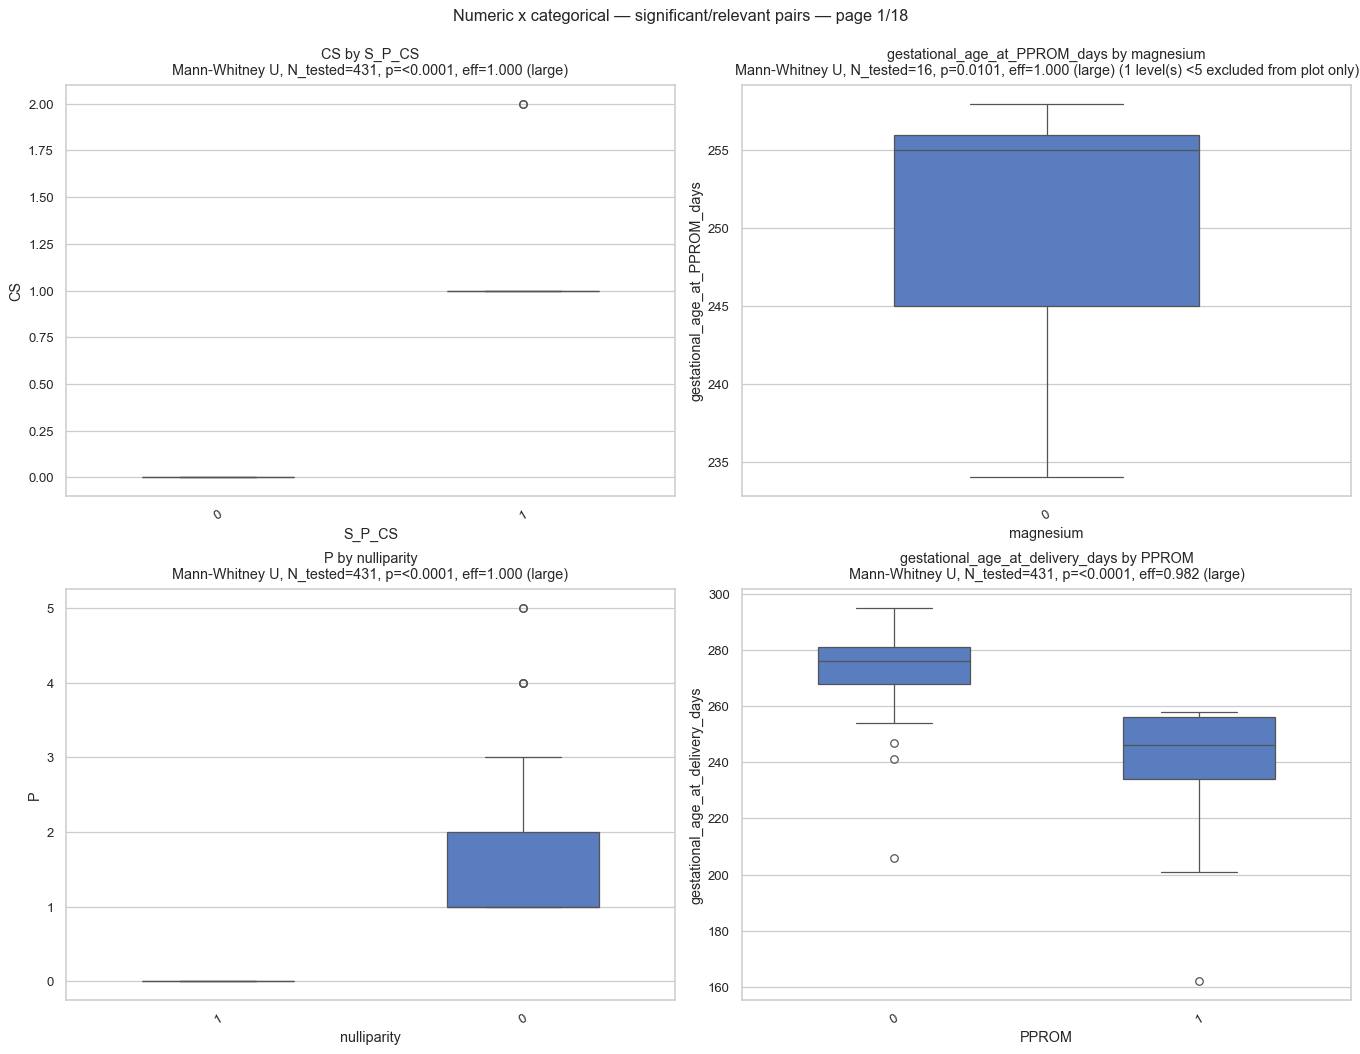

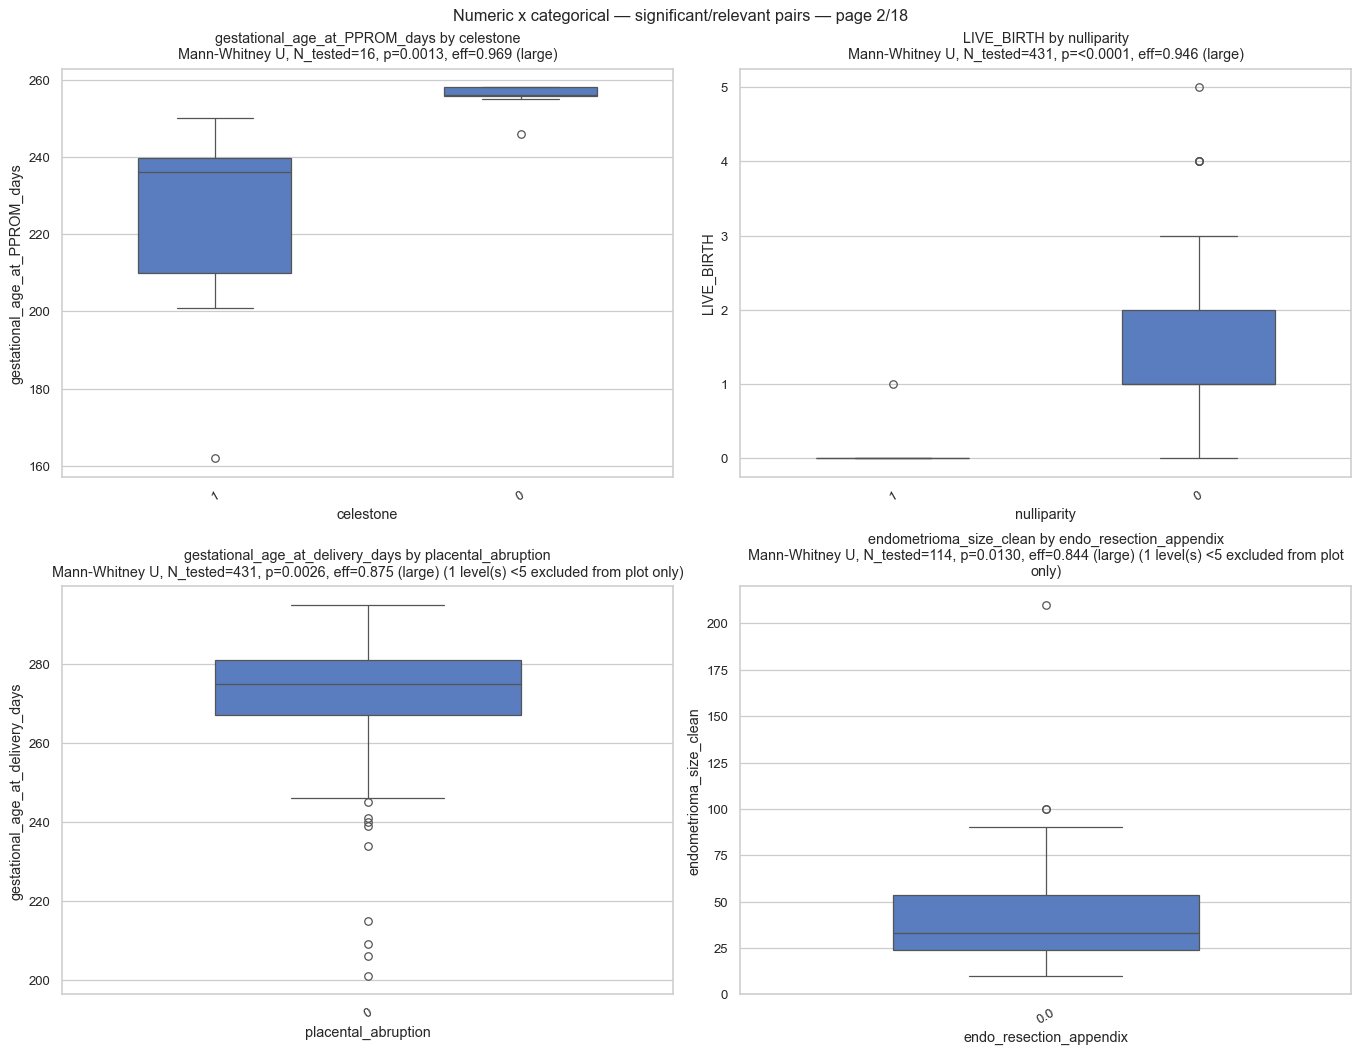

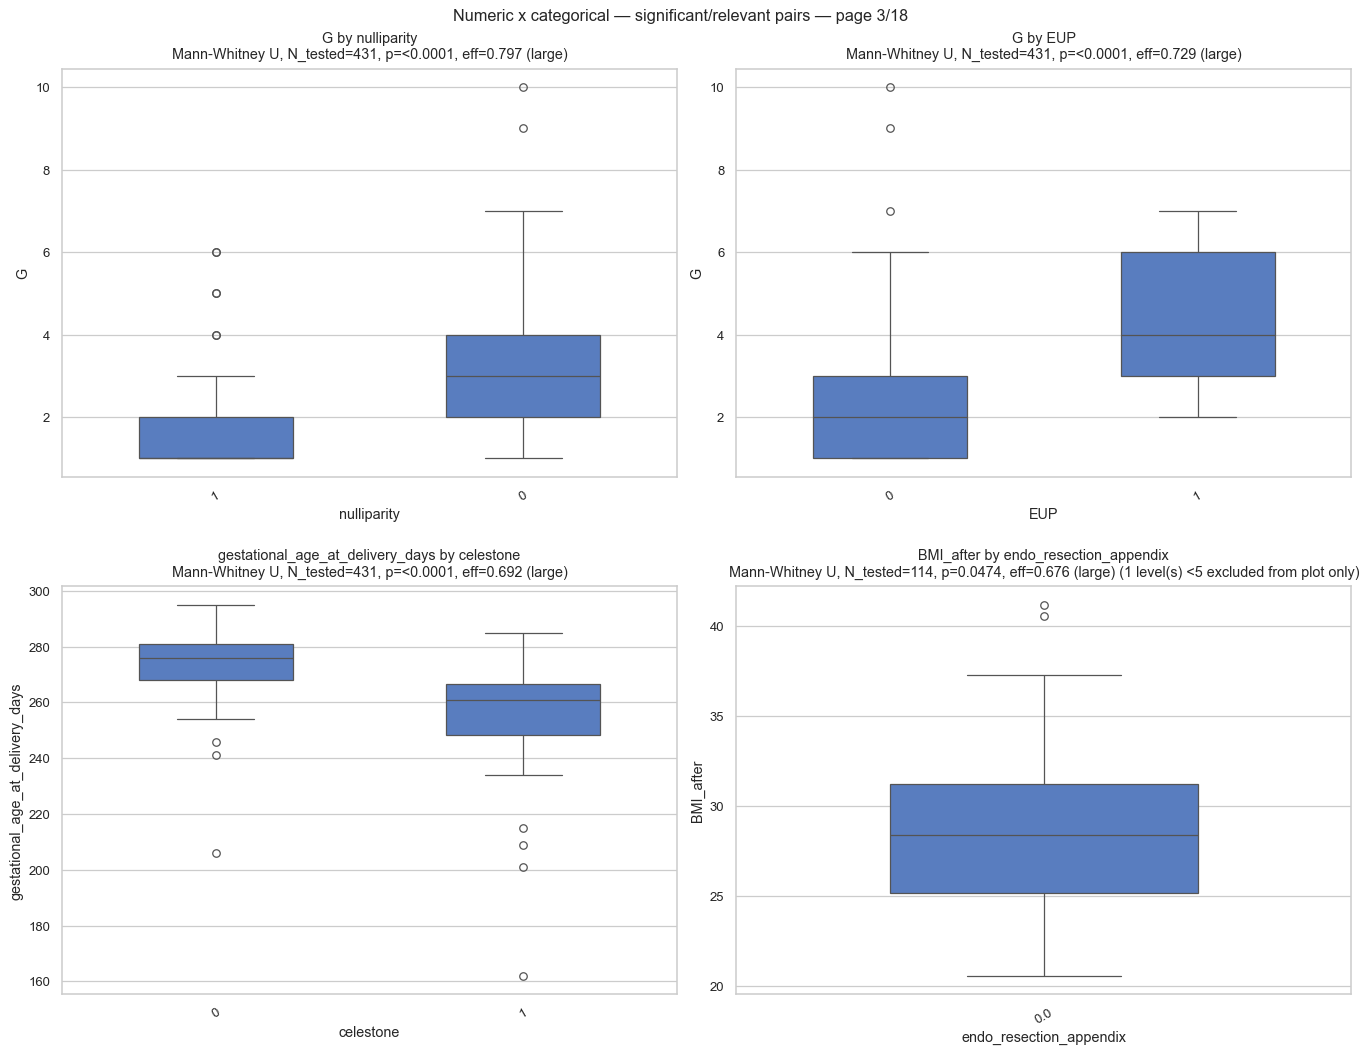

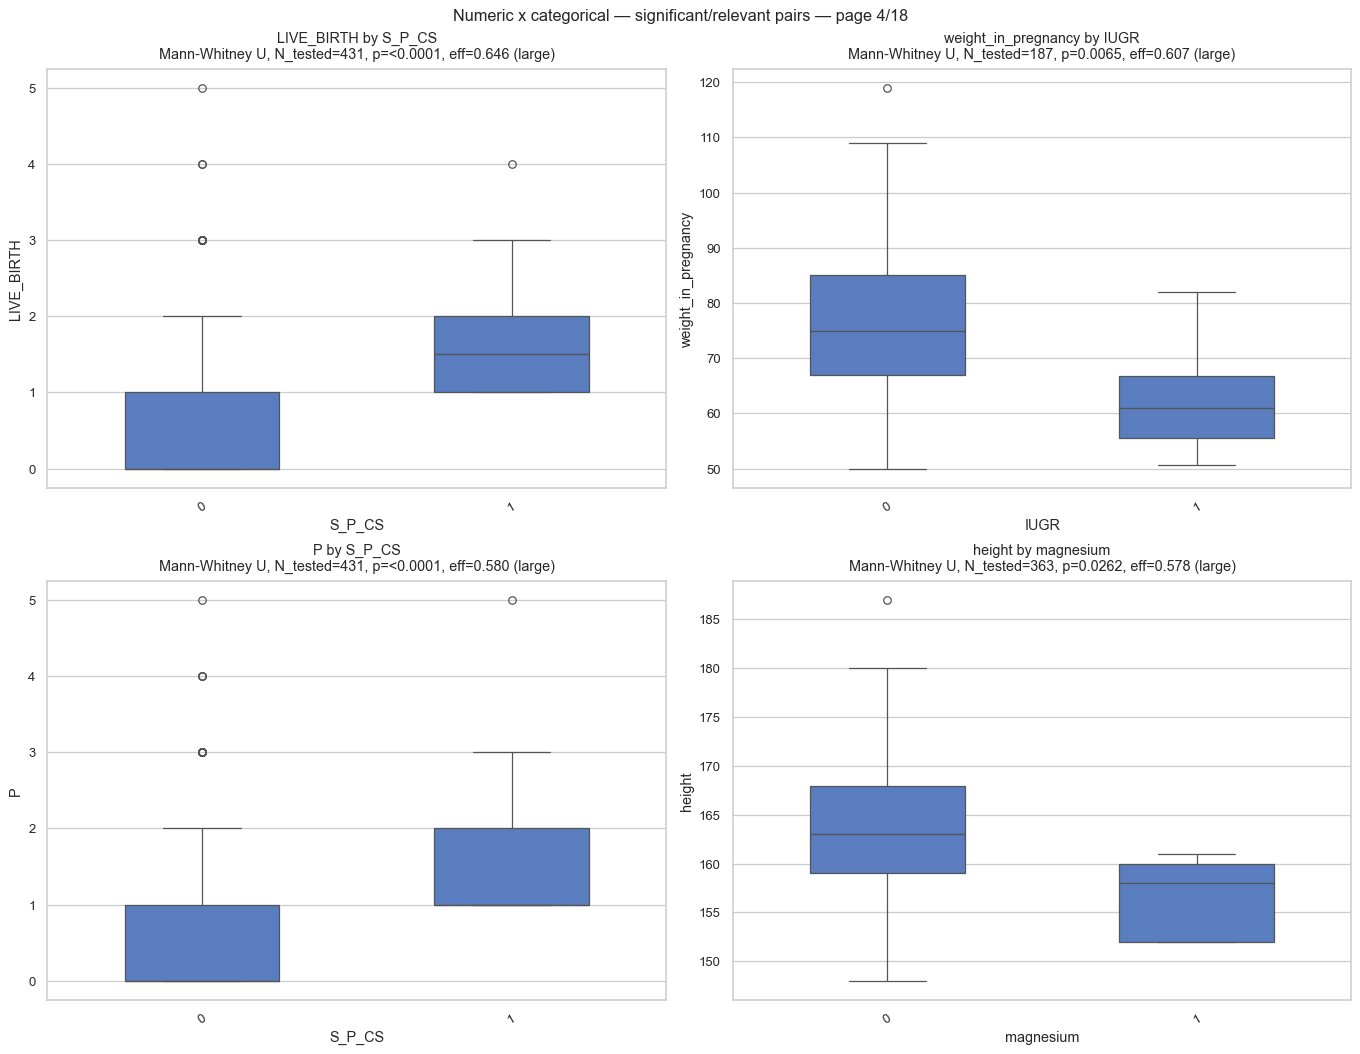

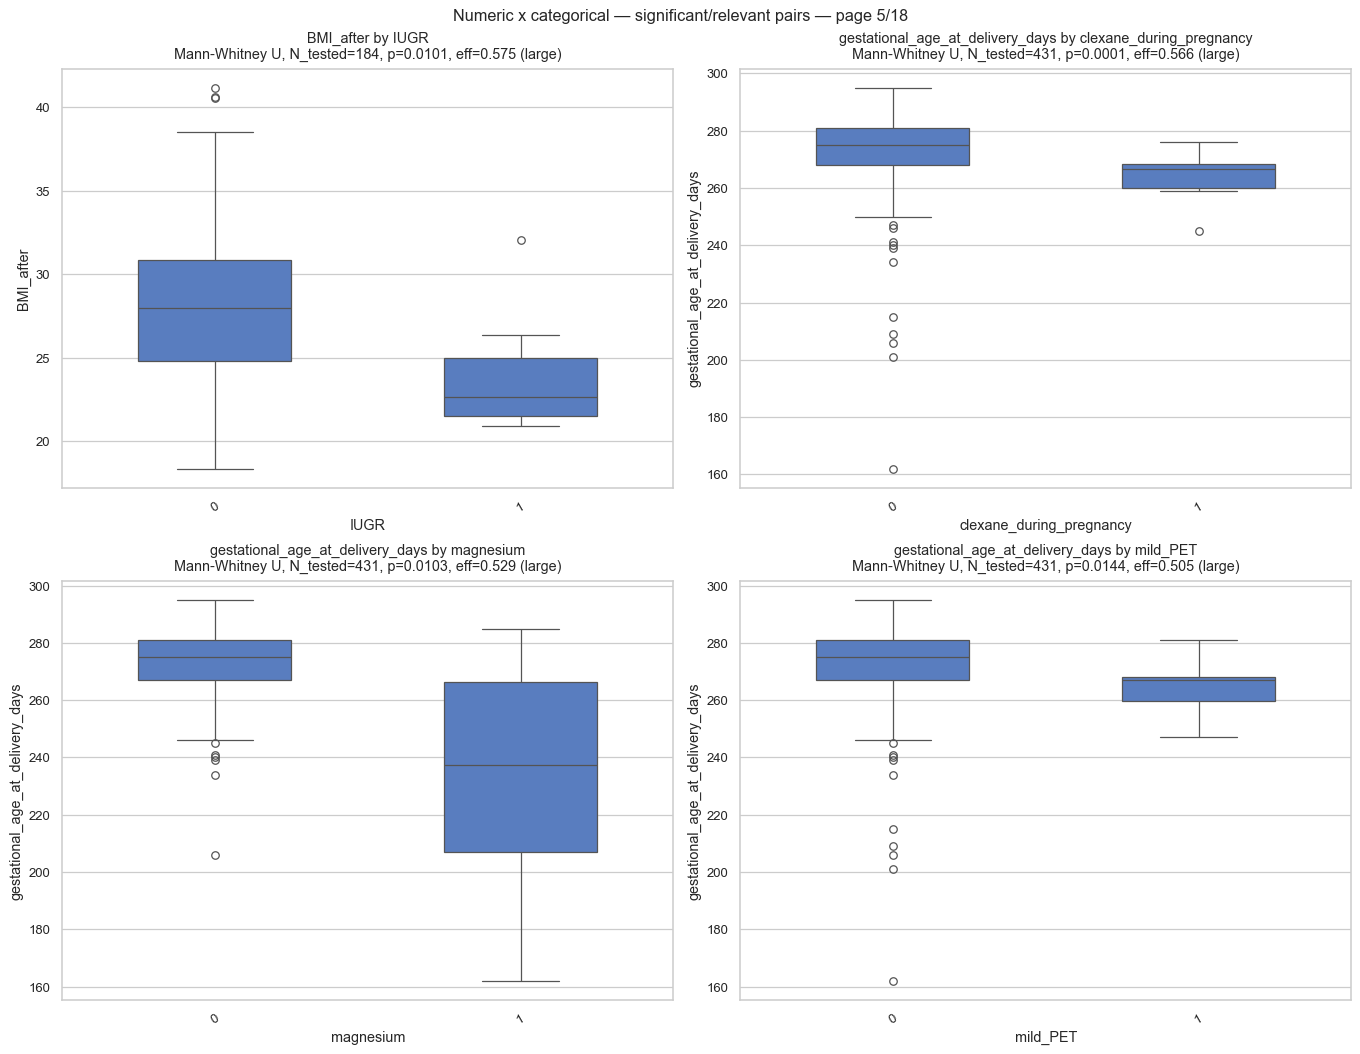

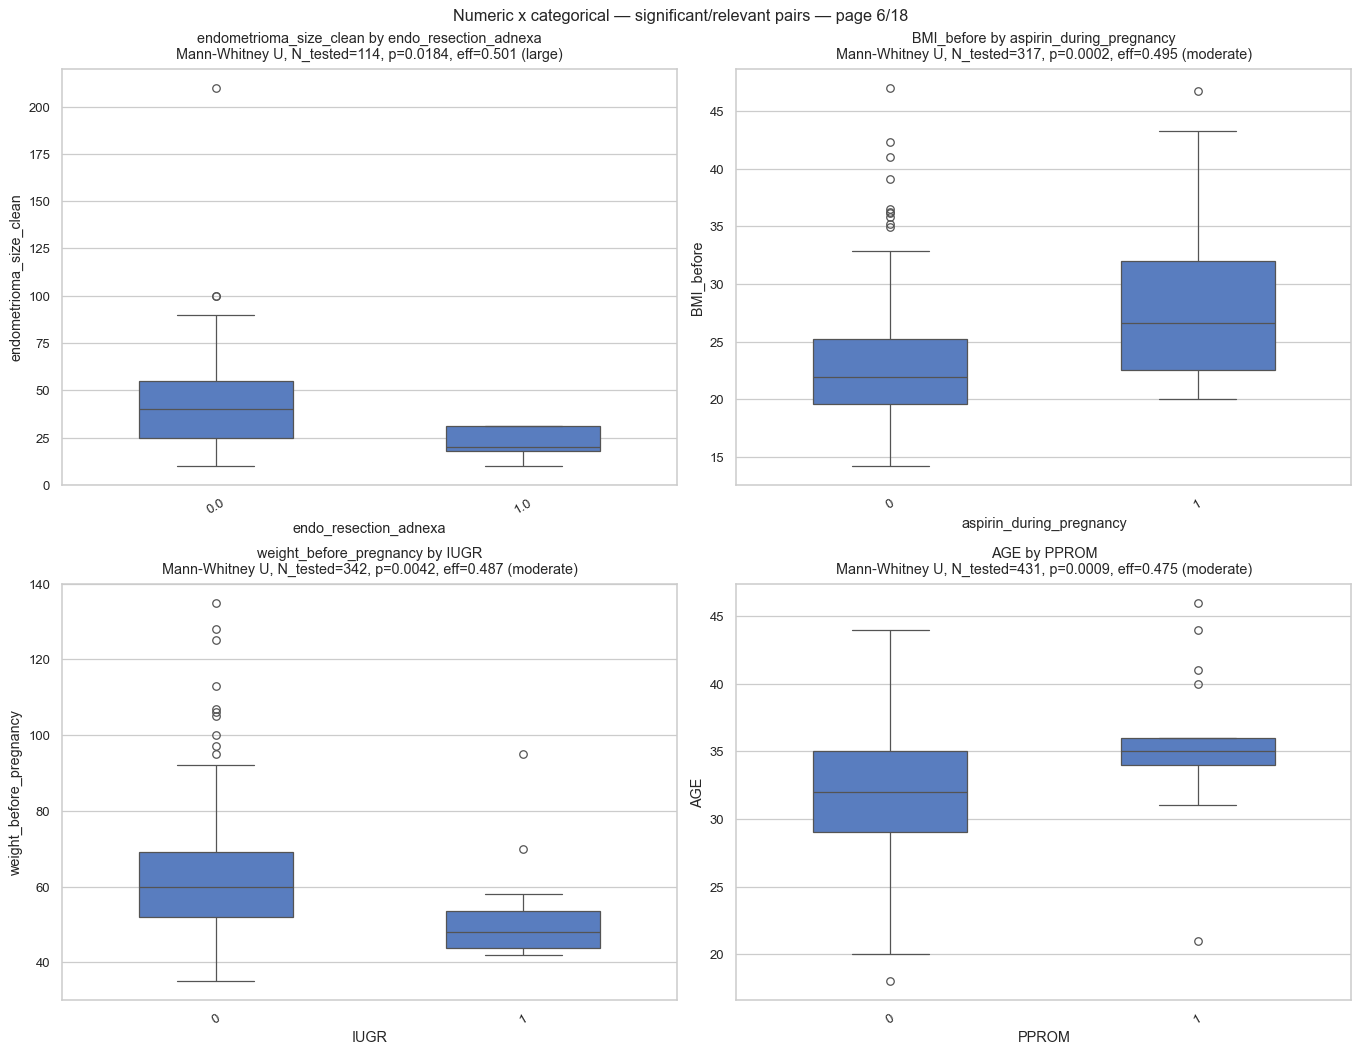

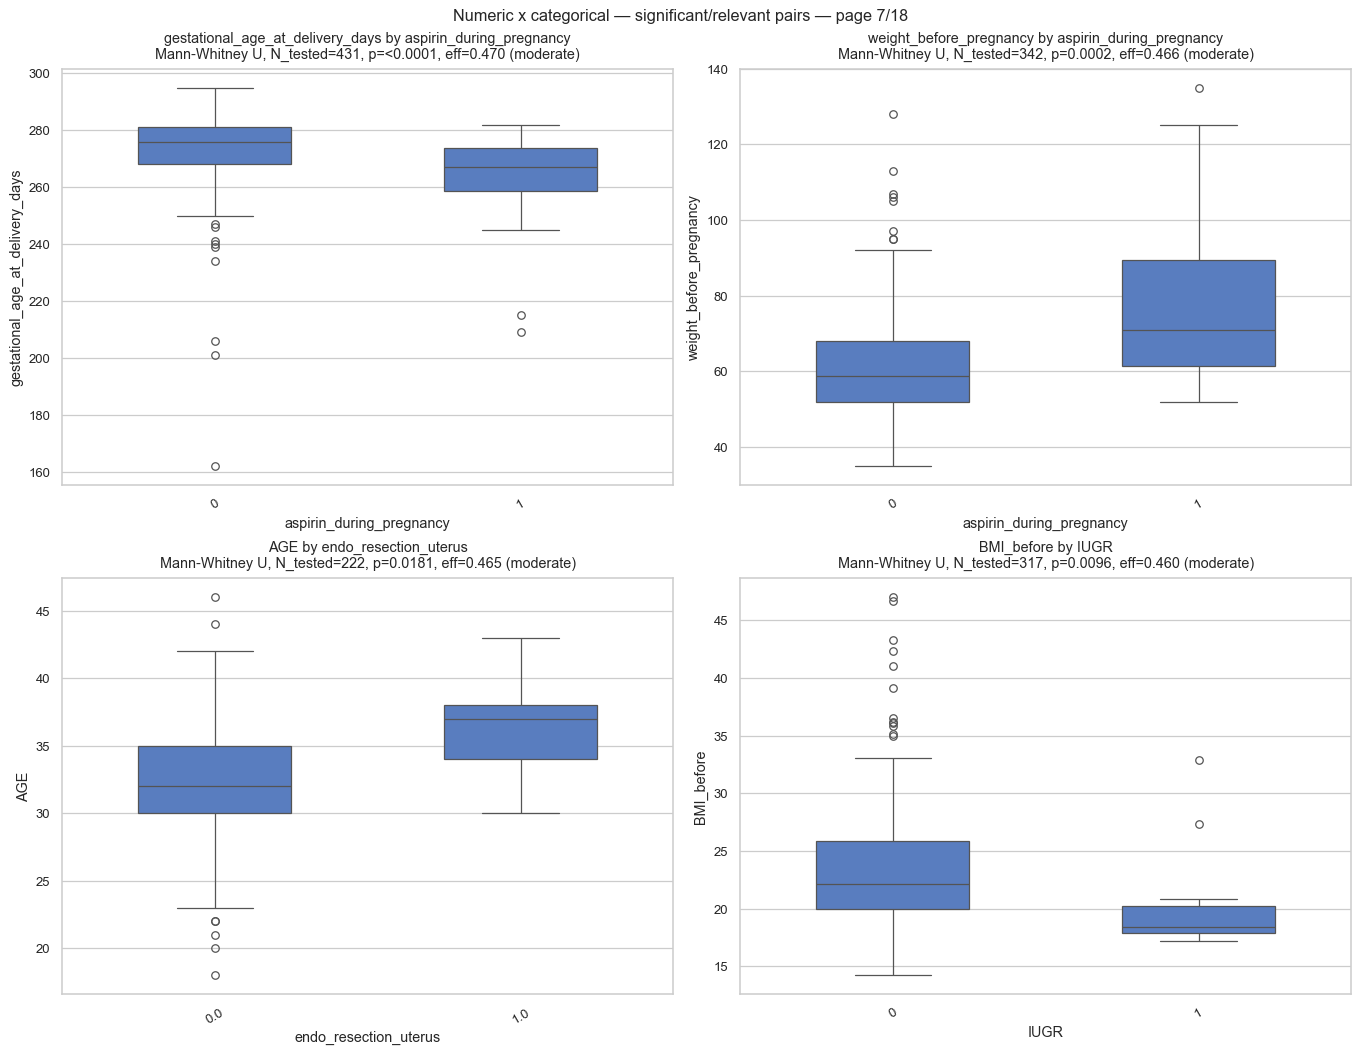

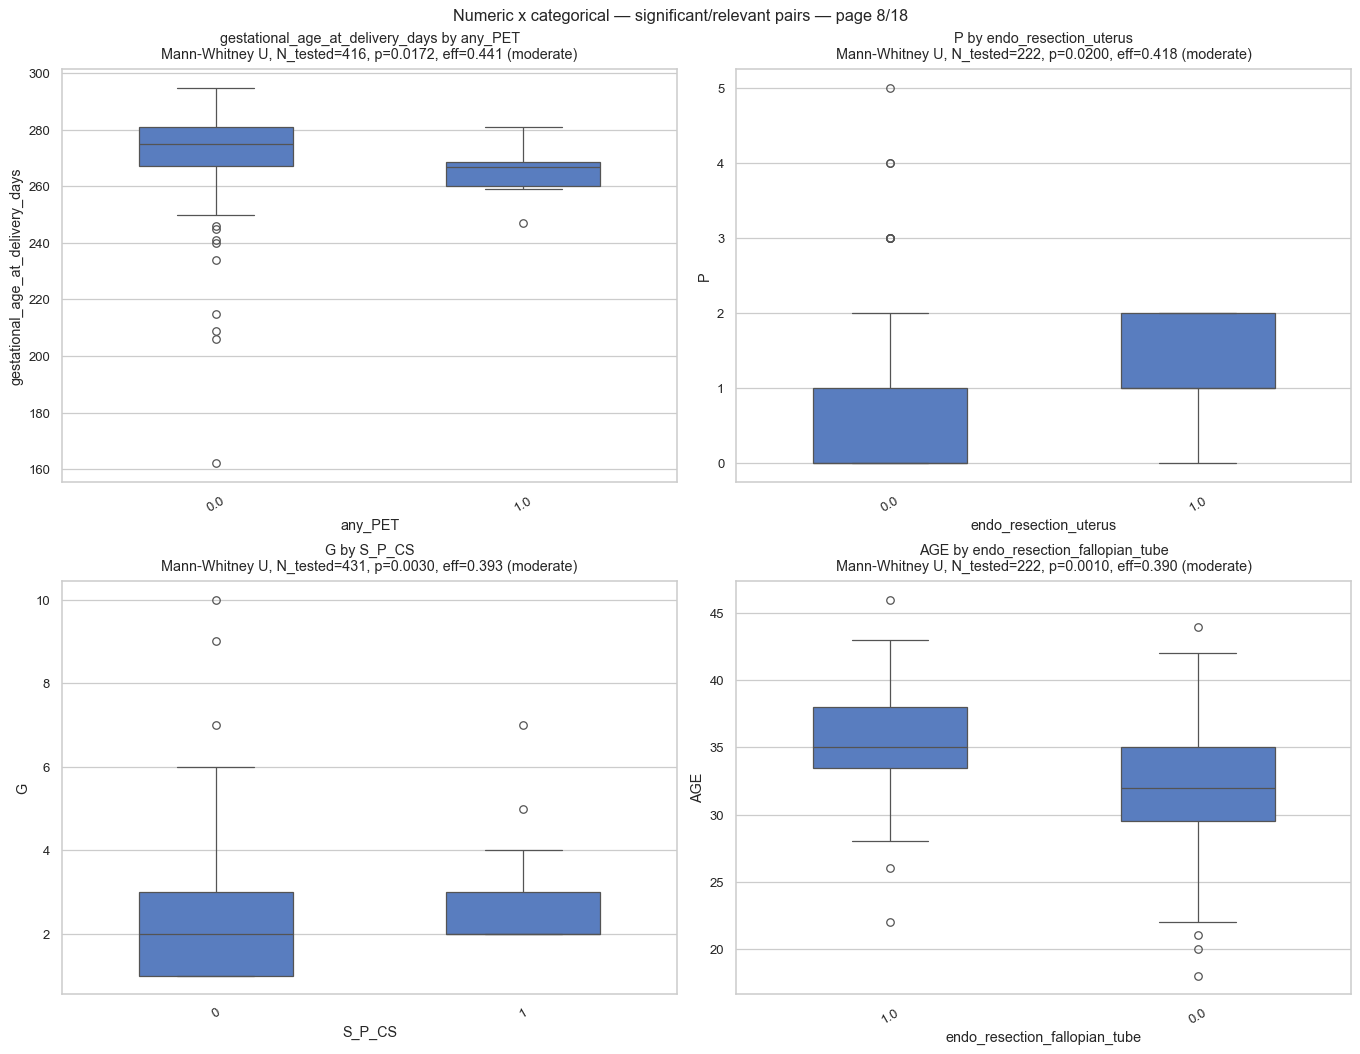

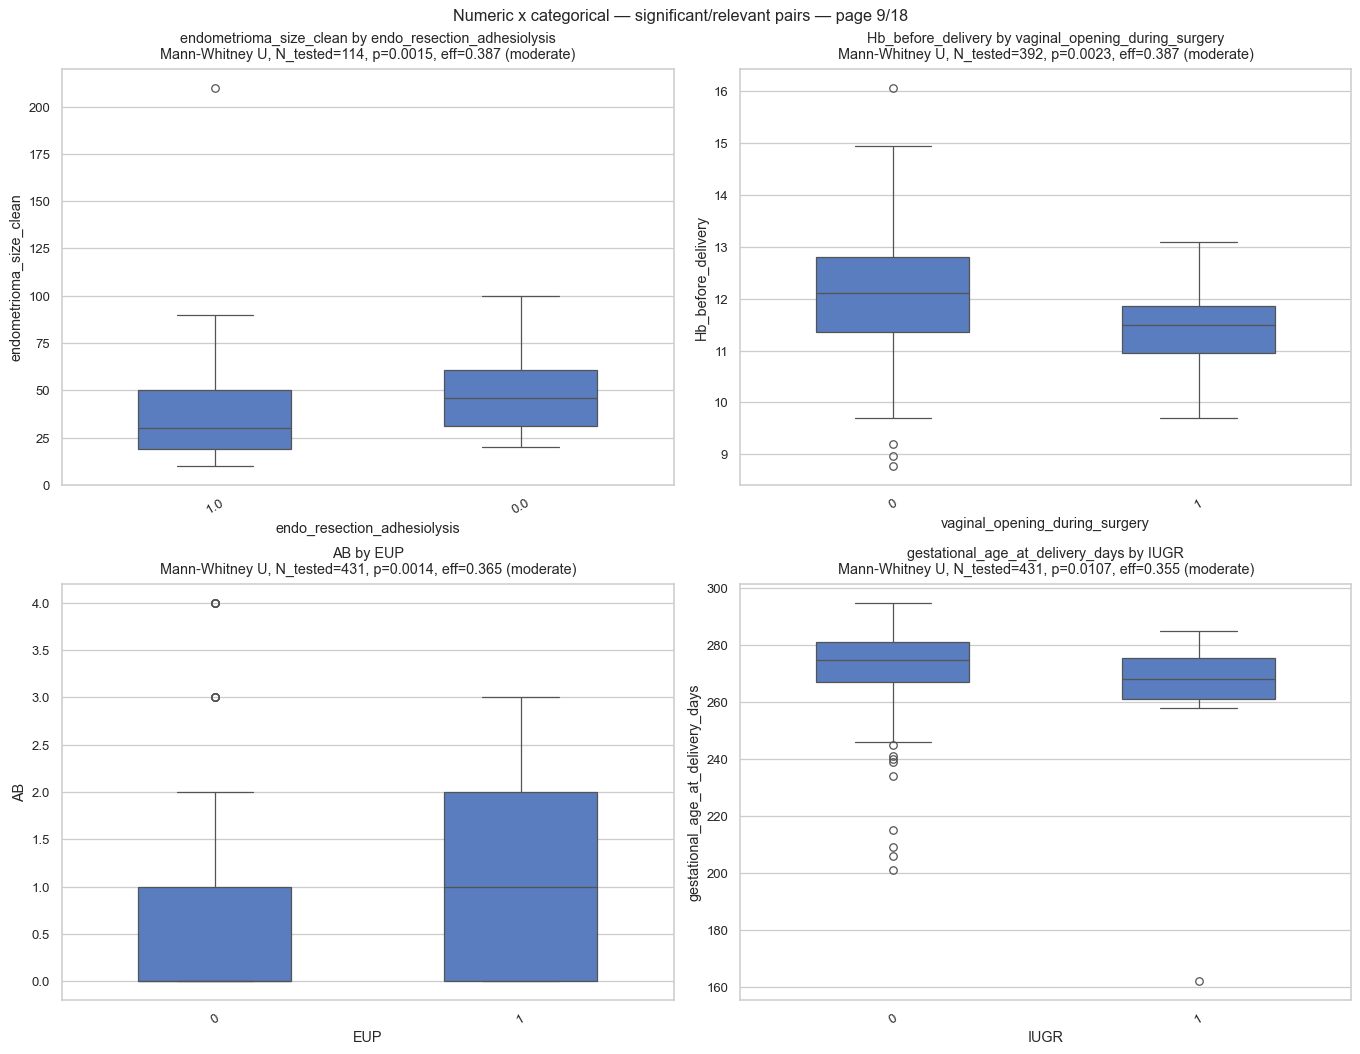

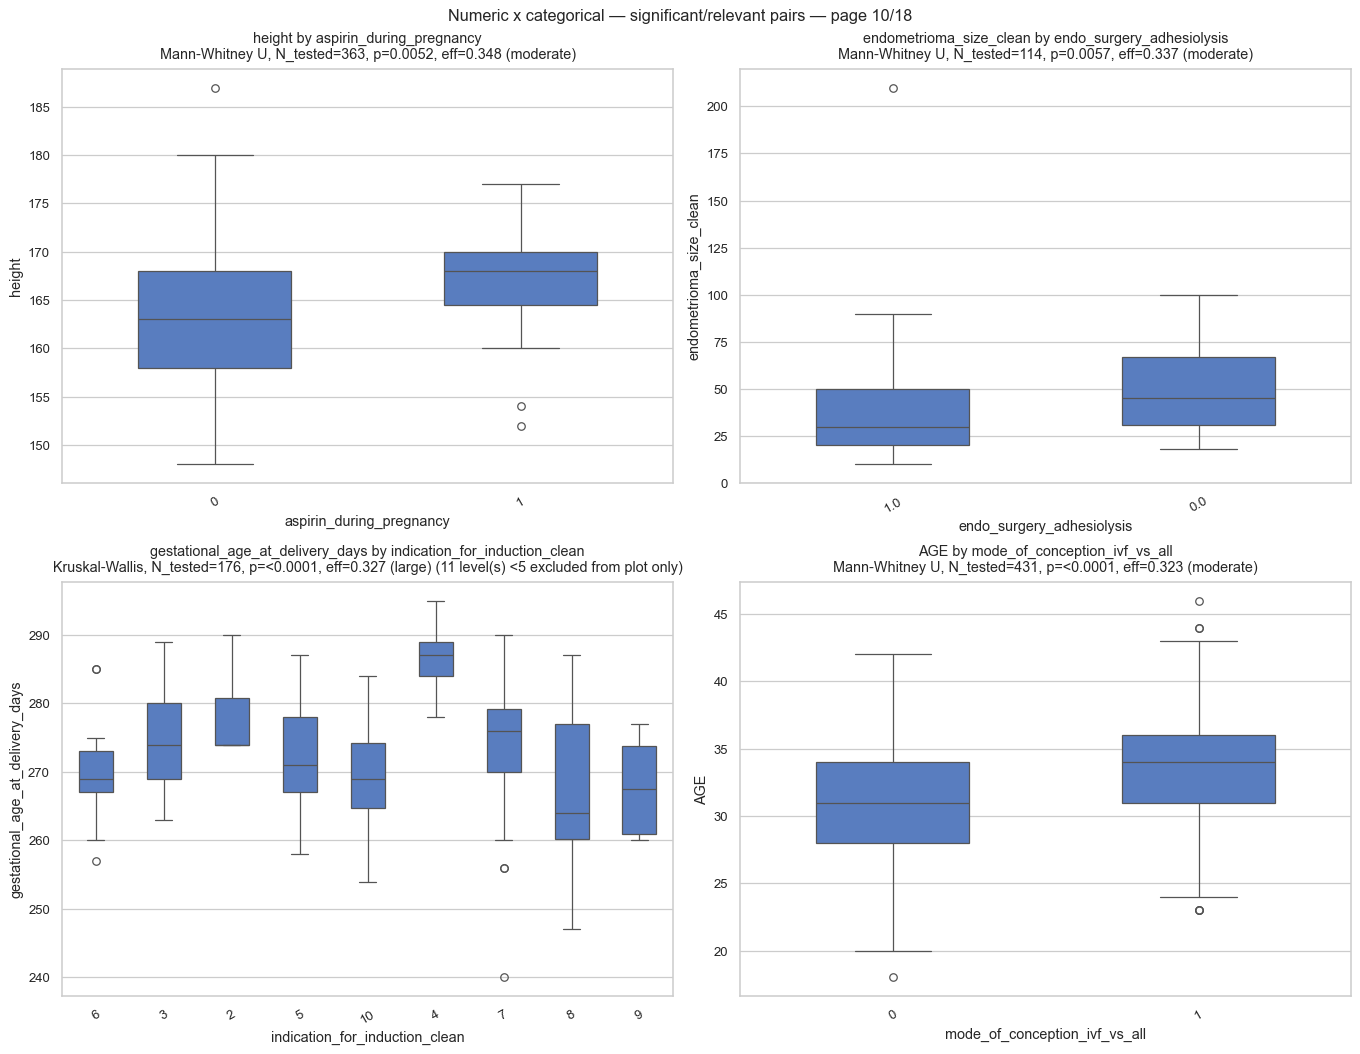

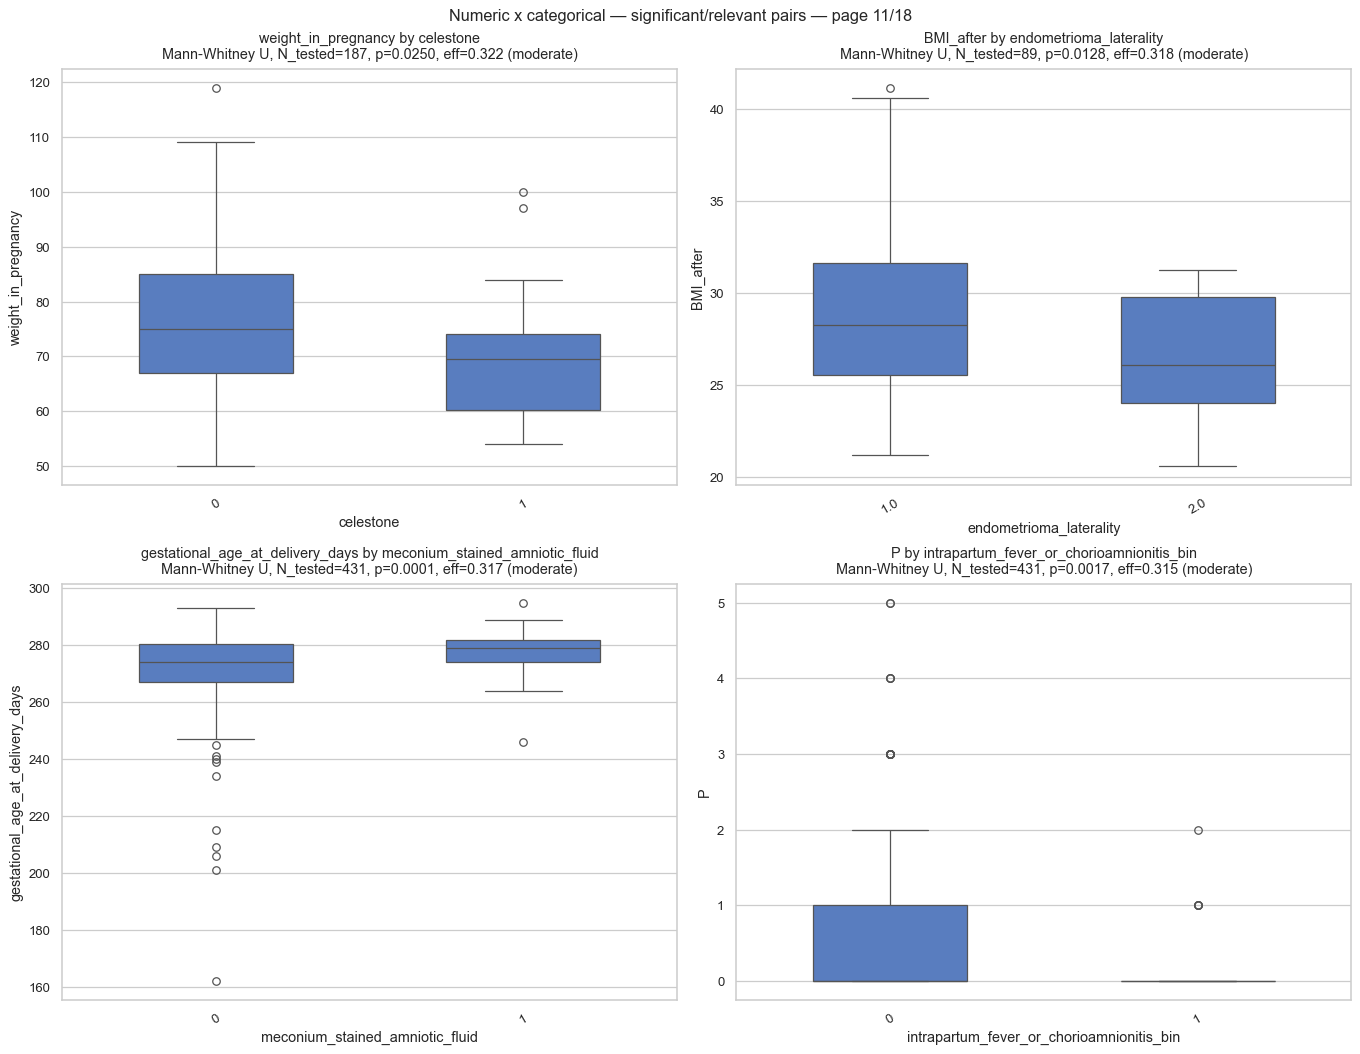

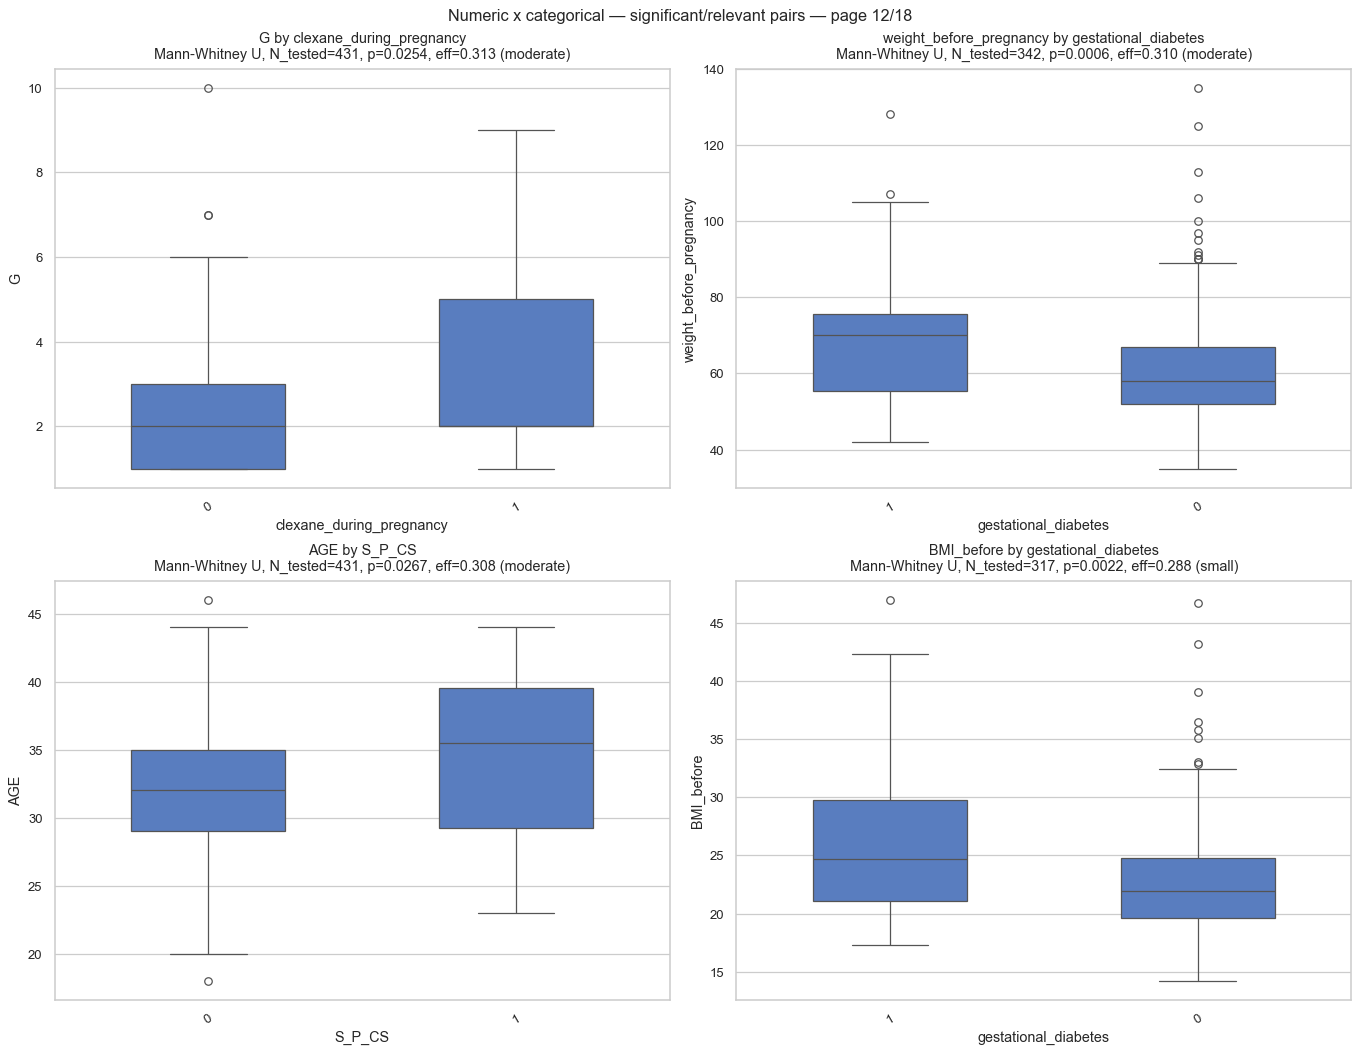

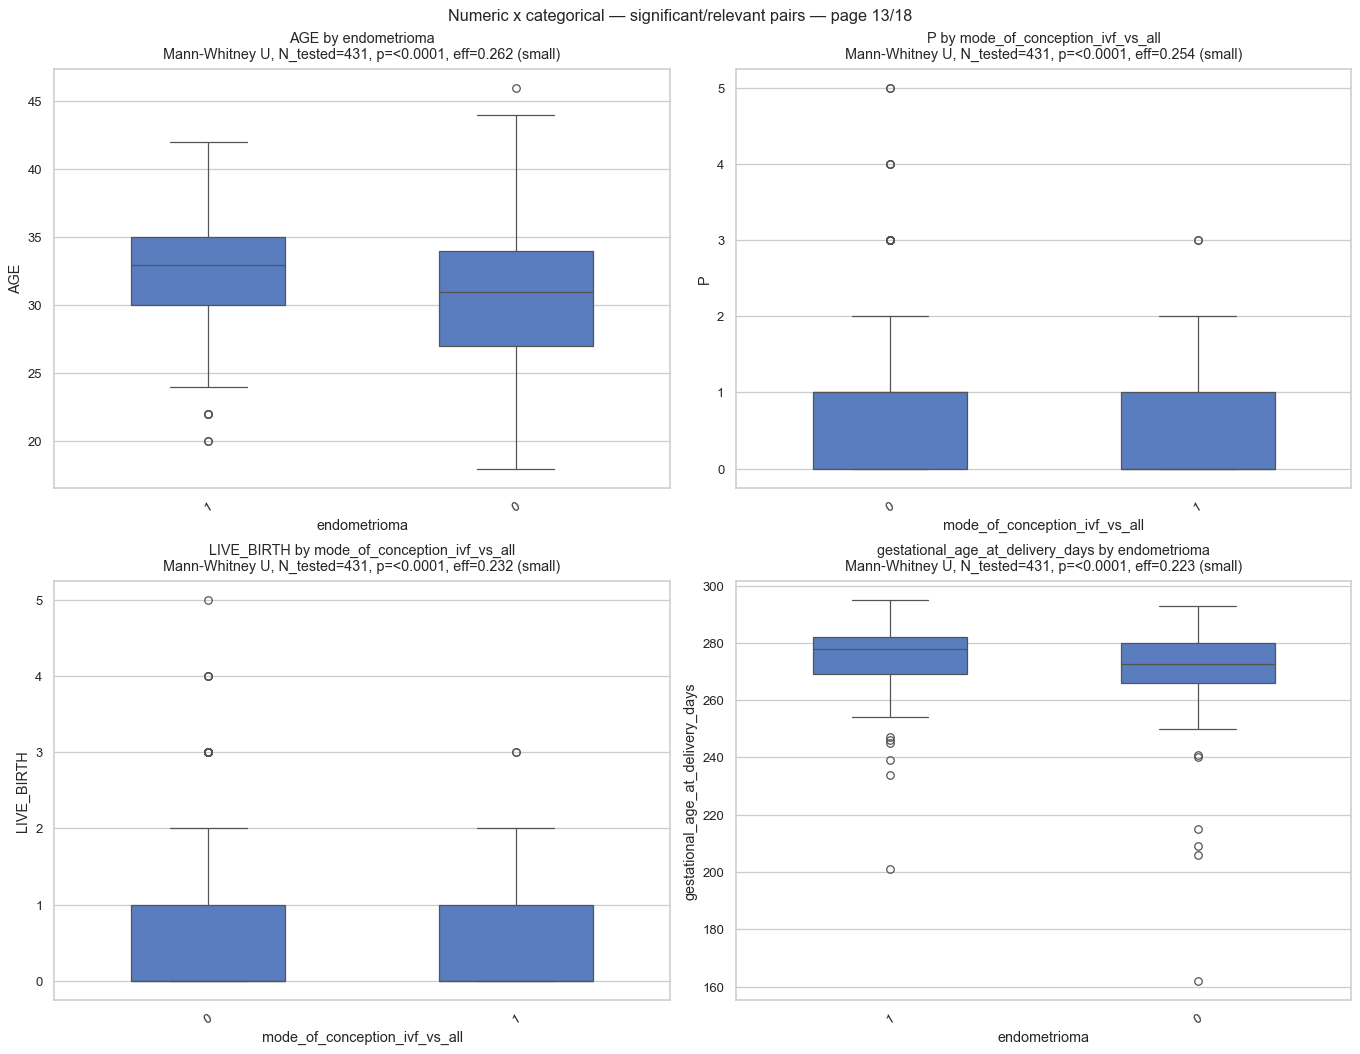

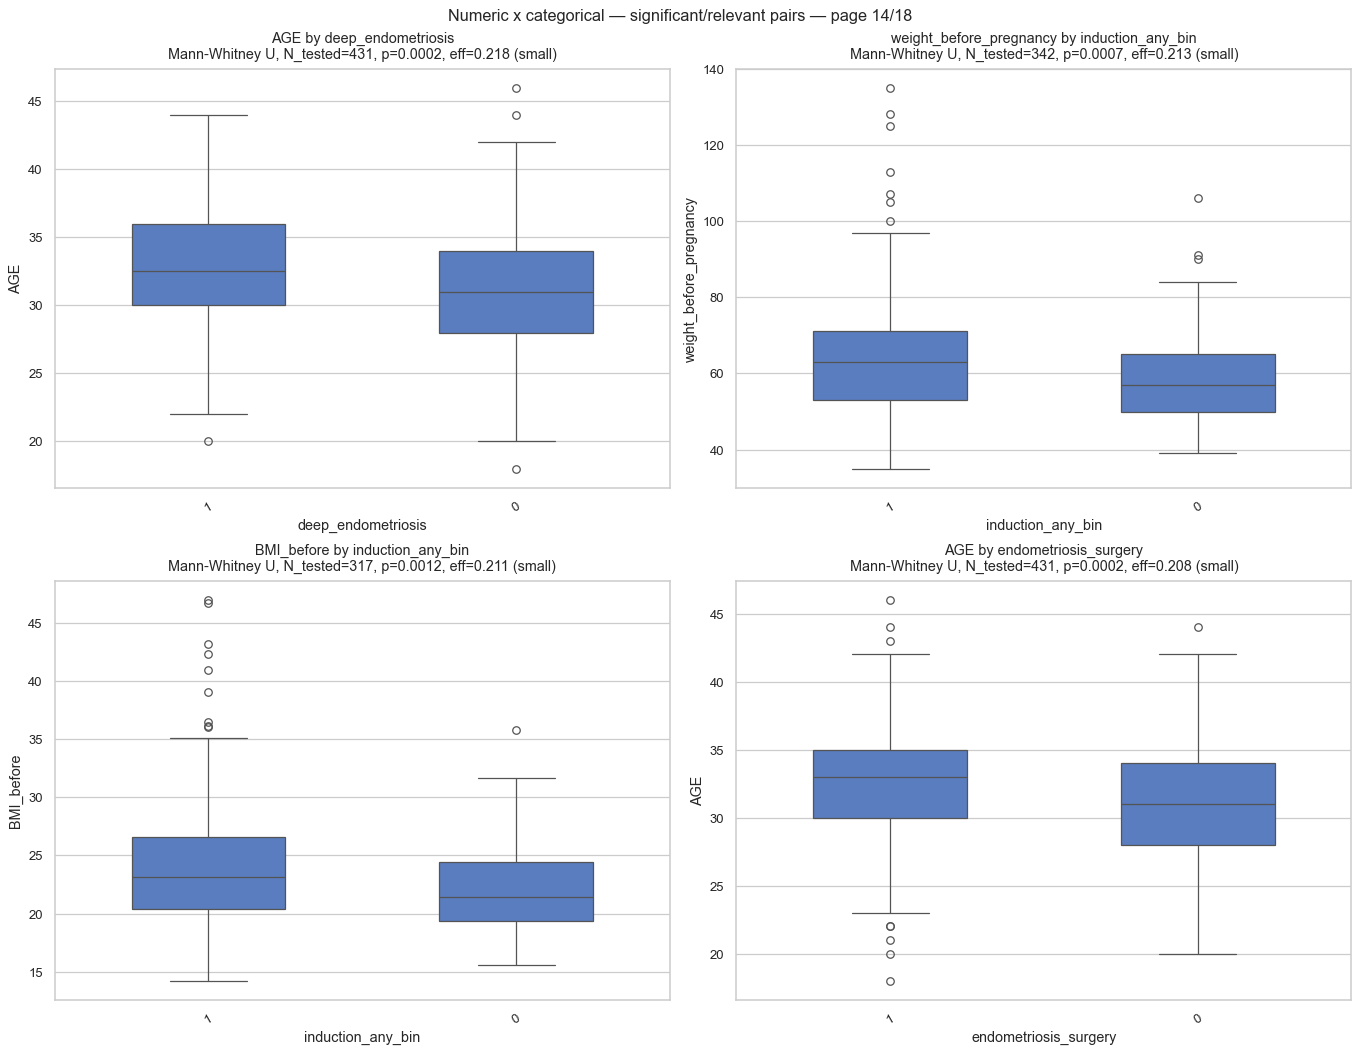

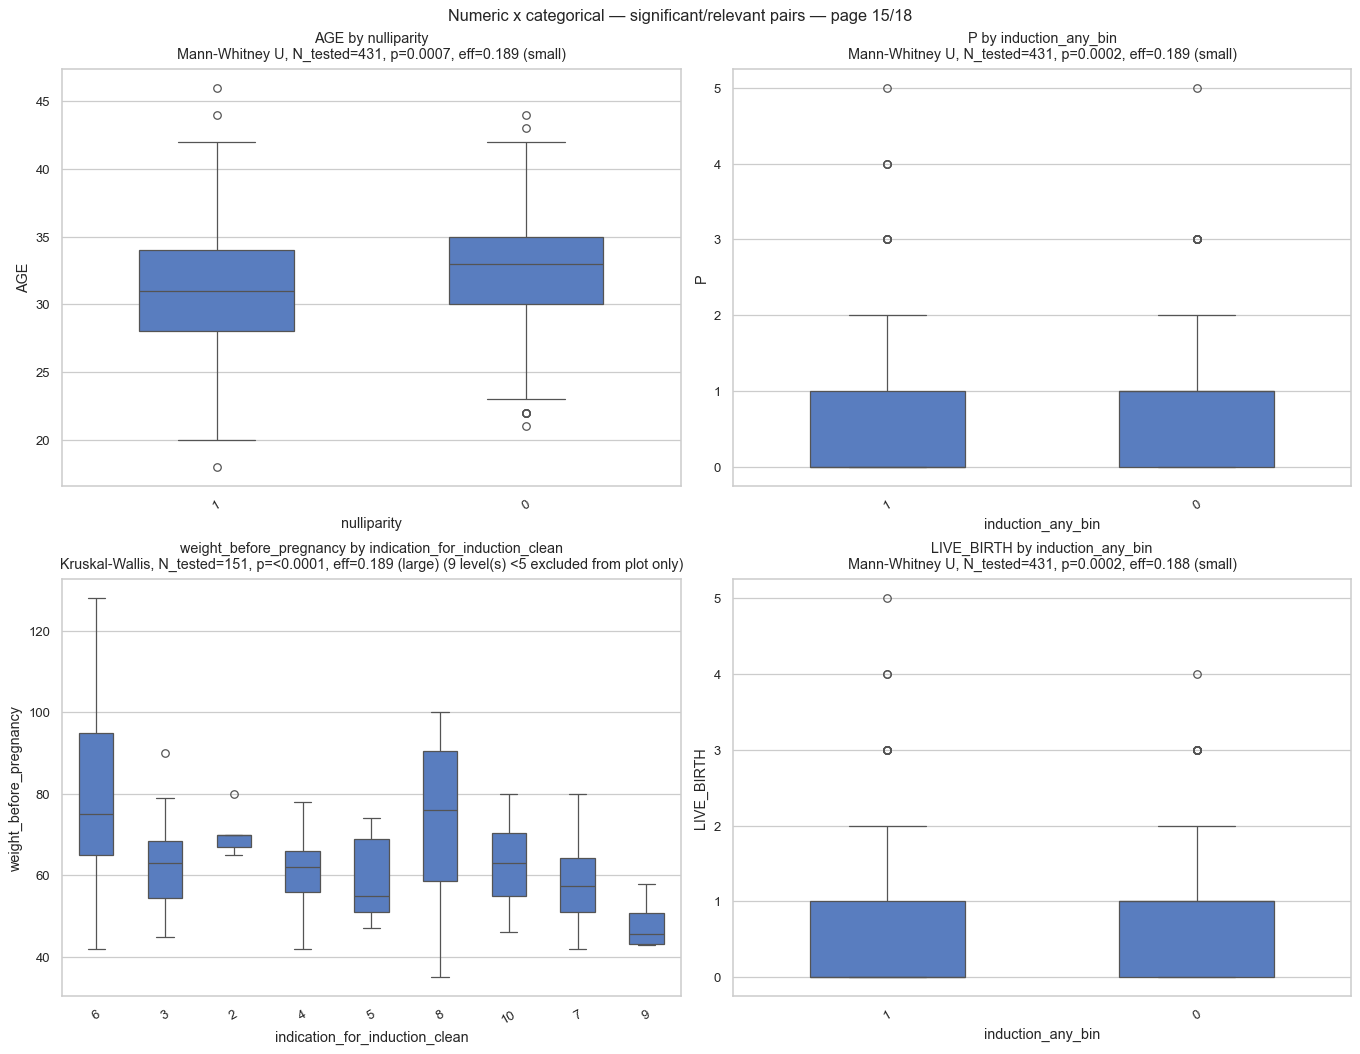

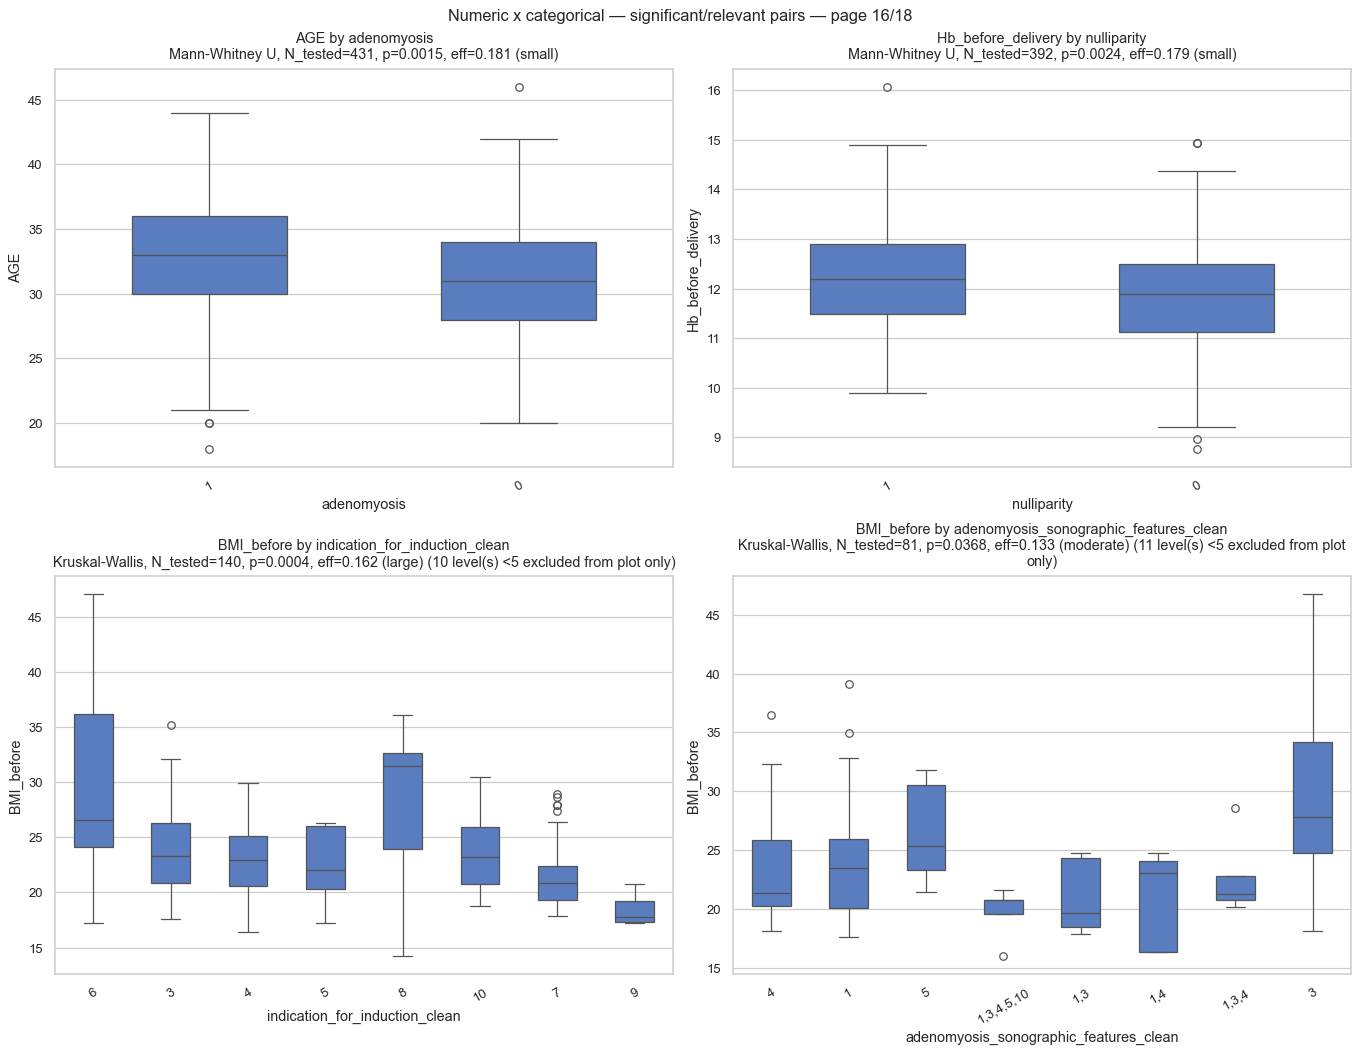

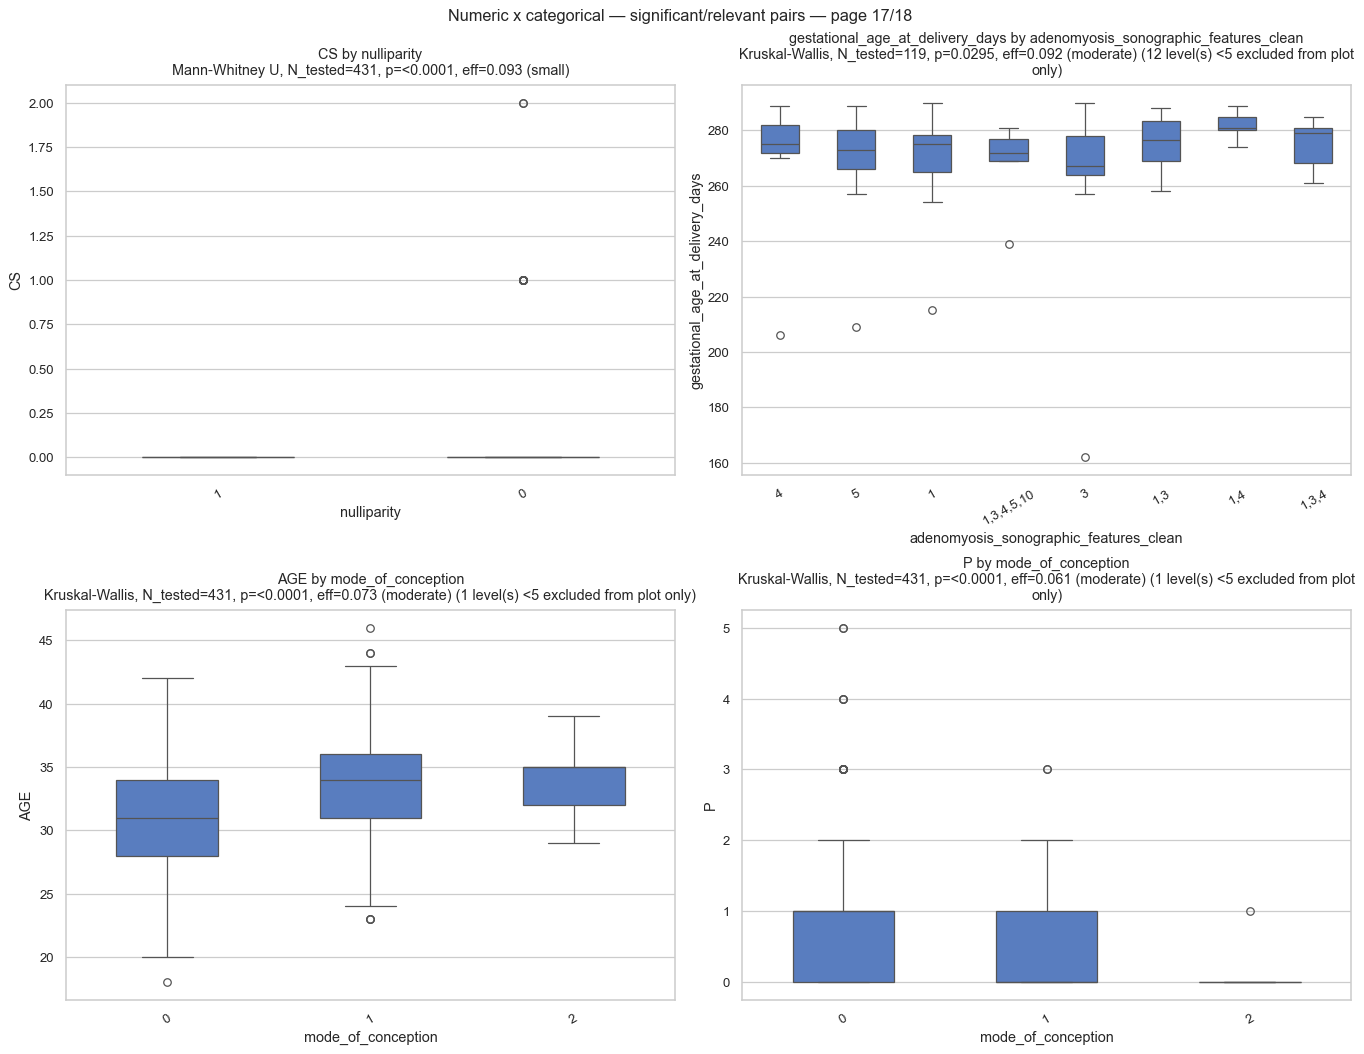

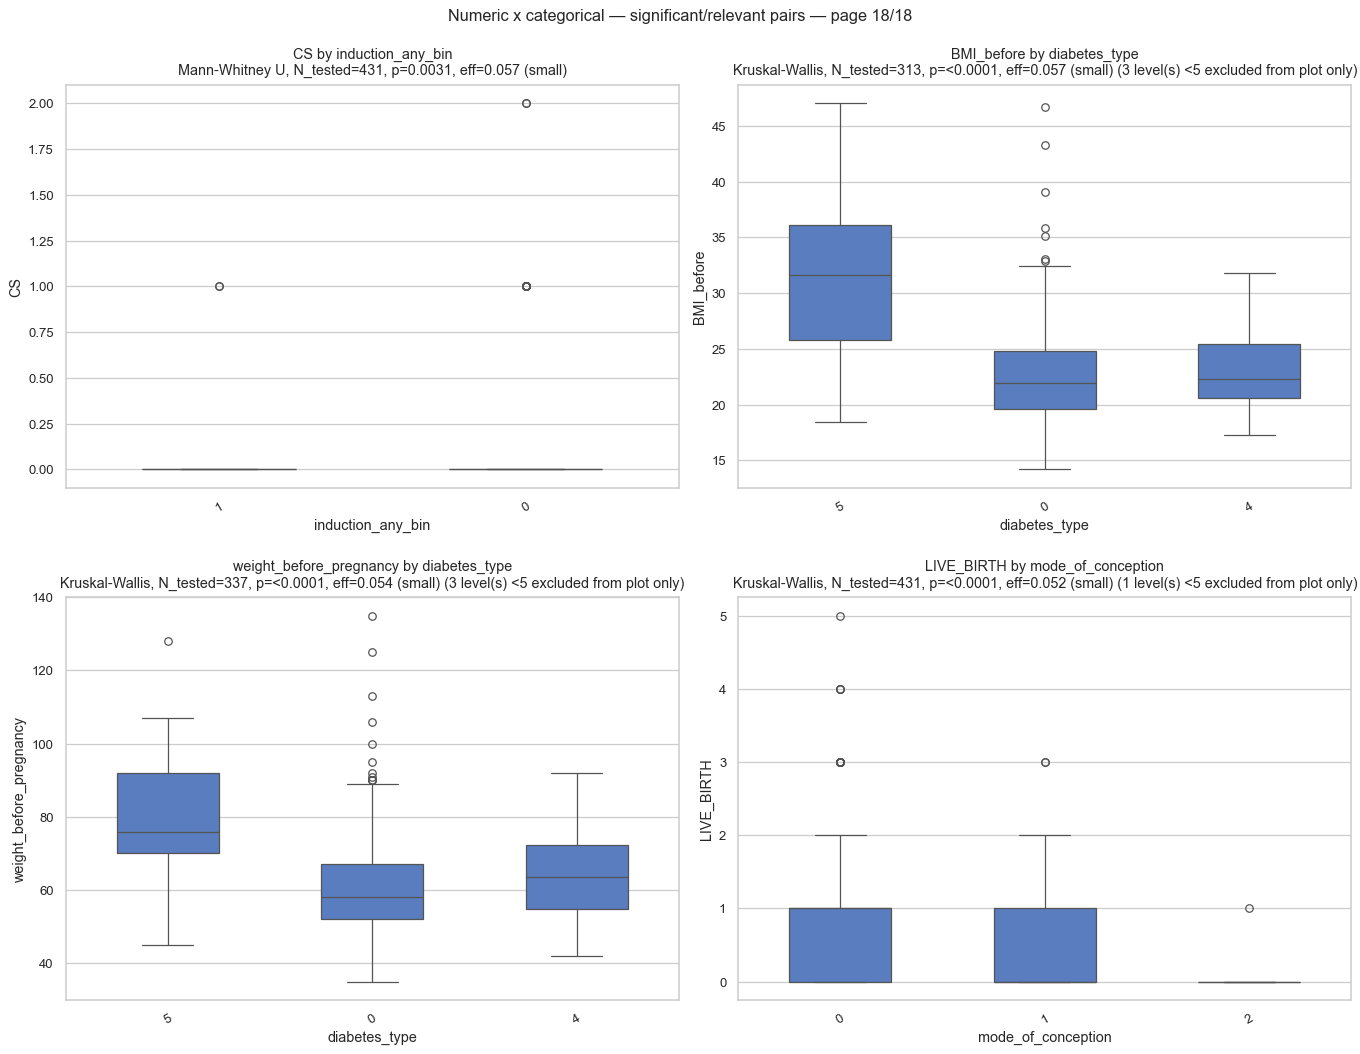

Plotted 72 of 678 screened pairs (full table: numcat_df). Title N_tested is the statistical test's own denominator (levels with >=3 obs); the boxplot itself additionally excludes any level with <5 obs for disclosure protection, so the number of points actually drawn can be smaller than N_tested -- see each title's excluded-level count.


In [33]:
if len(_numcat_sig) == 0:
    print("No numeric x categorical pairs met the plotting threshold — no plots generated.")
else:
    _nc_pairs = list(zip(_numcat_sig["numeric"], _numcat_sig["categorical"]))
    # 2x2 (4/page), not the prior 3x4/12-panel page: these titles carry
    # test name + N + p + effect (+ an excluded-level note), long enough that
    # a denser grid crowded them -- category tick labels need the room too.
    _NCOLS_NC, _PER_PAGE_NC = 2, 4
    _n_nc = len(_nc_pairs)
    _n_pages_nc = int(np.ceil(_n_nc / _PER_PAGE_NC))
    print(f"Boxplots for {_n_nc} significant/relevant pair(s) (of {len(numcat_df)} "
          f"screened), {_n_pages_nc} page(s):")
    for _page in range(_n_pages_nc):
        _page_pairs = _nc_pairs[_page * _PER_PAGE_NC:(_page + 1) * _PER_PAGE_NC]
        _nrows_nc = int(np.ceil(len(_page_pairs) / _NCOLS_NC))
        fig, axes = plt.subplots(_nrows_nc, _NCOLS_NC, figsize=(7.5 * _NCOLS_NC, 5.8 * _nrows_nc),
                                  layout="constrained")
        axes = np.array(axes).reshape(-1)
        for i, (num, cat) in enumerate(_page_pairs):
            ax = axes[i]
            _row = numcat_df[(numcat_df["numeric"] == num) & (numcat_df["categorical"] == cat)].iloc[0]
            _sub = df_primary[[num, cat]].dropna()
            _sub_p = _sub.copy()
            _sub_p[cat] = _sub_p[cat].astype(str)
            # a boxplot of a rare category level (n<5)
            # is a more severe disclosure than a suppressed bar chart -- with
            # only 1-4 points, the box/whiskers reveal near-exact individual
            # values, not just a count. Levels with
            # fewer than 5 observations are excluded from this plot (the
            # underlying numcat_df table is unaffected -- full data remains
            # there for computation).
            _level_counts = _sub_p[cat].value_counts()
            _plot_levels = _level_counts[_level_counts >= 5].index.tolist()
            _n_excluded_levels = _level_counts[_level_counts < 5].shape[0]
            _sub_p = _sub_p[_sub_p[cat].isin(_plot_levels)]
            # hue=cat (redundant with x=cat) + a single flat color= triggers
            # seaborn's "gradient palette from color=" FutureWarning in
            # current seaborn -- x=cat alone with a single color already
            # produces one undodged box per category level in that color, so
            # hue/legend are unnecessary here.
            sns.boxplot(data=_sub_p, x=cat, y=num, ax=ax, color=C0,
                        width=0.5, linewidth=1.0)
            # Two DIFFERENT thresholds are in play and must not be conflated:
            # the statistical test (numcat_df/_row) used every level with
            # >=3 complete-case observations; this plot additionally excludes
            # any level with <5 observations for disclosure protection (a
            # boxplot of 1-4 points reveals near-exact individual values).
            # The title therefore reports the TEST's own denominator
            # (N_tested, labeled explicitly as such) rather than an unlabeled
            # "N", and never prints an exact plotted-N -- doing so could
            # let a reader back out a suppressed 3-4-person level's exact
            # size from N_tested by subtraction. The excluded-level count
            # (never its exact size) is the only plot-specific disclosure.
            _excl_note = (f" ({_n_excluded_levels} level(s) <5 excluded from plot only)"
                          if _n_excluded_levels else "")
            # Display-formatted values (fmt_pval()/fmt_effect(), already
            # computed in numcat_df above) -- not the raw full-precision
            # floats, which can render as very long strings and visually
            # overflow into the neighboring subplot's title area. Formatting
            # only; the underlying numcat_df/statistics are unchanged.
            ax.set_title(f"{num} by {cat}\n{_row['test']}, N_tested={_row['N_tested']}, "
                         f"p={_row['p_value_display']}, eff={_row['effect_size_display']} "
                         f"({_row['effect_magnitude']}){_excl_note}", fontsize=11.5, wrap=True, pad=10)
            ax.set_xlabel(cat, fontsize=11.5)
            ax.set_ylabel(num, fontsize=11.5)
            ax.tick_params(axis="x", labelsize=10.5, rotation=30)
            ax.tick_params(axis="y", labelsize=10.5)
        for j in range(len(_page_pairs), len(axes)):
            axes[j].set_visible(False)
        fig.suptitle(f"Numeric x categorical — significant/relevant pairs — "
                     f"page {_page + 1}/{_n_pages_nc}", fontsize=13)
        plt.show()
    print(f"Plotted {_n_nc} of {len(numcat_df)} screened pairs (full table: numcat_df). "
          f"Title N_tested is the statistical test's own denominator (levels with >=3 "
          f"obs); the boxplot itself additionally excludes any level with <5 obs for "
          f"disclosure protection, so the number of points actually drawn can be smaller "
          f"than N_tested -- see each title's excluded-level count.")

**Key observations — numeric x categorical relationships:**

In [34]:
print(f"- {len(numcat_df)} of {len(_num_cols) * len(_catlike_cols)} eligible "
      f"numeric x categorical pairs were testable; {len(_numcat_skipped)} were skipped "
      f"for having fewer than 2 usable groups (typically a rare category with <3 "
      f"complete-case observations).")
print(f"- {len(_numcat_sig)} pair(s) are significant/relevant by the stated threshold "
      f"(BH-FDR q<0.05, or raw p<0.05 with a moderate-or-larger effect); these are the "
      f"ones plotted above.")
if len(_numcat_sig):
    # .iloc[0] after a descending sort is only "the top row" -- if the maximum
    # effect_size is shared by more than one pair (ties are common at the 1.0
    # ceiling for near-deterministic binary relationships), silently reporting
    # a single row as uniquely "strongest" is a sort-order artifact, not a
    # substantive finding. Report every tied pair instead, and note explicitly
    # that an equal effect-size estimate does NOT imply equal evidentiary
    # strength when pairwise N differs (a small-N pair reaching the same
    # nominal effect as a full-cohort pair is far weaker/less generalizable).
    _ko_nc_max_eff = _numcat_sig["effect_size"].max()
    _ko_nc_tied = _numcat_sig[_numcat_sig["effect_size"] == _ko_nc_max_eff]
    if len(_ko_nc_tied) > 1:
        _ko_nc_tied_desc = []
        for _, _r in _ko_nc_tied.iterrows():
            _desc = (f"{_r['numeric']} by {_r['categorical']} ({_r['test']}, "
                      f"N_tested={_r['N_tested']}, p={_r['p_value_display']})")
            if _r["N_tested"] < 30:
                _desc += " [LOW N -- interpret with caution]"
            _ko_nc_tied_desc.append(_desc)
        print(f"- Largest observed effect-size estimate (tied across {len(_ko_nc_tied)} "
              f"pairs, effect={fmt_effect(_ko_nc_max_eff)}): {_ko_nc_tied_desc}. Equal "
              f"effect-size estimates do NOT imply equal evidentiary strength -- these "
              f"pairs differ substantially in pairwise N and p-value; requires "
              f"consideration during Feature Selection if any tied pair's variables are "
              f"candidates for the same model.")
    else:
        _ko_nc_top = _numcat_sig.iloc[0]
        print(f"- Largest observed effect-size estimate: {_ko_nc_top['numeric']} by "
              f"{_ko_nc_top['categorical']} ({_ko_nc_top['test']}, "
              f"effect={_ko_nc_top['effect_size_display']}, {_ko_nc_top['effect_magnitude']}) -- "
              f"requires consideration during Feature Selection if both variables are "
              f"candidates for the same model.")
print("- This screening does not by itself imply redundancy (a numeric-categorical "
      "association is expected for many clinically related pairs); flag pairs with "
      "large effect sizes for a closer look, but no variable is excluded here.")

- 678 of 780 eligible numeric x categorical pairs were testable; 102 were skipped for having fewer than 2 usable groups (typically a rare category with <3 complete-case observations).
- 72 pair(s) are significant/relevant by the stated threshold (BH-FDR q<0.05, or raw p<0.05 with a moderate-or-larger effect); these are the ones plotted above.
- Largest observed effect-size estimate (tied across 3 pairs, effect=1.000): ['CS by S_P_CS (Mann-Whitney U, N_tested=431, p=<0.0001)', 'gestational_age_at_PPROM_days by magnesium (Mann-Whitney U, N_tested=16, p=0.0101) [LOW N -- interpret with caution]', 'P by nulliparity (Mann-Whitney U, N_tested=431, p=<0.0001)']. Equal effect-size estimates do NOT imply equal evidentiary strength -- these pairs differ substantially in pairwise N and p-value; requires consideration during Feature Selection if any tied pair's variables are candidates for the same model.
- This screening does not by itself imply redundancy (a numeric-categorical association is ex

### A2.10c — Categorical × Categorical Predictor Relationships

**Purpose:** Systematically screen all eligible categorical/binary predictor pairs for
association strength (Cramér's V), completing predictor-predictor relationship coverage
alongside A2.10a (numeric × numeric) and A2.10b (numeric × categorical).

**What this checks:**
- Chi-square when expected-cell assumptions are satisfied; when they are not
  (Cochran's rule of thumb: any expected cell < 5 for 2x2, or >20% of expected
  cells < 5 for r x c) -- classical Fisher exact for sparse 2x2 tables, or the
  Fisher-Freeman-Halton exact-test framework for sparse r x c tables (valid for
  r x c, not only 2x2), computed via a deterministic fixed-seed Monte Carlo
  p-value (100,000 resamples in the current helper) rather than full
  enumeration -- see each pair's own `test` column for the exact seed/resample
  count used, for every eligible pair (N≥10, both dimensions ≥2 levels)
- Cramér's V (V ≥ 0.5 flagged as potential redundancy)
- BH-FDR-adjusted p-value (computed from full-precision raw p-values) across the
  full pairwise table
- Minimum expected cell count and sparse-cell fraction reported per pair

**What this does NOT do:**
- A high Cramér's V does not by itself establish redundancy — see the caution note
  below on sparse/high-cardinality tables
- Final redundancy decisions require clinical review (A2.10d)

**Output:** Cramér's V heatmap (flagged-pair subset) + full pairwise table

In [35]:
# Uses the shared contingency_association_test() helper (Part 1) -- the same
# Chi-square/Fisher(-Freeman-Halton)/Monte-Carlo selection logic used for
# predictor-vs-target testing in A2.9, so r x c categorical/binary pairs get
# the identical statistically valid sparse-cell handling, rather than the
# asymptotic Chi-square p-value alone for sparse r x c tables.

_V_THRESH = 0.5
# _catlike_cols already built in A2.10b above (binary + categorical PRIMARY_COLS);
# reused here for the systematic categorical-categorical screening.

_catcat_rows = []
for _i in range(len(_catlike_cols)):
    for _j in range(_i + 1, len(_catlike_cols)):
        c1, c2 = _catlike_cols[_i], _catlike_cols[_j]
        sub = df_primary[[c1, c2]].dropna()
        n = len(sub)
        if n < 10:
            continue
        ct = pd.crosstab(sub[c1], sub[c2])
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            continue
        test, stat, pval, min_exp, sparse_frac, sparse_flag = contingency_association_test(ct)
        v = cramers_v(ct)
        _catcat_rows.append({
            "var1": c1, "var2": c2,
            "var1_earliest_entry_stage": PRIMARY_COLS_EARLIEST_STAGE.get(c1),
            "var2_earliest_entry_stage": PRIMARY_COLS_EARLIEST_STAGE.get(c2),
            "N": n, "table_shape": f"{ct.shape[0]}x{ct.shape[1]}",
            "test": test,
            # Full-precision computational values -- never rounded. Display
            # columns (*_display) are formatting only.
            "statistic": float(stat) if pd.notna(stat) else np.nan,
            "p_value": float(pval) if pd.notna(pval) else np.nan,
            "p_value_display": fmt_pval(pval),
            "min_expected_cell": min_exp,
            "sparse_cell_fraction": sparse_frac,
            "cramers_v": v,
            "cramers_v_display": fmt_effect(v),
            "sparse_cell_warning": sparse_flag,
            "high_v_flag": bool(pd.notna(v) and v >= _V_THRESH),
        })

catcat_df = pd.DataFrame(_catcat_rows)
# BH-FDR always receives the full-precision, unrounded p_value column.
catcat_df["q_value_bh"] = benjamini_hochberg(catcat_df["p_value"]).values
catcat_df["fdr_sig"] = catcat_df["q_value_bh"] < 0.05
catcat_df["q_value_bh_display"] = catcat_df["q_value_bh"].apply(fmt_pval)

_catcat_possible = len(_catlike_cols) * (len(_catlike_cols) - 1) // 2
print(f"Categorical/binary predictors screened: {len(_catlike_cols)}")
print(f"Eligible pairs (N>=10, both dimensions >=2 levels): {len(catcat_df)} of "
      f"{_catcat_possible} possible")
print(f"Raw p<0.05: {int((catcat_df['p_value'] < 0.05).sum())} | "
      f"BH-FDR q<0.05: {int(catcat_df['fdr_sig'].sum())} | "
      f"V>={_V_THRESH} (potential redundancy): {int(catcat_df['high_v_flag'].sum())} | "
      f"sparse-cell warning: {int(catcat_df['sparse_cell_warning'].sum())}")
print()

_catcat_flagged = catcat_df[
    catcat_df["fdr_sig"] | catcat_df["high_v_flag"]
].sort_values("cramers_v", ascending=False, na_position="last")
_show_cc = ["var1", "var1_earliest_entry_stage", "var2", "var2_earliest_entry_stage",
            "N", "table_shape", "test", "min_expected_cell",
            "p_value_display", "q_value_bh_display",
            "cramers_v_display", "high_v_flag", "sparse_cell_warning"]

_catcat_high_v = catcat_df[catcat_df["high_v_flag"]].sort_values("cramers_v", ascending=False)
print(f"High-Cramer's-V redundancy-review pairs (V>={_V_THRESH}): {len(_catcat_high_v)}")
if len(_catcat_high_v):
    print(_catcat_high_v[_show_cc].head(25).to_string(index=False))
    if len(_catcat_high_v) > 25:
        print(f"... ({len(_catcat_high_v) - 25} more rows; full result in catcat_df)")
else:
    print("None.")
print()

_catcat_sig_only = catcat_df[catcat_df["fdr_sig"] & ~catcat_df["high_v_flag"]].sort_values(
    "cramers_v", ascending=False, na_position="last"
)
print(f"Additional BH-FDR-significant pairs (q<0.05, below the V>={_V_THRESH} redundancy "
      f"threshold): {len(_catcat_sig_only)}")
if len(_catcat_sig_only):
    print(_catcat_sig_only[_show_cc].head(10).to_string(index=False))
    if len(_catcat_sig_only) > 10:
        print(f"... ({len(_catcat_sig_only) - 10} more rows; full result in catcat_df)")
else:
    print("None.")
_high_v_pairs = [
    {"var1": r["var1"], "var2": r["var2"], "cramers_v": r["cramers_v"]}
    for _, r in catcat_df[catcat_df["high_v_flag"]].sort_values("cramers_v", ascending=False).iterrows()
]
print()
print("NOTE: catcat_df holds the FULL systematic screening table for all eligible")
print("categorical/binary predictor pairs (chi-square/Fisher as appropriate, with a")
print("sparse-cell caution flag); only the flagged subset above and the heatmap below")
print("(restricted to variables in a flagged pair, for readability) are shown inline.")

Categorical/binary predictors screened: 52
Eligible pairs (N>=10, both dimensions >=2 levels): 1285 of 1326 possible
Raw p<0.05: 194 | BH-FDR q<0.05: 88 | V>=0.5 (potential redundancy): 38 | sparse-cell warning: 1000

High-Cramer's-V redundancy-review pairs (V>=0.5): 38
                                   var1  var1_earliest_entry_stage                                           var2  var2_earliest_entry_stage   N table_shape                                                                 test  min_expected_cell p_value_display q_value_bh_display cramers_v_display  high_v_flag  sparse_cell_warning
               endometrioma_place_clean                          1                        endometrioma_laterality                          1 188         3x2                                                           chi-square             20.777         <0.0001            <0.0001             1.000         True                False
                     mode_of_conception                          

DISPLAY SUBSET ONLY: the flagged variable set (46) exceeds 20; this heatmap shows the 20 most-connected variables only (by degree count within the flagged-pair subset, i.e. how often each variable appears among the 98 flagged pairs -- not degree over the full catcat_df screening table). No categorical/binary pair is removed analytically -- the complete screening result for every eligible pair remains in catcat_df above, unaffected by this inline display cap.


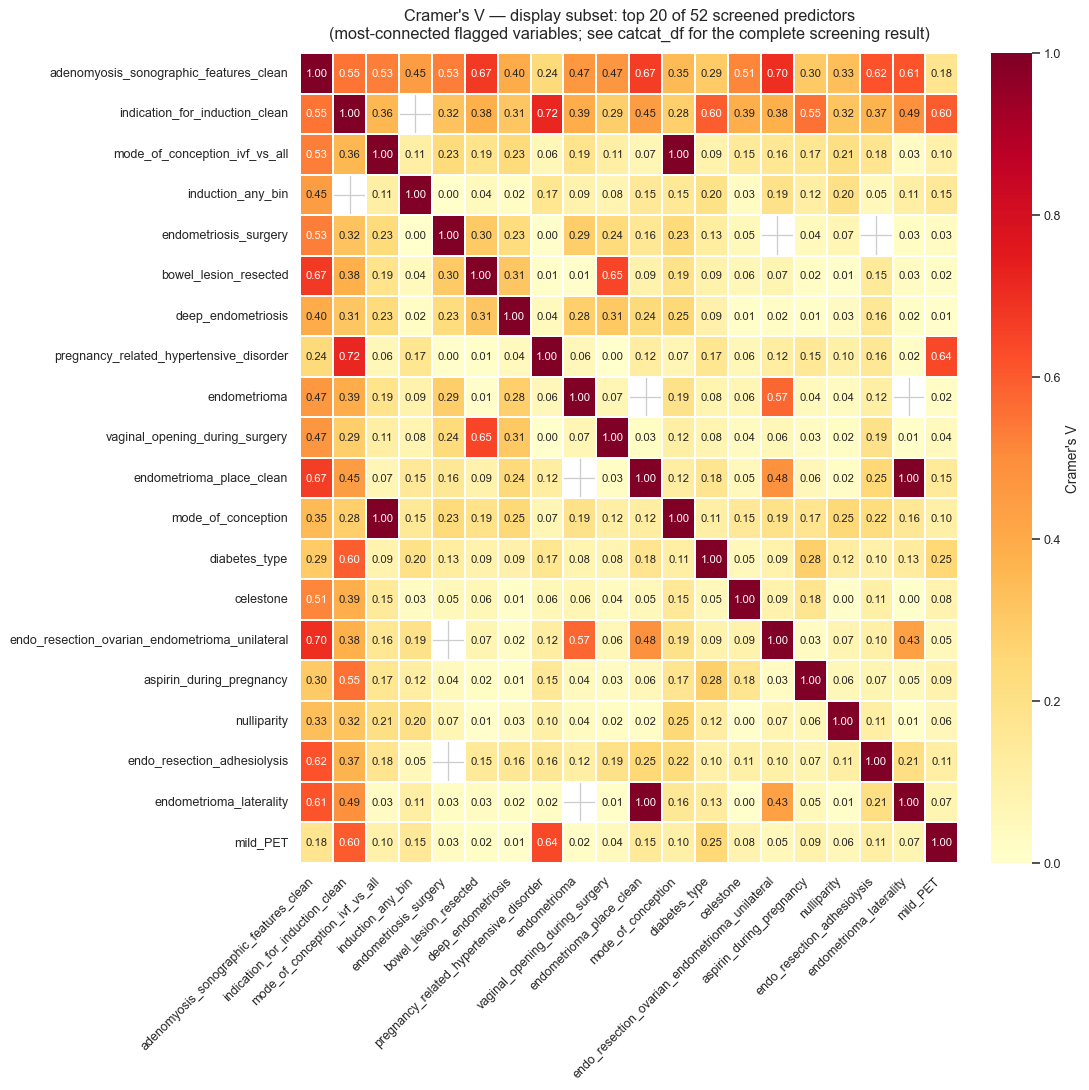

DISPLAY SUBSET ONLY: this heatmap shows 20 variable(s) (capped at 20 for inline readability). The complete categorical/binary predictor-pair screening -- every eligible pair, not just this displayed subset -- remains in catcat_df above; no pair is removed analytically by this display cap.


In [36]:
_flagged_vars = sorted(set(_catcat_flagged["var1"]) | set(_catcat_flagged["var2"]))
if len(_flagged_vars) < 2:
    print("Fewer than 2 variables in the flagged subset — heatmap skipped.")
else:
    # Capped at 20 (was 40): a 40-variable matrix was analytically valid but
    # not publication-readable. Ranking (most-connected first, via the
    # existing degree count within the flagged-pair subset, _catcat_flagged --
    # NOT the full catcat_df) is unchanged -- only the display cap is lower,
    # so cell annotations stay legible at every cap size below.
    _MAX_HEATMAP_VARS = 20
    if len(_flagged_vars) > _MAX_HEATMAP_VARS:
        _deg = pd.concat([_catcat_flagged["var1"], _catcat_flagged["var2"]]).value_counts()
        _flagged_vars = _deg.head(_MAX_HEATMAP_VARS).index.tolist()
        print(f"DISPLAY SUBSET ONLY: the flagged variable set ({len(_deg)}) exceeds "
              f"{_MAX_HEATMAP_VARS}; this heatmap shows the {_MAX_HEATMAP_VARS} "
              f"most-connected variables only (by degree count within the flagged-pair "
              f"subset, i.e. how often each variable appears among the {len(_catcat_flagged)} "
              f"flagged pairs -- not degree over the full catcat_df screening table). "
              f"No categorical/binary pair is removed analytically -- the complete "
              f"screening result for every eligible pair remains in catcat_df above, "
              f"unaffected by this inline display cap.")
    _n = len(_flagged_vars)
    _vm = np.full((_n, _n), np.nan)
    for i in range(_n):
        _vm[i, i] = 1.0
    _lookup = {}
    for _, r in catcat_df.iterrows():
        _lookup[(r["var1"], r["var2"])] = r["cramers_v"]
        _lookup[(r["var2"], r["var1"])] = r["cramers_v"]
    for i, c1 in enumerate(_flagged_vars):
        for j, c2 in enumerate(_flagged_vars):
            if i != j:
                _vm[i, j] = _lookup.get((c1, c2), np.nan)
    _v_df = pd.DataFrame(_vm, index=_flagged_vars, columns=_flagged_vars)
    fig, ax = plt.subplots(figsize=(max(9, _n * 0.6), max(7, _n * 0.6)), layout="constrained")
    sns.heatmap(_v_df, cmap="YlOrRd", vmin=0, vmax=1, ax=ax,
                cbar_kws={"label": "Cramer's V"}, linewidths=0.2,
                annot=(_n <= 20), fmt=".2f", annot_kws={"size": 9})
    ax.set_title(f"Cramer's V — display subset: top {_n} of {len(_catlike_cols)} screened "
                 f"predictors\n(most-connected flagged variables; see catcat_df for the "
                 f"complete screening result)",
                 fontsize=13, pad=12)
    ax.tick_params(axis="x", labelsize=10, rotation=45)
    ax.tick_params(axis="y", labelsize=10, rotation=0)
    plt.setp(ax.get_xticklabels(), ha="right")
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label("Cramer's V", fontsize=11)
    plt.show()
    print(f"DISPLAY SUBSET ONLY: this heatmap shows {_n} variable(s) (capped at "
          f"{_MAX_HEATMAP_VARS} for inline readability). The complete categorical/binary "
          f"predictor-pair screening -- every eligible pair, not just this displayed "
          f"subset -- remains in catcat_df above; no pair is removed analytically by "
          f"this display cap.")

**Key observations — categorical x categorical relationships:**

In [37]:
print(f"- {len(catcat_df)} of {_catcat_possible} possible categorical/binary predictor "
      f"pairs were eligible (N>=10, both dimensions with >=2 levels) and screened.")
print(f"- {int(catcat_df['sparse_cell_warning'].sum())} pair(s) carry a sparse-cell "
      f"caution flag -- interpret those p-values/effect sizes conservatively.")
if len(_high_v_pairs):
    print(f"- {len(_high_v_pairs)} pair(s) reach V>={_V_THRESH} (potential redundancy), "
          f"e.g. {[(p['var1'], p['var2']) for p in _high_v_pairs[:5]]}"
          f"{' ...' if len(_high_v_pairs) > 5 else ''} -- see the redundancy groups and "
          f"mode_of_conception review below for two of these examined in detail.")
    _ko11cc_high_v_df = catcat_df[catcat_df["high_v_flag"]]
    _ko11cc_high_v_sparse_n = int(_ko11cc_high_v_df["sparse_cell_warning"].sum())
    print(f"  CAUTION: {_ko11cc_high_v_sparse_n} of these {len(_high_v_pairs)} pair(s) "
          f"also carry a sparse-cell warning (small expected cell counts and/or "
          f"high-cardinality tables). A high Cramer's V in a sparse or high-cardinality "
          f"contingency table is NOT by itself evidence of redundancy -- redundancy "
          f"should only be treated as established when supported by variable "
          f"definitions, derivation lineage, or clear clinical/structural evidence (as "
          f"for mode_of_conception vs mode_of_conception_ivf_vs_all below), not by "
          f"association strength alone. High-V pairs are not automatically added to "
          f"REDUNDANCY_GROUPS.")
print("- Screening flags overlap, not automatic exclusion; the final redundancy call "
      "belongs to Feature Selection.")

- 1285 of 1326 possible categorical/binary predictor pairs were eligible (N>=10, both dimensions with >=2 levels) and screened.
- 1000 pair(s) carry a sparse-cell caution flag -- interpret those p-values/effect sizes conservatively.
- 38 pair(s) reach V>=0.5 (potential redundancy), e.g. [('endometrioma_place_clean', 'endometrioma_laterality'), ('mode_of_conception', 'mode_of_conception_ivf_vs_all'), ('SIPET', 'indication_for_induction_clean'), ('gestational_diabetes', 'diabetes_type'), ('mild_PET', 'any_PET')] ... -- see the redundancy groups and mode_of_conception review below for two of these examined in detail.
  CAUTION: 35 of these 38 pair(s) also carry a sparse-cell warning (small expected cell counts and/or high-cardinality tables). A high Cramer's V in a sparse or high-cardinality contingency table is NOT by itself evidence of redundancy -- redundancy should only be treated as established when supported by variable definitions, derivation lineage, or clear clinical/structural e

### A2.10d — Redundancy Review

**Purpose:** Apply `REDUNDANCY_GROUPS` to the association/correlation signals from
A2.10a–A2.10c, proposing a candidate representative per group (where one is justified) for
later feature-selection review, plus a worked example (`mode_of_conception` vs
`mode_of_conception_ivf_vs_all`).

**Not every group in `REDUNDANCY_GROUPS` has the same provenance** -- two distinct
kinds of group are shown below:
1. **Prespecified groups with an independently justified representative** (clinical
   priority and/or a documented source/derivation relationship, e.g.
   `conception_method` -- see the worked example) -- these list a candidate
   representative for later feature-selection review.
2. **Association-informed, review-only groups** (`surgical_detail_overlap`,
   `diabetes_status`) -- added *after* A2.10a–c's statistical screening flagged a strong
   association between their members, with no independently documented derivation
   showing one variable is computed from the other. These have `representative=None`:
   no member is proposed over another, and none is automatically demoted -- both/all
   members are simply flagged for clinical/Feature Selection review.

**What this checks:**
- Each group's members and, where independently justified, a candidate
  representative proposed for later feature-selection review; groups without
  independent derivation/source evidence are shown with no representative instead

**What this does NOT do:**
- Redundancy group membership does not automatically exclude a variable
- The candidate representative proposed for a Type-1 group is prespecified/
  provisional, not a final feature-selection or exclusion decision
- A Type-2 (association-informed, `representative=None`) group never causes an
  automatic representative choice or demotion for any of its members
- Final redundancy decisions require clinical review

**Output:** Redundancy groups summary (grouped by provenance type above) + a worked
deterministic-partition example

In [38]:
print("Redundancy groups (REDUNDANCY_GROUPS):")
print("Groups with an independently justified (clinical priority and/or documented")
print("source/derivation) representative propose it here for later feature-selection")
print("review; other members are flagged for redundancy review. Groups with")
print("representative=None are association-informed, review-only groups -- no member")
print("is proposed over another, and none is auto-demoted. Either way, these are")
print("prespecified/provisional proposals or review flags, not final feature selection.")
print()
for gname, gdef in REDUNDANCY_GROUPS.items():
    _present = [m for m in gdef["members"] if m in PRIMARY_COLS]
    _rep     = gdef["representative"]
    if len(_present) < 2:
        continue
    print(f"  [{gname}]")
    if _rep is None:
        # No representative asserted: evidence is association-only (no
        # independently documented derivation/source relationship), so no
        # member is proposed over another -- all are flagged for clinical/
        # Feature Selection review instead of a candidate-representative proposal.
        print(f"    Association-informed, review-only group (representative=None) -- "
              f"no independently documented derivation/source relationship; no member "
              f"is proposed over another or auto-demoted. All members flagged for "
              f"review: {_present}")
    else:
        _flagged = [m for m in _present if m != _rep]
        print(f"    Candidate representative (for later feature-selection review): '{_rep}'")
        print(f"    Other members (flagged for redundancy review)                : {_flagged}")
    print()

print("NOTE: groups with a candidate representative rest on independently documented")
print("clinical priority and/or source-derivation evidence, not on association strength")
print("alone; groups with representative=None rest on association evidence only (no")
print("confirmed derivation) and never auto-demote any member. Final decision requires")
print("clinical and modeling review either way.")

Redundancy groups (REDUNDANCY_GROUPS):
Groups with an independently justified (clinical priority and/or documented
source/derivation) representative propose it here for later feature-selection
review; other members are flagged for redundancy review. Groups with
representative=None are association-informed, review-only groups -- no member
is proposed over another, and none is auto-demoted. Either way, these are
prespecified/provisional proposals or review flags, not final feature selection.

  [parity_history]
    Candidate representative (for later feature-selection review): 'nulliparity'
    Other members (flagged for redundancy review)                : ['G', 'P', 'LIVE_BIRTH', 'AB', 'EUP']

  [prior_cs_count]
    Candidate representative (for later feature-selection review): 'S_P_CS'
    Other members (flagged for redundancy review)                : ['CS']

  [anthropometry]
    Candidate representative (for later feature-selection review): 'BMI_before'
    Other members (flagged for

**Worked example: `mode_of_conception` vs `mode_of_conception_ivf_vs_all`**

Both variables are `predictor_allowed` and both are in `PRIMARY_COLS`, so this pair is
already included in the systematic categorical-categorical screening above (A2.10c). This
block documents it explicitly with its own deterministic-partition-structure evidence
for clinical review, rather than leaving it to be found only inside a large table.
The worked example below states the deterministic derivation of
`mode_of_conception_ivf_vs_all` from `mode_of_conception`
and verifies it against the live cohort -- it intentionally does not enumerate which
source levels occur in this cohort or their counts (see the cell below); the rule
alone is sufficient to demonstrate the source/derived relationship, and enumerating
observed levels/counts here would risk disclosing a small cell.

In [39]:
_moc_sub = df_primary[["mode_of_conception", "mode_of_conception_ivf_vs_all"]].dropna()
_moc_ct = pd.crosstab(_moc_sub["mode_of_conception"], _moc_sub["mode_of_conception_ivf_vs_all"])
_moc_v = cramers_v(_moc_ct)
print(f"N={len(_moc_sub)}")
print()
# Share-safe (derivation-rule display, not a per-level enumeration): even a
# structure-only per-level mapping list still discloses which rare source
# codes exist in this cohort, and -- because the complete-case N is printed
# above and every non-rare level's exact count would otherwise be shown --
# a reader could reconstruct a small masked level's exact count by
# subtraction. The purpose of this worked example is to demonstrate the
# deterministic derivation of mode_of_conception_ivf_vs_all from
# mode_of_conception, not which source codes
# happen to occur in this cohort or their counts. The rule is verified
# against the live data internally below; only a pass/fail summary is
# printed, never a per-level breakdown or count. _moc_ct/_moc_v themselves
# (used for the analytical conclusion) are unaffected -- this is a
# display-only change.
_MOC_IVF_SOURCE_CODE = 1  # mode_of_conception == 1 is the IVF source code.
_moc_rule_violations = 0
for _lvl in _moc_ct.index:
    _expected_col = 1 if _lvl == _MOC_IVF_SOURCE_CODE else 0
    _observed_cols = [c for c in _moc_ct.columns if _moc_ct.loc[_lvl, c] > 0]
    if _observed_cols != [_expected_col]:
        _moc_rule_violations += 1
print("Deterministic derivation: mode_of_conception_ivf_vs_all = 1 iff mode_of_conception == 1.")
print(f"  mode_of_conception == {_MOC_IVF_SOURCE_CODE} (the IVF source code)  ->  "
      f"mode_of_conception_ivf_vs_all = 1")
print(f"  mode_of_conception != {_MOC_IVF_SOURCE_CODE} (any other source code)  ->  "
      f"mode_of_conception_ivf_vs_all = 0")
if _moc_rule_violations == 0:
    print("  Verified against the live cohort: every source level follows this rule exactly "
          "(a clean deterministic partition) -- see Cramer's V below for the resulting "
          "association strength.")
else:
    print(f"  NOTE: {_moc_rule_violations} source level(s) do not follow this rule exactly in "
          "the current cohort -- not a clean deterministic partition for those level(s).")
print()
print(f"Cramer's V = {_moc_v}")
print()
print("Interpretation:")
print("  mode_of_conception is the richer, multi-level source variable (its levels")
print("  include an IVF code among other conception-method codes).")
print("  mode_of_conception_ivf_vs_all is a derived binary collapse of the same")
print("  underlying information: the derivation rule above defines a deterministic")
print("  partition -- every mode_of_conception level maps to exactly one")
print("  mode_of_conception_ivf_vs_all value -- consistent with a source/derived")
print("  relationship rather than two independently measured variables.")
print("  Using both simultaneously in a model would be redundant: the binary variable")
print("  contributes no information beyond what the source categorical variable")
print("  already encodes for the IVF-vs-not split.")
print("  This pair is flagged for potential redundancy (see REDUNDANCY_GROUPS")
print("  ['conception_method']). The final choice between the richer categorical")
print("  representation and the binary collapse (a documented clinical preference for")
print("  IVF-vs-all comparisons) is deferred to Feature Selection based")
print("  on clinical meaning, missingness, and modeling relevance -- not decided here.")

N=431

Deterministic derivation: mode_of_conception_ivf_vs_all = 1 iff mode_of_conception == 1.
  mode_of_conception == 1 (the IVF source code)  ->  mode_of_conception_ivf_vs_all = 1
  mode_of_conception != 1 (any other source code)  ->  mode_of_conception_ivf_vs_all = 0
  Verified against the live cohort: every source level follows this rule exactly (a clean deterministic partition) -- see Cramer's V below for the resulting association strength.

Cramer's V = 1.0

Interpretation:
  mode_of_conception is the richer, multi-level source variable (its levels
  include an IVF code among other conception-method codes).
  mode_of_conception_ivf_vs_all is a derived binary collapse of the same
  underlying information: the derivation rule above defines a deterministic
  partition -- every mode_of_conception level maps to exactly one
  mode_of_conception_ivf_vs_all value -- consistent with a source/derived
  relationship rather than two independently measured variables.
  Using both simultaneou

**Key observations — redundancy review:**

In [40]:
_ko11r_groups_present = {g: d for g, d in REDUNDANCY_GROUPS.items()
                          if len([m for m in d["members"] if m in PRIMARY_COLS]) >= 2}
print(f"- {len(_ko11r_groups_present)} of {len(REDUNDANCY_GROUPS)} defined redundancy "
      f"groups have >=2 members currently in PRIMARY_COLS: {list(_ko11r_groups_present)}.")
print(f"- mode_of_conception vs mode_of_conception_ivf_vs_all: Cramer's V={_moc_v} "
      f"(deterministic source/derived pair, see A2.10d above) -- flag for later review "
      f"during Feature Selection, not resolved here.")
print("- endo_surgery_adhesiolysis vs endo_resection_adhesiolysis: newly registered "
      "(surgical_detail_overlap) after the systematic categorical-categorical "
      "screening flagged a strong association -- an association-informed, "
      "review-only group (representative=None), not a pre-defined clinical group. "
      "The two variables are clinically related / potentially overlapping -- both "
      "describe adhesiolysis during endometriosis surgery, but at different "
      "detail/representation levels (a standalone summary flag vs. one indicator "
      "in a related multi-hot family). Strong association alone does not prove "
      "identical meaning, so no representative is auto-selected here and neither "
      "member is auto-demoted; which (if either) should represent the concept is "
      "deferred to Feature Selection / clinical review.")
print("- gestational_diabetes vs diabetes_type (diabetes_status): same "
      "association-informed, review-only status (representative=None) -- a "
      "near-perfect cross-tabulation is suggestive of a source/derived relationship "
      "but has not been independently confirmed as an actual derivation, so neither "
      "member is auto-demoted here either.")
print("- No group membership or flagged pair causes a variable to be dropped from "
      "PRIMARY_COLS; redundancy groups are proposals/review flags for Feature "
      "Selection only, and an association-informed (representative=None) group "
      "never auto-demotes any of its members.")

- 8 of 8 defined redundancy groups have >=2 members currently in PRIMARY_COLS: ['parity_history', 'prior_cs_count', 'anthropometry', 'hypertension', 'endometrioma_location', 'conception_method', 'surgical_detail_overlap', 'diabetes_status'].
- mode_of_conception vs mode_of_conception_ivf_vs_all: Cramer's V=1.0 (deterministic source/derived pair, see A2.10d above) -- flag for later review during Feature Selection, not resolved here.
- endo_surgery_adhesiolysis vs endo_resection_adhesiolysis: newly registered (surgical_detail_overlap) after the systematic categorical-categorical screening flagged a strong association -- an association-informed, review-only group (representative=None), not a pre-defined clinical group. The two variables are clinically related / potentially overlapping -- both describe adhesiolysis during endometriosis surgery, but at different detail/representation levels (a standalone summary flag vs. one indicator in a related multi-hot family). Strong association alone

## Section A2.11 — Deep Outlier Analysis

**Purpose:** Deep, target-blind diagnostic outlier screening for all numeric primary
predictors using the IQR 1.5x rule. EDA A Section A8 contains a simpler count-only
screening pass; this is the deep analysis.

**Methodological approach:** the observed outcome (`target_intrapartum_cs`) must not
determine whether a predictor value is treated as erroneous, implausible, or worth
reviewing -- classifying an "outlier" using the target would make data-quality
judgments depend on the very outcome the model is meant to predict. This section is
therefore split into two clearly separate blocks:
1. **Target-blind screening** (this cell, `outlier_df`): IQR-based statistical
   extremeness only. Every flagged value is labeled `extreme_value_review_item`, not
   "error" or "plausible" -- this notebook has no documented clinical plausibility
   range, source-validation flag, or coding-rule registry for these numeric predictors
   that would let a target-blind process actually distinguish a data-entry error from a
   real clinical extreme. That distinction requires clinical/source review, not a
   target-rate comparison.
2. **Descriptive outcome-sensitivity block** (the next cell, `outlier_sensitivity_df`):
   an optional, clearly-labeled, purely descriptive contrast of outcome rate and
   univariate association with vs. without the flagged values. This block is shown for
   transparency only -- it explicitly does **not** determine cleaning, tiering,
   inclusion, exclusion, or preprocessing for any variable.

**What this checks:**
- IQR 1.5x bounds, outlier count/%, and actual range for all numeric PRIMARY_COLS
- (separate cell) descriptive outcome-rate and effect-estimate sensitivity, correctly
  computed as flagged outliers vs. the TRUE non-outlier subset (not the full cohort)

**What this does NOT do:**
- No outliers are removed here — this section is diagnostic only
- No target-derived signal (CS rate, p-value, effect size, significance change) is used
  to assign a tier, a data-quality label, or a deletion/keep recommendation
- Approved deletions may only happen in preprocessing, with a target-independent
  clinical justification, never here

**Output:** `outlier_df` — per-variable IQR bounds, outlier counts, and a target-blind
`extreme_value_review_item` label. `outlier_sensitivity_df` — separate descriptive-only
outcome-sensitivity contrast (see caveat above).

In [41]:
# ── Target-blind IQR screening ────────────────────────────────────────────
# No target_intrapartum_cs information is read anywhere in this cell. Every
# flagged variable receives the same target-independent review label -- this
# notebook has no clinical-plausibility-range or source-validation registry
# for numeric predictors that would let a target-blind process distinguish a
# data-entry error from a real clinical extreme.
_num_cols = [c for c in PRIMARY_COLS if infer_var_type(df_primary[c]) == "numeric"]
_outlier_log = []
_iqr_zero_log = []  # variables with IQR==0 -- standard 1.5x-IQR flagging is
                     # not informative for these (see the note below); reported
                     # separately rather than silently producing bounds=[Q1,Q1] and
                     # flagging every nonzero value. Matches EDA A Part 1 Section A8's
                     # existing, already-approved behavior for the same situation
                     # (e.g. CS, a right-skewed low-count clinical variable).

for col in _num_cols:
    s = df_primary[col].dropna()
    if len(s) < 4: continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        _iqr_zero_log.append(col)
        continue
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out_mask = (df_primary[col] < lo) | (df_primary[col] > hi)
    n_out = int(out_mask.sum())
    if n_out == 0: continue

    _outlier_log.append({
        "variable":            col,
        "earliest_entry_stage": PRIMARY_COLS_EARLIEST_STAGE.get(col),
        "N_observed":          len(s),
        "n_outliers":          n_out,
        # The scientifically interpretable within-variable outlier
        # proportion -- share of THIS variable's own non-missing values that
        # are IQR-flagged. A full-cohort-denominator figure is also kept
        # (renamed, not called a bare "%") for audit/cross-variable-scale
        # comparison only -- see the printed note below for why the two can
        # differ sharply for a heavily-missing variable.
        "outlier_pct_among_observed": round(n_out/len(s)*100, 1),
        "outlier_pct_of_full_cohort": round(n_out/len(df_primary)*100, 1),
        "iqr_bounds":          f"[{lo:.2f}, {hi:.2f}]",
        "actual_range":        f"[{s.min():.2f}, {s.max():.2f}]",
        "data_quality_status": "extreme_value_review_item",
    })

if not _outlier_log:
    print("No IQR outliers detected across numeric primary predictors.")
else:
    # Target-independent order: both percentage columns are computed purely
    # from each predictor's own IQR/observed-value distribution, never from
    # target_intrapartum_cs -- sorting by either is descriptive/readability
    # only, not a target-informed ranking. Sorted by the within-variable
    # (observed-denominator) proportion, the scientifically interpretable one.
    outlier_df = pd.DataFrame(_outlier_log).sort_values(
        "outlier_pct_among_observed", ascending=False)
    # Share-safe display copy: n_outliers can be small (1-4) --
    # same convention as EDA A's Section A8. outlier_df itself keeps true
    # values (used by the sensitivity block below and for sorting above).
    _outlier_display = outlier_df.copy()
    # Complement-aware against each variable's own N_observed for the
    # observed-denominator percentage, and against the full-cohort N for the
    # full-cohort-denominator percentage -- each suppressed relative to the
    # denominator it is actually a fraction of.
    _outlier_display["n_outliers"] = [
        share_safe.safe_count_with_complement(int(_n), int(_n_obs), enabled=SHARE_SAFE_MODE)
        for _n, _n_obs in zip(outlier_df["n_outliers"], outlier_df["N_observed"])
    ]
    _outlier_display["outlier_pct_among_observed"] = [
        share_safe.safe_pct_with_denominator(int(n), int(n_obs), enabled=SHARE_SAFE_MODE)[0]
        for n, n_obs in zip(outlier_df["n_outliers"], outlier_df["N_observed"])
    ]
    _outlier_display["outlier_pct_of_full_cohort"] = [
        share_safe.safe_pct_with_denominator(int(n), len(df_primary), enabled=SHARE_SAFE_MODE)[0]
        for n in outlier_df["n_outliers"]
    ]
    _outlier_show = ["variable", "earliest_entry_stage", "N_observed", "n_outliers",
                      "outlier_pct_among_observed", "outlier_pct_of_full_cohort",
                      "iqr_bounds", "actual_range", "data_quality_status"]
    print(f"Outlier screening — IQR 1.5x — {len(_num_cols)} numeric primary predictors:")
    print(f"  Variables with outliers: {len(outlier_df)}")
    print()
    print(_outlier_display[_outlier_show].to_string(index=False))
    print()
    print("outlier_pct_among_observed = n_outliers / N_observed -- the scientifically")
    print("interpretable within-variable outlier proportion. outlier_pct_of_full_cohort =")
    print("n_outliers / full-cohort N -- kept for audit/cross-variable-scale comparison only;")
    print("for a variable with substantial missingness the two can differ sharply (e.g. a")
    print("variable observed in only a small fraction of the cohort can have a high share of")
    print("its OWN observed values flagged while looking negligible against the full cohort).")
    print("All entries are labeled 'extreme_value_review_item' -- a target-blind,")
    print("statistical-extremeness flag only, not an error/plausible determination.")
    print("No outliers are removed here. Any approved removal must happen in")
    print("preprocessing, and must rest on a target-independent clinical justification")
    print("(documented plausibility range, source validation, or a known coding rule),")
    print("never on this table alone.")

if _iqr_zero_log:
    print()
    print(f"Variables with IQR == 0 ({len(_iqr_zero_log)}) -- standard 1.5x-IQR flagging "
          f"is not informative for these and none was performed, but they remain "
          f"evaluated numeric primary predictors, not silently dropped: {_iqr_zero_log}")

Outlier screening — IQR 1.5x — 15 numeric primary predictors:
  Variables with outliers: 14

                        variable  earliest_entry_stage  N_observed      n_outliers outlier_pct_among_observed outlier_pct_of_full_cohort       iqr_bounds     actual_range       data_quality_status
   gestational_age_at_PPROM_days                     2          16 <5 (suppressed) suppressed (n<5 in a cell) suppressed (n<5 in a cell) [208.50, 284.50] [162.00, 258.00] extreme_value_review_item
                      LIVE_BIRTH                     1         431              19                      4.400                      4.400    [-1.50, 2.50]     [0.00, 5.00] extreme_value_review_item
                               P                     1         431              18                      4.200                      4.200    [-1.50, 2.50]     [0.00, 5.00] extreme_value_review_item
                      BMI_before                     1         317              12                      3.800          

### A2.11 — Descriptive Outcome-Sensitivity Block (NOT used for tiering)

**This block is descriptive only.** It reports how the observed outcome rate and the
univariate predictor-target association differ between the flagged outliers and the
true non-outlier subset. It does **not** determine data-quality status, a keep/delete
recommendation, cleaning action, or predictor eligibility for any variable -- that
determination is Section A2.11's target-blind `outlier_df` above (or, ultimately,
clinical/source review). A larger difference here does not imply an error, and an
unchanged association does not imply the extreme value is real; both are equally
consistent with ordinary sampling variability in a modestly sized cohort.

In [42]:
_sensitivity_log = []

for col in _num_cols:
    s = df_primary[col].dropna()
    if len(s) < 4: continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0: continue  # not informative -- see A2.11's outlier_df note above
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out_mask = (df_primary[col] < lo) | (df_primary[col] > hi)
    n_out = int(out_mask.sum())
    if n_out == 0: continue
    in_mask = (df_primary[col] >= lo) & (df_primary[col] <= hi)

    # Outcome rate: outliers vs the TRUE non-outlier subset (not the full
    # cohort -- comparing outliers to a group that still contains them would
    # mislabel the contrast). Full precision throughout; `is not None` /
    # pd.notna(), never truthiness, so a genuine 0.0 rate is not mistaken for
    # "no data".
    out_sub = df_primary.loc[out_mask & df_primary[TARGET_COL].notna(), TARGET_COL]
    in_sub  = df_primary.loc[in_mask & df_primary[TARGET_COL].notna(), TARGET_COL]
    rate_out = float(out_sub.mean()) if len(out_sub) > 0 else None
    rate_in  = float(in_sub.mean()) if len(in_sub) > 0 else None
    delta_rate = (
        abs(rate_out - rate_in) if (rate_out is not None and rate_in is not None) else None
    )

    # Effect-MAGNITUDE sensitivity: full data vs. non-outlier-only.
    # mannwhitney_with_effect() returns the ABSOLUTE rank-biserial |r| (never
    # signed), so a difference between its two outputs is only ever an
    # effect-magnitude shift, not a signed effect-estimate shift -- it cannot
    # represent a direction reversal (two magnitudes near zero can look like
    # a small shift here even if the underlying association actually flips
    # sign when outliers are excluded). Reported as a continuous magnitude
    # shift (preferred over a binary "significance changed" read, which is
    # unstable with sparse events); no new inferential procedure is
    # introduced to also capture direction.
    _n_non_outliers = int(in_mask.sum())
    _sub_in = df_primary.loc[in_mask & df_primary[TARGET_COL].notna(), [col, TARGET_COL]]
    if len(_sub_in) >= 10:
        p_all, effect_all = mannwhitney_with_effect(
            df_primary.loc[df_primary[TARGET_COL]==0, col].dropna(),
            df_primary.loc[df_primary[TARGET_COL]==1, col].dropna()
        )
        p_excl, effect_excl = mannwhitney_with_effect(
            _sub_in[_sub_in[TARGET_COL]==0][col],
            _sub_in[_sub_in[TARGET_COL]==1][col]
        )
    else:
        p_all, effect_all, p_excl, effect_excl = None, None, None, None
    effect_magnitude_shift = (
        abs(effect_all - effect_excl)
        if (effect_all is not None and effect_excl is not None) else None
    )

    _sensitivity_log.append({
        "variable":               col,
        "N_observed":             len(s),
        "N_non_outliers":         _n_non_outliers,
        "n_outliers":             n_out,
        "outcome_rate_outliers":  rate_out,
        "outcome_rate_non_outliers": rate_in,
        "abs_rate_difference":    delta_rate,
        "p_value_full_data":      p_all,
        "effect_full_data":       effect_all,
        "p_value_non_outliers_only": p_excl,
        "effect_non_outliers_only":  effect_excl,
        "abs_effect_magnitude_shift": effect_magnitude_shift,
    })

if not _sensitivity_log:
    print("No IQR outliers detected — sensitivity block skipped.")
else:
    # Target-independent public order: this table's values (outcome rates,
    # p-values, effect magnitudes) are all target-derived DESCRIPTIVE
    # diagnostics, but the DISPLAY ORDER itself must not be built from one of
    # them (that would create a target-informed ranking even in a purely
    # descriptive block) -- sorted by variable name instead. All sensitivity
    # values themselves are unchanged.
    outlier_sensitivity_df = pd.DataFrame(_sensitivity_log).sort_values("variable")
    # Share-safe display copy: outcome_rate_outliers is the TARGET rate
    # within the (often small) outlier subgroup -- this ties a tiny subgroup
    # directly to the sensitive target, a more severe disclosure than an
    # ordinary event count. Suppressed whenever n_outliers (or its
    # complement within the outlier subgroup, i.e. the same n<5 rule applied
    # to the outcome count) is small. outlier_sensitivity_df itself is unaffected.
    def _suppress_outlier_rate(rate, n):
        if rate is None or not SHARE_SAFE_MODE:
            return rate
        _n_events = round(rate * n)
        _pct_disp, _ = share_safe.safe_pct_with_denominator(_n_events, n, enabled=SHARE_SAFE_MODE)
        return _pct_disp if isinstance(_pct_disp, str) else rate

    _sensitivity_display = outlier_sensitivity_df.copy()
    # Share-safe: N_non_outliers was previously copied through unsuppressed.
    # N_observed and N_non_outliers are each individually "safe-looking"
    # (typically large), but N_observed - N_non_outliers == n_outliers
    # exactly (they are complements by construction) -- showing both exact
    # totals side by side in the same row discloses a suppressed n_outliers
    # (1-4) by simple subtraction regardless of what the n_outliers column
    # itself shows. Suppressing N_non_outliers whenever its complement
    # (n_outliers) is small -- the same safe_count_with_complement()
    # convention already used for n_outliers itself -- closes this.
    _sensitivity_display["N_non_outliers"] = [
        share_safe.safe_count_with_complement(int(_n_non), int(_n_obs), enabled=SHARE_SAFE_MODE)
        for _n_non, _n_obs in zip(outlier_sensitivity_df["N_non_outliers"], outlier_sensitivity_df["N_observed"])
    ]
    _sensitivity_display["n_outliers"] = [
        share_safe.safe_count_with_complement(int(_n), int(_n_obs), enabled=SHARE_SAFE_MODE)
        for _n, _n_obs in zip(outlier_sensitivity_df["n_outliers"], outlier_sensitivity_df["N_observed"])
    ]
    _sensitivity_display["outcome_rate_outliers"] = [
        _suppress_outlier_rate(rate, n)
        for rate, n in zip(outlier_sensitivity_df["outcome_rate_outliers"], outlier_sensitivity_df["n_outliers"])
    ]
    # Two further fields are reconstruction risks and must be suppressed too,
    # even though neither is a "count" itself:
    #   - abs_rate_difference is |outcome_rate_outliers - outcome_rate_non_
    #     outliers|; even with outcome_rate_outliers hidden, showing this
    #     difference together with the (visible) outcome_rate_non_outliers
    #     algebraically hands back outcome_rate_outliers, from which the
    #     protected outlier TARGET-EVENT count is recoverable.
    #   - outcome_rate_non_outliers, shown as a precise percentage next to a
    #     known/near-known denominator, can pin its own exact numerator to a
    #     single integer once rounding is accounted for -- the same
    #     rounding-plus-denominator attack this project's disclosure policy
    #     is designed to close elsewhere.
    #
    # The suppression trigger must be whether outcome_rate_outliers ITSELF
    # needed suppression (already computed above via _suppress_outlier_rate(),
    # which checks the target-event count), not whether n_outliers's own
    # SUBGROUP MEMBERSHIP count is small: n_outliers can be large (e.g. 11,
    # 12, 18, 19) while the TARGET-EVENT count WITHIN those outliers
    # (round(outcome_rate_outliers * n_outliers)) is still 1-4 -- e.g.
    # n_outliers=11 but only 1 of those 11 is an intrapartum-CS case. The
    # target-event count, not the subgroup-membership count, is the actual
    # quantity these two fields are algebraically dependent on.
    _outlier_rate_protected = [isinstance(v, str) for v in _sensitivity_display["outcome_rate_outliers"]]
    _sensitivity_display["outcome_rate_non_outliers"] = [
        "suppressed (n<5 in a cell)" if protected else rate
        for protected, rate in zip(_outlier_rate_protected, outlier_sensitivity_df["outcome_rate_non_outliers"])
    ]
    _sensitivity_display["abs_rate_difference"] = [
        "suppressed (n<5 in a cell)" if protected else diff
        for protected, diff in zip(_outlier_rate_protected, outlier_sensitivity_df["abs_rate_difference"])
    ]
    # Canonical display formatting (fmt_pval/fmt_effect, already used
    # throughout this notebook) -- full-precision values remain in
    # outlier_sensitivity_df itself; a nonzero p-value must never render as
    # a literal "0.000" here.
    _sensitivity_display["p_value_full_data"] = _sensitivity_display["p_value_full_data"].apply(fmt_pval)
    _sensitivity_display["p_value_non_outliers_only"] = _sensitivity_display["p_value_non_outliers_only"].apply(fmt_pval)
    _sensitivity_display["effect_full_data"] = _sensitivity_display["effect_full_data"].apply(fmt_effect)
    _sensitivity_display["effect_non_outliers_only"] = _sensitivity_display["effect_non_outliers_only"].apply(fmt_effect)
    _sensitivity_display["abs_effect_magnitude_shift"] = _sensitivity_display["abs_effect_magnitude_shift"].apply(fmt_effect)
    _sensitivity_show = ["variable", "N_observed", "N_non_outliers", "n_outliers",
                          "outcome_rate_outliers", "outcome_rate_non_outliers", "abs_rate_difference",
                          "p_value_full_data", "effect_full_data",
                          "p_value_non_outliers_only", "effect_non_outliers_only",
                          "abs_effect_magnitude_shift"]
    print("Descriptive outcome-sensitivity contrast (outliers vs. TRUE non-outlier subset):")
    print(_sensitivity_display[_sensitivity_show].to_string(index=False))
    print()
    print("abs_effect_magnitude_shift is a MAGNITUDE-only comparison (mannwhitney_with_effect()")
    print("returns absolute rank-biserial |r|) -- it cannot represent a direction reversal; a")
    print("small value here does not rule out the underlying association flipping sign between")
    print("the full-data and non-outlier-only fits.")
    print("REMINDER: descriptive only. Does NOT determine cleaning, tiering, inclusion,")
    print("exclusion, or preprocessing for any variable -- see A2.11's outlier_df above")
    print("for the (target-blind) data-quality-review label.")

Descriptive outcome-sensitivity contrast (outliers vs. TRUE non-outlier subset):
                        variable  N_observed             N_non_outliers      n_outliers      outcome_rate_outliers  outcome_rate_non_outliers        abs_rate_difference p_value_full_data effect_full_data p_value_non_outliers_only effect_non_outliers_only abs_effect_magnitude_shift
                              AB         431                        420              11 suppressed (n<5 in a cell) suppressed (n<5 in a cell) suppressed (n<5 in a cell)            0.8976            0.008                    0.9737                    0.002                      0.006
                             AGE         431 suppressed (complementary) <5 (suppressed) suppressed (n<5 in a cell) suppressed (n<5 in a cell) suppressed (n<5 in a cell)            0.0136            0.197                    0.0241                    0.181                      0.016
                       BMI_after         184 suppressed (complementary) <

**Key observations — deep outlier screening:**

In [43]:
if "outlier_df" in dir() and len(outlier_df):
    print(f"- {len(outlier_df)} of {len(_num_cols)} numeric primary predictors have "
          f"IQR-flagged values; all are labeled 'extreme_value_review_item' "
          f"(target-blind -- see A2.11 methodology note above).")
    print("- No value is removed or modified here, and any approved removal must happen")
    print("  in preprocessing with a target-independent clinical justification.")
    if "outlier_sensitivity_df" in dir() and len(outlier_sensitivity_df):
        print(f"- A separate, purely descriptive outcome-sensitivity contrast is reported "
              f"for {len(outlier_sensitivity_df)} variable(s) above -- it does not change "
              f"this section's data-quality labels or any downstream eligibility.")
else:
    print("- No IQR-flagged values among numeric primary predictors in the current cohort.")

- 14 of 15 numeric primary predictors have IQR-flagged values; all are labeled 'extreme_value_review_item' (target-blind -- see A2.11 methodology note above).
- No value is removed or modified here, and any approved removal must happen
  in preprocessing with a target-independent clinical justification.
- A separate, purely descriptive outcome-sensitivity contrast is reported for 14 variable(s) above -- it does not change this section's data-quality labels or any downstream eligibility.


## Section A2.12 — Comprehensive Predictor Diagnostic Summary

**Purpose:** Produce a single reference table covering all PRIMARY_COLS with every
available diagnostic metric, so no variable is silently omitted from the analysis
record. This section reuses the results already computed earlier (missingness from
A2.7, sparsity from A2.8, and the formal association test from A2.9) rather than
recomputing a second, independent association pass.

**Methodological approach:** this table is a diagnostic summary, not a pre-model
recommendation layer. Whole-cohort target-derived information (`too_sparse`,
`separation_risk`, `effect_size`) is displayed, clearly marked, but is never used to
generate an include/exclude/discuss recommendation, define a pre-model candidate
list, or set a display order — the table is sorted by a target-independent key only
(clinical tier, then variable name), so that no target-derived signal creates an
indirect selection path into the model.

**What this checks:**
- Missingness, sparsity, association, and redundancy per primary predictor
- Clinical timing classification (`measurement_horizon`: baseline / near_delivery /
  intrapartum, with `pending_timing_confirmation` / `unclear` used only where applicable)

**What this does NOT do:**
- Generates no INCLUDE / EXCLUDE / DISCUSS / recommendation label
- Does not define a pre-model candidate list or change variable classification
- No variables are removed or reclassified
- Does not rerun the association test — `effect_size`/`fdr_q` are read directly from
  `assoc_df` (Section A2.9), the formal ranked test

**Output:** `predictor_diagnostic_df` — one row per primary predictor, all diagnostic
metrics combined, in target-independent order. The object itself carries every field
listed below; the inline printed table further down is a selected, readable excerpt of
that object, not a narrower object -- see that cell's own note on which fields are
excerpted.

**Columns (all present on the `predictor_diagnostic_df` object):**
- `missing_%` / `structural_nan` — from A2.7
- `cs_events` / `separation_risk` / `too_sparse` — from A2.8 (target-derived; descriptive)
- `effect_size` / `fdr_q` — reused directly from A2.9's formal association test
  (`assoc_df`; target-derived; descriptive). `fdr_q` is stored at full precision;
  `fdr_q_display` is the formatted string for display only.
- `redundancy_group` / `is_representative` — from the redundancy-group definitions
  (target-independent)
- `human_decision_needed` — yes if clinical judgment is required before modeling (see A2.14)

In [44]:
# ── Reuse A2.9's formal association test (assoc_df) -- do not recompute ────
# Previously this cell ran its own independent quick Mann-Whitney/chi-square +
# BH-FDR pass over PRIMARY_COLS, duplicating A2.9's formal, canonical
# association test with a slightly different implementation (no retain_flag /
# effect_magnitude / per-group N breakdown), risking silent drift between the
# two. assoc_df (built in A2.9, iterating the same PRIMARY_COLS) is looked up
# directly instead.
_assoc_lk_b12 = assoc_df.set_index("variable")

# Redundancy lookup. representative=None means the group is association-only
# evidence (no independently documented derivation/source relationship) --
# treat every member as non-demotable (is_representative=True) rather than
# auto-demoting all of them, which `_m == None` would otherwise do.
_red_group = {}
_red_rep   = {}
for _gname, _gdef in REDUNDANCY_GROUPS.items():
    for _m in _gdef["members"]:
        _red_group[_m] = _gname
        _red_rep[_m]   = (
            True if _gdef["representative"] is None else (_m == _gdef["representative"])
        )

# the hand-maintained `_CLINICAL_DEC` dict (which had
# drifted out of sync with A2.14's CLINICAL_DECISIONS -- see the
# TIMING_REVIEW_STATUS definition in Part 1 for the full history) is removed.
# `human_decision_needed` below is now derived directly from
# TIMING_REVIEW_STATUS, the single canonical registry both A2.12 and A2.14 read
# from (A2.14's CLINICAL_DECISIONS entries are validated against it at
# runtime, not independently duplicated).

# Build comprehensive diagnostic table. No recommendation/suggestion column is
# computed from any of these metrics -- every column
# below is either target-independent (timing, clinical_tier, missingness,
# redundancy) or an explicitly target-derived DESCRIPTIVE metric reused as-is
# from its canonical source (A2.8's sparse_df, A2.9's assoc_df).
_rows = []
for _col in PRIMARY_COLS:
    _miss_row = miss_df[miss_df["variable"] == _col].iloc[0] if _col in miss_df["variable"].values else {}
    _sp_row   = sparse_df[sparse_df["variable"] == _col].iloc[0] if _col in sparse_df["variable"].values else {}
    _m_pct    = float(_miss_row.get("missing_%", 0))
    _struct   = bool(_miss_row.get("structural_nan", False))
    _sep      = bool(_sp_row.get("separation_risk", False))
    _sparse   = bool(_sp_row.get("too_sparse", False))
    _cs_ev    = _sp_row.get("cs_events", "—")
    _min_cell = _sp_row.get("min_any_cell", None)
    # Internal-only (never in _display_cols below, same pattern already used
    # elsewhere in this notebook for a raw value kept for computation but
    # excluded from any displayed table) -- needed to apply the same
    # cross-artifact-safe suppression to cs_events as A2.8/A2.15 use.
    _vag_ev_internal = _sp_row.get("min_vaginal_cell", None)
    _n_analyzed_internal = _sp_row.get("N_analyzed", None)
    _type_internal = _sp_row.get("type", None)
    if _col in _assoc_lk_b12.index:
        _eff_raw = _assoc_lk_b12.loc[_col, "effect_size"]
        _eff     = float(_eff_raw) if pd.notna(_eff_raw) else None
        _q_raw   = _assoc_lk_b12.loc[_col, "q_value_bh"]
        _q       = float(_q_raw) if pd.notna(_q_raw) else None
        _fdr_sig = bool(_assoc_lk_b12.loc[_col, "fdr_sig"])
    else:
        _eff, _q, _fdr_sig = None, None, False
    # Full-precision numeric fdr_q (reused directly from assoc_df, matching
    # effect_size's own treatment) -- fdr_q_display is formatting only via
    # the canonical fmt_pval() formatter, never used in any computation.
    _q_display = fmt_pval(_q)
    _grp      = _red_group.get(_col, "—")
    _is_rep   = _red_rep.get(_col, True)
    _tier     = CLINICAL_TIER.get(_col, 0)
    _timing   = TIMING_MAP.get(_col, "unknown")
    # modeling_clearance: orthogonal to _timing (measurement
    # horizon) -- see MODELING_CLEARANCE_MAP's definition in Part 1. Never
    # describe a "pending_timing_confirmation" variable as cleared just
    # because its horizon label happens to be "intrapartum". Direct indexing
    # (not .get(_col, "cleared")) is deliberate -- see MODELING_CLEARANCE_MAP's
    # fail-loud coverage assertions in Part 1: a fail-open default would
    # silently treat an unmapped variable as cleared for modeling.
    _clearance = MODELING_CLEARANCE_MAP[_col]

    # Human decision needed? (target-independent: driven by the canonical
    # TIMING_REVIEW_STATUS registry -- OPEN means clinical/timing review is
    # still required -- and timing classification, not by effect_size)
    _human = TIMING_REVIEW_STATUS.get(_col) == "OPEN" or _timing == "unclear"

    _rows.append({
        "variable":            _col,
        "predictor_classification": PRIMARY_COLS_CLASSIFICATION.get(_col, "unknown"),
        "earliest_entry_stage": PRIMARY_COLS_EARLIEST_STAGE.get(_col),
        "measurement_horizon": _timing,
        "modeling_clearance":  _clearance,
        "clinical_tier":       _tier,
        "missing_%":           _m_pct,
        "structural_nan":      _struct,
        "cs_events":           _cs_ev,
        "min_any_cell":        _min_cell,
        "_min_vaginal_cell":   _vag_ev_internal,
        "_N_analyzed":         _n_analyzed_internal,
        "_sparse_type":        _type_internal,
        "separation_risk":     _sep,
        "too_sparse":          _sparse,
        "effect_size":         _eff,
        "fdr_q":               _q,
        "fdr_q_display":       _q_display,
        "fdr_sig":             _fdr_sig,
        "redundancy_group":    _grp,
        "is_representative":   _is_rep,
        "human_decision_needed": _human,
        "decision_question":   TIMING_REVIEW_REASON.get(_col, ""),
    })

# Target-independent stable ordering only: clinical tier (a pre-specified
# clinical judgment, not derived from target_intrapartum_cs), then variable
# name alphabetically. No target-derived column (effect_size, fdr_q,
# too_sparse, separation_risk) participates in sort order, so a target
# permutation cannot change this table's row order (see the regression test).
predictor_diagnostic_df = pd.DataFrame(_rows).sort_values(
    ["clinical_tier", "variable"], ascending=[False, True]
)

print(f"All primary predictors — comprehensive diagnostic summary — {len(predictor_diagnostic_df)} variables:")
print("(effect_size / fdr_q reused directly from A2.9's assoc_df -- not recomputed here;")
print(" fdr_q is full precision, fdr_q_display below is formatted for display only)")
print("(sort order is target-independent: clinical_tier desc, then variable name)")
print("(this printed table is a selected excerpt -- predictor_diagnostic_df itself carries")
print(" every column listed in this section's header, e.g. structural_nan/fdr_sig/")
print(" is_representative/decision_question, not shown inline below)")
print()
# Share-safe display copy: cs_events/min_any_cell are reused
# directly from A2.8's sparse_df raw values -- same small-cell risk as A2.8
# itself (a numerator below the disclosure threshold), suppressed here on
# the same convention. predictor_diagnostic_df keeps true values for any
# downstream use.
#
# cs_events must be suppressed on both the within-CS-group complement AND
# the cross-group total-positive complement A1's Section A6 separately
# reports. This table does not display min_vaginal_cell (it
# is not in _display_cols below), but a LARGE, unsuppressed cs_events shown
# here can still combine with A1's total to recover a small vaginal
# complement even though this table never shows that number itself -- the
# disclosure risk does not require both numbers to live in the same table.
# Reuses share_safe.suppress_binary_target_display() via the internal-only
# _min_vaginal_cell/_N_analyzed/_sparse_type columns (dropped from
# _display_cols -- same "raw value kept internally, excluded from any
# displayed table" convention already used elsewhere in this notebook).
_pdd_display = predictor_diagnostic_df.copy()
_cs_events_fixed = []
for _idx, _row in predictor_diagnostic_df.iterrows():
    if (_row["_sparse_type"] == "binary" and isinstance(_row["cs_events"], str)
            and "/" in _row["cs_events"] and _row["_min_vaginal_cell"] is not None):
        _cs_n, _cs_d = (int(x) for x in _row["cs_events"].split("=")[-1].split("/"))
        _vag_n = int(_row["_min_vaginal_cell"])
        _vag_d = int(_row["_N_analyzed"]) - _cs_d
        _, _cd = share_safe.suppress_binary_target_display(
            _vag_n, _cs_n, _vag_d, _cs_d, enabled=SHARE_SAFE_MODE
        )
        _cs_events_fixed.append(_cd if isinstance(_cd, str) else f"{_cd}/{_cs_d}")
    else:
        _cs_events_fixed.append(_suppress_cs_events_label(_row["cs_events"]))
_pdd_display["cs_events"] = _cs_events_fixed
_pdd_display["min_any_cell"] = _pdd_display["min_any_cell"].apply(
    lambda n: share_safe.safe_count(n, enabled=SHARE_SAFE_MODE)
)
_display_cols = ["variable","predictor_classification","earliest_entry_stage","measurement_horizon",
                 "modeling_clearance","missing_%","cs_events","min_any_cell",
                 "separation_risk","too_sparse","effect_size","fdr_q_display","redundancy_group","human_decision_needed"]
print("Summary by earliest-entry stage:")
print(predictor_diagnostic_df["earliest_entry_stage"].value_counts().sort_index().to_string())
print()
print("Summary by modeling_clearance:")
print(predictor_diagnostic_df["modeling_clearance"].value_counts().to_string())
print()
_pdd_attention_mask = (
    (predictor_diagnostic_df["missing_%"] > 30)
    | predictor_diagnostic_df["separation_risk"]
    | predictor_diagnostic_df["too_sparse"]
    | (predictor_diagnostic_df["redundancy_group"] != "—")
    | (predictor_diagnostic_df["modeling_clearance"] != "cleared")
)
_pdd_attention = _pdd_display[_pdd_attention_mask]
print(f"Variables requiring special attention (high missing_%, separation, too sparse, "
      f"redundancy-group membership, or non-cleared modeling_clearance): {len(_pdd_attention)} "
      f"of {len(predictor_diagnostic_df)}")
if len(_pdd_attention):
    print(_pdd_attention[_display_cols].to_string(index=False))
else:
    print("  (none)")
print()
print("The full predictor_diagnostic_df table (all primary predictors, every column) "
      "remains available in memory.")
print()
print(f"Separation risk : {predictor_diagnostic_df['separation_risk'].sum()} variables "
      f"(descriptive only -- see A2.13; not auto-excluded from any candidate list here)")
print(f"Too sparse      : {predictor_diagnostic_df['too_sparse'].sum()} variables (descriptive only -- see A2.13)")
print(f"Human decision  : {predictor_diagnostic_df['human_decision_needed'].sum()} variables (see A2.14)")
print(f"FDR q<0.05      : {predictor_diagnostic_df['fdr_sig'].sum()} variables (descriptive only)")
_ko5_pending_clearance = predictor_diagnostic_df[
    predictor_diagnostic_df["modeling_clearance"] == "pending_timing_confirmation"
]["variable"].tolist()
print(f"Modeling clearance pending: {len(_ko5_pending_clearance)} variable(s) -- {_ko5_pending_clearance} -- "
      "measurement_horizon may say 'intrapartum' for these, but that is a timing fact, not a "
      "clearance claim; they remain blocked from every model until clinically confirmed (see A2.14/A2.15).")

All primary predictors — comprehensive diagnostic summary — 67 variables:
(effect_size / fdr_q reused directly from A2.9's assoc_df -- not recomputed here;
 fdr_q is full precision, fdr_q_display below is formatted for display only)
(sort order is target-independent: clinical_tier desc, then variable name)
(this printed table is a selected excerpt -- predictor_diagnostic_df itself carries
 every column listed in this section's header, e.g. structural_nan/fdr_sig/
 is_representative/decision_question, not shown inline below)

Summary by earliest-entry stage:
earliest_entry_stage
1    56
2     6
3     5

Summary by modeling_clearance:
modeling_clearance
cleared    67

Variables requiring special attention (high missing_%, separation, too sparse, redundancy-group membership, or non-cleared modeling_clearance): 47 of 67
                                      variable                          predictor_classification  earliest_entry_stage measurement_horizon modeling_clearance  missing_%    

**Key observations — comprehensive predictor diagnostic table:**

In [45]:
_ko5_sep = predictor_diagnostic_df[predictor_diagnostic_df["separation_risk"]]
_ko5_sparse = predictor_diagnostic_df[
    predictor_diagnostic_df["too_sparse"] & ~predictor_diagnostic_df["separation_risk"]
]
_ko5_nonrep = predictor_diagnostic_df[~predictor_diagnostic_df["is_representative"]]
print(f"- {len(predictor_diagnostic_df)} primary predictors summarized in one diagnostic "
      f"table; {int(predictor_diagnostic_df['human_decision_needed'].sum())} flagged for "
      f"human/clinical decision (see A2.14).")
if len(_ko5_sep):
    print(f"- {len(_ko5_sep)} variable(s) have complete separation (an empty "
          f"target-by-level cell): {_ko5_sep['variable'].tolist()} -- a hard modeling "
          f"constraint for unpenalized logistic regression specifically, not resolved here.")
if len(_ko5_sparse):
    print(f"- {len(_ko5_sparse)} variable(s) are too sparse (<5 in some target-by-level "
          f"cell) without being fully separated: {_ko5_sparse['variable'].tolist()}.")
if len(_ko5_nonrep):
    print(f"- {len(_ko5_nonrep)} variable(s) are the non-representative member of a "
          f"redundancy group -- flagged for consideration during Feature Selection, "
          f"not auto-excluded here.")
print("- No recommendation (include/exclude/discuss) is computed in this table; see the")
print("  A2.12 methodology note for why an indirect target-informed selection path was")
print("  removed from this section.")

- 67 primary predictors summarized in one diagnostic table; 0 flagged for human/clinical decision (see A2.14).
- 8 variable(s) have complete separation (an empty target-by-level cell): ['VBAC', 'SIPET', 'adenomyosis_sonographic_features_clean', 'diabetes_type', 'endo_resection_epiploica', 'endo_resection_uterus', 'indication_for_induction_clean', 'smoking'] -- a hard modeling constraint for unpenalized logistic regression specifically, not resolved here.
- 18 variable(s) are too sparse (<5 in some target-by-level cell) without being fully separated: ['IUGR', 'S_P_CS', 'EUP', 'PIH', 'any_PET', 'bladder_lesion_resected', 'clexane_during_pregnancy', 'endo_resection_adnexa', 'endo_resection_appendix', 'endo_resection_fallopian_tube', 'endo_resection_no_resection', 'endo_resection_ovarian_endometrioma_bilateral', 'endometrioma_place_clean', 'magnesium', 'mild_PET', 'mode_of_conception', 'placental_abruption', 'severe_PET'].
- 17 variable(s) are the non-representative member of a redundancy 

## Section A2.13 — Variable-Readiness Diagnostics (Descriptive Only)

**Purpose:** Assign a transparent additive readiness score to each primary predictor
and report it as a complete, descriptive diagnostic table, grouped by each variable's
earliest cumulative-stage entry point. This is a screening/diagnostic tool, not a
feature-selection step.

> **IMPORTANT: This section does NOT select final model variables.** No Top-N/Core/
> Extended candidate list is produced. Every eligible variable is retained and shown.
> Final variable inclusion for any stage's model requires all of: outstanding clinical
> considerations resolved (Section A2.14), clinical approval of the final variable set,
> and modeling validation (cross-validation, convergence check, calibration assessment).

**Design principles:** no Top-N ranking is produced, since a ranked list computed over
only the Stage-2-only or Stage-3-only increment (small stage-specific increments) would
imply a level of selection this section does not perform -- every eligible variable in
every stage is retained instead. No stage receives a systematic scoring bonus or penalty
purely from its classification label. Whole-cohort information about
`target_intrapartum_cs` never determines a pre-model candidate set: the score is built
entirely from properties that do not depend on the observed target (predictor
eligibility, missingness/data availability, predictor-predictor redundancy).
Predictor-vs-target association evidence (`effect_size`, `fdr_sig`, from A2.9) and
target-by-level sparsity/separation (from A2.8) remain available as **descriptive/
warning columns only** -- useful context for clinical review -- but are not summed
into the score and do not filter any variable from the output table.

**What this checks:**
- Additive, target-independent readiness score per primary predictor (transparent,
  explainable), reported for every eligible variable, grouped by earliest cumulative
  prediction-stage entry (Stage 1 / Stage 2 / Stage 3)
- Separation-risk and too-sparse status shown as warning flags on every row (not used
  to exclude)

**What this does NOT do:**
- No Top-N truncation of any kind, and specifically no ranked list over just the
  Stage-2-only or Stage-3-only increment
- Scoring weights are NOT changed here — see `SCORING_WEIGHTS` in the EDA setup cell
- Statistical tests are NOT changed — the descriptive columns use outputs from A2.7/A2.8/A2.9
- Variables are NOT added to or removed from PRIMARY_COLS by this section
- Whole-cohort target information does NOT rank, include, or exclude any variable here

**Score components** (weights from `SCORING_WEIGHTS`; all target-independent):
- `s_clinical` = CLINICAL_TIER × 3.0
- `s_miss`     = -0.4 × (missing% / 10). For structural-NaN columns with a confirmed
  subgroup-applicability gate (`STRUCTURAL_SUBGROUP_GATES`), missing% here is the
  genuine within-applicable-subgroup rate, not the (inflated) full-cohort rate;
  deterministic structural non-applicability itself is never penalized. For a
  structural column with no confirmed gate, the full-cohort missing% is used as-is
- `s_redund`   = -2.5 if non-representative member of a redundancy group

**Displayed but NOT scored (descriptive/warning only):**
- `effect_size` / `fdr_sig` — predictor-vs-target association (A2.9)
- `too_sparse` / `separation_risk` — target-by-level cell sparsity (A2.8)

**Output:** one complete readiness diagnostic table (`score_df`), covering every
eligible variable, grouped by `earliest_entry_stage` and sorted by score within each
group for readability only -- not a candidate/recommendation ranking.

In [46]:
# ── Build score table from A2.7/A2.8/A2.9 outputs ───────────────────────────────
# assoc_df, miss_df, sparse_df, predictor_diagnostic_df built in earlier
# sections. Required upstream inputs: fail loudly (not a silent {} fallback)
# if this cell is ever executed out of sequence --
# a silent fallback would let A2.13 render a plausible-looking but wrong score
# table (every association/sparsity/missingness lookup would resolve to a
# default) instead of surfacing that a required prior section was skipped.

_assoc_lk  = assoc_df.set_index("variable")
_miss_lk   = miss_df.set_index("variable")
_sparse_lk = sparse_df.set_index("variable")

# Demoted members from redundancy groups. representative=None means the group
# is association-only evidence (no independently documented derivation/source
# relationship) -- no member is auto-demoted for that group; see A2.10d's
# surgical_detail_overlap for the current example.
_demoted = set()
for _gdef in REDUNDANCY_GROUPS.values():
    _present = [m for m in _gdef["members"] if m in PRIMARY_COLS]
    if len(_present) >= 2 and _gdef["representative"] is not None:
        _demoted.update(m for m in _present if m != _gdef["representative"])

w = SCORING_WEIGHTS
_score_rows = []

for col in PRIMARY_COLS:
    _tier    = CLINICAL_TIER.get(col, 0)
    _timing  = TIMING_MAP.get(col, "unclear")
    # modeling_clearance: orthogonal to _timing (measurement
    # horizon only) -- see MODELING_CLEARANCE_MAP's definition in Part 1.
    # Displayed alongside the score as descriptive/warning context; not part
    # of the score itself (matching this section's target-independence rule
    # for every other descriptive/warning column). Direct indexing (not
    # .get(col, "cleared")) is deliberate -- an unmapped variable must raise,
    # never be silently treated as cleared for modeling.
    _clearance = MODELING_CLEARANCE_MAP[col]

    # Association and target-by-level sparsity/separation -- DESCRIPTIVE /
    # WARNING columns only. Whole-cohort information
    # about target_intrapartum_cs must never determine a pre-model candidate
    # set; these are displayed for clinical-review context but are NOT summed
    # into the score and do NOT filter Core/Extended membership below.
    _eff = float(_assoc_lk.loc[col, "effect_size"]) if (
        col in _assoc_lk.index and pd.notna(_assoc_lk.loc[col, "effect_size"])
    ) else None
    _fdr_sig = bool(_assoc_lk.loc[col, "fdr_sig"]) if col in _assoc_lk.index else False
    _too_sparse = bool(_sparse_lk.loc[col, "too_sparse"]) if col in _sparse_lk.index else False
    _separation_risk = bool(_sparse_lk.loc[col, "separation_risk"]) if (
        col in _sparse_lk.index and "separation_risk" in _sparse_lk.columns
    ) else False

    # Missingness (target-independent: data availability only). A structural
    # column does not automatically get a zero missingness penalty -- that
    # would be too coarse, because a structural
    # column can still have genuine missing values within the subgroup where
    # it actually applies. Where a confirmed subgroup-applicability gate
    # exists (STRUCTURAL_SUBGROUP_GATES, checked via miss_df's
    # genuine_missing_pct_in_subgroup column, built in A2.7), the score uses
    # that genuine within-subgroup rate; deterministic structural
    # non-applicability itself is never penalized either way. For a
    # structural column with no confirmed gate, the full-cohort missing_%
    # is used as-is (conservative -- not assumed exempt).
    _full_miss_pct = float(_miss_lk.loc[col, "missing_%"]) if col in _miss_lk.index else 0.0
    _structural = col in STRUCTURAL_NAN_COLS
    _has_confirmed_gate = col in STRUCTURAL_SUBGROUP_GATES
    if _structural and _has_confirmed_gate and col in _miss_lk.index:
        _genuine_pct = _miss_lk.loc[col, "genuine_missing_pct_in_subgroup"]
        _miss_pct_for_score = float(_genuine_pct) if pd.notna(_genuine_pct) else 0.0
    else:
        _miss_pct_for_score = _full_miss_pct

    # Score components -- all target-independent. See A2.13 header for the
    # full target-independence rationale. No timing term: a variable's
    # cumulative-stage entry point (earliest_entry_stage, below) is reported
    # separately and must never bias the score itself (see A2.13 header,
    # "Timing-bonus removal").
    s_clin   = w["clinical_tier"]              * _tier
    s_miss   = w["missingness_penalty_per_10pct"] * (_miss_pct_for_score / 10.0)
    s_red    = w["redundancy_demotion"] if col in _demoted else 0.0
    total    = s_clin + s_miss + s_red

    _score_rows.append({
        "variable":          col,
        "predictor_classification": PRIMARY_COLS_CLASSIFICATION.get(col, "unknown"),
        "earliest_entry_stage": PRIMARY_COLS_EARLIEST_STAGE.get(col),
        "measurement_horizon": _timing,
        "modeling_clearance": _clearance,
        "clinical_tier":     _tier,
        "missing_%":         _full_miss_pct,
        "missing_%_used_in_score": round(_miss_pct_for_score, 1),
        "structural_nan":    _structural,
        "redundancy_demoted": col in _demoted,
        # "+ 0.0" after round() normalizes an exact-zero component to a
        # plain 0.0 -- display-only cosmetic fix for the negative-zero float
        # (e.g. round(-0.4 * 0.0, 2) == -0.0) that pure round() can otherwise
        # produce; the underlying score computation above is unaffected.
        "s_clinical":        round(s_clin, 2) + 0.0,
        "s_miss":            round(s_miss, 2) + 0.0,
        "s_redund":          round(s_red, 2) + 0.0,
        "score":             round(total, 2) + 0.0,
        # Descriptive/warning only -- NOT part of the score above.
        "effect_size":       _eff,
        "fdr_sig":           _fdr_sig,
        "too_sparse":        _too_sparse,
        "separation_risk":   _separation_risk,
    })

score_df = pd.DataFrame(_score_rows).sort_values(
    ["earliest_entry_stage", "score"], ascending=[True, False])

_show = ["variable","predictor_classification","earliest_entry_stage","measurement_horizon",
         "modeling_clearance","clinical_tier",
         "missing_%","missing_%_used_in_score","score",
         "effect_size","too_sparse","separation_risk","redundancy_demoted"]
print(f"Variable-readiness diagnostic summary — {len(score_df)} eligible variables "
      "(grouped by earliest entry stage):")
print(score_df.groupby("earliest_entry_stage").size().to_string())
print()
_score_warn_mask = (
    score_df["too_sparse"] | score_df["separation_risk"] | score_df["redundancy_demoted"]
)
_score_warn = score_df[_score_warn_mask]
print(f"Variables with a non-default warning (too_sparse, separation_risk, or "
      f"redundancy_demoted): {len(_score_warn)} of {len(score_df)}")
if len(_score_warn):
    print(_score_warn[_show].to_string(index=False))
else:
    print("  (none)")
print()
print("The full score_df table (every eligible variable, all columns) remains available")
print("in memory.")
print()
print("Score components (all target-independent): s_clinical + s_miss + s_redund = score")
print("(no timing term -- see A2.13 header, 'Timing-bonus removal')")
print("missing_% is the full-cohort figure (informational); missing_%_used_in_score is")
print("the genuine within-applicable-subgroup rate for structural columns with a")
print("confirmed subgroup gate, and the full-cohort rate otherwise -- see A2.7/A2.13 header.")
print("effect_size / too_sparse / separation_risk are shown for clinical-review context")
print("only -- they are NOT part of the score and do NOT filter any variable from this table.")

Variable-readiness diagnostic summary — 67 eligible variables (grouped by earliest entry stage):
earliest_entry_stage
1    56
2     6
3     5

Variables with a non-default warning (too_sparse, separation_risk, or redundancy_demoted): 35 of 67
                                     variable                          predictor_classification  earliest_entry_stage measurement_horizon modeling_clearance  clinical_tier  missing_%  missing_%_used_in_score  score  effect_size  too_sparse  separation_risk  redundancy_demoted
                                       S_P_CS                                 predictor_allowed                     1            baseline            cleared              2      0.000                    0.000  6.000        0.048        True            False               False
                                         VBAC                                 predictor_allowed                     1            baseline            cleared              2      0.000                    0

In [47]:
# ── Complete per-stage readiness diagnostics -- NOT a Top-N candidate list ──
# no ranked Top-N list is produced over the whole pool
# or over any single-stage increment. A Top-N ranking over the small
# Stage-3-only increment is not a meaningful selection and can be mistaken
# for feature selection -- every eligible variable is retained and reported
# instead, grouped by earliest_entry_stage.
_primary_df = score_df.copy()

# redundancy_demoted used to be a hard filter here,
# removing those variables from the table entirely before the per-stage
# "all retained" print below -- which made that print misleading (it claimed
# every variable was retained while some had already been silently dropped).
# No variable is filtered out of this diagnostic table for any reason
# (matching the same target-independence rule already applied to
# too_sparse/separation_risk): redundancy_demoted is now displayed as a
# warning column, exactly like too_sparse/separation_risk, so a human
# reviewer sees it without the notebook excluding on their behalf.
_diagnostic_pool = _primary_df.sort_values(
    ["earliest_entry_stage", "score", "variable"], ascending=[True, False, True])

_show2 = ["variable","predictor_classification","measurement_horizon","modeling_clearance",
          "clinical_tier","score",
          "effect_size","too_sparse","separation_risk","redundancy_demoted"]
_STAGE_LABELS = {
    1: "Stage 1 (pre-labor)",
    2: "Stage 2 (pre-labor + near-delivery) -- newly eligible at this stage",
    3: "Stage 3 (pre-labor + near-delivery + intrapartum) -- newly eligible at this stage",
}
for _stage in (1, 2, 3):
    _stage_df = _diagnostic_pool[_diagnostic_pool["earliest_entry_stage"] == _stage]
    print(f"{_STAGE_LABELS[_stage]}: {len(_stage_df)} variable(s), all shown below "
          f"(no Top-N truncation, no redundancy-demoted exclusion)")
    print(_stage_df[_show2].to_string(index=False))
    _stage_warn = _stage_df[_stage_df["too_sparse"] | _stage_df["separation_risk"]]["variable"].tolist()
    if _stage_warn:
        print(f"  WARNING: {len(_stage_warn)} variable(s) have a target-by-level sparsity/"
              f"separation warning and require explicit clinical/modeling review before use: "
              f"{_stage_warn}")
    _stage_demoted = _stage_df[_stage_df["redundancy_demoted"]]["variable"].tolist()
    if _stage_demoted:
        print(f"  WARNING: {len(_stage_demoted)} variable(s) are redundancy-demoted "
              f"(predictor-predictor relationship, not target-derived) and require explicit "
              f"review before joint use with their redundancy-group representative -- see "
              f"A2.10d for the redundancy-group review: {_stage_demoted}")
    print()

_n_demoted = int(_primary_df["redundancy_demoted"].sum())
print(f"{_n_demoted} of {len(_primary_df)} variables above carry a redundancy_demoted "
      f"warning; none are excluded from this table (see A2.10d for the redundancy-group "
      f"review).")
print()
print("These are descriptive readiness diagnostics only -- they do NOT select final model")
print("variables for any stage. Final selection requires clinical review (Section A2.14),")
print("clinical approval of the final variable set, and modeling validation.")

Stage 1 (pre-labor): 56 variable(s), all shown below (no Top-N truncation, no redundancy-demoted exclusion)
                                      variable predictor_classification measurement_horizon modeling_clearance  clinical_tier  score  effect_size  too_sparse  separation_risk  redundancy_demoted
                                           AGE        predictor_allowed            baseline            cleared              2  6.000        0.197       False            False               False
                                          IUGR        predictor_allowed            baseline            cleared              2  6.000        0.015        True            False               False
                                        S_P_CS        predictor_allowed            baseline            cleared              2  6.000        0.048        True            False               False
                                          VBAC        predictor_allowed            baseline            cleared  

**Compact Stage 2-only / Stage 3-only summary:** the tables
above already group every variable by `earliest_entry_stage`, but Stage 2 and
Stage 3 additions are each individually small groups (exact current counts are
shown live in each panel's title below, not hardcoded here) that can be easy
to overlook inside this notebook's larger paginated distribution plots (Section A2.4),
which mix every stage together. The compact chart below isolates just these two
groups so their readiness scores are visible at a glance, without paging through
every Stage-1 variable to find them.

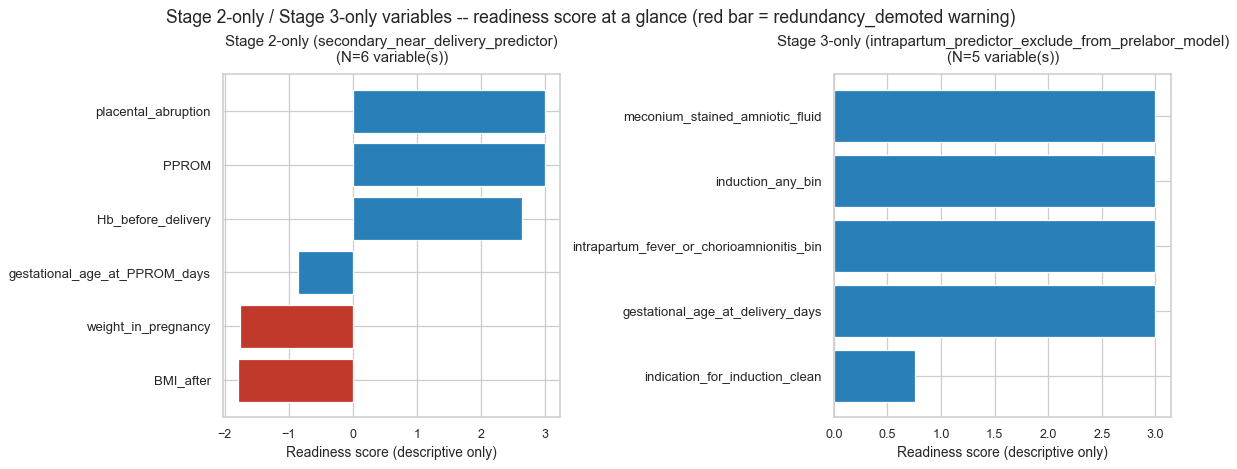

Stage 2-only: 6 variable(s) -- ['BMI_after', 'Hb_before_delivery', 'PPROM', 'gestational_age_at_PPROM_days', 'placental_abruption', 'weight_in_pregnancy']
Stage 3-only: 5 variable(s) -- ['gestational_age_at_delivery_days', 'indication_for_induction_clean', 'induction_any_bin', 'intrapartum_fever_or_chorioamnionitis_bin', 'meconium_stained_amniotic_fluid']
This chart is descriptive only -- score does not select final model variables.


In [48]:
_stage2_only_df = _diagnostic_pool[_diagnostic_pool["earliest_entry_stage"] == 2]
_stage3_only_df = _diagnostic_pool[_diagnostic_pool["earliest_entry_stage"] == 3]

if len(_stage2_only_df) == 0 and len(_stage3_only_df) == 0:
    print("No Stage 2-only or Stage 3-only variables in the current PRIMARY_COLS -- "
          "compact summary skipped.")
else:
    _max_levels = max(len(_stage2_only_df), len(_stage3_only_df), 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, max(4.5, 0.55 * _max_levels + 1.8)),
                              layout="constrained")
    for ax, _df, _label in [
        (axes[0], _stage2_only_df, "Stage 2-only (secondary_near_delivery_predictor)"),
        (axes[1], _stage3_only_df, "Stage 3-only (intrapartum_predictor_exclude_from_prelabor_model)"),
    ]:
        if len(_df) == 0:
            ax.set_visible(False)
            continue
        _plot_df = _df.sort_values("score", ascending=True)
        _colors = ["#c0392b" if d else "#2980b9" for d in _plot_df["redundancy_demoted"]]
        ax.barh(_plot_df["variable"], _plot_df["score"], color=_colors)
        ax.set_title(f"{_label}\n(N={len(_df)} variable(s))", fontsize=12, pad=10)
        ax.set_xlabel("Readiness score (descriptive only)", fontsize=11)
        ax.tick_params(axis="y", labelsize=10.5)
        ax.tick_params(axis="x", labelsize=10)
    fig.suptitle("Stage 2-only / Stage 3-only variables -- readiness score at a glance "
                 "(red bar = redundancy_demoted warning)", fontsize=14)
    plt.show()
    print(f"Stage 2-only: {len(_stage2_only_df)} variable(s) -- {sorted(_stage2_only_df['variable'].tolist())}")
    print(f"Stage 3-only: {len(_stage3_only_df)} variable(s) -- {sorted(_stage3_only_df['variable'].tolist())}")
    print("This chart is descriptive only -- score does not select final model variables.")

**Stage 2-only / Stage 3-only outcome-stratified panels:** the
readiness-score chart above shows a single descriptive score per variable, not the
actual data. The panels below show real outcome-stratified summaries for each Stage
2-only and Stage 3-only variable, by type: binary variables get a vaginal-vs-CS
positivity rate (matching Section A2.4's format), numeric variables get a
median/IQR-by-outcome summary with a Mann-Whitney test, and categorical variables get
an outcome-stratified level breakdown (matching Section A2.4's format, with the same
small-cell suppression). These are **descriptive only** -- they perform no feature
selection, and (per the A2.14/A2.15 warnings) any variable currently marked
`pending_timing_confirmation` in `modeling_clearance` remains timing-open and not
cleared for modeling regardless of what is shown here.

In [49]:
_stage_only_vars = (
    [(v, 2) for v in sorted(_stage2_only_df["variable"])]
    + [(v, 3) for v in sorted(_stage3_only_df["variable"])]
)
if not _stage_only_vars:
    print("No Stage 2-only or Stage 3-only variables -- outcome panels skipped.")
else:
    _g0_so = df_primary[df_primary[TARGET_COL] == 0]
    _g1_so = df_primary[df_primary[TARGET_COL] == 1]
    for _col, _stage in _stage_only_vars:
        if _col not in df_primary.columns:
            continue
        _vtype = infer_var_type(df_primary[_col])
        print(f"[{_col}]  (Stage {_stage}-only, type={_vtype})")
        if _vtype == "binary":
            _sub = df_primary[[_col, TARGET_COL]].dropna(subset=[_col])
            _g0s, _g1s = _sub[_sub[TARGET_COL] == 0], _sub[_sub[TARGET_COL] == 1]
            _n_pos0 = int((_g0s[_col] == 1).sum())
            _n_pos1 = int((_g1s[_col] == 1).sum())
            # Centralized binary display protection -- shared with A2.4/A2.6/A2.8/A2.9.
            _vd, _cd = share_safe.suppress_binary_target_display(
                _n_pos0, _n_pos1, len(_g0s), len(_g1s), enabled=SHARE_SAFE_MODE
            )
            _r0 = f"{100*_n_pos0/len(_g0s):.1f}%" if not isinstance(_vd, str) and len(_g0s) else (_vd if isinstance(_vd, str) else "—")
            _r1 = f"{100*_n_pos1/len(_g1s):.1f}%" if not isinstance(_cd, str) and len(_g1s) else (_cd if isinstance(_cd, str) else "—")
            _res = chi2_or_fisher(_col, df_primary, TARGET_COL)
            print(f"  N={len(_sub)}, miss={df_primary[_col].isna().sum()} | "
                  f"vaginal={_r0} (N={len(_g0s)}) | CS={_r1} (N={len(_g1s)}) | "
                  f"{_res['test']}: p={fmt_pval(_res['p_value'])}")
        elif _vtype == "numeric":
            _sub = df_primary[[_col, TARGET_COL]].dropna(subset=[_col])
            _g0s, _g1s = _sub[_sub[TARGET_COL] == 0][_col], _sub[_sub[TARGET_COL] == 1][_col]
            _pv, _eff = mannwhitney_with_effect(_g0s, _g1s)
            print(f"  N={len(_sub)}, miss={df_primary[_col].isna().sum()} | "
                  f"vaginal: {fmt_median_iqr(_g0s)} | CS: {fmt_median_iqr(_g1s)} | "
                  f"Mann-Whitney p={fmt_pval(_pv)}, |r|={fmt_effect(_eff)}")
        elif _vtype == "categorical":
            _sub = df_primary[[_col, TARGET_COL]].dropna(subset=[_col])
            _g0s, _g1s = _sub[_sub[TARGET_COL] == 0], _sub[_sub[TARGET_COL] == 1]
            _vc = _sub[_col].value_counts()
            print(f"  N={len(_sub)}, miss={df_primary[_col].isna().sum()}, "
                  f"{_sub[_col].nunique()} levels:")
            # Reconstruction-aware combination -- same rationale as A2.4's
            # categorical loop: a combined bucket with only one member (or a
            # total still <5) discloses that one rare level's exact count,
            # either directly or by subtracting the shown levels from the
            # printed N above. Fold smallest-first until the combined bucket
            # is empty or safely >=5.
            _level_totals_so = {_lv: int((_sub[_col] == _lv).sum()) for _lv in _vc.index[:10]}
            _visible_so, _below_n_so, _below_k_so = share_safe.safe_combine_rare_levels(
                _level_totals_so, threshold=5
            )
            for _lv in _vc.index[:10]:
                if _lv not in _visible_so:
                    continue
                _n_tot = _visible_so[_lv]
                _n_vag = int((_g0s[_col] == _lv).sum())
                _n_cs = int((_g1s[_col] == _lv).sum())
                # Complement-aware WITHIN THIS LEVEL (_n_vag + _n_cs ==
                # _n_tot exactly): checking against len(_g0s)/len(_g1s) (the
                # whole column's group sizes) alone is not sufficient, since
                # `total={_n_tot}` is printed on the same line -- a
                # safe-looking large _n_vag next to a safe _n_tot still
                # discloses a small _n_cs by subtraction. Checking each
                # against _n_tot (same fix as A2.4's categorical loop) makes
                # both suppress together whenever either is a protected
                # small cell.
                _vag_d = share_safe.safe_count_with_complement(_n_vag, _n_tot, enabled=SHARE_SAFE_MODE)
                _cs_d = share_safe.safe_count_with_complement(_n_cs, _n_tot, enabled=SHARE_SAFE_MODE)
                # safe_count_with_complement() and safe_pct_disclosure() detect the
                # identical suppression condition independently -- composing both
                # unconditionally previously printed a redundant, duplicated
                # suppression phrase side by side (same pattern already fixed
                # in A2.4's categorical loop). Omit the percentage
                # phrase when the count itself is already a suppression marker.
                _vag_pct_so_txt = f" ({safe_pct_disclosure(_n_vag, len(_g0s))})" if isinstance(_vag_d, (int, float)) else ""
                _cs_pct_so_txt = f" ({safe_pct_disclosure(_n_cs, len(_g1s))})" if isinstance(_cs_d, (int, float)) else ""
                print(f"    {_lv}: total={_n_tot} | vaginal={_vag_d}{_vag_pct_so_txt} | "
                      f"CS={_cs_d}{_cs_pct_so_txt}")
            if _below_k_so:
                if _below_n_so is not None and _below_n_so >= 5:
                    print(f"    [{share_safe.format_combined_levels_note(_below_k_so, _below_n_so)}]")
                else:
                    print(f"    [{_below_k_so} smaller categor{'y' if _below_k_so == 1 else 'ies'} "
                          f"combined: too few total observations to display safely, suppressed]")
            if _sub[_col].nunique() > 10:
                print(f"    ... ({_sub[_col].nunique() - 10} more levels)")
        else:
            print(f"  (type={_vtype}: no dedicated panel format -- see A2.4/A2.9 for full coverage)")
        print()
    print("These panels are descriptive only and perform no feature selection.")

[BMI_after]  (Stage 2-only, type=numeric)


  N=184, miss=247 | vaginal: 27.7 [24.8–30.9] | CS: 26.9 [24.7–30.5] | Mann-Whitney p=0.9516, |r|=0.008

[Hb_before_delivery]  (Stage 2-only, type=numeric)
  N=392, miss=39 | vaginal: 12.0 [11.3–12.8] | CS: 12.2 [11.6–12.9] | Mann-Whitney p=0.2109, |r|=0.105

[PPROM]  (Stage 2-only, type=binary)
  N=431, miss=0 | vaginal=3.0% (N=370) | CS=9.8% (N=61) | Fisher exact: p=0.0221

[gestational_age_at_PPROM_days]  (Stage 2-only, type=numeric)
  N=16, miss=415 | vaginal: 248.0 [239.8–255.8] | CS: 247.0 [235.0–257.5] | Mann-Whitney p=0.7432, |r|=0.117

[placental_abruption]  (Stage 2-only, type=binary)
  N=431, miss=0 | vaginal=<5 (suppressed) (N=370) | CS=<5 (suppressed) (N=61) | Fisher exact: p=0.0979

[weight_in_pregnancy]  (Stage 2-only, type=numeric)
  N=187, miss=244 | vaginal: 75.0 [66.5–84.0] | CS: 80.5 [65.2–85.0] | Mann-Whitney p=0.8288, |r|=0.028

[gestational_age_at_delivery_days]  (Stage 3-only, type=numeric)
  N=431, miss=0 | vaginal: 275.0 [268.0–281.0] | CS: 272.0 [264.0–281.0]

**Stage 2-only / Stage 3-only outcome-stratified graphs:** the
text panels above report the same numbers this section now also plots. Binary
variables get a grouped vaginal-vs-CS positivity-rate bar chart (matching Section A2.4's
format); numeric variables get a boxplot by outcome (no patient-level point overlay);
categorical variables get grouped/normalized within-target-group % bars by level
(matching Section A2.4's format, top levels only, rare levels suppressed). Denominators
(N per group) are shown in each panel title where safe. The same small-cell and
complementary-cell suppression rules used throughout this notebook (`share_safe`)
apply here too -- a suppressed cell renders as a **missing bar labeled "Suppressed"**,
never as a 0-height bar and never as a raw small count. A suppressed rate is unknown
to the reader, not 0%, and must never look identical to a genuine, unsuppressed 0%.
These graphs are **descriptive only**: they perform no feature selection, readiness
scoring, exclusion, or model-eligibility determination, and (per the A2.14/A2.15 warnings)
any variable currently marked `pending_timing_confirmation` in `modeling_clearance`
(Section A2.12/A2.13's live, dynamically-derived list -- never hardcoded here) remains
blocked from every model regardless of what is shown here. The
readiness-score chart earlier in this section remains a separate, purely descriptive
score summary -- it is not a substitute for these outcome-stratified graphs, and these
graphs are not a substitute for it.

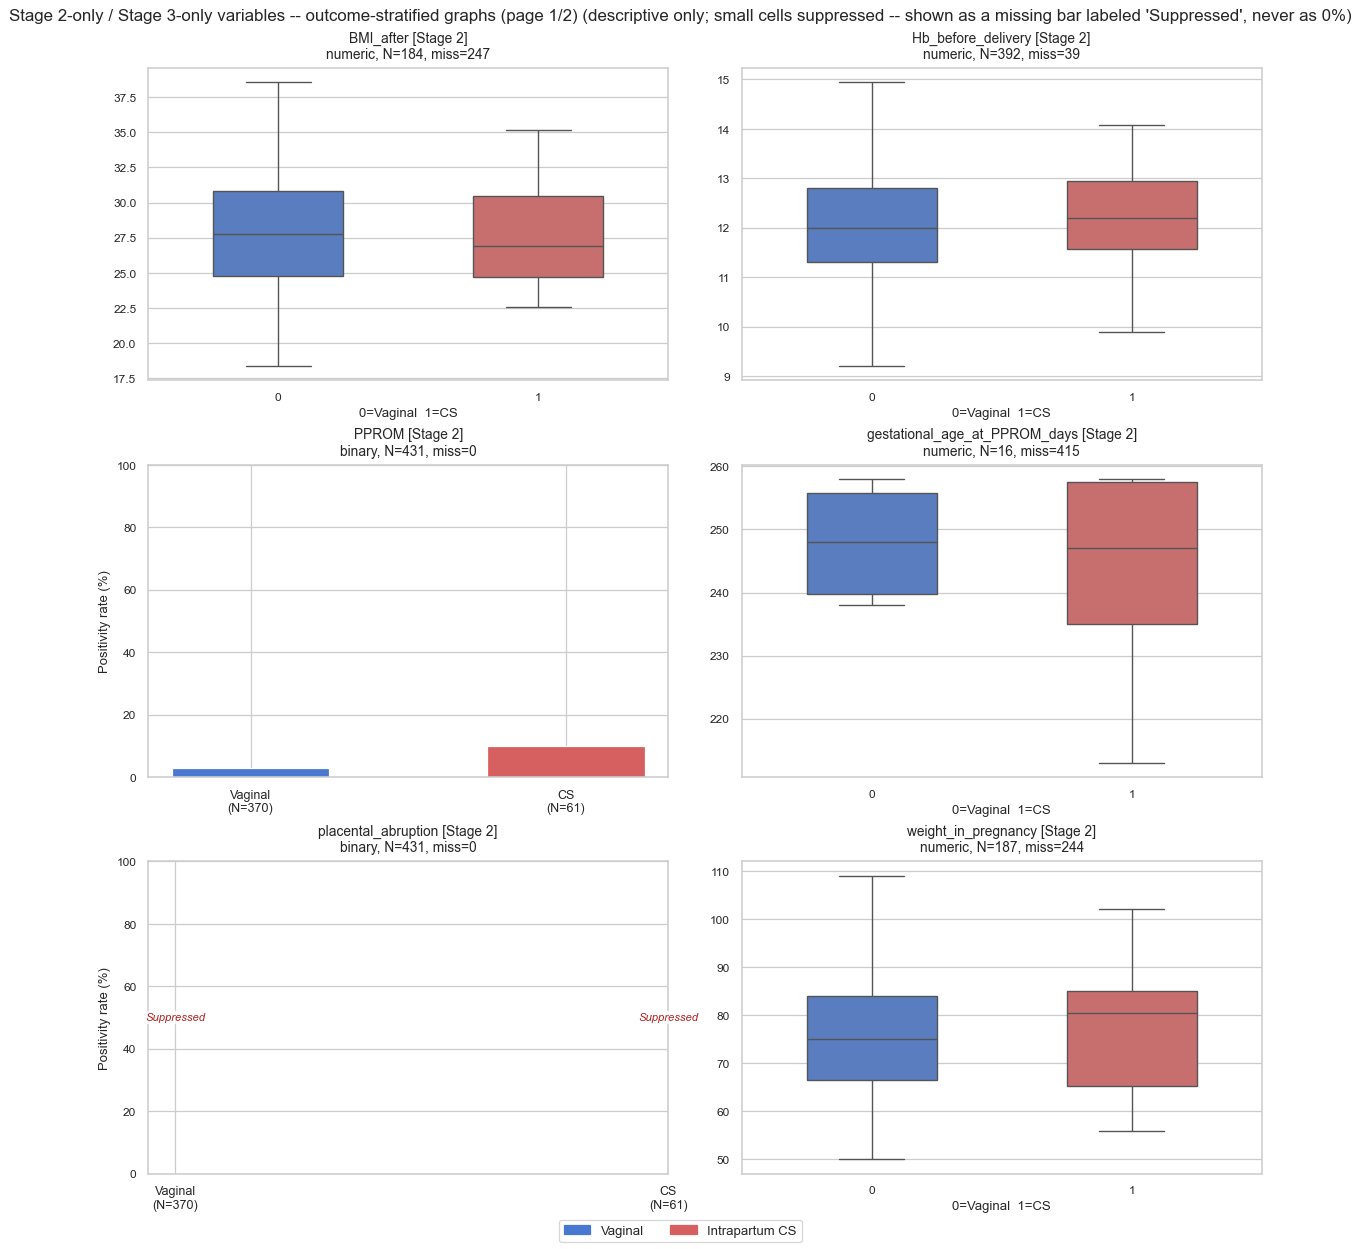

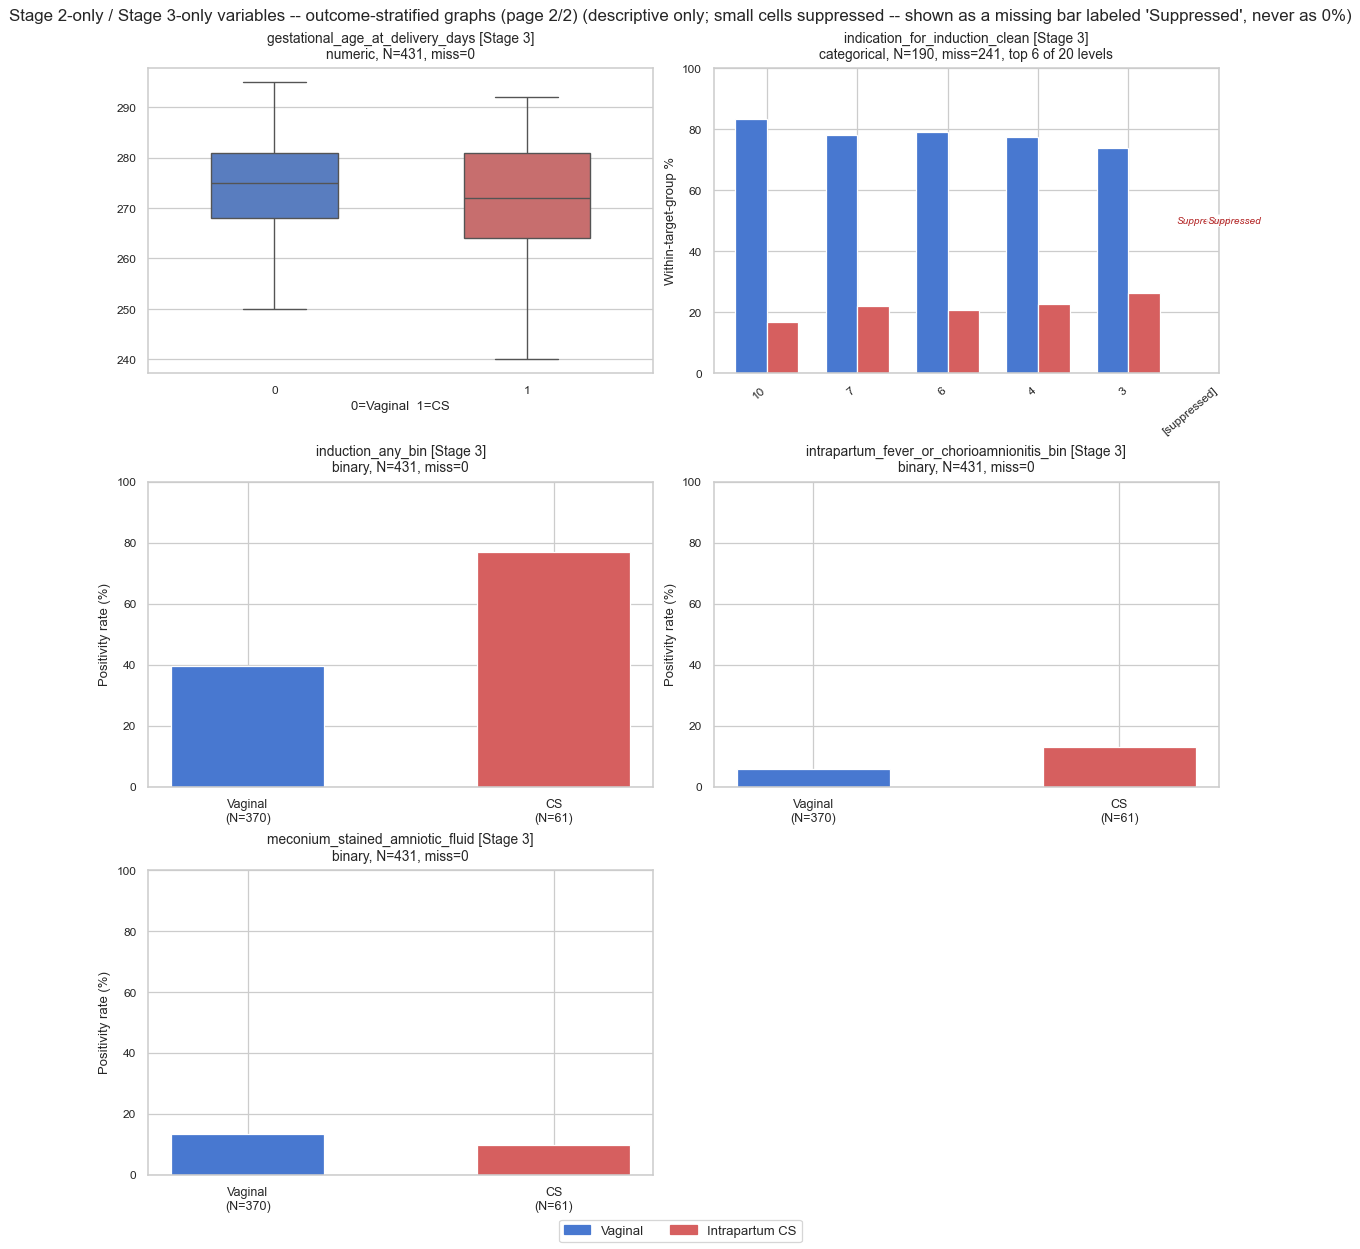

These graphs are descriptive only -- they perform no feature selection, readiness
scoring, exclusion, or model-eligibility determination. See modeling_clearance
(Section A2.12/A2.13) for which of these variables remain blocked from every model.
A suppressed rate is shown as a missing bar labeled 'Suppressed', never as 0%.


In [50]:
# Shared suppression-annotation helper: a suppressed
# rate is UNKNOWN to the reader, not 0% -- it must never be encoded as a
# numeric zero bar height, which would be indistinguishable from a genuine,
# unsuppressed 0%. A suppressed cell is instead plotted as np.nan (no bar
# rendered by matplotlib for a NaN height) with an explicit 'Suppressed'
# text annotation at that position. Raw analytical counts/percentages
# (_pct0/_pct1/_vag_pct_so/_cs_pct_so, all from share_safe) are kept fully
# separate from these display-only plotted heights.
def _so_plot_value(display_value):
    return float(display_value) if isinstance(display_value, (int, float)) else np.nan


def _so_annotate_suppressed(ax, x, y=50, fontsize=9):
    ax.text(x, y, "Suppressed", ha="center", va="center", fontsize=fontsize,
            fontstyle="italic", color="firebrick",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))


if not _stage_only_vars:
    print("No Stage 2-only or Stage 3-only variables -- outcome graphs skipped.")
else:
    # Paginated (was one tall ~10-panel figure): 2 columns x up to 3 rows
    # (6/page) keeps each page report/slide-sized instead of an unreadably
    # long single figure.
    _PAGE_SIZE_SO = 6
    _NCOLS_SO = 2
    _so_pages = [_stage_only_vars[i:i + _PAGE_SIZE_SO] for i in range(0, len(_stage_only_vars), _PAGE_SIZE_SO)]
    _n_pages_so = len(_so_pages)
    for _pg_so_i, _page_vars_so in enumerate(_so_pages, start=1):
      _n_panels_so = len(_page_vars_so)
      _nrows_so = int(np.ceil(_n_panels_so / _NCOLS_SO))
      fig, axes = plt.subplots(_nrows_so, _NCOLS_SO, figsize=(6.5 * _NCOLS_SO, 4.6 * _nrows_so),
                                layout="constrained")
      axes = np.array(axes).reshape(-1)
      for _i_so, (_col, _stage) in enumerate(_page_vars_so):
        ax = axes[_i_so]
        if _col not in df_primary.columns:
            ax.set_visible(False)
            continue
        _vtype = infer_var_type(df_primary[_col])
        _sub = df_primary[[_col, TARGET_COL]].dropna(subset=[_col])
        _n_sub = len(_sub)
        _miss_n = int(df_primary[_col].isna().sum())
        # Direct indexing (not .get(_col, "cleared")) is deliberate -- see
        # MODELING_CLEARANCE_MAP's fail-loud coverage assertions in Part 1.
        _clearance_so = MODELING_CLEARANCE_MAP[_col]
        _pending_tag = "  [pending clearance]" if _clearance_so == "pending_timing_confirmation" else ""

        if _vtype == "binary":
            # Raw counts/percentages kept separate from the suppressed display
            # values plotted below (share_safe convention used throughout).
            _g0s = _sub[_sub[TARGET_COL] == 0]
            _g1s = _sub[_sub[TARGET_COL] == 1]
            _n_pos0 = int((_g0s[_col] == 1).sum())
            _n_pos1 = int((_g1s[_col] == 1).sum())
            _pct0 = share_safe.safe_pct_with_denominator(_n_pos0, len(_g0s), enabled=SHARE_SAFE_MODE)[0]
            _pct1 = share_safe.safe_pct_with_denominator(_n_pos1, len(_g1s), enabled=SHARE_SAFE_MODE)[0]
            _plot0 = _so_plot_value(_pct0)
            _plot1 = _so_plot_value(_pct1)
            ax.bar([0, 1], [_plot0, _plot1], width=0.5, color=[C0, C1])
            for _xpos, _pv in [(0, _plot0), (1, _plot1)]:
                if np.isnan(_pv):
                    _so_annotate_suppressed(ax, _xpos)
            ax.set_ylim(0, 100)
            ax.set_xticks([0, 1])
            ax.set_xticklabels([f"Vaginal\n(N={len(_g0s)})", f"CS\n(N={len(_g1s)})"], fontsize=10)
            ax.tick_params(axis="y", labelsize=9.5)
            ax.set_ylabel("Positivity rate (%)", fontsize=10.5)
            ax.set_title(f"{_col} [Stage {_stage}]{_pending_tag}\n"
                         f"binary, N={_n_sub}, miss={_miss_n}", fontsize=11, pad=8)

        elif _vtype == "numeric":
            # Boxplot by outcome only -- no patient-level point overlay.
            # showfliers=False: sns.boxplot's default
            # showfliers=True renders individual outlier points as markers,
            # which is itself a patient-level point overlay -- exactly what
            # this panel documents that it does not have. No stripplot/
            # swarmplot/scatter layer is added either.
            _sub_p = _sub.copy()
            _sub_p[TARGET_COL] = _sub_p[TARGET_COL].astype(str)
            sns.boxplot(data=_sub_p, x=TARGET_COL, y=_col, hue=TARGET_COL, ax=ax,
                        palette={"0": C0, "1": C1}, width=0.5, linewidth=1.1,
                        legend=False, showfliers=False)
            ax.set_xlabel("0=Vaginal  1=CS", fontsize=10.5)
            ax.set_ylabel("")
            ax.tick_params(labelsize=9.5)
            ax.set_title(f"{_col} [Stage {_stage}]{_pending_tag}\n"
                         f"numeric, N={_n_sub}, miss={_miss_n}", fontsize=11, pad=8)

        elif _vtype == "categorical":
            _g0s = _sub[_sub[TARGET_COL] == 0]
            _g1s = _sub[_sub[TARGET_COL] == 1]
            _g0s_n, _g1s_n = len(_g0s), len(_g1s)
            _n_levels_so = _sub[_col].nunique()
            _top_levels_so = _sub[_col].value_counts().index[:6]
            _ct_so = pd.crosstab(_sub[_col], _sub[TARGET_COL]).reindex(_top_levels_so)
            _vag_counts_so = _ct_so.get(0, pd.Series(0, index=_ct_so.index))
            _cs_counts_so = _ct_so.get(1, pd.Series(0, index=_ct_so.index))
            # Checking each side's percentage only against the GLOBAL group
            # size (_g0s_n/_g1s_n) is not sufficient -- this notebook's own
            # text panel for these same Stage-2/3-only variables (immediately
            # above/below this graph) prints each level's exact total
            # (n_tot). A vaginal rate shown unsuppressed here, combined with
            # that already-visible exact total, discloses a small CS count by
            # subtraction even though neither this graph's own denominator
            # check nor the text panel's CS cell alone would flag it.
            # Checking against each level's own total (matching the text
            # panel) closes this.
            _n_tot_so = _vag_counts_so + _cs_counts_so
            _vag_pct_so = [
                share_safe.safe_pct_with_denominator(int(n), int(t), enabled=SHARE_SAFE_MODE)[0]
                for n, t in zip(_vag_counts_so, _n_tot_so)
            ]
            _cs_pct_so = [
                share_safe.safe_pct_with_denominator(int(n), int(t), enabled=SHARE_SAFE_MODE)[0]
                for n, t in zip(_cs_counts_so, _n_tot_so)
            ]
            # Suppressed (string) cells plot as np.nan (no bar rendered), with
            # an explicit 'Suppressed' annotation -- never a 0-height bar, and
            # never the raw small count/percentage.
            _vag_plot_so = [_so_plot_value(v) for v in _vag_pct_so]
            _cs_plot_so = [_so_plot_value(v) for v in _cs_pct_so]
            _x_so = range(len(_ct_so))
            _w_so = 0.35
            ax.bar([j - _w_so / 2 for j in _x_so], _vag_plot_so, _w_so, color=C0)
            ax.bar([j + _w_so / 2 for j in _x_so], _cs_plot_so, _w_so, color=C1)
            for _j_bar, (_vv, _cv) in enumerate(zip(_vag_plot_so, _cs_plot_so)):
                if np.isnan(_vv):
                    _so_annotate_suppressed(ax, _j_bar - _w_so / 2, fontsize=8)
                if np.isnan(_cv):
                    _so_annotate_suppressed(ax, _j_bar + _w_so / 2, fontsize=8)
            ax.set_ylim(0, 100)
            # A level suppressed on BOTH sides never shows its real category
            # name either (matching A2.4's categorical-plot rule) --
            # a bar next to a real rare-category label can still disclose
            # "this category exists" in a small cohort. Checked against the
            # raw display values (_vag_pct_so/_cs_pct_so), not the plotted
            # np.nan heights, so this classification is unambiguous.
            _xtick_labels_so = [
                str(_lv)[:16] if (isinstance(_vp, (int, float)) or isinstance(_cp, (int, float)))
                else "[suppressed]"
                for _lv, _vp, _cp in zip(_ct_so.index, _vag_pct_so, _cs_pct_so)
            ]
            ax.set_xticks(list(_x_so))
            ax.set_xticklabels(_xtick_labels_so, rotation=40, ha="right", fontsize=9.5)
            ax.tick_params(axis="y", labelsize=9.5)
            ax.set_ylabel("Within-target-group %", fontsize=10.5)
            _level_note = f", top {len(_top_levels_so)} of {_n_levels_so} levels" if _n_levels_so > 6 else ""
            ax.set_title(f"{_col} [Stage {_stage}]{_pending_tag}\n"
                         f"categorical, N={_n_sub}, miss={_miss_n}{_level_note}", fontsize=11, pad=8)

        else:
            ax.axis("off")
            ax.set_title(f"{_col} [Stage {_stage}]\n(type={_vtype}: no graph format -- see text panel above)",
                         fontsize=11)

      for _j_so in range(_n_panels_so, len(axes)):
          axes[_j_so].set_visible(False)

      fig.suptitle(f"Stage 2-only / Stage 3-only variables -- outcome-stratified graphs "
                   f"(page {_pg_so_i}/{_n_pages_so}) (descriptive only; small cells "
                   f"suppressed -- shown as a missing bar labeled 'Suppressed', never as 0%)",
                   fontsize=13.5)
      # Legend placed BELOW the grid (not at the top) so it never competes with
      # fig.suptitle for the same reserved space -- an earlier "outside upper
      # center" placement visually collided with the suptitle text.
      _legend_handles = [
          plt.Rectangle((0, 0), 1, 1, color=C0), plt.Rectangle((0, 0), 1, 1, color=C1),
      ]
      fig.legend(_legend_handles, ["Vaginal", "Intrapartum CS"], loc="outside lower center",
                 ncol=2, fontsize=10.5)
      plt.show()
    print("These graphs are descriptive only -- they perform no feature selection, readiness")
    print("scoring, exclusion, or model-eligibility determination. See modeling_clearance")
    print("(Section A2.12/A2.13) for which of these variables remain blocked from every model.")
    print("A suppressed rate is shown as a missing bar labeled 'Suppressed', never as 0%.")

## Section A2.14 — Clinical Assumptions and Modeling Considerations

**Purpose:** State the timing/eligibility assumptions underlying the primary
predictor pool, and the remaining clinical or modeling considerations relevant to
their use, so a reader can evaluate them directly.

**What this contains:**
- A brief summary of the timing/eligibility assumptions already reflected in the
  current predictor classification
- Remaining clinical and modeling considerations for a small number of
  sparse-event or overlapping-representation variables, each with its analytical
  consequence

**What this does NOT do:**
- This section does not itself reclassify any variable or run statistical tests

**Output:** Printed summary of the timing/eligibility assumptions and
remaining clinical/modeling considerations

In [51]:
# ── Clinical assumption tracking ──────────────────────────────────────────
# Each entry: variable | data_issue | clinical_question | current_status
# current_status/decision are retained internally to drive the live-metadata
# guard and the resolved/open counts below; the printed narrative further
# down reframes this as assumptions and their analytical consequences rather
# than a decision-tracking log.

CLINICAL_DECISIONS = [
    {
        "variable": "S_P_CS",
        "data_issue": (
            "A small number of intrapartum-CS-group events among prior-CS "
            "patients (below the project's n<5 disclosure threshold); near "
            "the point of complete separation."
        ),
        "clinical_question": (
            "Prior-CS patients attempting a trial of labor rarely have an "
            "intrapartum CS in this cohort for a clinically expected reason. "
            "The variable is retained despite its small event count; how to "
            "handle that sparsity (sparse-event-aware / penalized estimation, "
            "cross-validated stability assessment) is a modeling-stage "
            "consideration, not decided by a full-dataset p-value."
        ),
        "current_status": "RESOLVED",
        "decision": (
            "Retained as a predictive candidate. Rarity / possible "
            "near-separation is a modeling-stage concern (sparse-event-aware "
            "handling / penalization, cross-validated stability assessment "
            "during modeling), not a reason for pre-model exclusion -- and is "
            "not decided by this variable's full-dataset univariate p-value. "
            "Final retention is determined during modeling."
        ),
    },
    {
        "variable": "cs_scar_endometriosis",
        "data_issue": (
            "Exactly 5 intrapartum-CS-group events -- at the sparsity threshold "
            "used elsewhere in this notebook. Effect size 0.134 (meaningful)."
        ),
        "clinical_question": (
            "This cohort-specific variable's meaningful effect size (0.134) "
            "is retained despite its borderline event sparsity; weighing that "
            "sparsity against its effect size during model specification "
            "(sparse-event-aware handling, cross-validated stability "
            "assessment) is a modeling-stage consideration, not decided by a "
            "full-dataset p-value."
        ),
        "current_status": "RESOLVED",
        "decision": (
            "Retained as a predictive candidate. Clinically specific "
            "to endometriosis and available before the outcome; sparse target-"
            "event counts are a modeling-stage concern, not a pre-model "
            "exclusion reason, and are not decided by this variable's "
            "full-dataset univariate p-value. Final retention is determined "
            "during modeling."
        ),
    },
    {
        "variable": "superficial_endometriosis",
        "data_issue": (
            "Not applicable -- this variable is clinically_redundant_exclude "
            "and is not in PRIMARY_COLS at any stage, so no "
            "target association or effect size for it is computed or shown "
            "anywhere in this notebook."
        ),
        "clinical_question": (
            "Whether superficial_endometriosis or peritoneal_endometriosis "
            "should represent this overlapping phenotype information in "
            "modeling, given the two variables' imperfect empirical "
            "agreement (~63.2%)."
        ),
        "current_status": "RESOLVED",
        "decision": (
            "Clinical experts selected peritoneal_endometriosis as the "
            "canonical modeled representation of this overlapping phenotype "
            "information, despite the two variables' imperfect empirical "
            "agreement (~63.2%) -- not because they were found statistically "
            "equivalent, and not a merge of the two columns. "
            "superficial_endometriosis is retained in the dataset for audit, "
            "cohort-rule derivation, and outcome-independent sensitivity "
            "analysis, but is excluded from every prediction stage and "
            "carries no modeling recommendation."
        ),
    },
    {
        "variable": "oligohydramnios",
        "data_issue": "6 intrapartum-CS-group events; effect 0.083.",
        "clinical_question": (
            "Whether this is consistently documented from antepartum "
            "ultrasound (pre-labor predictor) or can also be an intrapartum "
            "finding (potential leakage)."
        ),
        "current_status": "RESOLVED",
        "decision": (
            "Assessed by ultrasound during pregnancy, consistently with "
            "polyhydramnios, and therefore available before delivery. "
            "Classified predictor_allowed; included in the primary pre-labor pool."
        ),
    },
    {
        # Near-delivery horizon (secondary_near_delivery_predictor) is correct.
        "variable": "placental_abruption",
        "data_issue": "A small number of intrapartum-CS-group events, below the project's n<5 disclosure threshold (too_sparse). Effect 0.099. Classified secondary_near_delivery_predictor (Stage 2+).",
        "clinical_question": (
            "Whether this is always documented antepartum/pre-CS-decision, or "
            "can be coded from intrapartum/intraoperative findings."
        ),
        "current_status": "RESOLVED",
        "decision": (
            "Near-delivery horizon confirmed correct. Classified "
            "secondary_near_delivery_predictor; eligible from "
            "Stage 2 (pre-labor + near-delivery) onward."
        ),
    },
    {
        # This variable represents information available during labor and
        # before the cesarean decision. The actual modeling-relevant variable is the
        # combined intrapartum_fever_or_chorioamnionitis_bin indicator
        # (chorioamnionitis itself is source_or_text_audit_exclude, not a
        # modeling candidate at any stage) -- referenced directly here.
        "variable": "intrapartum_fever_or_chorioamnionitis_bin",
        "data_issue": (
            "Combines information from chorioamnionitis and intrapartum_fever. "
            "Classified intrapartum_predictor_exclude_from_prelabor_model "
            "(Stage 3 only)."
        ),
        "clinical_question": (
            "Whether this combined indicator is diagnosed/documented before "
            "the decision to perform a CS in every record."
        ),
        "current_status": "RESOLVED",
        "decision": (
            "Available during labor "
            "and before the cesarean decision -- intrapartum "
            "timing. Eligible only for Stage 3 (an intrapartum "
            "risk-update model, not an early/prelabor model), excluded from "
            "Stage 1 and Stage 2."
        ),
    },
    {
        # This variable represents information available during labor and
        # before the cesarean decision.
        "variable": "meconium_stained_amniotic_fluid",
        "data_issue": "Typically an intrapartum finding. Classified intrapartum_predictor_exclude_from_prelabor_model (Stage 3 only).",
        "clinical_question": (
            "Whether this is recorded before the CS decision in every case, "
            "or only documented at delivery."
        ),
        "current_status": "RESOLVED",
        "decision": (
            "Available during labor "
            "and before the cesarean decision -- intrapartum "
            "timing. Eligible only for Stage 3 (an intrapartum "
            "risk-update model, not an early/prelabor model), excluded from "
            "Stage 1 and Stage 2."
        ),
    },
    {
        "variable": "Hb_before_delivery",
        "data_issue": (
            "Timing is heterogeneous (pregnancy or day of admission) but "
            "confirmed never taken during labor."
        ),
        "clinical_question": (
            "Whether this is measured with consistent enough timing across "
            "the cohort to serve as a pre-labor predictor."
        ),
        "current_status": "RESOLVED",
        "decision": (
            "Always available before any intrapartum event, but timing is "
            "heterogeneous across the pregnancy/admission window. Classified "
            "secondary_near_delivery_predictor; analyzed separately from the "
            "primary pool for that reason, not on timing/leakage grounds."
        ),
    },
    {
        "variable": (
            "Hypertensive pregnancy disorder subcategories "
            "(pregnancy_related_hypertensive_disorder / any_PET / PIH / "
            "mild_PET / severe_PET / SIPET)"
        ),
        "data_issue": (
            "Each subcategory has a small number of intrapartum-CS-group "
            "events (below the project's n<5 disclosure threshold); all are "
            "sparse individually."
        ),
        "clinical_question": (
            "Whether these subcategories represent clinically distinct risk "
            "profiles (supporting separate variables) or a shared underlying "
            "process (supporting a single composite indicator) is a clinical "
            "judgment this EDA does not resolve."
        ),
        "current_status": "RESOLVED",
        "decision": (
            "derived_hypertension_pih_pet_spectrum "
            "is a 3-level grouped/composite representation "
            "(no_hypertensive_disorder / pih_gestational_htn / preeclampsia_spectrum "
            "+ explicit missing/unresolved state), defined from predefined clinical/source "
            "semantics, not target association. The individual "
            "subcategory variables are retained ungrouped as well -- they carry "
            "independent clinical value (e.g. distinguishing PIH from preeclampsia "
            "severity) that the composite intentionally coarsens -- registered "
            "together in DERIVED_REDUNDANCY_GROUPS "
            "('hypertension_pih_pet_spectrum_representation', representative=None) "
            "so all members are flagged for review rather than one being "
            "auto-demoted. Sparse individual-subcategory event counts remain a "
            "modeling-stage (Modeling D) concern, not a pre-model exclusion reason."
        ),
    },
]

# ── Live-metadata guard ────────────────────────────────────────────────────
# CLINICAL_DECISIONS above is a hardcoded snapshot, not derived from live
# metadata at runtime. Unlike the classification-count validation gate in
# Part 1 (which hard-fails on drift), nothing previously tied a RESOLVED
# entry's claimed classification to the live variable_classification_minimal.csv,
# so this registry could silently go stale as the project evolves. This guard
# asserts that each RESOLVED entry's variable still exists and still carries
# the classification the resolution implies, using the same
# PENDING_TIMING_CONFIRMATION_COLS / INTRAPARTUM_PREDICTOR_EXCLUDE_COLS /
# SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS lists already built from live
# metadata in Part 1. Does not alter any clinical decision, status, or
# classification -- read-only cross-check only.
# chorioamnionitis/meconium_stained_amniotic_fluid/
# placental_abruption were removed from this dict when their CLINICAL_
# DECISIONS entries were OPEN (this RESOLVED-only guard skips non-RESOLVED
# entries, so no mapping was needed then).
# all three RESOLVED again -- re-registered below
# with their live-metadata expectations, meconium_stained_amniotic_fluid and
# intrapartum_fever_or_chorioamnionitis_bin at intrapartum_predictor_exclude_
# from_prelabor_model (Stage 3 only) and placental_abruption at
# secondary_near_delivery_predictor (Stage 2+, corrected same day -- its
# near-delivery horizon was already correct).
_RESOLVED_EXPECTED_GROUP = {
    "oligohydramnios": (
        "predictor_allowed",
        PREDICTOR_ALLOWED_COLS,
    ),
    "S_P_CS": (
        "predictor_allowed",
        PREDICTOR_ALLOWED_COLS,
    ),
    "cs_scar_endometriosis": (
        "predictor_allowed",
        PREDICTOR_ALLOWED_COLS,
    ),
    "Hb_before_delivery": (
        "secondary_near_delivery_predictor",
        SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS,
    ),
    "placental_abruption": (
        "secondary_near_delivery_predictor",
        SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS,
    ),
    "meconium_stained_amniotic_fluid": (
        "intrapartum_predictor_exclude_from_prelabor_model",
        INTRAPARTUM_PREDICTOR_EXCLUDE_COLS,
    ),
    "intrapartum_fever_or_chorioamnionitis_bin": (
        "intrapartum_predictor_exclude_from_prelabor_model",
        INTRAPARTUM_PREDICTOR_EXCLUDE_COLS,
    ),
}
_registry_guard_errors = []
for _d in CLINICAL_DECISIONS:
    if _d["current_status"] != "RESOLVED":
        continue
    _var = _d["variable"]
    if _var not in _RESOLVED_EXPECTED_GROUP:
        continue  # no live-metadata mapping registered for this RESOLVED entry
    _expected_label, _expected_cols = _RESOLVED_EXPECTED_GROUP[_var]
    if _var not in df.columns:
        _registry_guard_errors.append(
            f"{_var}: RESOLVED entry references a variable no "
            "longer present in the current dataset"
        )
    elif _var not in _expected_cols:
        _registry_guard_errors.append(
            f"{_var}: RESOLVED entry expects classification "
            f"'{_expected_label}', but the live classification CSV no longer "
            "places it there -- entry may be stale and requires review"
        )
if _registry_guard_errors:
    raise ValueError(
        "Clinical assumption tracking (A2.14) is out of sync with live "
        "classification metadata: " + "; ".join(_registry_guard_errors)
    )
print(f"  Assumption tracking cross-checked against live classification "
      f"metadata: {len(_RESOLVED_EXPECTED_GROUP)} resolved entries checked, "
      "all consistent.")

# cross-check CLINICAL_DECISIONS' current_status against
# TIMING_REVIEW_STATUS (Part 1), the single canonical registry A2.12 reads
# directly. This is the guard that makes TIMING_REVIEW_STATUS/CLINICAL_
# DECISIONS "one canonical registry" in practice rather than two
# independently hand-maintained lists that can silently drift apart again --
# any mismatch here fails loudly instead of quietly going stale.
# Most CLINICAL_DECISIONS entries' "variable" field is itself the actual
# column name; the one combined-description entry (hypertensive disorder
# subcategories) is expanded to its constituent columns explicitly below.
_decision_entry_columns = {
    "Hypertensive pregnancy disorder subcategories "
    "(pregnancy_related_hypertensive_disorder / any_PET / PIH / "
    "mild_PET / severe_PET / SIPET)": [
        "pregnancy_related_hypertensive_disorder", "any_PET", "PIH",
        "mild_PET", "severe_PET", "SIPET",
    ],
}
_timing_sync_errors = []
_timing_checked_cols = set()
for _d in CLINICAL_DECISIONS:
    _cols_for_entry = _decision_entry_columns.get(_d["variable"], [_d["variable"]])
    for _c in _cols_for_entry:
        if _c not in TIMING_REVIEW_STATUS:
            continue  # not a variable TIMING_REVIEW_STATUS tracks (e.g. superficial_endometriosis)
        _timing_checked_cols.add(_c)
        if TIMING_REVIEW_STATUS[_c] != _d["current_status"]:
            _timing_sync_errors.append(
                f"{_c}: TIMING_REVIEW_STATUS says '{TIMING_REVIEW_STATUS[_c]}' but "
                f"CLINICAL_DECISIONS says '{_d['current_status']}'"
            )
_timing_missing_cols = set(TIMING_REVIEW_STATUS) - _timing_checked_cols
if _timing_missing_cols:
    _timing_sync_errors.append(
        f"TIMING_REVIEW_STATUS tracks column(s) with no matching CLINICAL_DECISIONS "
        f"entry: {sorted(_timing_missing_cols)}"
    )
if _timing_sync_errors:
    raise ValueError(
        "TIMING_REVIEW_STATUS (Part 1) and CLINICAL_DECISIONS (A2.14) have drifted "
        "out of sync -- update both together: " + "; ".join(_timing_sync_errors)
    )
print(f"  TIMING_REVIEW_STATUS cross-checked against CLINICAL_DECISIONS: "
      f"{len(_timing_checked_cols)} column(s) consistent.")

# Narrow, deterministic re-derivation of the one hardcoded CS-group event
# count among the resolved entries (oligohydramnios). Descriptive only -- a
# drifted narrative count does not itself indicate a classification or
# safety problem, so this warns rather than blocks.
if "oligohydramnios" in df.columns and TARGET_COL in df.columns:
    _oligo_cs_events = int((df.loc[df[TARGET_COL] == 1, "oligohydramnios"] == 1).sum())
    if _oligo_cs_events != 6:
        print(f"  WARNING: the oligohydramnios timing assumption above states 6 "
              f"CS-group events; live dataset currently shows {_oligo_cs_events}. "
              "Narrative text may need updating (not blocking).")
    else:
        print(f"  oligohydramnios event count re-derived from live data: "
              f"{_oligo_cs_events} CS-group events -- matches the assumption text above.")

# Same narrow, deterministic re-derivation for cs_scar_endometriosis's two
# hardcoded narrative numbers (event count + effect size) -- previously only
# oligohydramnios had this guard, leaving this entry's numbers unprotected
# against future cohort drift even though they are correct today. Warns
# (does not block) on drift, matching the oligohydramnios pattern; a small
# tolerance on the effect size avoids a hard failure on harmless display
# rounding.
if "cs_scar_endometriosis" in df.columns and TARGET_COL in df.columns:
    _cs_scar_cs_events = int((df.loc[df[TARGET_COL] == 1, "cs_scar_endometriosis"] == 1).sum())
    _cs_scar_drift = []
    if _cs_scar_cs_events != 5:
        _cs_scar_drift.append(
            f"CS-group events: narrative states 5, live dataset currently shows {_cs_scar_cs_events}"
        )
    _cs_scar_eff = None
    if "assoc_df" in dir():
        _cs_scar_row = assoc_df[assoc_df["variable"] == "cs_scar_endometriosis"]
        if len(_cs_scar_row) and pd.notna(_cs_scar_row.iloc[0]["effect_size"]):
            _cs_scar_eff = float(_cs_scar_row.iloc[0]["effect_size"])
            if abs(_cs_scar_eff - 0.134) > 0.01:  # tolerate harmless display rounding
                _cs_scar_drift.append(
                    f"effect size: narrative states ~0.134, live dataset currently shows {_cs_scar_eff:.3f}"
                )
    if _cs_scar_drift:
        print(f"  WARNING: the cs_scar_endometriosis timing assumption above may be stale -- "
              + "; ".join(_cs_scar_drift) + ". Narrative text may need updating (not blocking).")
    else:
        print(f"  cs_scar_endometriosis event count/effect size re-derived from live data: "
              f"{_cs_scar_cs_events} CS-group events"
              + (f", effect={_cs_scar_eff:.3f}" if _cs_scar_eff is not None else "")
              + " -- matches the assumption text above.")

print("=" * 70)
print("TIMING AND ELIGIBILITY ASSUMPTIONS")
print("=" * 70)
print()
for d in CLINICAL_DECISIONS:
    if d["current_status"] != "RESOLVED":
        continue
    print(f"[{d['variable']}]")
    print(f"  Assumption : {d['clinical_question']}")
    print(f"  Consequence: {d['decision']}")
    print()

print("=" * 70)
print("CLINICAL AND MODELING CONSIDERATIONS")
print("=" * 70)
print()
print("The following variables are retained in the primary predictor pool but")
print("warrant specific care during model specification -- none require a further")
print("clinical decision before EDA can proceed, and none are excluded here.")
print()
for d in CLINICAL_DECISIONS:
    if d["current_status"] != "OPEN":
        continue
    print(f"[{d['variable']}]")
    print(f"  Data context: {d['data_issue']}")
    print(f"  Consideration: {d['clinical_question']}")
    print()

print("Analytical consequence: coefficient estimates for the sparse-event variables")
print("(S_P_CS, cs_scar_endometriosis) would likely be unstable under ordinary")
print("unpenalized logistic regression; a penalized or bias-reduced (Firth) estimation")
print("approach is preferable if either is retained in a multivariable model (Section")
print("A2.8). The hypertensive-disorder subcategories overlap in representation; whether")
print("to model them separately or as a composite indicator should be assessed during")
print("model specification, informed by clinical input on the categories' distinctness.")

  Assumption tracking cross-checked against live classification metadata: 7 resolved entries checked, all consistent.
  TIMING_REVIEW_STATUS cross-checked against CLINICAL_DECISIONS: 13 column(s) consistent.
  oligohydramnios event count re-derived from live data: 6 CS-group events -- matches the assumption text above.
  cs_scar_endometriosis event count/effect size re-derived from live data: 5 CS-group events, effect=0.134 -- matches the assumption text above.
TIMING AND ELIGIBILITY ASSUMPTIONS

[S_P_CS]
  Assumption : Prior-CS patients attempting a trial of labor rarely have an intrapartum CS in this cohort for a clinically expected reason. The variable is retained despite its small event count; how to handle that sparsity (sparse-event-aware / penalized estimation, cross-validated stability assessment) is a modeling-stage consideration, not decided by a full-dataset p-value.
  Consequence: Retained as a predictive candidate. Rarity / possible near-separation is a modeling-stage conc

In [52]:
# Variables pending source/coding review would be excluded from statistical
# testing on source-ambiguity grounds; membership is read from the current
# variable classification, not a fixed list.
if not MANUAL_REVIEW_PENDING_COLS:
    print("No variables remain classified as pending source/coding review.")
else:
    print("Variables pending source/coding review:")
    print()
    for col in MANUAL_REVIEW_PENDING_COLS:
        if col not in df.columns:
            print(f"  {col}: NOT IN FILE")
            continue
        n_avail  = int(df[col].notna().sum())
        miss_pct = round(df[col].isna().mean() * 100, 1)
        # Small-cell disclosure guard: only report a top value if its count is
        # >=5 (project convention), else omit rather than expose it.
        top_vals = {str(k): int(v) for k, v in df[col].value_counts(dropna=True).head(3).items() if v >= 5}
        print(f"  {col}")
        print(f"    Available: {n_avail}/{len(df)} ({miss_pct}% missing)")
        print(f"    Top values (n>=5 only): {top_vals}")
        print(f"    Block reason: source ambiguity (prior surgery vs current CS findings)")
        print()

No variables remain classified as pending source/coding review.


## Section A2.15 — EDA Conclusions and Modeling Handoff

**Purpose:** Summarize this EDA stage's findings and state the explicit
methodological requirements for any subsequent modeling stage.

**What this documents:**
- Cohort and target size; primary predictor coverage
- Major data-quality findings: missingness (including structural missingness),
  sparsity, and separation limitations
- Exploratory univariable association findings (explicitly labeled exploratory)
- Redundancy findings
- Variables unavailable at the intended pre-labor prediction time
- Modeling implications for any subsequent stage

**What this does NOT do:**
- No variables are removed or reclassified here
- Does not assign a final feature set: whole-cohort univariate screening in this
  notebook is not a feature-selection rule (see the modeling-implications
  statement below)

**Output:** Printed EDA findings summary and modeling handoff

In [53]:
# ── Findings summary (data-quality + redundancy) ──────────────────────────
# Purely descriptive aggregation of diagnostics already computed in A2.7-A2.11 --
# no owner/status/workflow fields; every finding here is a description of the
# data, not a proposed or recorded action.
print("=" * 70)
print("DATA-QUALITY AND REDUNDANCY FINDINGS SUMMARY")
print("=" * 70)
print()

if "miss_df" in dir():
    _high_miss = miss_df[miss_df["missing_%"] > 30]
    _struct_miss = miss_df[miss_df["structural_nan"]]
    print(f"Missingness: {len(_high_miss)} primary predictor(s) with >30% full-cohort "
          f"missingness; {len(_struct_miss)} carry a confirmed structural-missingness flag "
          f"(a deterministic non-applicability component outside their defined subgroup; "
          f"some may also retain genuine missingness within the applicable subgroup -- see "
          f"A2.7 for the separated quantities, not a blanket 'no data-quality gap' claim).")

if "sparse_df" in dir():
    _sep_n = int(sparse_df["separation_risk"].sum())
    _sparse_n = int(sparse_df["too_sparse"].sum())
    print(f"Sparsity/separation: {_sep_n} variable(s) show complete/quasi-complete "
          f"separation, {_sparse_n} are too sparse (<5 in some target-by-level cell) -- "
          f"both are fitting-stability diagnostics for ordinary unpenalized logistic "
          f"regression specifically (Section A2.8), not automatic exclusions.")

if "_high_corr_pairs" in dir() and _high_corr_pairs:
    print(f"Redundancy (numeric-numeric): {len(_high_corr_pairs)} pair(s) with "
          f"|Spearman rho|>=0.7: "
          f"{[(p['var1'], p['var2']) for p in _high_corr_pairs]}.")
if "_high_v_pairs" in dir() and _high_v_pairs:
    print(f"Redundancy (categorical-categorical): {len(_high_v_pairs)} pair(s) with "
          f"Cramer's V>=0.5: {[(p['var1'], p['var2']) for p in _high_v_pairs]}.")

if "outlier_df" in dir() and len(outlier_df):
    print(f"Outliers: {len(outlier_df)} numeric predictor(s) have IQR-flagged extreme "
          f"values (Section A2.11, target-blind screening); each is labeled "
          f"'extreme_value_review_item', not an error determination.")

print()
print(f"Leakage/post-outcome safety: {len(LEAKAGE_EXCLUDE_COLS)} leakage_exclude and "
      f"{len(INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS)} intrapartum_or_post_delivery_exclude "
      f"column(s) are confirmed absent from PRIMARY_COLS (enforced by the Section A2.2 scope gate).")

DATA-QUALITY AND REDUNDANCY FINDINGS SUMMARY

Missingness: 19 primary predictor(s) with >30% full-cohort missingness; 14 carry a confirmed structural-missingness flag (a deterministic non-applicability component outside their defined subgroup; some may also retain genuine missingness within the applicable subgroup -- see A2.7 for the separated quantities, not a blanket 'no data-quality gap' claim).
Sparsity/separation: 8 variable(s) show complete/quasi-complete separation, 18 are too sparse (<5 in some target-by-level cell) -- both are fitting-stability diagnostics for ordinary unpenalized logistic regression specifically (Section A2.8), not automatic exclusions.
Redundancy (numeric-numeric): 10 pair(s) with |Spearman rho|>=0.7: [('G', 'P'), ('G', 'LIVE_BIRTH'), ('P', 'LIVE_BIRTH'), ('weight_before_pregnancy', 'BMI_before'), ('weight_before_pregnancy', 'weight_in_pregnancy'), ('weight_before_pregnancy', 'BMI_after'), ('BMI_before', 'weight_in_pregnancy'), ('BMI_before', 'BMI_after'), (

In [54]:
print("=" * 70)
print("EDA CONCLUSIONS AND MODELING HANDOFF")
print("=" * 70)
print()
print("COHORT STATUS: the current analysis uses the working")
print(f"cohort of N={len(df)}. 16 records with suspected superficial-only")
print("endometriosis are excluded from this cohort (full before/after")
print("reconciliation in EDA A Part 1, Section A4). Sensitivity cohorts excluding a")
print("broader or narrower group remain reconstructable from this dataset via the")
print("decision67_sensitivity_19group_excluded / _26group_excluded flag columns.")
print()
print(f"1. COHORT: N={len(df)}, Vaginal={n0} ({100*n0/len(df):.1f}%), "
      f"Intrapartum CS={n1} ({100*n1/len(df):.1f}%), Ratio={n0/n1:.1f}:1")
print()
print(f"2. PRIMARY PREDICTORS SCREENED: {len(PRIMARY_COLS)}")
print(f"   (from the unified 3-class predictor universe -- predictor_allowed "
      f"({len(PREDICTOR_ALLOWED_COLS)}) + secondary_near_delivery_predictor "
      f"({len(SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS)}) + "
      f"intrapartum_predictor_exclude_from_prelabor_model "
      f"({len(INTRAPARTUM_PREDICTOR_EXCLUDE_COLS)}) -- after zero-variance/all-missing drops; "
      f"see PRIMARY_COLS_CLASSIFICATION for the per-variable breakdown)")
print()

if "miss_df" in dir():
    _high = miss_df[miss_df["missing_%"] > 30]
    print(f"3. HIGH MISSINGNESS (>30% full-cohort, descriptive severity band): {len(_high)} "
          "variable(s) -- see Section A2.7 for the per-variable breakdown.")

if "sparse_df" in dir():
    _sep = sparse_df[sparse_df["separation_risk"]]
    print(f"\n4. SEPARATION RISK (empty target-by-level cell -- unstable for ordinary "
          f"unpenalized logistic regression, not a universal exclusion): {len(_sep)} "
          "variable(s) -- see Section A2.8 for the per-variable breakdown.")
    _sp  = sparse_df[sparse_df["too_sparse"]]
    print(f"5. TOO SPARSE (minimum non-zero target-by-level cell is 1-4, excluding "
          f"separation-risk cases -- review before use): {len(_sp)} "
          "variable(s) -- see Section A2.8 for the per-variable breakdown.")

if "assoc_df" in dir():
    print(f"\n6. EXPLORATORY UNIVARIABLE ASSOCIATIONS (BH-FDR q<0.05; screening evidence "
          f"only, NOT a feature-selection rule): {int(assoc_df['fdr_sig'].sum())}")
    for _, r in assoc_df[assoc_df["fdr_sig"]].iterrows():
        # Canonical display formatting -- full precision remains in assoc_df
        # itself; a nonzero q-value must never render as a literal "0.000".
        print(f"   {r['variable']}: effect={fmt_effect(r['effect_size'])}, q={fmt_pval(r['q_value_bh'])}")

if "_high_corr_pairs" in dir() or "_high_v_pairs" in dir():
    _n_num_redund = len(_high_corr_pairs) if "_high_corr_pairs" in dir() else 0
    _n_cat_redund = len(_high_v_pairs) if "_high_v_pairs" in dir() else 0
    print(f"\n7. REDUNDANCY FINDINGS: {_n_num_redund} high numeric-numeric correlation "
          f"pair(s), {_n_cat_redund} high categorical-categorical association pair(s) "
          f"(Section A2.10) -- flagged for review, not auto-resolved.")

if "PRIMARY_COLS_CLASSIFICATION" in dir():
    print(f"\n8. PRIMARY_COLS WORKING-FRAME COMPOSITION (after target-independent "
          f"zero-variance removal; horizon-specific modeling eligibility is decided "
          f"downstream, at the modeling boundary, not in A2 -- NOTE: the canonical "
          f"classification counts, e.g. predictor_allowed=60, are larger than the "
          f"working-frame counts below, which exclude the zero-variance columns dropped "
          f"from PRIMARY_COLS; see item 2 above):")
    _pc_counts = pd.Series(PRIMARY_COLS_CLASSIFICATION).value_counts()
    for _cls, _n in _pc_counts.items():
        print(f"   {_cls}: {_n}")
    print(f"   intrapartum_candidate_pending_timing_confirmation: "
          f"{len(PENDING_TIMING_CONFIRMATION_COLS)} (remains excluded -- timing unresolved by definition)")

_b15_total_decisions = len(CLINICAL_DECISIONS)
_b15_resolved_decisions = sum(1 for d in CLINICAL_DECISIONS if d["current_status"] == "RESOLVED")
_b15_open_decisions = _b15_total_decisions - _b15_resolved_decisions
# Explicit, dynamically-derived blocking statement for the timing-open variables --
# derived only from MODELING_CLEARANCE_MAP (Part 1), the single
# structured clearance registry (itself derived from CLINICAL_REVIEW_REGISTRY's
# blocks_modeling boolean), never an independently maintained name list, so
# this stays consistent with the actual blocked set after a future
# clinical decision.
_b15_timing_blocked = sorted(
    variable
    for variable, clearance in MODELING_CLEARANCE_MAP.items()
    if clearance == "pending_timing_confirmation"
)
print(f"\n9. CLINICAL/SCIENTIFIC ASSUMPTIONS (Section A2.14): {_b15_total_decisions} total, "
      f"{_b15_resolved_decisions} resolved, {_b15_open_decisions} open")
print(f"   {len(_b15_timing_blocked)} modeling-blocking unresolved timing question(s); "
      f"{_b15_open_decisions} open clinical/human decision(s) remain in the A2.14 registry "
      "-- none currently block EDA completion or modeling clearance on timing grounds. "
      "This is a count of OPEN clinical/human decisions specifically, not a claim that "
      "zero downstream modeling considerations of any kind remain -- e.g. sparse-event/"
      "separation handling and representation/redundancy choices are documented "
      "elsewhere (A2.10d, A2.13) as non-blocking notes for Modeling D, independent of this "
      "count. Any OPEN decision listed below requires clinical/modeling judgment later "
      "but is not an unresolved EDA task:")
for _d in CLINICAL_DECISIONS:
    if _d["current_status"] == "OPEN":
        print(f"     - {_d['variable']}")
print()
print("9b. TIMING-OPEN VARIABLES -- NOT CLEARED FOR MODELING:")
if _b15_timing_blocked:
    print(f"    {_b15_timing_blocked}")
    print("    Per-delivery pre-CS-decision availability is NOT confirmed for these "
          "variables (see A2.14). They must NOT enter any model -- pre-labor, near-"
          "delivery, or intrapartum-stage -- until that timing is clinically confirmed "
          "on a per-delivery basis. Their current classification "
          "(secondary_near_delivery_predictor / intrapartum_predictor_exclude_from_"
          "prelabor_model) reflects a plausible-but-unconfirmed timing assumption, not "
          "a modeling clearance.")
else:
    print("    None currently OPEN.")
print()
print("10. MODELING IMPLICATIONS:")
implications = [
    "No whole-cohort univariable p-value, FDR result, effect size, or separation/"
    "sparsity flag from this notebook is a final feature-selection rule.",
    "Any target-dependent feature selection must occur within a training/resampling "
    "context (e.g. nested cross-validation), not on the whole cohort as done here.",
    "Imputation, missing-indicator construction, encoding, and scaling must be fit "
    "within training folds only, unless a transformation is deterministic and "
    "outcome-independent.",
    "Model evaluation should assess both discrimination and calibration, not "
    "discrimination alone.",
    "The target class imbalance (~6:1 vaginal-to-CS) must be addressed explicitly "
    "in the modeling approach (e.g. class weighting, appropriate resampling, or a "
    "threshold/metric strategy suited to imbalance), not ignored.",
    "Sparse-event variables identified in Section A2.8/A2.14 warrant a penalized or "
    "bias-reduced (Firth) estimation approach if retained, rather than ordinary "
    "unpenalized maximum likelihood.",
    "Reported estimates should include uncertainty (e.g. confidence or credible "
    "intervals) and stability/sensitivity analysis appropriate to a modestly sized "
    "cohort, not a single point estimate.",
    "Missing-data follow-up: " + " and ".join(sorted(APPLICABILITY_LINKED_COLS)) +
    " show potentially structural missingness patterns that remain unconfirmed. "
    "Until confirmed, they must be handled as ordinary missingness rather than "
    "structural-by-design.",
]
for i, p in enumerate(implications, 1):
    print(f"   {i}. {p}")
print()
print("=" * 70)

EDA CONCLUSIONS AND MODELING HANDOFF

COHORT STATUS: the current analysis uses the working
cohort of N=431. 16 records with suspected superficial-only
endometriosis are excluded from this cohort (full before/after
reconciliation in EDA A Part 1, Section A4). Sensitivity cohorts excluding a
broader or narrower group remain reconstructable from this dataset via the
decision67_sensitivity_19group_excluded / _26group_excluded flag columns.

1. COHORT: N=431, Vaginal=370 (85.8%), Intrapartum CS=61 (14.2%), Ratio=6.1:1

2. PRIMARY PREDICTORS SCREENED: 67
   (from the unified 3-class predictor universe -- predictor_allowed (60) + secondary_near_delivery_predictor (6) + intrapartum_predictor_exclude_from_prelabor_model (5) -- after zero-variance/all-missing drops; see PRIMARY_COLS_CLASSIFICATION for the per-variable breakdown)

3. HIGH MISSINGNESS (>30% full-cohort, descriptive severity band): 19 variable(s) -- see Section A2.7 for the per-variable breakdown.

4. SEPARATION RISK (empty target-

In [55]:
print("=" * 70)
print("FINAL CONSTANT / NEAR-ZERO-VARIANCE VALIDATION")
print("=" * 70)
_val_errors = []

# 1. Zero-variance predictor_allowed (Stage 1) set -- validated STRUCTURALLY
#    by cross-checking against Part 1's independently-computed drop set
#    (_zero_var, from a2_part1_setup_scope.py's SB2_SCOPE cell), rather
#    than against a hardcoded variable-name set. A supervisor reclassifying
#    a variable, or the cohort gaining/losing a zero-variance column, must
#    never fail this check on its own; only genuine disagreement between
#    Part 1 and Part 5 about which columns are zero-variance should fail it
#    (e.g. one of the two accidentally computing against a different
#    dataframe). Current zero-variance predictor_allowed members are printed
#    below for descriptive/audit visibility only.
_actual_zv_predictors = {
    c for c in PREDICTOR_ALLOWED_COLS
    if c in df.columns and is_true_zero_variance_for_exclusion(df[c])
}
_part1_zv_stage1 = set(_zero_var) & set(STAGE_1_COLS)
print(f"1. Zero-variance predictor_allowed set (descriptive): {sorted(_actual_zv_predictors)}")
if _actual_zv_predictors != _part1_zv_stage1:
    _val_errors.append(
        f"Zero-variance predictor_allowed set computed here ({sorted(_actual_zv_predictors)}) "
        f"disagrees with Part 1's independently-computed drop set restricted to Stage 1 "
        f"({sorted(_part1_zv_stage1)}) -- Part 1 and Part 5 must agree on which columns "
        "are zero-variance."
    )

# 2. PRIMARY_COLS composition, validated structurally BY STAGE rather than
#    against hardcoded per-stage counts (which go stale on every approved
#    reclassification and give no signal about *why* they changed). Each
#    stage's empirically-retained set is checked for exact SET equality
#    against (canonical stage-only membership) minus (an unusable-column set
#    recomputed independently below, directly from EDA_ALL_CANDIDATE_COLS
#    and the live dataframe) -- this ties PRIMARY_COLS's actual contents
#    back to a freshly-derived expectation, not to Part 1's own _drop_set
#    object (comparing PRIMARY_COLS against the exact set used to build it
#    would be tautological and would always pass regardless of a real
#    construction bug). Any divergence here is therefore a real bug, not a
#    legitimate reclassification. Current per-stage counts are printed below
#    for descriptive/audit visibility only -- they are expected to change
#    whenever predictor_allowed / secondary_near_delivery_predictor /
#    intrapartum_predictor_exclude_from_prelabor_model membership changes,
#    and that is not a failure.
_stage1_set, _stage2_only_set, _stage3_only_set = (
    set(STAGE_1_COLS), set(STAGE_2_COLS) - set(STAGE_1_COLS), set(STAGE_3_COLS) - set(STAGE_2_COLS),
)
_stage1_retained = sorted(c for c in PRIMARY_COLS if c in _stage1_set)
_stage2_retained = sorted(c for c in PRIMARY_COLS if c in _stage2_only_set)
_stage3_retained = sorted(c for c in PRIMARY_COLS if c in _stage3_only_set)
print(f"2. PRIMARY_COLS composition by stage (descriptive): "
      f"Stage 1={len(_stage1_retained)}, Stage 2 additions={len(_stage2_retained)}, "
      f"Stage 3 additions={len(_stage3_retained)} -- total {len(PRIMARY_COLS)}")
# Independent recomputation: this does NOT read Part 1's _all_missing/
# _zero_var/_drop_set objects (reusing those directly would make this check
# tautological, since PRIMARY_COLS was itself built from _drop_set -- the
# comparison would then always pass by algebra, not by evidence). Instead,
# the unusable-column set is recomputed here from scratch, directly from the
# canonical Stage 1-3 candidate columns and the live dataframe, using the
# same shared, canonical zero-variance/all-missing test functions (reusing
# the definition of "zero variance" is correct; reusing the already-computed
# result is not). Any divergence from PRIMARY_COLS's actual composition
# below is therefore a genuine construction bug, not a legitimate
# reclassification.
_recomputed_all_missing = {
    c for c in EDA_ALL_CANDIDATE_COLS if c in df.columns and df[c].isna().all()
}
_recomputed_zero_var = {
    c for c in EDA_ALL_CANDIDATE_COLS
    if c in df.columns and c not in _recomputed_all_missing
    and is_true_zero_variance_for_exclusion(df[c])
}
_recomputed_drop_set = _recomputed_all_missing | _recomputed_zero_var
_expected_stage1_retained = _stage1_set - _recomputed_drop_set
_expected_stage2_retained = _stage2_only_set - _recomputed_drop_set
_expected_stage3_retained = _stage3_only_set - _recomputed_drop_set
if set(_stage1_retained) != _expected_stage1_retained:
    _val_errors.append(
        f"Stage 1 retained set is {_stage1_retained}, expected "
        f"{sorted(_expected_stage1_retained)} (canonical Stage 1 minus the independently "
        "recomputed unusable-column set)"
    )
if set(_stage2_retained) != _expected_stage2_retained:
    _val_errors.append(
        f"Stage 2 additions retained set is {_stage2_retained}, expected "
        f"{sorted(_expected_stage2_retained)} (canonical Stage 2 additions minus the "
        "independently recomputed unusable-column set)"
    )
if set(_stage3_retained) != _expected_stage3_retained:
    _val_errors.append(
        f"Stage 3 additions retained set is {_stage3_retained}, expected "
        f"{sorted(_expected_stage3_retained)} (canonical Stage 3 additions minus the "
        "independently recomputed unusable-column set)"
    )
# Explicit nesting safety net: empirical Stage 1 must always be a subset of
# canonical Stage 1 (true by construction, asserted here directly per the
# project's structural-robustness requirements rather than left implicit).
if not (set(_stage1_retained) <= _stage1_set):
    _val_errors.append("Empirical Stage 1 retained set is not a subset of canonical Stage 1.")

# 3. Neither trial-of-labor variable enters PRIMARY_COLS or the eligible pool.
_tol_vars = {"trial_of_labor", "trial_of_labor_corrected"}
_tol_in_primary = _tol_vars & set(PRIMARY_COLS)
print(f"3. trial_of_labor / trial_of_labor_corrected in PRIMARY_COLS: {sorted(_tol_in_primary)} (expected empty)")
if _tol_in_primary:
    _val_errors.append(f"trial-of-labor variable(s) present in PRIMARY_COLS: {_tol_in_primary}")

# 6. No zero-variance variable among PRIMARY_COLS (redundant with #1 but checked
#    directly against the live df_primary actually used for analysis).
_zv_in_primary = [c for c in PRIMARY_COLS if is_true_zero_variance_for_exclusion(df_primary[c])]
print(f"6. Zero-variance variables remaining in PRIMARY_COLS: {_zv_in_primary} (expected empty)")
if _zv_in_primary:
    _val_errors.append(f"Zero-variance variable(s) leaked into PRIMARY_COLS: {_zv_in_primary}")

# 7. Near-zero-variance flags (descriptive) do not remove anything from
#    PRIMARY_COLS. placental_abruption is NOT absent from PRIMARY_COLS -- it
#    is not in predictor_allowed but is still included via Stage 2
#    (secondary_near_delivery_predictor), same as every other Stage 2/3
#    member. The near-zero-variance SET across the full Stage-1-3
#    PRIMARY_COLS is NOT hardcoded here: it is computed live below (not
#    compared to a hardcoded set), including for the Stage 2/3 rare-event
#    variables documented in A2.14 (e.g. placental_abruption,
#    meconium_stained_amniotic_fluid,
#    intrapartum_fever_or_chorioamnionitis_bin).
_nzv_primary_live = sorted(
    c for c in PRIMARY_COLS if near_zero_variance_flag(df_primary[c])[0]
)
print(f"7. Near-zero-variance predictors across the full Stage 1-3 PRIMARY_COLS "
      f"(descriptive only, flag never excludes -- expected set intentionally not "
      f"hardcoded here, see comment above): {_nzv_primary_live}")

if _val_errors:
    raise AssertionError("Constant-variable validation failed: " + "; ".join(_val_errors))
print()
print("All constant / near-zero-variance validation checks PASSED.")
print("=" * 70)

FINAL CONSTANT / NEAR-ZERO-VARIANCE VALIDATION
1. Zero-variance predictor_allowed set (descriptive): ['HELLP', 'IUFD', 'alcohol', 'eclampsia']
2. PRIMARY_COLS composition by stage (descriptive): Stage 1=56, Stage 2 additions=6, Stage 3 additions=5 -- total 67
3. trial_of_labor / trial_of_labor_corrected in PRIMARY_COLS: [] (expected empty)
6. Zero-variance variables remaining in PRIMARY_COLS: [] (expected empty)
7. Near-zero-variance predictors across the full Stage 1-3 PRIMARY_COLS (descriptive only, flag never excludes -- expected set intentionally not hardcoded here, see comment above): ['SIPET', 'VBAC', 'endo_resection_appendix', 'endo_resection_epiploica', 'placental_abruption', 'severe_PET']

All constant / near-zero-variance validation checks PASSED.
